# N3-1D · Tempering steps at one localization, across truth members

| combo | what it is |
|---|---|
| `TEnKF Nt=1` | single-step TEnKF , the no-tempering baseline everything else is judged against |
| `TEnKF Nt=2 … 10` | the same filter split into 2 … 10 tempered steps |
| `AOEI` | adaptive observation-error inflation, single step |

All eleven come out of the *same* sweep file (`methods: [TEnKF, AOEI]`,
`ntemp: [1 … 10]` in the run config), so they see identical priors, identical
observations and identical localization.

### The four datasets

| dataset | grid | DA cycle | physics | role |
|---|---|---|---|---|
| **A** | 4 km | 5 min | multi | the main dataset |
| **B** | 4 km | **1 h** | multi | isolates the DA cycle against A |
| **C** | **2 km** | 5 min | multi | isolates resolution against A |
| **D** | 4 km | 5 min | **single** | isolates physics diversity against A |

### The sign convention

Everything plotted as *skill* is `prior − analysis`, so **positive always means the
analysis is better**. 

### Reductions

| suffix | meaning |
|---|---|
| `_point_` | at the observation grid point — the most optimistic view |
| `_w_` | mean over the subdomain weighted by the localization weight ρ |
| `_u_` | unweighted mean over the whole cutoff zone (ρ > 0) — the most pessimistic |

At `L = 0.1 km` the cutoff zone is a 3×3×3 box, so the three reductions nearly
collapse onto each other; they are kept because the collapse is itself the check
that the localization did what the config said.

In [1]:
import gc
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nbcommon as nb

# ── three datasets, every analysis time that qualifies ─────────────────

HOURS      = ("18", "19", "20", "21")        # candidate analysis times
NTEMP_REQ  = tuple(range(1, 11))             # the ladder reports: Nt = 1 … 10
STRIDE_REQ = 10                              # the obs-point stride requires

DATASETS    = ("A", "B", "C")
DS_CONTRAST = "D"
DS_LOAD     = ("A", "B", "C", "D")
assert tuple(DS_LOAD) == tuple(DATASETS) + (DS_CONTRAST,), \
    f"DS_LOAD {DS_LOAD} is not the three main datasets plus the contrast dataset"
DS_COLORS  = {"A": nb.C_NT1, "B": nb.C_NT2, "C": nb.C_NONE, "D": "#777777"}

DS_HOURS = {ds: HOURS for ds in DS_LOAD}


def run_of(ds, hour):
    """The run spec for one (dataset, hour) cell of the grid."""
    return dict(tag=f"WS_{ds}_sweep_{hour}00_LOC0.1_ALLMEM",
                loc=0.1, hour=hour, ds=ds)


def ds_tag(ds):
    """A dataset's tag with the hour field left as the set of hours it pools."""
    return f"WS_{ds}_sweep_{{{','.join(DS_HOURS[ds])}}}00_LOC0.1_ALLMEM"


def hours_txt():
    """'4 analysis times' while the datasets agree, 'D:1h B:4h C:4h' once they do
    not -- so no table header or figure caption can claim a pooling the data on disk
    does not have."""
    n = {ds: len(DS_HOURS[ds]) for ds in DATASETS}
    return (f"{next(iter(n.values()))} analysis times" if len(set(n.values())) == 1
            else " ".join(f"{ds}:{v}h" for ds, v in n.items()))


CANDIDATES = [run_of(ds, h) for ds in DS_LOAD for h in HOURS]


RED_1D = "point" #score kind to use
assert RED_1D in nb.REDUCTIONS, f"{RED_1D!r} is not one of {nb.REDUCTIONS}"

RUN = run_of("A", "20") #Reference run


TMS = np.arange(60) # Truth members 

METRICS  = ("rmse", "crps")
BASELINE = ("TEnKF", 1)   # no tempering: the reference for every paired comparison
REF_RED  = "point"            # the reduction
SHOW_REDS = ("point",)
assert set(SHOW_REDS) <= set(nb.REDUCTIONS), f"unknown reduction in {SHOW_REDS}"

N_MIN    = 8              # candidate QC: minimum members with signal
NI_MAX   = 2.5            # candidate QC: maximum normalised innovation

BIN_STAT = "mean" #"mean" | "median" | "min" | "max".
BIN_BAND = (25, 75)       # shaded inter-quantile band in the mean-vs-median figure
BIN_EDGES = "quantile"    # "quantile" (equal-count bins) or "uniform"

HEX_MAX = 2_000_000
SEED    = 0

MEAN_F_STORED = "hxf_mean_obs"
MEAN_F        = "mean_f_point_obs"

# ── the state variables ───────────────────────────────────────────
STATE_VARS = tuple(nb.VARS)
assert set(STATE_VARS) == set(nb.ALL_VARS) - {"obs"} and len(STATE_VARS) == 8, \
    f"expected the eight state variables, got {STATE_VARS}"


BAND_VARS = ("w", "u", "v", "T")
assert set(BAND_VARS) <= set(STATE_VARS), "a variable is not a state variable"


RULE_COMBOS_SPEC = (("TEnKF", 1), ("TEnKF", 2), ("TEnKF", 3), ("AOEI", 1))


PRED_COLS = [MEAN_F_STORED, "dep_b", "n_active_f_point", "spread_f_point_obs",
             "skew_f_point_obs", "kurt_f_point_obs"]

print(f"{len(TMS)} truth members per run: {int(TMS.min())} … {int(TMS.max())}")
print(f"{len(CANDIDATES)} candidate runs = {len(DS_LOAD)} datasets x {len(HOURS)} "
      f"hours; the pre-flight cell decides which of them qualify.\n")
print(f"a run qualifies iff  ntemp == {list(NTEMP_REQ)}  and  stride == {STRIDE_REQ}")
print(f"\n§1 reduction: {RED_1D!r} ({nb.RED_LABELS[RED_1D]})")
print(f"§2+ reference run: {RUN['tag']}  (reduction {REF_RED!r})")

60 truth members per run: 0 … 59
16 candidate runs = 4 datasets x 4 hours; the pre-flight cell decides which of them qualify.

a run qualifies iff  ntemp == [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  and  stride == 10

§1 reduction: 'point' (at obs point)
§2+ reference run: WS_A_sweep_2000_LOC0.1_ALLMEM  (reduction 'point')


In [2]:
# ── §0 pre-flight: which runs qualify, whose data they are, and what is missing ─
# Read ONE file per candidate run before committing to the full stream, decide which
# hours may join their dataset, and name the ones that may not. Finding a mismatched
# ladder here costs seconds; finding it inside the load loop costs whatever has
# already been read.
# Runs whose config records a name this repo no longer uses, and which were checked
# VALUE BY VALUE instead. The check is src/verify_run_subset.py: it compares the
# sweep's stored truth_point_{var} -- which is state_ensemble[i, j, k, tm, var] read
# straight out of the subset -- against the subset the notebook would pair the run
# with. Bit-identical means same data, whatever the recorded path is called.
#
# All four of these were made on the machine whose `salidas` tree is not mounted here
# and record a `..._DAFCST_...` directory, while the file the migration consolidated
# into 3D_subsets_C came from a `..._GUES_...` one. The names differ; the data does
# not. Listed rather than pattern-matched, because "accept any mismatch that looks
# like this one" is how a genuine mix-up gets waved through.
VERIFIED_BY_CONTENT = {
    # tag: (basename its config records, what the value check found)
    "WS_C_sweep_1900_LOC0.1_ALLMEM":
        ("subset_20240319190000.npz",
         "bit-identical in all 8 state variables at 30,488 obs points "
         "(src/verify_run_subset.py, 2026-08-30)"),
}


def identity_gate(spec):
    """Assert that a run tagged `WS_{ds}_...` really was run on dataset ds.

    The tag is a name and names can be wrong -- this notebook exists in a state where
    the letter A means a different ensemble than it did a month ago, which is exactly
    how a mis-attributed number gets published. The chain checked here is
    tag -> the run's own config -> the subset filename -> the `dataset_id` written
    INSIDE that subset by src/backfill_identity.py. Every link is read; none is parsed
    out of the tag it is supposed to be checking.

    Configs made on the run machine carry its /home/.../salidas prefix, which is not
    mounted here, so the DIRECTORY is deliberately not compared -- only the basename,
    which is the part that names the dataset and the valid time. A basename that does
    not match is only accepted if VERIFIED_BY_CONTENT says the values were compared.
    """
    ds, hour, tag = spec["ds"], spec["hour"], spec["tag"]
    want = os.path.basename(nb.subset_path(hour, ds))
    got = os.path.basename(nb.run_config(tag)["paths"]["prepared"])
    if got != want:
        exc = VERIFIED_BY_CONTENT.get(tag)
        assert exc is not None and exc[0] == got, (
            f"{tag} was run on {got}, but this notebook would score it as dataset "
            f"{ds} at {hour}Z, whose subset is {want}. If the two are the same data "
            f"under an old name, prove it with\n"
            f"    python src/verify_run_subset.py {tag}\n"
            f"and add the finding to VERIFIED_BY_CONTENT. Do not widen this check.")
        STALE_NAMES.append({"tag": tag, "recorded": got, "paired with": want,
                            "evidence": exc[1]})
    # And the file itself has to agree, which is the link a rename cannot fake.
    return nb.assert_dataset(nb.subset_path(hour, ds), ds, what=tag)


STALE_NAMES = []


def preflight(specs, tm=0):
    rows = []
    for s in specs:
        did = identity_gate(s)
        f = nb.sweep_files(s["tag"], [tm])[0]
        d = nb.load_sweep(f, columns=list(nb.COMBO_FIELDS), verbose=False)
        cb = nb.combo_order(nb.combos_in(d))
        nt = tuple(int(c[1]) for c in cb if c[0] == "TEnKF")
        stride = int(nb.run_config(s["tag"])["sweep"]["stride"])
        why = []
        if nt != NTEMP_REQ:
            why.append(f"ntemp {list(nt)}")
        if stride != STRIDE_REQ:
            why.append(f"stride {stride}")
        rows.append({"dataset": s["ds"], "hour": s["hour"], "tag": s["tag"],
                     "dataset_id": did,
                     "stride": stride, "n_combos": len(cb), "ntemp": str(list(nt)),
                     "rows/file": len(d), "points/member": len(d) // len(cb),
                     "qualifies": not why, "why not": ", ".join(why)})
        del d
    return pd.DataFrame(rows)


PRE = preflight(CANDIDATES)
print(f"identity gate passed: {len(PRE)} runs, each one\'s config points at the "
      f"subset\nthis notebook would score it against, and every subset\'s stored "
      f"dataset_id matches\nits tag.")
if STALE_NAMES:
    print(f"\n{len(STALE_NAMES)} run(s) record a path this repo no longer uses and "
          f"were accepted on a\nvalue-by-value comparison instead:\n")
    print(pd.DataFrame(STALE_NAMES).to_string(index=False))
print()
print("the four datasets, as their own files describe them:\n")
print(pd.DataFrame([nb.identity_block(ds, DS_HOURS[ds][0]) for ds in DS_LOAD])
      .assign(role=[nb.DS_ROLE[ds] for ds in DS_LOAD]).to_string(index=False))
print("\nevery candidate run, read from its tm00 file:\n")
print(PRE.drop(columns=["tag", "why not"]).to_string(index=False))

# THE selection. A dataset pools exactly the hours that qualify; the rest are skipped
# rather than silently reducing the ladder for every dataset at once.
DS_HOURS = {ds: tuple(PRE[(PRE.dataset == ds) & PRE.qualifies]["hour"])
            for ds in DS_LOAD}
RUNS_1D = [run_of(ds, h) for ds in DS_LOAD for h in DS_HOURS[ds]]

SKIPPED = PRE[~PRE.qualifies][["dataset", "hour", "tag", "why not"]]
if len(SKIPPED):
    print(f"\n{'!' * 74}")
    print(f"{len(SKIPPED)} of {len(PRE)} candidate runs do NOT qualify and are skipped.")
    print("Re-run these with ntemp: [1,2,3,4,5,6,7,8,9,10] and stride: 10, then")
    print("re-execute this notebook -- the selection below picks them up on its own.")
    print("!" * 74)
    print(SKIPPED.to_string(index=False))
else:
    print("\nevery candidate run qualifies.")

for ds in DS_LOAD:
    assert DS_HOURS[ds], (
        f"dataset {ds} has no qualifying run: every one of its hours failed the "
        f"ntemp/stride requirement. See the table above.")
assert RUN["tag"] in {s["tag"] for s in RUNS_1D}, (
    f"the §2-§10 reference run {RUN['tag']} did not qualify, so the load loop would "
    f"never read it and §2 onwards would have no data.")
# The invariant the selection exists to guarantee, asserted rather than assumed.
kept = PRE[PRE.qualifies]
assert kept["ntemp"].nunique() == 1 and kept["stride"].nunique() == 1, \
    "the qualifying runs still disagree on ladder or stride"

print(f"\n§1 will pool: {hours_txt()}")
for ds in DS_LOAD:
    p = PRE[(PRE.dataset == ds) & PRE.qualifies]
    print(f"  {ds}: {list(p.hour)}  ->  {len(TMS)} members x {len(p)} hours x "
          f"~{int(p['points/member'].mean()):,} points = "
          f"~{len(TMS) * int(p['points/member'].sum()):,} points")

identity gate passed: 16 runs, each one's config points at the subset
this notebook would score it against, and every subset's stored dataset_id matches
its tag.

1 run(s) record a path this repo no longer uses and were accepted on a
value-by-value comparison instead:

                          tag                  recorded                 paired with                                                                                           evidence
WS_C_sweep_1900_LOC0.1_ALLMEM subset_20240319190000.npz subset_C_20240319190000.npz bit-identical in all 8 state variables at 30,488 obs points (src/verify_run_subset.py, 2026-08-30)

the four datasets, as their own files describe them:

dataset_id physics  da_cycle_min    dx_km upstream                                                        source_run config_index                        file                                             role
         A   multi             5 3.964630     GUES            PREVENIR_LOWRESOLUTION_DA_FUGAKU_2024031

In [3]:

COLS = sorted(set(nb.columns_for(metrics=METRICS, vars=("obs",), extra=PRED_COLS))
              | set(nb.columns_for(metrics=("rmse",), vars=STATE_VARS,
                                   reds=(RED_1D,))))

METRIC_COLS = [nb.colname(m, s, r, "obs")
               for m in METRICS for r in nb.REDUCTIONS for s in ("f", "a")]
KEEP = METRIC_COLS + ["i", "j", "k", "z_km", "tm", "run", "loc_km"]

METRIC_COLS_1D = [nb.colname(m, s, RED_1D, "obs") for m in METRICS for s in ("f", "a")]

STATE_COLS_1D = [nb.colname("rmse", s, RED_1D, v)
                 for v in STATE_VARS for s in ("f", "a")]
KEEP_1D = (METRIC_COLS_1D + STATE_COLS_1D
           + ["tm", "dataset", "run", "hour", "loc_km"])


KEEP_1D_PRED = PRED_COLS + ["i", "j", "k", "z_km", "yo_clean"]


RUN_CAT  = pd.CategoricalDtype([s["tag"] for s in RUNS_1D])
DS_CAT   = pd.CategoricalDtype(list(DS_LOAD))
HOUR_CAT = pd.CategoricalDtype(list(HOURS))

R       = nb.obs_error_var(RUN["tag"])
DBZ_MIN = nb.dbz_min_of(RUN["tag"])
# The runs are only comparable if they were scored against the same observation
# error and the same clear-air threshold. Read from each config, never assumed.
for _s in RUNS_1D:
    assert nb.obs_error_var(_s["tag"]) == R and nb.dbz_min_of(_s["tag"]) == DBZ_MIN, \
        f"{_s['tag']} has a different R / dbz_min than {RUN['tag']}"
del _s


def rss_gb():
    with open("/proc/self/statm") as fh:
        return int(fh.read().split()[1]) * 4096 / 1e9


# ── streaming load ─────────────────────────────────────────────────────────
store, nan_1d, drop_1d = {}, {}, {ds: 0 for ds in DS_LOAD}   # per dataset
nan_st = {ds: {} for ds in DS_LOAD}                           # per dataset x var
pstore = {}                                                   # per dataset predictors
parts, pparts, bytm_parts = {}, [], []                        # the reference run only
COMBOS, nan_counts, dropped = None, {}, 0
NFILE = len(RUNS_1D) * len(TMS)
t0, done = time.time(), 0
for spec in RUNS_1D:
    ds, is_ref = spec["ds"], spec["tag"] == RUN["tag"]
    for tm in TMS:
        done += 1
        d1 = nb.load_runs([dict(spec, tms=[int(tm)])], columns=COLS, verbose=False)
        d1["method"] = d1["method"].astype("category")
        d1["run"] = d1["run"].astype(RUN_CAT)
        d1["hour"] = d1["hour"].astype(HOUR_CAT)
        d1["dataset"] = pd.Categorical([ds] * len(d1), dtype=DS_CAT)
        d1["tm"] = d1["tm"].astype(np.int16)
        d1["loc_km"] = d1["loc_km"].astype(np.float32)

        if COMBOS is None:
            COMBOS = nb.combo_order(nb.combos_in(d1))
            for _ds in DS_LOAD:
                store[_ds] = {c: [] for c in COMBOS}
                nan_1d[_ds] = {c: 0 for c in COMBOS}
                nan_st[_ds] = {c: {v: 0 for v in STATE_VARS} for c in COMBOS}
                pstore[_ds] = []
            parts = {c: [] for c in COMBOS}
            print(f"combos: {[nb.combo_label(c[0], c[1]) for c in COMBOS]}")
            print(f"R = {R}   dbz_min = {DBZ_MIN}   "
                  f"{NFILE} files to stream\n")
        else:
            assert nb.combo_order(nb.combos_in(d1)) == COMBOS, \
                f"{spec['tag']} tm{int(tm):02d} carries a different set of combos"

        a1 = nb.align(d1, COMBOS)

        # ── the §1 store: one reduction, every dataset ──────────────────────
        if not pstore[ds]:                     # first file this dataset contributes
            b0 = a1.frames[COMBOS[0]]
            for c in COMBOS[1:]:
                for col in PRED_COLS:
                    assert np.allclose(a1.frames[c][col].to_numpy(),
                                       b0[col].to_numpy(), equal_nan=True), \
                        f"{ds}: {col} depends on the update scheme ({c}) -- it should not"

            assert np.allclose((b0[MEAN_F_STORED] + b0["dep_b"]).to_numpy(),
                               b0["yo"].to_numpy(), atol=1e-3), \
                f"{ds}: yo != {MEAN_F_STORED} + dep_b -- the innovation is not what it says"
            print(f"  {ds}: {len(PRED_COLS)} predictors identical across "
                  f"{len(COMBOS)} schemes; yo = {MEAN_F_STORED} + dep_b holds")
            del b0
        for c in COMBOS:
            f1 = a1.frames[c][KEEP_1D]
            store[ds][c].append(f1)
            nan_1d[ds][c] += int(f1[METRIC_COLS_1D].isna().any(axis=1).sum())

            for _v in STATE_VARS:
                nan_st[ds][c][_v] += int(
                    f1[[nb.colname("rmse", s, RED_1D, _v) for s in ("f", "a")]]
                    .isna().any(axis=1).sum())
        pstore[ds].append(a1.frames[COMBOS[0]][KEEP_1D_PRED])
        drop_1d[ds] += int(a1.dropped)

        if is_ref:
            if not parts[COMBOS[0]]:          # first file of the reference run
                NE = int(d1["Ne"].iloc[0])
                NXG, NYG = int(d1["i"].max()) + 1, int(d1["j"].max()) + 1
                _ax = d1[["i", "x_km"]].drop_duplicates("i").sort_values("i")
                DX = float(np.median(np.diff(_ax["x_km"].to_numpy())
                                     / np.diff(_ax["i"].to_numpy())))
                assert np.isfinite(DX) and DX > 0, \
                    f"could not derive dx from x_km/i ({DX})"
                print(f"reference run {RUN['tag']}: map grid {NXG} x {NYG}, "
                      f"dx = {DX:.2f} km   Ne = {NE}")
                del _ax

            bytm_parts += [nb.skill_summary_by_tm(a1, m, "obs", red)
                           for m in METRICS for red in nb.REDUCTIONS]
            for c in COMBOS:
                parts[c].append(a1.frames[c][KEEP])
                nan_counts[c] = nan_counts.get(c, 0) + int(a1.nan_counts[c])
            pparts.append(a1.frames[COMBOS[0]][PRED_COLS])
            dropped += int(a1.dropped)

        del d1, a1
        gc.collect()

        if done in (1, 2) or done % 30 == 0 or done == NFILE:
            el = time.time() - t0
            print(f"  [{done:3d}/{NFILE}] {ds} {spec['hour']}Z tm{int(tm):02d}  "
                  f"{el/60:5.1f} min elapsed, ~{el/done*(NFILE-done)/60:5.1f} min left, "
                  f"RSS {rss_gb():5.1f} GB")

# ── the reference run, exactly as before ───────────────────────────────────
frames = {}
for c in COMBOS:
    frames[c] = pd.concat(parts[c])
    parts[c].clear()
PRAW = pd.concat(pparts).rename(columns={MEAN_F_STORED: MEAN_F})
del parts, pparts
gc.collect()

A = nb.Aligned(frames, COMBOS, nan_counts, dropped)
print(f"\nreference run: {A}")
print(A.coverage().to_string(index=False))

BASE = nb.combo_key(A, *BASELINE)
REF  = A.frames[BASE]
LAB  = {c: nb.combo_label(c[0], c[1]) for c in COMBOS}
COL  = {c: nb.combo_color(c[0], c[1]) for c in COMBOS}
SLUG = {c: nb.combo_slug(c) for c in COMBOS}


for c in COMBOS:
    assert A.frames[c].index.equals(REF.index), f"{LAB[c]} is not row-aligned with the baseline"
assert PRAW.index.equals(REF.index), "the predictor frame is not row-aligned"

BYTM = pd.concat(bytm_parts, ignore_index=True)
BYTM["combo"] = [nb.combo_slug((m, n)) for m, n in zip(BYTM.method, BYTM.ntemp)]
del bytm_parts

# different truth members are disjoint point keys, so this is the per-draw sample size
n_tm  = REF.groupby("tm").size()
TMLIST = [int(t) for t in n_tm.index]
print(f"\nbaseline for every paired comparison: {LAB[BASE]}")
print(f"truth members: {len(TMLIST)}  ({TMLIST[0]} … {TMLIST[-1]})")
print(f"points per member: min {n_tm.min():,}  median {int(n_tm.median()):,}  "
      f"max {n_tm.max():,}   total {int(n_tm.sum()):,}")

# ── the three §datasets ──────────────────────────────────────────────────

ADS, PDS, TM_OF, N_TM = {}, {}, {}, {}
for ds in DS_LOAD:
    fr = {}
    for c in COMBOS:
        fr[c] = pd.concat(store[ds][c])
        store[ds][c].clear()
    ADS[ds] = nb.Aligned(fr, COMBOS, nan_1d[ds], drop_1d[ds])

    PDS[ds] = pd.concat(pstore[ds]).rename(columns={MEAN_F_STORED: MEAN_F})
    pstore[ds].clear()
    f0 = fr[COMBOS[0]]
    for c in COMBOS:
        assert fr[c].index.equals(f0.index), \
            f"dataset {ds}: {LAB[c]} is not row-aligned with {LAB[COMBOS[0]]}"
    assert PDS[ds].index.equals(f0.index), \
        f"dataset {ds}: the predictor frame is not row-aligned with the metric frames"
    TM_OF[ds] = [int(t) for t in np.unique(f0["tm"].to_numpy())]
    N_TM[ds] = len(TM_OF[ds])

    per_hour = f0.groupby("tm")["hour"].nunique()
    assert (per_hour == len(DS_HOURS[ds])).all(), \
        (f"dataset {ds}: truth members "
         f"{[int(t) for t in per_hour.index[per_hour != len(DS_HOURS[ds])]][:5]} do not carry "
         f"all {len(DS_HOURS[ds])} hours")
del store, pstore, fr, f0, per_hour
gc.collect()

print(f"\ndatasets loaded, each hour set pooled into one point set:\n")
print(pd.DataFrame([
    {"dataset": ds, "role": "main" if ds in DATASETS else "§16 contrast",
     "hours": len(DS_HOURS[ds]), "truth members": N_TM[ds],
     "n_points (pooled)": ADS[ds].n_points,
     "points per member": int(round(ADS[ds].n_points / N_TM[ds])),
     "n_nan": int(ADS[ds].nan_counts[BASE]), "dropped": int(ADS[ds].dropped),
     "pred [GB]": round(PDS[ds].memory_usage(deep=False).sum() / 1e9, 3),
     "tag": ds_tag(ds)}
    for ds in DS_LOAD]).to_string(index=False))
print(f"predictor frames carry {list(PDS[DS_LOAD[0]].columns)}")

NAN_ST = pd.DataFrame([{"dataset": ds, "n_points": ADS[ds].n_points,
                        **{v: nan_st[ds][BASE][v] for v in STATE_VARS}}
                       for ds in DS_LOAD])
NAN_FRAC = (NAN_ST[list(STATE_VARS)].to_numpy()
            / NAN_ST["n_points"].to_numpy()[:, None]).max()
assert NAN_FRAC < 1e-4, (
    f"state-variable NaNs reach {100 * NAN_FRAC:.3f} % of points, which is too many to "
    f"treat as the isolated non-finite cells N2 found:\n{NAN_ST.to_string(index=False)}")
print(f"\nstate-variable columns: {len(STATE_COLS_1D)} per combo "
      f"({', '.join(STATE_VARS)}), RMSE at {RED_1D!r}\n")
print(NAN_ST.to_string(index=False))


_unex, _seen = 0, 0
for ds in DS_LOAD:
    _bad = set()
    for h in DS_HOURS[ds]:
        with np.load(nb.DERIVED / f"n2_nonfinite_{ds}_20240319{h}0000.npz") as _f:
            _bad |= set(zip(_f["bad_i"].tolist(), _f["bad_j"].tolist(),
                            _f["bad_k"].tolist()))
    _f0 = ADS[ds].frames[BASE]
    _m = _f0[STATE_COLS_1D].isna().any(axis=1).to_numpy()
    _p = PDS[ds].loc[_m, ["i", "j", "k"]].to_numpy()
    _pts = set(map(tuple, _p.tolist()))
    _seen += len(_pts)
    _unex += len(_pts - _bad)
assert _unex == 0, (
    f"{_unex} of {_seen} observation points carry a non-finite state variable but are "
    f"NOT among the cells N2 §6 catalogued -- there is a second source of non-finite "
    f"state in this experiment")
print(f"\nall {_seen} observation points with a non-finite state variable are cells "
      f"N2 §6\nalready located (src/build_n2_diagnostics.py), so nothing new is "
      f"being averaged over.\nnb.skill_summary drops them per variable and reports "
      f"the count as n_nan.")
del _unex, _seen, _bad, _f0, _m, _p, _pts
print(f"\nload + reduce took {(time.time()-t0)/60:.1f} min, resident {rss_gb():.1f} GB")

combos: ['TEnKF Nt=1', 'TEnKF Nt=2', 'TEnKF Nt=3', 'TEnKF Nt=4', 'TEnKF Nt=5', 'TEnKF Nt=6', 'TEnKF Nt=7', 'TEnKF Nt=8', 'TEnKF Nt=9', 'TEnKF Nt=10', 'AOEI']
R = 5.0   dbz_min = 0.0   960 files to stream

  A: 6 predictors identical across 11 schemes; yo = hxf_mean_obs + dep_b holds
  [  1/960] A 18Z tm00    0.0 min elapsed, ~ 13.0 min left, RSS   0.2 GB
  [  2/960] A 18Z tm01    0.0 min elapsed, ~ 16.7 min left, RSS   0.2 GB
  [ 30/960] A 18Z tm29    0.6 min elapsed, ~ 20.1 min left, RSS   0.5 GB
  [ 60/960] A 18Z tm59    1.3 min elapsed, ~ 19.3 min left, RSS   0.8 GB
  [ 90/960] A 19Z tm29    2.0 min elapsed, ~ 19.1 min left, RSS   1.1 GB
  [120/960] A 19Z tm59    2.7 min elapsed, ~ 18.6 min left, RSS   1.3 GB
reference run WS_A_sweep_2000_LOC0.1_ALLMEM: map grid 301 x 451, dx = 4.07 km   Ne = 59
  [150/960] A 20Z tm29    3.4 min elapsed, ~ 18.3 min left, RSS   1.9 GB
  [180/960] A 20Z tm59    4.1 min elapsed, ~ 17.9 min left, RSS   2.4 GB
  [210/960] A 21Z tm29    4.9 min elapsed, ~

In [74]:
# The per-point skill arrays, computed once. Six of the sections below need them and
# skill() over 1e7 rows is not free; float32 keeps all ten arrays under 0.5 GB.
SK = {(c, m): nb.skill(A.frames[c], m, "obs", REF_RED).to_numpy(np.float32)
      for c in COMBOS for m in METRICS}

# One subsample, drawn once, reused by every density panel: different panels must not
# disagree because they saw different points.
_rng = np.random.default_rng(SEED)
NPTS = A.n_points
SUB  = np.sort(_rng.choice(NPTS, size=min(HEX_MAX, NPTS), replace=False))

TOL = nb.TOL["obs"]
print(f"cached {len(SK)} skill arrays "
      f"({sum(a.nbytes for a in SK.values()) / 1e9:.2f} GB), "
      f"density subsample {len(SUB):,} of {NPTS:,} points")
print(f"tie tolerance |skill| <= {TOL:g} dBZ")


def bin_mean(idx, ok, y, nbin, min_count=200):
    """Per-bin mean of y over a precomputed bin index.

    nb.binned_stats is O(bins x n) because it masks the full array once per bin; at
    1e7+ rows x 10 predictors x 5 combos that is tens of minutes. This is two passes.

    Note what this computes when y is the 0/1 'degraded' indicator: the mean of an
    indicator IS the probability. Each bin holds many points with many different
    skills; the indicator collapses each point to "did this one end up worse than the
    prior", and averaging those gives P(degraded | predictor in this bin). No central
    tendency of the skill is taken, which is why no median appears in that figure.
    """
    y = np.asarray(y, float)
    m = ok & np.isfinite(y)
    cnt = np.bincount(idx[m], minlength=nbin)[:nbin].astype(float)
    tot = np.bincount(idx[m], weights=y[m], minlength=nbin)[:nbin]
    with np.errstate(invalid="ignore", divide="ignore"):
        out = tot / cnt
    out[cnt < min_count] = np.nan
    return out, cnt


def bin_stat(idx, ok, y, nbin, stat="mean", min_count=200):
    """Per-bin mean / median / min / max / percentile of y.

    'mean' takes the two-pass path above. Everything else needs the values inside a
    bin, not just their sum, so it goes through groupby -- a few seconds per call at
    1e7 rows rather than a few hundred milliseconds. Pass a number for a percentile.
    """
    if stat == "mean":
        return bin_mean(idx, ok, y, nbin, min_count)
    y = np.asarray(y, float)
    m = ok & np.isfinite(y)
    g = pd.Series(y[m]).groupby(idx[m])
    agg = g.quantile(stat / 100.0) if isinstance(stat, (int, float)) else g.agg(stat)
    cnt_s = g.size()
    out, cnt = np.full(nbin, np.nan), np.zeros(nbin)
    out[agg.index.to_numpy()] = agg.to_numpy()
    cnt[cnt_s.index.to_numpy()] = cnt_s.to_numpy()
    out[cnt < min_count] = np.nan
    return out, cnt


def digitize(v, edges):
    """Bin index + in-range mask for bin_mean."""
    v = np.asarray(v, float)
    idx = np.digitize(v, edges) - 1
    ok = np.isfinite(v) & (idx >= 0) & (idx < len(edges) - 1)
    return np.where(ok, idx, 0), ok


def edges_for(v, clip, nbin=26, mode=None):
    """Bin edges for a predictor.

    Three cases, in order:

    * discrete column -- one bin per value. z_km takes 11 values (the model levels of
      the subset) and n_active_f_point is an integer count; uniform bins leave every
      second bin empty, the line is cut into isolated NaN-separated points, and the
      panel renders blank.
    * BIN_EDGES == "quantile" -- equal-count bins. The default, because these
      predictors are extremely heavy-tailed: 90 % of the points have a normalised
      innovation below ~1 while the axis runs to 25, so uniform bins put nine tenths
      of the data in the first two bins and spend the rest of the panel resolving a
      sparse tail. Equal-count bins also make every plotted point equally reliable.
    * "uniform" -- linear bins between the clip percentiles, the usual choice.
    """
    mode = BIN_EDGES if mode is None else mode
    v = np.asarray(v, float)
    fv = v[np.isfinite(v)]
    u = np.unique(fv[::max(1, fv.size // 200_000)])
    if u.size <= 20:
        mid = 0.5 * (u[1:] + u[:-1])
        return np.concatenate([[2 * u[0] - mid[0]], mid, [2 * u[-1] - mid[-1]]])
    if mode == "quantile":
        e = np.unique(np.percentile(fv, np.linspace(clip[0], clip[1], nbin)))
        if e.size >= 3:      # ties can collapse the edges; fall through if they do
            return e
    lo, hi = np.percentile(fv, clip)
    return np.linspace(lo, hi, nbin)

cached 22 skill arrays (0.05 GB), density subsample 565,426 of 565,426 points
tie tolerance |skill| <= 0.001 dBZ


## 1 · The headline: three datasets, every qualifying analysis time, one localization

Three ensemble sources (`A`, `B`, `C`) at `L = 0.1 km`, scored **at the observation
point** (`RED_1D = "point"`). Within a dataset the analysis times are pooled into a
single point set, so a dataset's headline number is a pooled statistic over
`60 truth members × n_hours`.

*Which* hours those are is decided by the pre-flight cell, not asserted here: a run may
join its dataset only if it carries the full `Nt = 1 … 10` ladder at the same
observation stride as the rest. Runs that fail are skipped and named, so the missing
ones can be produced and picked up on a re-run without touching any code. At the time
of writing that leaves `A` with 19 UTC alone and `B`/`C` with all four times — printed
below, and carried into every table header and figure caption by `hours_txt()` so that
nothing here can claim a pooling the data on disk does not have.

`frac_improved` is the fraction of observation points where the analysis beat the
prior by more than the physical tolerance `TOL["obs"]`; points inside the tolerance
are ties and count for neither side.

### What the error bar is, and what it is not

Extra hours are **extra points, not extra experiments**. A truth member is still one
draw of the OSSE: it fixes the truth, the leave-one-out prior and the observation
noise, and it does so identically at every hour of the same dataset. So the error bar
is built by computing each metric **per truth member, from that member's points in
every hour at once**, and then taking the standard deviation of those 60 numbers.

Concretely, `skill_summary_by_tm` is called on a dataset's whole store and groups by
`tm` alone. Grouping by `(tm, hour)` instead would give `60 × n_hours` units per
dataset and an error bar roughly `sqrt(n_hours)` too tight, on units that are not
independent — exactly the mistake the Wilson interval makes at the point level, one
level up. The comparison table below prints the Wilson half-width next to the
across-member spread for the same numbers; the Wilson width keeps shrinking as hours
and points are added while the member-to-member spread does not.

**A scheme-to-scheme or dataset-to-dataset difference smaller than the across-member
spread is not a result.**

In [75]:
# ── the pooled numbers, and the per-member numbers behind their error bars ─
# skill_summary()      -> one row per (dataset, scheme): pooled over every point the
#                         dataset owns, i.e. 60 truth members x 4 analysis times.
# skill_summary_by_tm() -> one row per (dataset, scheme, truth member), grouped by tm
#                         ALONE. A member's hours are pooled before the metric is
#                         taken, so there are 60 units per dataset and not 240.
HEAD3 = pd.concat([nb.skill_summary(ADS[ds], m, "obs", RED_1D)
                   .assign(dataset=ds, run=ds_tag(ds))
                   for ds in DATASETS for m in METRICS], ignore_index=True)
BYTM3 = pd.concat([nb.skill_summary_by_tm(ADS[ds], m, "obs", RED_1D)
                   .assign(dataset=ds, run=ds_tag(ds))
                   for ds in DATASETS for m in METRICS], ignore_index=True)
BYTM3["combo"] = [nb.combo_slug((m, n)) for m, n in zip(BYTM3.method, BYTM3.ntemp)]

for ds in DATASETS:
    got = BYTM3[(BYTM3.dataset == ds) & (BYTM3.metric == "rmse")
                & (BYTM3.combo == SLUG[BASE])]["tm"].nunique()
    assert got == N_TM[ds], f"dataset {ds}: {got} per-member rows, expected {N_TM[ds]}"

# Row order of every §1 table and x order of every §1 figure: the prior, then AOEI
# (which has no tempering step), then the ladder.
AOEI_COMBO   = nb.combo_key(COMBOS, "AOEI", 1)
TENKF_COMBOS = [c for c in COMBOS if c[0] == "TEnKF"]     # combo_order sorted them
NT_LADDER    = [int(c[1]) for c in TENKF_COMBOS]
ROW_COMBOS   = [AOEI_COMBO] + TENKF_COMBOS
ROW_LABELS   = ["prior"] + [LAB[c] for c in ROW_COMBOS]
# Short forms for figure axes, where "TEnKF Nt=10" eleven times is noise: the method
# is in the caption, only the step count varies along the axis.
ROW_TICKS    = ["AOEI"] + [f"$N_t$={n}" for n in NT_LADDER]
assert NT_LADDER == sorted(NT_LADDER), "the tempering ladder is not in Nt order"
assert len(ROW_COMBOS) == len(COMBOS), "a scheme is missing from the table rows"

print(f"{nb.RED_LABELS[RED_1D]}, {nb.loc_label(RUN['loc'])}, "
      f"{hours_txt()} pooled per dataset:\n")
print(pd.DataFrame([{"dataset": ds, "truth members": N_TM[ds],
                     "n_points (pooled)": ADS[ds].n_points,
                     "points per member": int(round(ADS[ds].n_points / N_TM[ds]))}
                    for ds in DATASETS]).to_string(index=False))


def table3(col, metric="rmse"):
    """One metric as a methods x datasets table, plus its error-bar companion.

    value = the dataset's POOLED number over all of its points.
    sd    = the s.d. of the same quantity ACROSS the dataset's truth members, each
            member scored on its own hours. This is the error bar §1 argues for:
            it does not shrink as points are added, and it is what the figures draw.

    The prior row is 0 in all three of these by construction -- skill is
    prior - analysis, so the prior has no skill against itself and beats itself
    nowhere. It is kept as a row so the tables share one index with the raw-error
    table in §1b, where the prior is the whole point.
    """
    val = pd.DataFrame(0.0, index=ROW_LABELS, columns=list(DATASETS))
    sd = pd.DataFrame(0.0, index=ROW_LABELS, columns=list(DATASETS))
    for ds in DATASETS:
        h = (HEAD3[(HEAD3.dataset == ds) & (HEAD3.metric == metric)]
             .set_index(["method", "ntemp"]))
        s = (BYTM3[(BYTM3.dataset == ds) & (BYTM3.metric == metric)]
             .groupby(["method", "ntemp"])[col].std())
        for c in ROW_COMBOS:
            k = (c[0], int(c[1]))
            val.at[LAB[c], ds] = float(h.at[k, col])
            sd.at[LAB[c], ds] = float(s.loc[k])
    val.index.name = sd.index.name = "method"
    val.columns.name = sd.columns.name = "dataset"
    return val, sd


def as_pm(val, sd, nd=4):
    """value ± across-member s.d. as text -- for print() and for .to_latex()."""
    return pd.DataFrame({ds: [f"{v:.{nd}f} ± {e:.{nd}f}"
                              for v, e in zip(val[ds], sd[ds])]
                         for ds in val.columns}, index=val.index)


# The three tables. Kept as DataFrames (value / sd / pm) so they export to LaTeX with
# .to_latex() without any of the numbers being retyped.
N3_1D_TABLES = {}
for _col, _title in (("frac_improved", "fraction of points improved"),
                     ("mean_skill",    "mean RMSE skill [dBZ]"),
                     ("median_skill",  "median RMSE skill [dBZ]")):
    _v, _e = table3(_col)
    N3_1D_TABLES[_col] = {"value": _v, "sd": _e, "pm": as_pm(_v, _e)}
    print(f"\n{'=' * 74}")
    print(f"{_title}  —  {nb.RED_LABELS[RED_1D]}, {nb.loc_label(RUN['loc'])}")
    print(f"cell = pooled over the truth members x {hours_txt()};  "
          f"± = s.d. across the 60 members")
    print("=" * 74)
    print(N3_1D_TABLES[_col]["pm"].to_string())
del _col, _title, _v, _e
print("\nThe prior row is 0.0000 in all three by construction (skill = prior − "
      "analysis).\nThe raw-error table in §1b is where the prior carries information.")

# ── why the whisker is the across-member s.d. and not the printed interval ──
# The Wilson half-width treats a dataset's ~2 x 10^6 pooled points as independent
# draws. They are not: the points inside one member share a truth, a prior and a
# storm, and the hours of one member share all three as well. The ratio below is
# the price of pretending otherwise, and it grows as more hours are pooled in.
rows = []
for ds in DATASETS:
    h = (HEAD3[(HEAD3.dataset == ds) & (HEAD3.metric == "rmse")]
         .set_index(["method", "ntemp"]))
    s = (BYTM3[(BYTM3.dataset == ds) & (BYTM3.metric == "rmse")]
         .groupby(["method", "ntemp"])["frac_improved"].std())
    for c in ROW_COMBOS:
        k = (c[0], int(c[1]))
        half = (float(h.at[k, "ci_hi"]) - float(h.at[k, "ci_lo"])) / 2
        rows.append({"dataset": ds, "method": LAB[c],
                     "pooled": float(h.at[k, "frac_improved"]),
                     "sd_across_tm": float(s.loc[k]), "wilson_half": half,
                     "ratio": float(s.loc[k]) / half})
RATIO3 = pd.DataFrame(rows)
del rows
print(f"\nfrac_improved — pooled value vs the two candidate error bars:\n")
print(RATIO3.pivot(index="method", columns="dataset",
                   values=["pooled", "sd_across_tm", "wilson_half"])
      .reindex(ROW_LABELS[1:]).round(5).to_string())
print(f"\nacross-member s.d. / Wilson half-width: {RATIO3['ratio'].min():.1f}x to "
      f"{RATIO3['ratio'].max():.1f}x.")


at obs point, L = 0.1 km, 4 analysis times pooled per dataset:

dataset  truth members  n_points (pooled)  points per member
      A             60            2189088              36485
      B             60             942335              15706
      C             60            7537603             125627

fraction of points improved  —  at obs point, L = 0.1 km
cell = pooled over the truth members x 4 analysis times;  ± = s.d. across the 60 members
                           A                B                C
method                                                        
prior        0.0000 ± 0.0000  0.0000 ± 0.0000  0.0000 ± 0.0000
AOEI         0.7237 ± 0.0043  0.7432 ± 0.0050  0.7218 ± 0.0045
TEnKF Nt=1   0.7216 ± 0.0044  0.7434 ± 0.0049  0.7195 ± 0.0048
TEnKF Nt=2   0.8191 ± 0.0044  0.8142 ± 0.0033  0.8130 ± 0.0054
TEnKF Nt=3   0.7930 ± 0.0036  0.7899 ± 0.0042  0.7949 ± 0.0051
TEnKF Nt=4   0.7735 ± 0.0038  0.7746 ± 0.0043  0.7768 ± 0.0034
TEnKF Nt=5   0.8193 ± 0.0033  0.8046 ± 0.

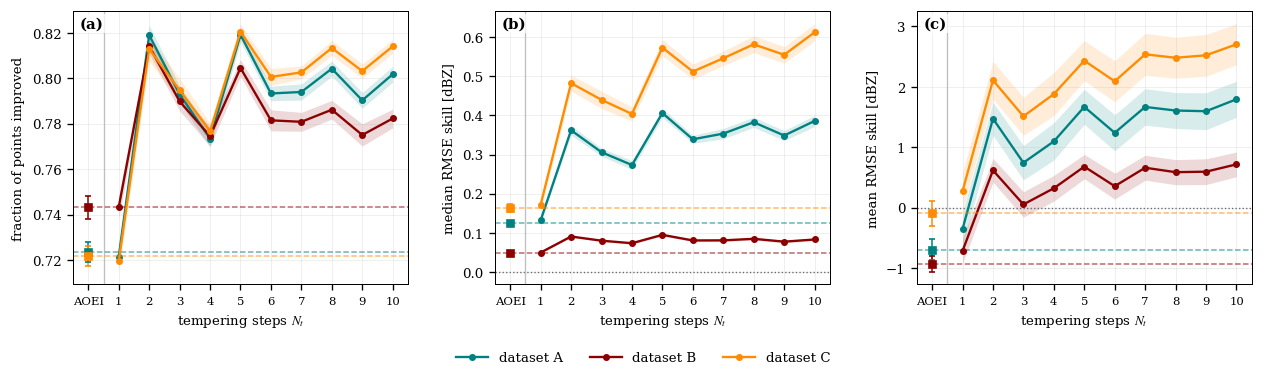

In [77]:
# One line per dataset against the tempering ladder, so the odd/even Nt structure and
# the three datasets are read off the same axis. AOEI has no Nt: it gets a slot of its
# own to the right of a separator, plus a dashed line at its level so it can be
# compared against the whole ladder without being drawn as a point on it.
X_AOEI = min(NT_LADDER) - 1.0
X_SPLIT = (min(NT_LADDER) - X_AOEI) / 2

fig, axes = plt.subplots(1, 3, figsize=(nb.PAGE_W * 1.85, nb.PAGE_W * 0.44),
                         gridspec_kw={"wspace": 0.26})
for ax, (col, ylab, guide, gtxt) in zip(axes, [
        ("frac_improved", "fraction of points improved", 0.5, "coin flip (0.5)"),
        ("median_skill",  "median RMSE skill [dBZ]",     0.0, "prior: skill = 0"),
        ("mean_skill",    "mean RMSE skill [dBZ]",       0.0, "prior: skill = 0")]):
    val, sd = N3_1D_TABLES[col]["value"], N3_1D_TABLES[col]["sd"]
    # The prior is only drawn where it carries information. For a skill it is zero by
    # construction, so the reference line is the zero line and nothing else; §1b draws
    # the prior properly, on the raw error.
    if not col == "frac_improved":
        ax.axhline(guide, color="0.35", lw=0.8, ls=":", zorder=1)
    ax.axvline(X_SPLIT, color="0.75", lw=0.8, zorder=1)
    for ds in DATASETS:
        y = np.array([val.at[LAB[c], ds] for c in TENKF_COMBOS])
        e = np.array([sd.at[LAB[c], ds] for c in TENKF_COMBOS])
        ax.fill_between(NT_LADDER, y - e, y + e, color=DS_COLORS[ds], alpha=0.15, lw=0)
        ax.plot(NT_LADDER, y, "-o", ms=3.2, color=DS_COLORS[ds], label=f"dataset {ds}")
        ya = float(val.at[LAB[AOEI_COMBO], ds])
        ea = float(sd.at[LAB[AOEI_COMBO], ds])
        ax.axhline(ya, color=DS_COLORS[ds], lw=0.9, ls="--", alpha=0.6, zorder=2)
        ax.errorbar([X_AOEI], [ya], yerr=[ea], fmt="s", ms=4.2, color=DS_COLORS[ds],
                    capsize=2, elinewidth=0.9, zorder=4)
    ax.set_xticks(NT_LADDER + [X_AOEI])
    ax.set_xticklabels([str(n) for n in NT_LADDER] + ["AOEI"], fontsize=7)
    #ax.set_xlim(min(NT_LADDER) - 0.5, X_AOEI + 0.6)
    ax.set_xlabel("tempering steps $N_t$", fontsize=8)
    ax.set_ylabel(ylab, fontsize=8)
    # Label the guide where it is, not in a corner: a floating "prior: skill = 0"
    # at the bottom of a panel whose y range starts below zero labels the wrong line.
    #ax.text(0.02, guide, gtxt, transform=ax.get_yaxis_transform(), fontsize=6.5,
    #        color="0.35", va="bottom", ha="left",
    #        bbox=dict(fc="white", ec="none", alpha=0.7, pad=1.0))
for a, letter in zip(axes, "abc"):
    nb.panel_label(a, letter)
h_, l_ = axes[0].get_legend_handles_labels()
fig.legend(h_, l_, loc="lower center", bbox_to_anchor=(0.5, -0.13), ncol=len(DATASETS),
           frameon=False, fontsize=8, columnspacing=2.0, handlelength=2.4)
_ntm = sorted({N_TM[ds] for ds in DATASETS})
#fig.suptitle(f"{nb.loc_label(RUN['loc'])}, {nb.RED_LABELS[RED_1D]} — three datasets, "
#             f"{hours_txt()} pooled\n"
#             f"(band / whisker: ±1 s.d. across the "
#             f"{'/'.join(str(n) for n in _ntm)} truth members)", y=1.10)
#nb.save_fig(fig, "N3_1D_fig1_headline_by_scheme_3ds")
plt.show()

### 1b · The same three datasets without the subtraction, and one dot per truth member

Everything above is a difference, `prior − analysis`. A difference of two large numbers
hides how large they were: a `+0.4 dBZ` median skill is a very different claim when the
prior error is 2 dBZ than when it is 20. The table below shows the two levels
themselves, with no subtraction taken anywhere — and this is the one view where the
prior is a real row rather than a zero by construction.

Then the figure that justifies quoting a mean or a median at all: **one dot per truth
member**, every analysis time it owns pooled before the statistic is taken, 60 dots per
scheme per dataset. The vertical scatter inside a column is the OSSE sampling noise —
the same quantity the `±` in §1's tables reports — and it is what a scheme-to-scheme
gap has to clear to mean anything. The top row is the raw error, the bottom row the
median skill the tables quote.

The prior is a single field shared by every scheme — `align()` guarantees it row for
row, and the cell asserts it per dataset — so it is drawn once, as the dashed reference
with its across-member band. Any scheme whose dots sit above that line made the fit
worse than the background it started from.

One naming caveat. At `_point_` the stored `rmse_*_point_obs` column is
`|H(x̄) − H(x_true)|` at the single cell: one cell has no RMS to take, so it is an
absolute error and the axes say so.

In [78]:
# Raw prior and analysis error at the observation point, pooled the same way as §1: a
# row here is one (dataset, scheme, stage, truth member), the member's four analysis
# times pooled before the median/mean is taken. 60 rows per scheme per dataset.
RAW3_ROWS, POOL3_ROWS = [], []
for ds in DATASETS:
    tm_arr = ADS[ds].frames[COMBOS[0]]["tm"].to_numpy()
    prior_ref = None
    for c in COMBOS:
        for stage, sname in (("f", "prior"), ("a", "analysis")):
            v = nb.raw(ADS[ds].frames[c], "rmse", stage, RED_1D,
                       "obs").to_numpy(np.float32)
            if stage == "f":
                # The prior is ONE field. Asserted rather than assumed, because the
                # figure draws it once and would otherwise silently show the baseline's
                # prior under every scheme's analysis.
                if prior_ref is None:
                    prior_ref = v
                else:
                    assert _same(v, prior_ref).all(), \
                        f"dataset {ds}: the prior error differs between schemes"
            agg = pd.Series(v.astype(float)).groupby(tm_arr).agg(["median", "mean"])
            for t, r_ in agg.iterrows():
                RAW3_ROWS.append({"dataset": ds, "scheme": LAB[c], "stage": sname,
                                  "tm": int(t), "median": float(r_["median"]),
                                  "mean": float(r_["mean"])})
            POOL3_ROWS.append({"dataset": ds, "scheme": LAB[c], "stage": sname,
                               "median": float(np.nanmedian(v)),
                               "mean": float(np.nanmean(v))})
            del v
    del prior_ref, tm_arr
    gc.collect()
RAW3 = pd.DataFrame(RAW3_ROWS)
POOL3 = pd.DataFrame(POOL3_ROWS)
del RAW3_ROWS, POOL3_ROWS


def _pooled3(ds, stage, c, stat):
    g = POOL3[(POOL3.dataset == ds) & (POOL3.stage == stage) & (POOL3.scheme == LAB[c])]
    return float(g[stat].iloc[0])


def _bytm3(ds, stage, c, stat):
    """Per-truth-member series, reindexed onto the dataset's member list so the dots
    and the jitter line up member for member across schemes."""
    g = RAW3[(RAW3.dataset == ds) & (RAW3.stage == stage) & (RAW3.scheme == LAB[c])]
    return g.set_index("tm")[stat].reindex(TM_OF[ds])


# The same shape as the three skill tables, and the one where the prior row is not a
# tautology: it is the level everything else is a difference from.
_v = pd.DataFrame(0.0, index=ROW_LABELS, columns=list(DATASETS))
_e = _v.copy()
for ds in DATASETS:
    _v.at["prior", ds] = _pooled3(ds, "prior", COMBOS[0], "median")
    _e.at["prior", ds] = float(_bytm3(ds, "prior", COMBOS[0], "median").std())
    for c in ROW_COMBOS:
        _v.at[LAB[c], ds] = _pooled3(ds, "analysis", c, "median")
        _e.at[LAB[c], ds] = float(_bytm3(ds, "analysis", c, "median").std())
_v.index.name = _e.index.name = "method"
_v.columns.name = _e.columns.name = "dataset"
N3_1D_TABLES["median_abs_error"] = {"value": _v, "sd": _e, "pm": as_pm(_v, _e, nd=3)}

print(f"median |error| at the observation point [dBZ]  —  {nb.loc_label(RUN['loc'])}, "
      f"{hours_txt()} pooled")
print(f"cell = pooled over every point;  ± = s.d. across the truth members\n")
print(N3_1D_TABLES["median_abs_error"]["pm"].to_string())

print("\npooled over every point and every truth member, no subtraction anywhere "
      "[dBZ]:\n")
print(pd.DataFrame([
    {"dataset": ds, "scheme": LAB[c],
     "median prior": _pooled3(ds, "prior", c, "median"),
     "median analysis": _pooled3(ds, "analysis", c, "median"),
     "mean prior": _pooled3(ds, "prior", c, "mean"),
     "mean analysis": _pooled3(ds, "analysis", c, "mean")}
    for ds in DATASETS for c in ROW_COMBOS
]).to_string(index=False, float_format=lambda v: f"{v:8.3f}"))
del _v, _e

NameError: name '_same' is not defined

saved N3_1D_fig1b_scatter_by_member_3ds.pdf / N3_1D_fig1b_scatter_by_member_3ds.png


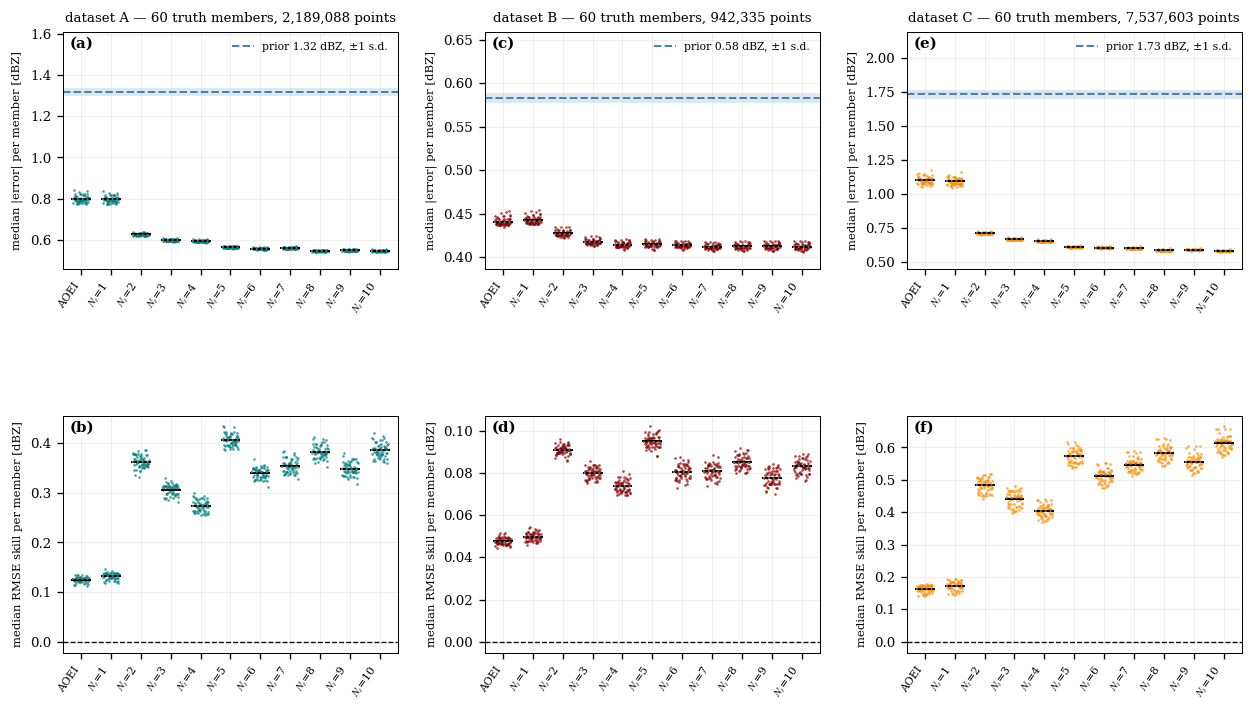

In [72]:
# One dot per truth member -- every analysis time it owns pooled before the statistic
# taken -- and one panel column per dataset. No pooling across members anywhere: the
# spread inside a column IS the error bar the tables in §1 print as ±, drawn as the
# thing it is rather than as a whisker. Black bar = the mean of the dots, dotted grey
# bar = their median.
fig, axes = plt.subplots(2, len(DATASETS), squeeze=False,
                         figsize=(nb.PAGE_W * 1.85, nb.PAGE_W * 1.0),
                         gridspec_kw={"hspace": 0.62, "wspace": 0.26})
x = np.arange(len(ROW_COMBOS))
for cc, ds in enumerate(DATASETS):
    jit = np.linspace(-0.26, 0.26, N_TM[ds])

    # (top) the raw error: nothing subtracted, so the prior is a real reference.
    ax = axes[0, cc]
    pri = _bytm3(ds, "prior", COMBOS[0], "median").to_numpy(float)
    ax.axhspan(np.nanmean(pri) - np.nanstd(pri, ddof=1),
               np.nanmean(pri) + np.nanstd(pri, ddof=1),
               color=nb.C_PRIOR, alpha=0.18, lw=0)
    ax.axhline(np.nanmean(pri), color=nb.C_PRIOR, lw=1.2, ls="--",
               label=f"prior {np.nanmean(pri):.2f} dBZ, ±1 s.d.")
    vals = [_bytm3(ds, "analysis", c, "median").to_numpy(float) for c in ROW_COMBOS]
    for i, y in enumerate(vals):
        ax.plot(i + jit, y, ".", ms=3.2, color=DS_COLORS[ds], alpha=0.7, mew=0)
        ax.plot([i - 0.30, i + 0.30], [np.nanmean(y)] * 2, "-", color="k", lw=1.2,
                zorder=5)
        ax.plot([i - 0.30, i + 0.30], [np.nanmedian(y)] * 2, ":", color="0.45", lw=1.1,
                zorder=5)
    _all = np.concatenate([pri] + vals)
    _lo, _hi = np.nanmin(_all), np.nanmax(_all)
    ax.set_ylim(_lo - 0.10 * (_hi - _lo), _hi + 0.30 * (_hi - _lo))
    ax.set_title(f"dataset {ds} — {N_TM[ds]} truth members, "
                 f"{ADS[ds].n_points:,} points", fontsize=8)
    ax.set_ylabel("median |error| per member [dBZ]", fontsize=7)
    ax.legend(fontsize=6.5, frameon=False, loc="upper right")

    # (bottom) the quantity the median-skill table quotes, member by member.
    ax = axes[1, cc]
    P_ = (BYTM3[(BYTM3.dataset == ds) & (BYTM3.metric == "rmse")]
          .pivot(index="tm", columns="combo", values="median_skill"))
    for i, c in enumerate(ROW_COMBOS):
        y = P_[SLUG[c]].reindex(TM_OF[ds]).to_numpy(float)
        ax.plot(i + jit, y, ".", ms=3.2, color=DS_COLORS[ds], alpha=0.7, mew=0)
        ax.plot([i - 0.30, i + 0.30], [np.nanmean(y)] * 2, "-", color="k", lw=1.2,
                zorder=5)
        ax.plot([i - 0.30, i + 0.30], [np.nanmedian(y)] * 2, ":", color="0.45", lw=1.1,
                zorder=5)
    ax.axhline(0.0, color="k", lw=0.8, ls="--")
    ax.set_ylabel("median RMSE skill per member [dBZ]", fontsize=7)

    for r in (0, 1):
        axes[r, cc].set_xticks(x)
        axes[r, cc].set_xticklabels(ROW_TICKS, rotation=55, ha="right", fontsize=6.5)
        axes[r, cc].set_xlim(-0.6, len(ROW_COMBOS) - 0.4)
for a, letter in zip(axes.ravel(order="F"), "abcdef"):
    nb.panel_label(a, letter)
#fig.suptitle(f"{nb.loc_label(RUN['loc'])}, {nb.RED_LABELS[RED_1D]} — one dot per truth "
#             f"member (analysis times pooled: {hours_txt()})\n"
#             f"top: raw error, nothing subtracted;  bottom: the skill §1 tabulates;  "
#             f"bars: mean (solid) and median (dotted) over members", y=1.03)
nb.save_fig(fig, "N3_1D_fig1b_scatter_by_member_3ds")
plt.show()

saved N3_1D_fig2_skill_distributions.pdf / N3_1D_fig2_skill_distributions.png


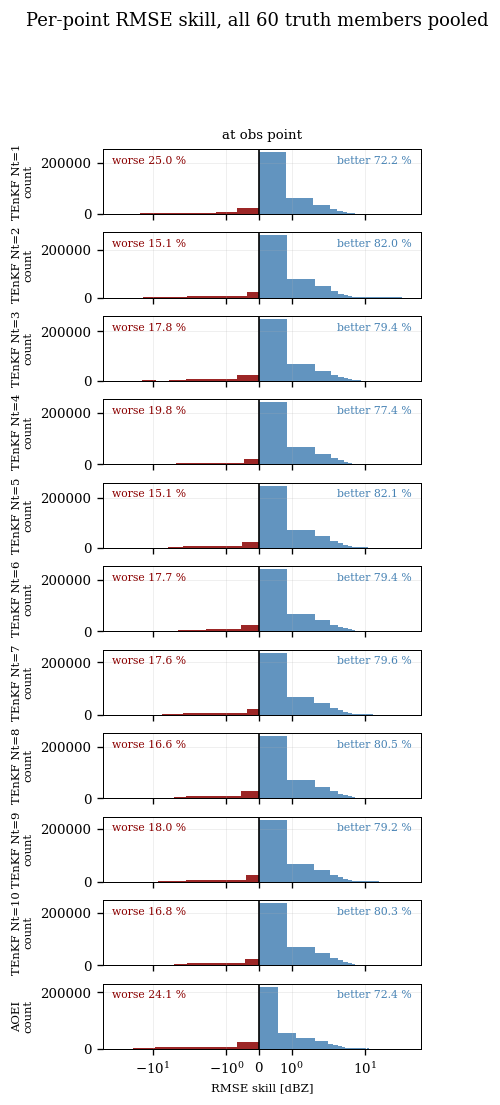

In [ ]:
fig, axes = plt.subplots(len(COMBOS), len(SHOW_REDS), squeeze=False,
                         figsize=(nb.PAGE_W * max(0.5, 0.42 * len(SHOW_REDS)),
                                  nb.PAGE_W * 1.45),
                         sharex=True, gridspec_kw={"hspace": 0.28, "wspace": 0.18})
for r, c in enumerate(COMBOS):
    for cc, red in enumerate(SHOW_REDS):
        ax = axes[r, cc]
        s = nb.skill(A.frames[c], "rmse", "obs", red).to_numpy(float)
        s = s[np.isfinite(s)]
        ax.hist(s[s >= 0], bins=60, color="SteelBlue", alpha=0.85)
        ax.hist(s[s < 0], bins=60, color="DarkRed", alpha=0.85)
        ax.set_xscale("symlog")
        ax.axvline(0, color="k", lw=1.0)
        pos, neg = 100 * (s > TOL).mean(), 100 * (s < -TOL).mean()
        ax.text(0.97, 0.90, f"better {pos:.1f} %", transform=ax.transAxes,
                fontsize=6.5, color="SteelBlue", va="top", ha="right")
        ax.text(0.03, 0.90, f"worse {neg:.1f} %", transform=ax.transAxes,
                fontsize=6.5, color="DarkRed", va="top")
        if r == 0:
            ax.set_title(nb.RED_LABELS[red], fontsize=8)
        if cc == 0:
            ax.set_ylabel(f"{LAB[c]}\ncount", fontsize=7)
        if r == len(COMBOS) - 1:
            ax.set_xlabel("RMSE skill [dBZ]", fontsize=7)
        del s
fig.suptitle(f"Per-point RMSE skill, all {len(TMLIST)} truth members pooled", y=0.995)
#nb.save_fig(fig, "N3_1D_fig2_skill_distributions")
plt.show()

## 3 · Where the schemes differ

The map pools every truth member, so each column now has `n_tm` × `nz` samples
instead of `nz` — the maps are far less noisy than N3's single-member versions. The
first panel is the baseline's absolute skill; the rest are **differences from the
baseline**, on their own symmetric scale, because the absolute maps are visually
indistinguishable at this localization.

The height profile matters for a structural reason: with `L = 0.1 km` the vertical
localization is 0.1 km, so a level is essentially coupled only to itself.

In [ ]:
POS_KM = np.zeros((NXG, NYG, 1, 3), np.float32)
POS_KM[..., 0] = (np.arange(NXG) * abs(DX))[:, None, None]
POS_KM[..., 1] = (np.arange(NYG) * abs(DX))[None, :, None]

ij = REF[["i", "j"]]
fig, axes = plt.subplots(3, 3, figsize=(nb.PAGE_W * 2.1, nb.PAGE_W * 0.42),
                         gridspec_kw={"wspace": 0.3})
base_sk = SK[(BASE, "rmse")]
axes = axes.ravel()
for ax, c in zip(axes, COMBOS):
    diff = (c != BASE)
    v = (SK[(c, "rmse")] - base_sk) if diff else base_sk
    g = ij.assign(_v=np.asarray(v, float))
    xs, ys, grid = nb.coarse_map_km(g, "_v", POS_KM, stride=1, agg="mean")
    lim = float(np.nanpercentile(np.abs(grid), 98)) or 1.0
    pm = ax.pcolormesh(xs, ys, grid.T, cmap="RdBu" if not diff else "PuOr_r",
                       vmin=-lim, vmax=lim, shading="auto")
    plt.colorbar(pm, ax=ax, shrink=0.8)
    ax.set_title(LAB[c] if not diff else f"{LAB[c]} − {LAB[BASE]}", fontsize=7.5)
    ax.set_xlabel("x [km]", fontsize=7)
    ax.set_ylabel("y [km]", fontsize=7)
    ax.grid(False)
    del g, grid
fig.suptitle(f"RMSE skill, {nb.RED_LABELS[REF_RED]}, mean over {len(TMLIST)} truth "
             f"members  (blue/orange = better)", y=1.06)
#nb.save_fig(fig, "N3_1D_fig4_maps")
plt.show()

TypeError: bad operand type for abs(): 'dict'

saved N3_1D_fig5_profiles.pdf / N3_1D_fig5_profiles.png


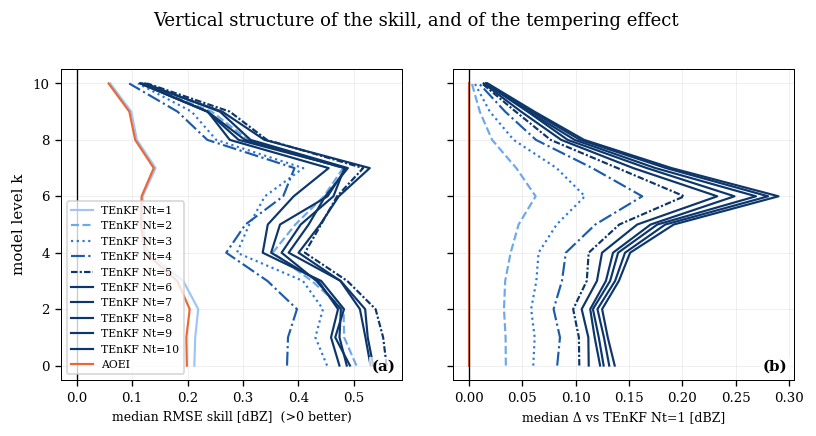

In [13]:
kk = REF["k"].to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(nb.PAGE_W * 1.15, nb.PAGE_W * 0.5),
                         sharey=True, gridspec_kw={"wspace": 0.15})
base_prof = pd.Series(base_sk).groupby(kk).median()
for c in COMBOS:
    prof = pd.Series(SK[(c, "rmse")]).groupby(kk).median()
    axes[0].plot(prof.to_numpy(), prof.index, ls=nb.combo_style(c[0], c[1]),
                 color=COL[c], lw=1.3, label=LAB[c])
    if c != BASE:
        d = pd.Series(SK[(c, "rmse")] - base_sk).groupby(kk).median()
        axes[1].plot(d.to_numpy(), d.index, ls=nb.combo_style(c[0], c[1]),
                     color=COL[c], lw=1.3, label=LAB[c])
axes[0].axvline(0, color="k", lw=0.8)
axes[1].axvline(0, color="k", lw=0.8)
axes[0].set_xlabel("median RMSE skill [dBZ]  (>0 better)", fontsize=7.5)
axes[1].set_xlabel(f"median Δ vs {LAB[BASE]} [dBZ]", fontsize=7.5)
axes[0].set_ylabel("model level k")
axes[0].legend(fontsize=6.5)
for a, letter in zip(axes, "ab"):
    nb.panel_label(a, letter, loc="lower right")
fig.suptitle("Vertical structure of the skill, and of the tempering effect", y=1.02)
nb.save_fig(fig, "N3_1D_fig5_profiles")
plt.show()

## 4 · RMSE and CRPS — do the schemes agree with themselves?

RMSE compares the ensemble *mean* to the truth. CRPS scores the whole predictive
distribution, so an update that moves the mean the right way while collapsing the
spread improves RMSE and worsens CRPS at the same point. Tempering exists partly to
avoid exactly that collapse, so the sign-disagreement rate is a direct read on
whether extra steps buy a better-calibrated analysis or just a better mean.

saved N3_1D_fig6_rmse_vs_crps.pdf / N3_1D_fig6_rmse_vs_crps.png


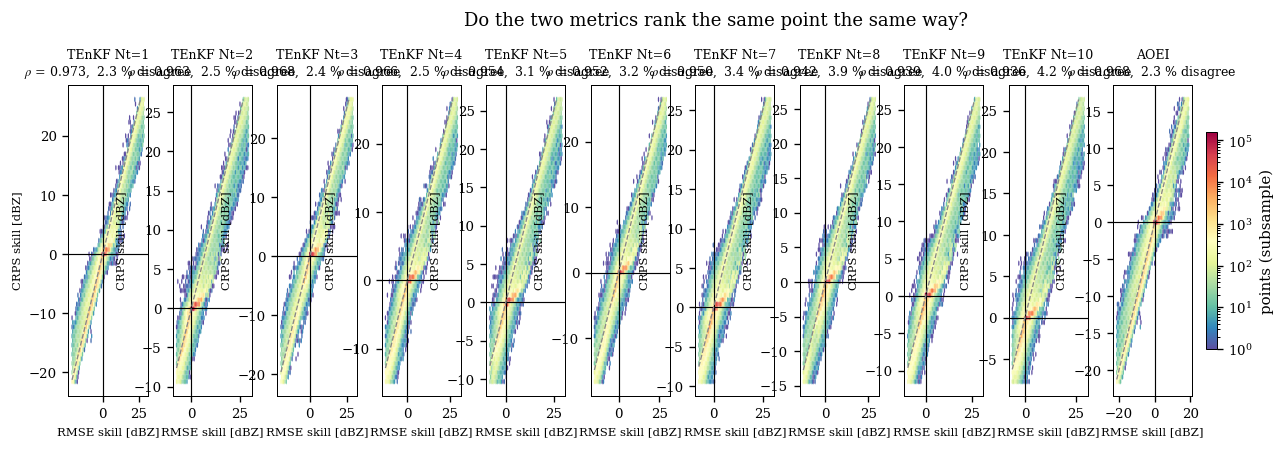

     scheme  spearman_rho  sign_disagreement_%  rmse_better_crps_worse_%
 TEnKF Nt=1         0.973                2.293                     1.265
 TEnKF Nt=2         0.963                2.481                     1.472
 TEnKF Nt=3         0.968                2.380                     1.404
 TEnKF Nt=4         0.966                2.504                     1.466
 TEnKF Nt=5         0.954                3.090                     2.065
 TEnKF Nt=6         0.952                3.228                     2.186
 TEnKF Nt=7         0.950                3.372                     2.314
 TEnKF Nt=8         0.942                3.870                     2.823
 TEnKF Nt=9         0.939                4.040                     2.969
TEnKF Nt=10         0.936                4.224                     3.138
       AOEI         0.968                2.348                     1.257

Quadrant II/IV = the metrics disagree about whether that point improved.
The last column isolates the failure tempering is 

In [14]:
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, len(COMBOS), figsize=(nb.PAGE_W * 2.1, nb.PAGE_W * 0.5),
                         gridspec_kw={"wspace": 0.32})
dis_rows = []
for ax, c in zip(axes, COMBOS):
    sr, sc = SK[(c, "rmse")], SK[(c, "crps")]
    m = np.isfinite(sr) & np.isfinite(sc)
    disagree = float((np.sign(sr[m]) != np.sign(sc[m])).mean())
    rho = float(spearmanr(sr[SUB], sc[SUB]).correlation)   # 2e6 points is ample for rho
    dis_rows.append({"scheme": LAB[c], "spearman_rho": rho,
                     "sign_disagreement_%": 100 * disagree,
                     "rmse_better_crps_worse_%":
                         100 * float(((sr[m] > TOL) & (sc[m] < -TOL)).mean())})
    xs, ys = sr[SUB].astype(float), sc[SUB].astype(float)
    xl, yl = nb.lims(xs, 1, 99), nb.lims(ys, 1, 99)
    hb = ax.hexbin(xs, ys, gridsize=55, bins="log", cmap="Spectral_r",
                   extent=(xl[0], xl[1], yl[0], yl[1]), mincnt=1, linewidths=0)
    ax.axhline(0, color="k", lw=0.7)
    ax.axvline(0, color="k", lw=0.7)
    lo, hi = max(xl[0], yl[0]), min(xl[1], yl[1])
    ax.plot([lo, hi], [lo, hi], "--", color="#888", lw=0.8)
    ax.set_xlabel("RMSE skill [dBZ]", fontsize=7)
    ax.set_ylabel("CRPS skill [dBZ]", fontsize=7)
    ax.set_title(f"{LAB[c]}\n$\\rho$ = {rho:.3f},  {100*disagree:.1f} % disagree",
                 fontsize=7.5)
    ax.grid(False)
    del sr, sc, m
fig.colorbar(hb, ax=axes, shrink=0.7, pad=0.01, label="points (subsample)")
fig.suptitle("Do the two metrics rank the same point the same way?", y=1.06)
nb.save_fig(fig, "N3_1D_fig6_rmse_vs_crps")
plt.show()

print(pd.DataFrame(dis_rows).to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("\nQuadrant II/IV = the metrics disagree about whether that point improved.")
print("The last column isolates the failure tempering is supposed to prevent: the")
print("mean improved while the distribution got worse.")

## 5 · Head to head, point by point

The schemes are aligned point-for-point, so they can be compared without any
aggregation at all: at each of the ~10⁷ points, which scheme produced the smaller
error? Entry (row, col) is the fraction of points where the **row** scheme beat the
**column** scheme by more than the tolerance. Rows and columns are not
complementary — the remainder is ties.

This is the strictest form of the comparison in §2: no averaging over points, and the
truth member cancels because both schemes saw the same one.

saved N3_1D_fig7_head_to_head.pdf / N3_1D_fig7_head_to_head.png


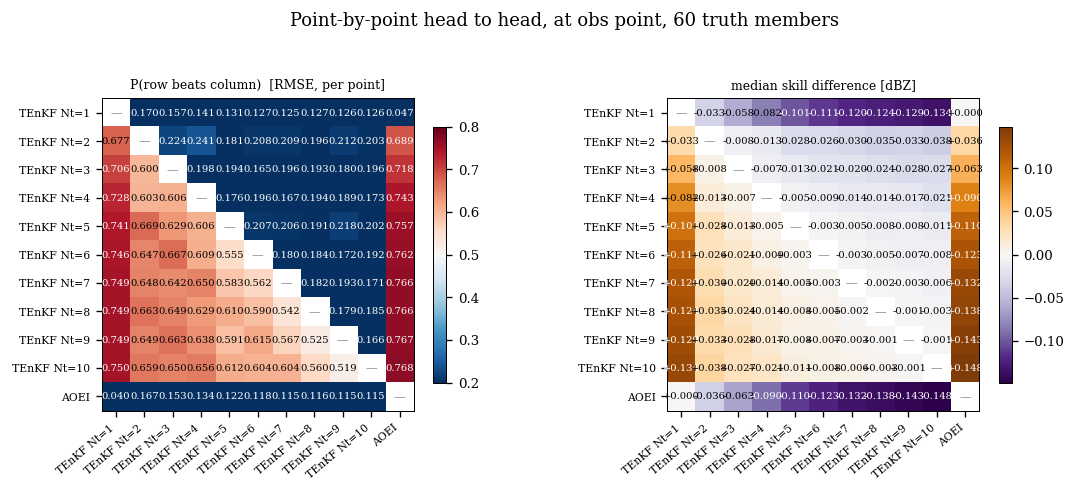

against TEnKF Nt=1, per point:

     scheme  beats baseline [%]  loses to baseline [%]  ties [%]  median Δ vs baseline [dBZ]
 TEnKF Nt=2             +67.666                +16.996   +15.339                      +0.033
 TEnKF Nt=3             +70.563                +15.660   +13.777                      +0.058
 TEnKF Nt=4             +72.756                +14.131   +13.113                      +0.082
 TEnKF Nt=5             +74.113                +13.090   +12.797                      +0.101
 TEnKF Nt=6             +74.585                +12.739   +12.676                      +0.111
 TEnKF Nt=7             +74.927                +12.520   +12.553                      +0.120
 TEnKF Nt=8             +74.860                +12.674   +12.466                      +0.124
 TEnKF Nt=9             +74.930                +12.618   +12.452                      +0.129
TEnKF Nt=10             +75.042                +12.580   +12.378                      +0.134
       AOEI              +4.017       

In [15]:
n = len(COMBOS)
WIN = np.full((n, n), np.nan)
MED = np.full((n, n), np.nan)
for a in range(n):
    for bb in range(n):
        if a == bb:
            continue
        d = SK[(COMBOS[a], "rmse")].astype(np.float32) - SK[(COMBOS[bb], "rmse")]
        good = np.isfinite(d)
        WIN[a, bb] = float((d[good] > TOL).mean())
        MED[a, bb] = float(np.median(d[good]))
        del d, good

fig, axes = plt.subplots(1, 2, figsize=(nb.PAGE_W * 1.5, nb.PAGE_W * 0.55),
                         gridspec_kw={"wspace": 0.45})
for ax, M, ttl, cmap, kw in (
        (axes[0], WIN, "P(row beats column)  [RMSE, per point]", "RdBu_r",
         dict(vmin=0.2, vmax=0.8)),
        (axes[1], MED, f"median skill difference [dBZ]", "PuOr_r",
         dict(vmin=-np.nanmax(np.abs(MED)), vmax=np.nanmax(np.abs(MED))))):
    im = ax.imshow(M, cmap=cmap, **kw)
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels([LAB[c] for c in COMBOS], rotation=40, ha="right", fontsize=6.5)
    ax.set_yticklabels([LAB[c] for c in COMBOS], fontsize=6.5)
    ax.set_title(ttl, fontsize=7.5)
    ax.grid(False)
    for a in range(n):
        for bb in range(n):
            if a == bb:
                ax.text(bb, a, "—", ha="center", va="center", fontsize=7, color="#888")
            else:
                ax.text(bb, a, f"{M[a, bb]:.3f}" if M is WIN else f"{M[a, bb]:+.3f}",
                        ha="center", va="center", fontsize=6,
                        color="k" if abs(M[a, bb] - (0.5 if M is WIN else 0)) < (
                            0.18 if M is WIN else 0.6 * np.nanmax(np.abs(MED))) else "w")
    plt.colorbar(im, ax=ax, shrink=0.75)
fig.suptitle(f"Point-by-point head to head, {nb.RED_LABELS[REF_RED]}, "
             f"{len(TMLIST)} truth members", y=1.04)
nb.save_fig(fig, "N3_1D_fig7_head_to_head")
plt.show()

ib = COMBOS.index(BASE)
vs_base = pd.DataFrame([{
    "scheme": LAB[c],
    "beats baseline [%]": 100 * WIN[i, ib],
    "loses to baseline [%]": 100 * WIN[ib, i],
    "ties [%]": 100 * (1 - WIN[i, ib] - WIN[ib, i]),
    "median Δ vs baseline [dBZ]": MED[i, ib],
} for i, c in enumerate(COMBOS) if c != BASE])
print(f"against {LAB[BASE]}, per point:\n")
print(vs_base.to_string(index=False, float_format=lambda v: f"{v:+.3f}"))

## 6 · Do prior conditions predict degradation, and does the scheme change that?

Sections 6 to 9 leave the single reference run behind and work on the **three pooled
datasets** of §1, at `RED_1D = "point"`. A rule that only holds for one ensemble
source at one hour is not a rule, so every number from here to §9 is computed three
times and reported three times.

Every predictor is a **stored sweep column** — nothing recomputes H(x).

| predictor | definition |
|---|---|
| `mean_f_point_obs` | prior ensemble mean reflectivity at the observation point [dBZ] |
| `dep_b` | innovation `d = y_o − mean(H(x_f))`, signed [dBZ] |
| `norm_innov` | `\|d\| / sqrt(σ_H² + R)` — the innovation in units of what the filter expects |
| `spread_f_point_obs` | prior ensemble spread σ_H [dBZ] |
| `n_active_f_point` | members with `H(x) > dbz_min`, of `Ne` |
| `abs_skew_f`, `kurt_f_point_obs` | prior non-Gaussianity |

The sweep writes the prior mean under the name `hxf_mean_obs`; the load cell renames
it to `mean_f_point_obs` so that it sits in the same naming family as its neighbours
and so that a rejection rule can be quoted in those names. That cell also asserts
`y_o = mean_f_point_obs + dep_b` on a full file of every dataset, rather than trusting
the definition of the innovation.

### What is *not* an independent axis

Three of the quantities used below are algebraic functions of the others, so no figure
and no rule may claim two independent axes where there is one:

* **`norm_innov` = `|dep_b| / sqrt(spread_f_point_obs² + R)`** — a function of `dep_b`
  and `spread_f_point_obs` with `R` a constant. A three-condition rule on all three of
  them is a two-condition rule wearing a third condition.
* **`frac_floor` = `1 − n_active_f_point / Ne`** — the same column, rescaled and
  reversed.
* **`obs_dbz` = `mean_f_point_obs + dep_b`** — the observation itself. It is *derived*
  here, not stored under that name, and it carries nothing the pair does not.

`abs_dep_b` and `abs_skew_f` are likewise the magnitudes of columns already in the
list. They are kept because a signed and an unsigned innovation answer different
questions, not because they add information.

### `Ne = 59`, not 60

Each dataset holds 60 ensemble members, and the sweep is leave-one-out: one member is
taken as the truth and the remaining **59** form the prior. So `n_active_f_point` tops
out at 59, `frac_floor` is `1 − n_active/59`, and a point where every member has echo
reads 59 and not 60. The loop over the 60 truth members is what removes the dependence
on which member was taken out — it is not an extra 60th member.

In [16]:
# ── §6-§9 infrastructure: three datasets, their predictors and their skills ─
import hashlib
import itertools

# §1-§5 dissect ONE run. Everything from here on works on the three pooled datasets,
# so the per-point machinery has to exist three times over. Built once, here, and read
# by §6, §7, §8 and §9.

# The schemes the rule work is done on. The full Nt = 1 … 10 ladder is §1's subject; a
# rejection rule fitted eleven times says nothing eleven times, so the scan is run on
# the untempered filter, the two shortest tempering ladders and AOEI -- the four that
# differ in mechanism rather than only in step count.
RULE_COMBOS = [nb.combo_key(COMBOS, m, n) for m, n in RULE_COMBOS_SPEC]
AO = nb.combo_key(COMBOS, "AOEI", 1)

# The predictors §6 carries, in the order it presents them.
PRED_SHOW = [
    (MEAN_F,               "prior ensemble mean [dBZ]"),
    ("dep_b",              "innovation $d$ [dBZ]"),
    ("norm_innov",         "normalised innovation"),
    ("spread_f_point_obs", r"prior spread $\sigma_H$ [dBZ]"),
    ("n_active_f_point",   f"members with signal, of {NE}"),
    ("abs_skew_f",         r"prior $|$skewness$|$"),
    ("kurt_f_point_obs",   "prior excess kurtosis"),
]
PRED_LABEL = {p: lab for p, lab in PRED_SHOW}
PRED_LABEL.update({p: lab for p, lab, _ in nb.PREDICTORS if p not in PRED_LABEL})
PRED_CLIP = {p: clip for p, _, clip in nb.PREDICTORS}
PRED_CLIP.setdefault(MEAN_F, (0, 99.5))
PRED_CLIP["obs_dbz"] = (0, 99.5)

for ds in DS_LOAD:
    # norm_innov, frac_floor, abs_skew_f, abs_dep_b -- algebra on stored columns only.
    PDS[ds] = nb.add_predictors(PDS[ds], R=R, Ne=NE)
    # DERIVED, not stored under this name: dep_b = y_o - mean(H(x_f)), so adding the
    # prior mean back gives the observation. The load cell checked exactly this
    # against the stored y_o on a full file of each dataset; y_o itself is not carried
    # past the load, so it is recomputed rather than kept.
    PDS[ds]["obs_dbz"] = PDS[ds][MEAN_F] + PDS[ds]["dep_b"]
    assert PDS[ds].index.equals(ADS[ds].frames[COMBOS[0]].index), \
        f"dataset {ds}: the predictor frame is not row-aligned with its metrics"
    # n_active counts members of the leave-one-out prior, so 59 is the ceiling. If a
    # 60 ever appears, Ne is wrong and frac_floor is wrong with it.
    assert PDS[ds]["n_active_f_point"].max() <= NE, \
        f"dataset {ds}: n_active_f_point exceeds Ne = {NE}"
    # A non-finite predictor is worse than a missing one here: every rejection
    # interval below is a pair of inequalities, and NaN fails both, so such a point
    # would be silently un-rejectable by every candidate rule in §7.
    for _p in (MEAN_F, "dep_b", "norm_innov", "spread_f_point_obs", "n_active_f_point"):
        assert np.isfinite(PDS[ds][_p].to_numpy()).all(), \
            (f"dataset {ds}: {_p} has non-finite entries, which every rejection "
             f"interval in §7 would silently fail to contain")
del _p

# Truth-member arrays, kept next to the frames because §7 splits on them and §9
# groups on them.
TMARR = {ds: ADS[ds].frames[COMBOS[0]]["tm"].to_numpy() for ds in DS_LOAD}
HRARR = {ds: ADS[ds].frames[COMBOS[0]]["hour"].to_numpy() for ds in DS_LOAD}

# The per-point skill arrays for all three datasets. float32, computed once, because
# §6, §7, §8 and §9 all need them and skill() over 10.7 M rows is not free.
SKD = {(ds, c, m): nb.skill(ADS[ds].frames[c], m, "obs", RED_1D).to_numpy(np.float32)
       for ds in DS_LOAD for c in COMBOS for m in METRICS}

# The same arrays under a (dataset, scheme) key, which is the shape every function in
# §7 and §15 takes. It exists so the band construction is written ONCE: §7a passes
# SK_OBS and §15 passes the corresponding lookup for w, u, v or T, and neither the
# min-count safeguard nor the contiguity rule nor the threshold definition is copied
# to a second place where it could drift. Views, not copies -- no memory is spent.
SK_OBS = {(ds, c): SKD[(ds, c, "rmse")] for ds in DS_LOAD for c in COMBOS}


def p_degraded(idx, ok, s, nbin, min_count=200):
    """P(degraded) per bin: the MEAN of the indicator `skill < -TOL` over the bin.

    The mean of a 0/1 indicator is the probability, which is why no central tendency
    of the skill appears in it and why a median has no role here -- the median of an
    indicator is just whichever outcome is more common. A point inside the tie
    tolerance (|skill| <= TOL) is neither improved nor degraded and counts for
    neither side.
    """
    return bin_mean(idx, ok, (s < -TOL), nbin, min_count=min_count)


def pooled_edges(pred, nbin=22, clip=None, per_ds=200_000):
    """Equal-count bin edges shared by the three datasets.

    Where a panel draws one line per dataset the lines have to sit on the SAME x grid,
    or three different binnings are being compared as if they were one. Percentiles are
    taken over a stratified subsample -- the same number of points from each dataset,
    so C's eight-fold point advantage does not simply set the edges for A and B.
    """
    rng = np.random.default_rng(SEED)
    v = np.concatenate([
        rng.choice(PDS[ds][pred].to_numpy(np.float64),
                   size=min(per_ds, len(PDS[ds])), replace=False)
        for ds in DATASETS])
    v = v[np.isfinite(v)]
    lo, hi = clip if clip is not None else PRED_CLIP.get(pred, (0.5, 99.5))
    e = np.unique(np.percentile(v, np.linspace(lo, hi, nbin)))
    return e if e.size >= 3 else np.linspace(*np.percentile(v, [lo, hi]), nbin)


def publish_table(name, df, formatters=None, latex=True):
    """Write one of §6-§8's tables to data/derived/, and print it as LaTeX.

    Deliberately NOT nb.publish. That function canonicalises a frame down to
    _DIGEST_COLS -- run / loc_km / method / ntemp / metric / red / n_points /
    median_skill and friends -- because its job is to make two notebooks'
    skill_summary frames comparable byte for byte. None of the tables here have those
    columns, and nb.publish does not merely drop the others: with no digest column
    left it raises IndexError inside sort_values. So these follow the convention
    N3_1D_by_tm.csv already set in §11 -- written directly, under this notebook's own
    prefix, with a digest of the WHOLE table printed so that a re-run can be compared
    against this one.
    """
    p_ = nb.DERIVED / f"{name}.csv"
    df.to_csv(p_, index=False)
    dig = hashlib.sha1(df.to_csv(index=False).encode()).hexdigest()[:16]
    print(f"\nwrote {p_.name}  ({len(df)} rows x {len(df.columns)} cols, "
          f"digest={dig})")
    if latex:
        print(f"\n% ---- {name}, paste-ready ----")
        print(df.to_latex(index=False, formatters=formatters, escape=True,
                          longtable=False))
    return p_


print(f"§6-§9 work on {len(DATASETS)} datasets ({', '.join(DATASETS)}), "
      f"{hours_txt()}, reduction {RED_1D!r} ({nb.RED_LABELS[RED_1D]}); "
      f"{DS_CONTRAST} is built too and used in §16")
print(f"schemes scanned in §7: {[LAB[c] for c in RULE_COMBOS]}")
print(f"cached {len(SKD)} per-dataset skill arrays "
      f"({sum(a.nbytes for a in SKD.values()) / 1e9:.2f} GB) over "
      f"{sum(ADS[ds].n_points for ds in DS_LOAD):,} points\n")

# ── the reference-run frame §10 still reads ────────────────────────────────
# §10 stays on the single reference run, so its own predictor frame is built here --
# one copy of PRAW plus the grid keys. Nothing else constructs P, USE or BEST.
P = pd.concat([REF[["i", "j", "k", "z_km", "tm"]], PRAW], axis=1)
assert len(P) == A.n_points and not P.columns.duplicated().any()
P = nb.add_predictors(P, R=R, Ne=NE)
for c in COMBOS:
    for m in METRICS:
        P[f"skill_{m}_{SLUG[c]}"] = SK[(c, m)]
        P[f"deg_{m}_{SLUG[c]}"] = SK[(c, m)] < -TOL
USE = [(p, lab, clip) for p, lab, clip in nb.PREDICTORS if p in P]

# The tempered scheme §10 compares against the baseline: the one with the highest
# pooled median skill on the reference run. Read off skill_summary rather than named,
# so that re-running on another configuration re-picks it.
_rs = nb.skill_summary(A, "rmse", "obs", REF_RED)
BEST = max(COMBOS, key=lambda c: float(
    _rs[(_rs.method == c[0]) & (_rs.ntemp == int(c[1]))]["median_skill"].iloc[0]))
del _rs
print(f"reference run {RUN['tag']}: {A.n_points:,} points, "
      f"best scheme by pooled median skill = {LAB[BEST]} (§10 uses it)")

§6-§9 work on 3 datasets (A, B, C), 4 analysis times, reduction 'point' (at obs point); D is built too and used in §16
schemes scanned in §7: ['TEnKF Nt=1', 'TEnKF Nt=2', 'TEnKF Nt=3', 'AOEI']
cached 88 per-dataset skill arrays (1.13 GB) over 12,852,295 points

reference run WS_A_sweep_2000_LOC0.1_ALLMEM: 565,426 points, best scheme by pooled median skill = TEnKF Nt=5 (§10 uses it)


In [17]:
# Predictor ranges and degraded fractions, per dataset. Printed rather than plotted:
# the three datasets differ by a factor of eight in point count and by a factor of two
# in grid spacing, and a shared axis would hide both.
rows = []
for ds in DATASETS:
    q = PDS[ds][[p for p, _ in PRED_SHOW]].quantile([0.0, 0.05, 0.5, 0.95, 1.0])
    for p, _ in PRED_SHOW:
        rows.append({"dataset": ds, "predictor": p,
                     "min": q.at[0.0, p], "p5": q.at[0.05, p], "median": q.at[0.5, p],
                     "p95": q.at[0.95, p], "max": q.at[1.0, p]})
QUANT3 = pd.DataFrame(rows)
print(f"prior-predictor distribution, {hours_txt()} pooled per dataset "
      f"(R = {R}, dbz_min = {DBZ_MIN}, Ne = {NE}):\n")
print(QUANT3.pivot(index="predictor", columns="dataset",
                   values=["median", "p95", "max"])
      .reindex([p for p, _ in PRED_SHOW])
      .to_string(float_format=lambda v: f"{v:9.3f}"))

# The degraded fraction is the single number §6 is about, so it is printed before any
# figure conditions it on anything.
DEG3 = pd.DataFrame(
    {ds: {LAB[c]: 100 * float((SKD[(ds, c, "rmse")] < -TOL).mean()) for c in COMBOS}
     for ds in DATASETS}).reindex([LAB[c] for c in ROW_COMBOS])
DEG3.index.name = "scheme"
DEG3.columns.name = "dataset"
print(f"\nP(degraded) over every point [%] -- RMSE, {nb.RED_LABELS[RED_1D]}:\n")
print(DEG3.to_string(float_format=lambda v: f"{v:7.2f}"))
print("\n'degraded' means skill < -TOL, i.e. the analysis is worse than the prior by")
print(f"more than the tie tolerance {TOL:g} dBZ. Points inside the tolerance are ties.")

prior-predictor distribution, 4 analysis times pooled per dataset (R = 5.0, dbz_min = 0.0, Ne = 59):

                      median                           p95                           max                    
dataset                    A         B         C         A         B         C         A         B         C
predictor                                                                                                   
mean_f_point_obs       1.269     0.568     1.671     6.584     3.830    10.233    47.416    27.778    48.594
dep_b                 -0.437    -0.162    -0.529    13.351     4.791    19.042    65.090    64.689    64.109
norm_innov             0.228     0.175     0.263     1.833     1.468     1.958    24.881    24.993    26.203
spread_f_point_obs     5.416     3.295     6.310    12.539     9.895    15.132    21.617    19.276    23.088
n_active_f_point       4.000     2.000     5.000    18.000    13.000    26.000    59.000    49.000    59.000
abs_skew_f             4.3

saved N3_1D_fig_prob_degraded_vs_predictor.pdf / N3_1D_fig_prob_degraded_vs_predictor.png


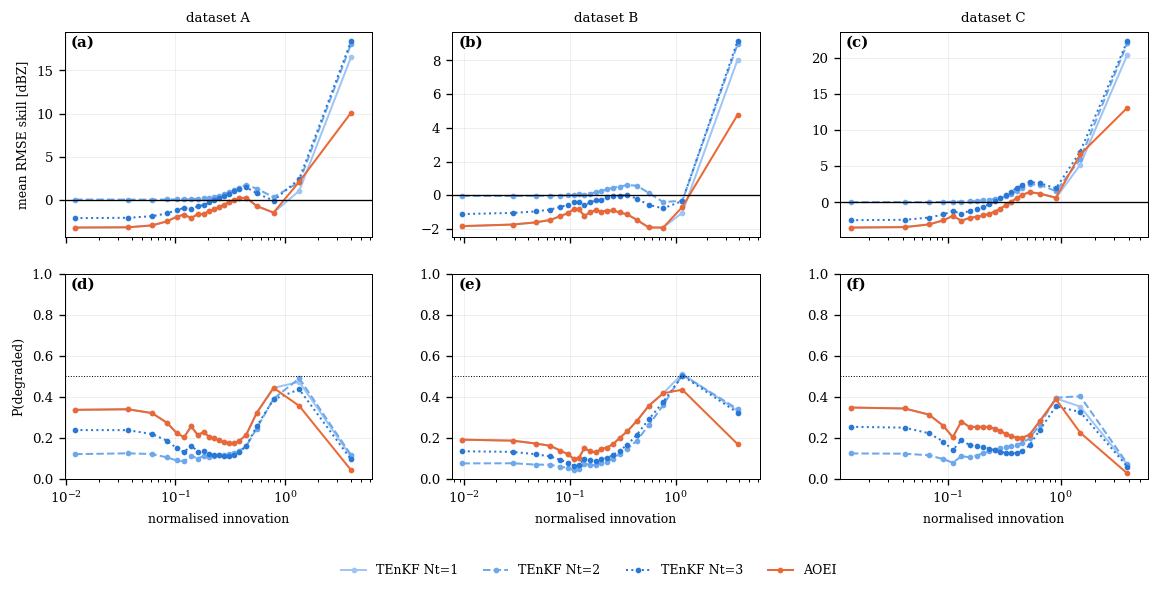

Top row: the mean skill of the points in the bin -- what that bin contributes
to the total. Bottom row: P(degraded), the mean of the indicator skill < -TOL
over the same bin, so it is a probability and not a central tendency of skill.
Equal-count bins (21 per panel) on a log x axis: the bins hold the
same number of points, not the same width, so every marker is equally well
resolved and the axis only has to make them legible.
The top 0.5 % of the innovation tail is off the axis by construction (PRED_CLIP).


In [18]:
# ── §6 figure 1: response to the normalised innovation, by dataset ─────────
# Rows: what the bin contributes to the total (mean skill), and how often it goes
# wrong (P(degraded)). Columns: the three datasets. ONE predictor on the x axis --
# norm_innov -- because the previous version of this figure drew ten predictors and
# five schemes on a 2x5 grid, and the redundancies listed above mean several of those
# panels were the same panel twice.
#
# Bins are equal-count WITHIN a dataset: a panel is one dataset, so the bin that
# matters is the one that holds a fixed share of that dataset's points. The
# cross-dataset figure below shares its edges instead, for the opposite reason.
NBIN_NI = 22

fig, axes = plt.subplots(2, len(DATASETS),
                         figsize=(nb.PAGE_W * 1.7, nb.PAGE_W * 0.72),
                         sharex="col", gridspec_kw={"hspace": 0.18, "wspace": 0.26})
for cc, ds in enumerate(DATASETS):
    v = PDS[ds]["norm_innov"].to_numpy(float)
    edges = edges_for(v, PRED_CLIP["norm_innov"], NBIN_NI)
    idx, ok = digitize(v, edges)
    cen = 0.5 * (edges[:-1] + edges[1:])
    for c in RULE_COMBOS:
        s = SKD[(ds, c, "rmse")]
        y0, _ = bin_stat(idx, ok, s, len(cen), stat=BIN_STAT)
        y1, _ = p_degraded(idx, ok, s, len(cen))
        axes[0, cc].plot(cen, y0, ls=nb.combo_style(c[0], c[1]), color=COL[c],
                         lw=1.2, marker="o", ms=2.4, label=LAB[c])
        axes[1, cc].plot(cen, y1, ls=nb.combo_style(c[0], c[1]), color=COL[c],
                         lw=1.2, marker="o", ms=2.4)
    axes[0, cc].axhline(0, color="k", lw=0.8)
    axes[1, cc].axhline(0.5, color="k", lw=0.6, ls=":")
    axes[0, cc].set_title(f"dataset {ds}", fontsize=8)
    axes[1, cc].set_xlabel(PRED_LABEL["norm_innov"], fontsize=7.5)
    axes[1, cc].set_ylim(0, 1)
    # Log x, and the reason is the equal-count binning itself: nine of the twenty-one
    # bins live below norm_innov = 0.4 while the last one reaches ~5, so on a linear
    # axis every marker that matters collapses onto the left edge. The bins are equal
    # in COUNT, so the axis only has to make them legible, not to weight them.
    axes[0, cc].set_xscale("log")
    axes[0, cc].set_xlim(0.8 * cen[0], edges[-1])
    del v, idx, ok
axes[0, 0].set_ylabel(f"{BIN_STAT} RMSE skill [dBZ]", fontsize=7.5)
axes[1, 0].set_ylabel("P(degraded)", fontsize=7.5)
for a, letter in zip(axes.ravel(), "abcdef"):
    nb.panel_label(a, letter)
h_, l_ = axes[0, 0].get_legend_handles_labels()
fig.legend(h_, l_, loc="lower center", bbox_to_anchor=(0.5, -0.06),
           ncol=len(RULE_COMBOS), fontsize=7.5, frameon=False)
nb.save_fig(fig, "N3_1D_fig_prob_degraded_vs_predictor")
plt.show()

print("Top row: the mean skill of the points in the bin -- what that bin contributes")
print("to the total. Bottom row: P(degraded), the mean of the indicator skill < -TOL")
print("over the same bin, so it is a probability and not a central tendency of skill.")
print(f"Equal-count bins ({NBIN_NI - 1} per panel) on a log x axis: the bins hold the")
print("same number of points, not the same width, so every marker is equally well")
print("resolved and the axis only has to make them legible.")
print(f"The top {100 - PRED_CLIP['norm_innov'][1]:.1f} % of the innovation tail is off "
      f"the axis by construction (PRED_CLIP).")

saved N3_1D_fig_mean_skill_vs_predictor.pdf / N3_1D_fig_mean_skill_vs_predictor.png


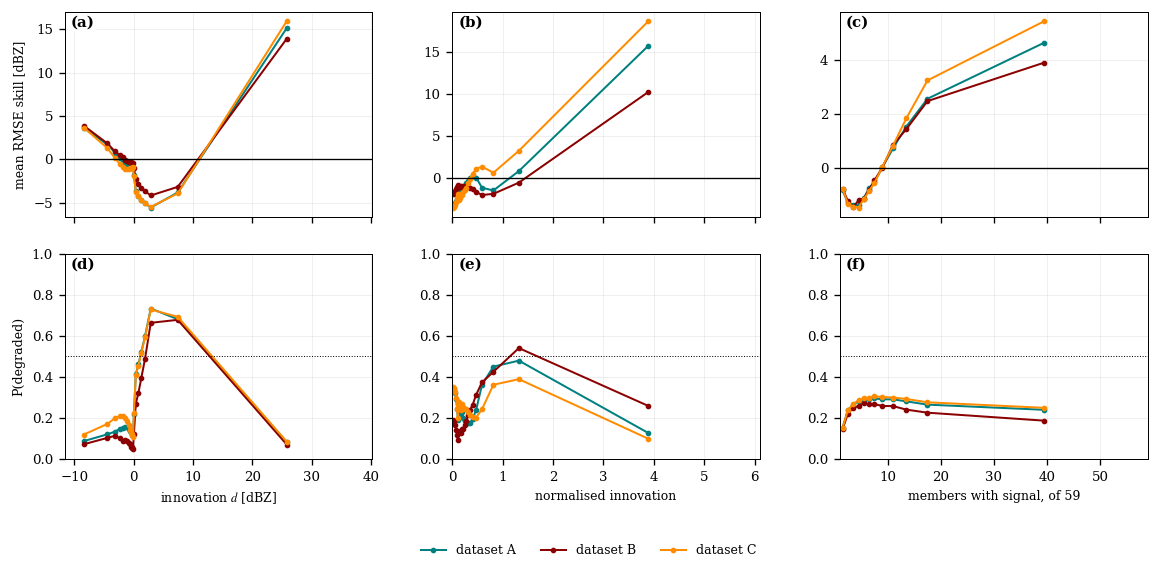

Baseline scheme only (TEnKF Nt=1) -- the scheme axis is the figure above.
Edges are equal-count over a stratified subsample of all three datasets, so the
three lines in a panel sit on the same x grid and a difference between them is a
difference in response and not in binning.


In [19]:
# ── §6 figure 2: the three predictors that discriminate, one line per dataset ──
# The columns are set by hand from the 1-D scan in §7 -- the three predictors whose
# best single rejection interval buys the most out-of-sample skill. §7 re-derives its
# own top three and prints whether they still agree with this list, so the figure
# cannot drift away from the scan that justifies it.
#
# The obvious starting guess was (mean_f_point_obs, dep_b, n_active_f_point). The scan
# rejected it: the prior mean discriminates far more weakly on its own than the
# normalised innovation does (+0.24 against +0.92 dBZ of median out-of-sample gain),
# so norm_innov takes its place. It also carries the x axis of the figure above, and
# that is not a duplication -- there the axis is the SCHEME, here it is the DATASET.
TRIO_1D = ["dep_b", "norm_innov", "n_active_f_point"]
assert all(p in PDS[DATASETS[0]] for p in TRIO_1D), \
    f"TRIO_1D names a predictor that is not carried: {TRIO_1D}"

# Shared edges here, unlike the figure above: three datasets are drawn in ONE panel,
# so they have to be binned identically or the comparison is between three binnings.
TRIO_EDGES = {p: pooled_edges(p) for p in TRIO_1D}

fig, axes = plt.subplots(2, len(TRIO_1D),
                         figsize=(nb.PAGE_W * 1.7, nb.PAGE_W * 0.72),
                         sharex="col", gridspec_kw={"hspace": 0.18, "wspace": 0.26})
for cc, p in enumerate(TRIO_1D):
    edges = TRIO_EDGES[p]
    cen = 0.5 * (edges[:-1] + edges[1:])
    for ds in DATASETS:
        idx, ok = digitize(PDS[ds][p].to_numpy(float), edges)
        s = SKD[(ds, BASE, "rmse")]
        y0, n0 = bin_stat(idx, ok, s, len(cen), stat=BIN_STAT)
        y1, _ = p_degraded(idx, ok, s, len(cen))
        axes[0, cc].plot(cen, y0, "-o", ms=2.4, lw=1.2, color=DS_COLORS[ds],
                         label=f"dataset {ds}")
        axes[1, cc].plot(cen, y1, "-o", ms=2.4, lw=1.2, color=DS_COLORS[ds])
        del idx, ok
    axes[0, cc].axhline(0, color="k", lw=0.8)
    axes[1, cc].axhline(0.5, color="k", lw=0.6, ls=":")
    axes[1, cc].set_xlabel(PRED_LABEL.get(p, p), fontsize=7.5)
    axes[1, cc].set_ylim(0, 1)
    axes[0, cc].set_xlim(edges[0], edges[-1])
axes[0, 0].set_ylabel(f"{BIN_STAT} RMSE skill [dBZ]", fontsize=7.5)
axes[1, 0].set_ylabel("P(degraded)", fontsize=7.5)
for a, letter in zip(axes.ravel(), "abcdef"):
    nb.panel_label(a, letter)
h_, l_ = axes[0, 0].get_legend_handles_labels()
fig.legend(h_, l_, loc="lower center", bbox_to_anchor=(0.5, -0.06),
           ncol=len(DATASETS), fontsize=7.5, frameon=False)
nb.save_fig(fig, "N3_1D_fig_mean_skill_vs_predictor")
plt.show()

print(f"Baseline scheme only ({LAB[BASE]}) -- the scheme axis is the figure above.")
print("Edges are equal-count over a stratified subsample of all three datasets, so the")
print("three lines in a panel sit on the same x grid and a difference between them is a")
print("difference in response and not in binning.")

In [20]:
# ── §6 table: deciles of the normalised innovation, per dataset ────────────
# Deciles of norm_innov, baseline scheme, one block per dataset. The mean and the
# median are printed side by side because they disagree in sign across most of this
# table, and only the mean aggregates: the global skill of a subset is its mean times
# its size, which is the arithmetic §7 is built on.
rows = []
for ds in DATASETS:
    v = PDS[ds]["norm_innov"].to_numpy(float)
    qs = np.percentile(v, np.arange(0, 101, 10))
    idx, ok = digitize(v, qs)
    s = SKD[(ds, BASE, "rmse")]
    d, cnt = p_degraded(idx, ok, s, len(qs) - 1, min_count=1)
    me, _ = bin_stat(idx, ok, s, len(qs) - 1, "mean", min_count=1)
    md, _ = bin_stat(idx, ok, s, len(qs) - 1, "median", min_count=1)
    for b in range(len(qs) - 1):
        rows.append({"dataset": ds, "decile": b + 1,
                     "norm_innov lo": qs[b], "norm_innov hi": qs[b + 1],
                     "n_points": int(cnt[b]), "P(degraded) [%]": 100 * d[b],
                     "mean skill [dBZ]": me[b], "median skill [dBZ]": md[b]})
    del v, idx, ok
DECILE3 = pd.DataFrame(rows)
del rows

FF = {"norm_innov lo": "{:.3f}".format, "norm_innov hi": "{:.3f}".format,
      "P(degraded) [%]": "{:.2f}".format, "mean skill [dBZ]": "{:+.3f}".format,
      "median skill [dBZ]": "{:+.3f}".format, "n_points": "{:,d}".format}
print(f"deciles of the normalised innovation -- {LAB[BASE]}, RMSE, "
      f"{nb.RED_LABELS[RED_1D]}, {hours_txt()} pooled:\n")
for ds, g in DECILE3.groupby("dataset", sort=False):
    print(f"── dataset {ds} ─────────────────────────────────────────────────")
    print(g.drop(columns="dataset").to_string(index=False, formatters=FF))
    print()

# The two context numbers the table needs to be readable. `yo_clean` is the noise-free
# observation, so "true echo" is a statement about the truth and not about what the
# filter saw -- which is exactly why it may be reported and may never be used in a
# rejection rule.
ECHO3 = pd.DataFrame([{
    "dataset": ds,
    "n_points": len(PDS[ds]),
    "true echo (yo_clean > dbz_min) [%]":
        100 * float((PDS[ds]["yo_clean"].to_numpy() > DBZ_MIN).mean()),
    "norm_innov > 1 [%]":
        100 * float((PDS[ds]["norm_innov"].to_numpy() > 1).mean()),
    "P(degraded), baseline [%]":
        100 * float((SKD[(ds, BASE, "rmse")] < -TOL).mean()),
} for ds in DATASETS])
print(ECHO3.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print("\nMost observations are clear-air in the TRUTH, so the prior already agrees with")
print("them, |d| is small and the increment is made almost entirely of sampling noise")
print("in the cross-covariance. That is the population the first deciles are made of,")
print("and it is why P(degraded) is highest where the innovation is smallest.")
print("\n'norm_innov > 1' is also the set AOEI inflates -- see §8.")

publish_table("N3_1D_norm_innov_deciles", DECILE3, FF)

deciles of the normalised innovation -- TEnKF Nt=1, RMSE, at obs point, 4 analysis times pooled:

── dataset A ─────────────────────────────────────────────────
 decile norm_innov lo norm_innov hi n_points P(degraded) [%] mean skill [dBZ] median skill [dBZ]
      1         0.000         0.052  218,909           33.73           -3.204             +0.002
      2         0.052         0.098  218,880           29.02           -2.666             +0.024
      3         0.098         0.136  218,914           21.85           -1.882             +0.082
      4         0.136         0.179  218,921           22.30           -1.743             +0.217
      5         0.179         0.228  218,898           21.42           -1.392             +0.442
      6         0.228         0.282  218,931           18.59           -0.801             +0.818
      7         0.282         0.351  218,903           17.53           -0.251             +1.363
      8         0.351         0.469  218,914           19.38   

PosixPath('/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived/N3_1D_norm_innov_deciles.csv')

## 7 · One more condition on an already-filtered observation set

### The rule is an extra QC layer, not a new criterion

Every observation the sweep assimilated has already passed two filters before §6 ever
saw it:

* reflectivity is **censored at `dbz_min = 0 dBZ`** — nothing below the clear-air
  floor is written as an observation at all;
* a point is **skipped when the prior ensemble has nothing to update against** —
  zero prior spread, or an ensemble maximum of zero, which means every member sits on
  the floor and there is no cross-covariance to project an increment along.

That second filter is exactly `n_active_f_point == 0`, and the cell below **asserts**
it rather than describing it: the minimum of `n_active_f_point` is **1** in every
dataset and never 0. A point with no active member is not in the data because current
practice already rejected it.

So the scan below is not a criterion bolted onto an unfiltered network. It asks **how
far up an already-accepted threshold should move**, and every rule it considers is a
continuation of what `_qc_pass` already does. The rule family is current practice with
one more inequality in it.

### Why the observation counts differ between datasets and between hours

It is also why A and B carry **different observation counts on an identical grid**,
and why the count moves from hour to hour inside one dataset: how many points have a
non-degenerate prior is a property of the storm and of the ensemble, not of the
geometry. The cell below prints the per-dataset, per-hour counts once, so that is on
the record before any table divides by them.

### What happens to a rejected point, and why selecting rows *is* the experiment

"No rule" is every point that passed current QC. "With rule" is the same pipeline with
one more condition, so a rejected point was **never in the assimilation** — its
posterior is its prior and its skill is exactly 0, not missing.

N3 marks this kind of section "diagnostic only", on the grounds that removing an
observation also changes the analysis at its neighbours. **That caveat belongs to the
multi-obs runs, not to this one.** This is the *sweep*: every observation is
assimilated on its own, into the same prior, as an independent single-observation
experiment (`METHODOLOGY_CHECKLIST.md` §6). Because each observation is assimilated
independently into the same prior, rejecting one changes the posterior of no other,
and the outcome at each retained point is exactly what a re-run under the rule would
produce. Selecting rows here **is** the experiment.

### The two denominators, and which one is used where

$$\underbrace{\frac{1}{N_\text{all}}\sum_{\text{retained}} s_i}_{\text{fixed
denominator}} \;=\; (\text{retained fraction}) \times
\underbrace{\overline{s}_{\text{retained}}}_{\text{conditional}}$$

They answer different questions and must never share an axis.

**Conditional on retained** is the default *everywhere below* — the summary figure,
the maps, every per-scheme statistic. Rejected points are dropped from the computation
entirely, as if the network had never carried them. It is what the surviving
observing system delivers.

**The fixed denominator** keeps every point, a rejected one contributing 0. It asks
how much improvement *the domain* receives, and it is the only form that aggregates —
the median of a retained subset cannot be combined with a retention fraction at all.
It appears **only in the rule tables, in columns named `global`**, and only where
nothing else will do: two rules that retain different fractions cannot be compared on
a conditional mean, because the one that keeps fewer points outscores the other simply
by keeping the easier ones. It is never plotted, and never set beside a conditional
quantity as though the two were the same number.

`rule_stats()` in the next cell returns both from one retention mask, so no figure can
compute one and label it the other.

### The candidate cuts are physical, never quantiles

A rule quoted as `mean_f <= 2.87 dBZ` is not transferable to another experiment and
not citable in a paper. The candidates are round numbers:

| predictor | from | to | step |
|---|---|---|---|
| `mean_f_point_obs` | 0 | 40 dBZ | 5 |
| `dep_b` | −20 | +20 dBZ | 2 |
| `norm_innov` | 0 | 5 | 0.25 |
| `spread_f_point_obs` | 0 | 20 dBZ | 2 |
| `n_active_f_point` | 0 | 40 | 5 |

with `−∞` and `+∞` added to every grid, so that a one-sided rule ("reject everything
at or below 5 dBZ") is exactly representable instead of being faked with the smallest
candidate.

### Why nothing has to be pruned

The naive scan re-masks 10⁷ points once per candidate box and is hopeless. Instead
each predictor is digitised **once** onto its own candidate lattice; `sum(skill)` and
`count` are accumulated into an N-dimensional histogram whose size is set by the cut
grid and not by the data; that histogram is cumulated along every axis; and then the
total inside any candidate box is 2ᴰ lookups by inclusion–exclusion. One pass over the
points plus an operation on a grid of a few thousand cells prices *every* box, so the
search is exhaustive by construction and there is nothing to prune.

### The two things this section does, and why both are reported

**The parameter exploration** — stages 1, 2 and 3: every predictor alone, every
non-redundant pair, and a third condition only if the second earned it. It answers
*which predictors carry information and how much each combination adds*, and that
ranking is a result in its own right. Every rule there is fitted on the **even** truth
members and scored on the **odd** ones, independently per dataset; the gap between the
in-sample and out-of-sample columns is how much of the apparent improvement was the
scan fitting noise in the fitting half.

**The band criterion** — §7a: no optimiser and no objective function, so it cannot
degenerate towards retaining only the top innovation decile. It reads one curve,
`P(degraded)` against a predictor, and takes the longest contiguous run of bins above
a stated threshold. That interval *is* the rule.

The two answer different questions and both are reported. The band criterion is what
defines the rule the rest of the notebook carries; the scans are what say whether that
predictor was the right axis to write it on.


In [21]:
# ── §7 pre-flight: the QC that already ran ─────────────────────────────────
# The framing of this whole section is that the rule is one MORE condition on an
# already-filtered set, not a new criterion on a raw one. That claim rests on a
# property of the data, so it is asserted here instead of being described in prose:
# the sweep skips a point whose prior ensemble has zero spread or an ensemble maximum
# of zero -- every member on the floor -- and that filter IS n_active_f_point == 0.
# A single surviving point with no active member would make the framing false.
_nmin = {}
for ds in DS_LOAD:
    _nmin[ds] = int(PDS[ds]["n_active_f_point"].min())
    assert _nmin[ds] == 1, (
        f"dataset {ds}: min n_active_f_point = {_nmin[ds]}, expected 1. A 0 would mean "
        f"the zero-spread / all-on-the-floor filter did not run, so the rule below "
        f"would be a new criterion rather than an extra layer; anything above 1 would "
        f"mean it ran at a threshold this section does not know about.")
print("the filter that already ran: min n_active_f_point == "
      + ", ".join(f"{ds} {_nmin[ds]}" for ds in DS_LOAD)
      + " -- never 0, so 'reject when no member has signal' is current practice and "
        "not a proposal.")
del _nmin

# The visible consequence of that filter, printed once so no later table divides by a
# count nobody has seen. A and B share a grid and an hour set and still carry
# different numbers of observations, and the number moves hour to hour inside one
# dataset, because how many points have a non-degenerate prior is a property of the
# storm and the ensemble rather than of the geometry.
OBS_COUNTS = pd.DataFrame([
    {"dataset": ds, "hour": f"{h}Z",
     "n_points": int((HRARR[ds] == h).sum()),
     "per truth member": int(round(int((HRARR[ds] == h).sum()) / N_TM[ds]))}
    for ds in DATASETS for h in DS_HOURS[ds]])
assert OBS_COUNTS.groupby("dataset")["n_points"].sum().reindex(list(DATASETS)).tolist() \
    == [ADS[ds].n_points for ds in DATASETS], \
    "the per-hour counts do not add up to the pooled point count of their dataset"
print(f"\nobservations that passed current QC, {hours_txt()} "
      f"x {len(TMS)} truth members:\n")
print(OBS_COUNTS.pivot(index="hour", columns="dataset", values="n_points")
      .to_string(float_format=lambda v: f"{v:,.0f}"))
print("\nSame grid and same hours in A and B, different counts -- that difference is "
      "the\nQC above at work, and it is why every fraction below is quoted against "
      "its own\ndataset's total and never against a shared one.")


# ── the evaluation denominator, defined once ───────────────────────────────
def rule_stats(skill, keep, tol=TOL):
    """Statistics over the RETAINED points only, plus the fixed-denominator mean.

    `keep` is the boolean retention mask. Returns retained fraction, frac_improved,
    frac_degraded, mean and median over skill[keep], and `global_mean` =
    keep.mean() * mean|kept for the table. Callers label which one they plot.

    The two denominators answer different questions and must never share an axis.
    CONDITIONAL on retained -- everything except `global_mean` -- drops a rejected
    point from the computation entirely, as if the network had never carried it: it
    is what the surviving observing system delivers. The FIXED denominator keeps every
    point, a rejected one contributing skill exactly 0 because it was not assimilated
    and its analysis is its prior: it is how much improvement the DOMAIN receives, and
    it is the only form that aggregates, since half of a rejected point is not a
    number. Both come out of one mask here so that no caller can compute one and
    label it the other.
    """
    s = np.asarray(skill, np.float64)
    k = np.asarray(keep, bool)
    n = int(k.sum())
    ret = n / float(k.size)
    if n == 0:                     # a rule that keeps nothing has no conditional mean
        return dict(retained=0.0, n_kept=0, frac_improved=np.nan,
                    frac_degraded=np.nan, mean=np.nan, median=np.nan, global_mean=0.0)
    sk = s[k]
    mean = float(sk.mean())
    return dict(retained=ret, n_kept=n,
                frac_improved=float((sk > tol).mean()),
                frac_degraded=float((sk < -tol).mean()),
                mean=mean, median=float(np.median(sk)),
                global_mean=ret * mean)


# The identity the fixed-denominator column rests on, checked on a real skill array
# rather than quoted: (retained fraction) x (mean over retained) IS the mean over ALL
# points with the rejected ones contributing 0. If it ever fails, the one column of
# the rule table that aggregates has stopped aggregating.
_rng_rs = np.random.default_rng(SEED)
_s_rs = SKD[(DATASETS[0], BASE, "rmse")].astype(np.float64)
_k_rs = _rng_rs.random(_s_rs.size) < 0.4
_st_rs = rule_stats(_s_rs, _k_rs)
assert np.isclose(_st_rs["global_mean"], np.where(_k_rs, _s_rs, 0.0).mean(),
                  rtol=1e-9, atol=1e-9), \
    (f"global_mean {_st_rs['global_mean']:.9f} is not the fixed-denominator mean "
     f"{np.where(_k_rs, _s_rs, 0.0).mean():.9f}")
print(f"\nrule_stats(): conditional statistics over the retained points, plus one "
      f"fixed-denominator\nmean. The identity retained x mean|kept == mean over all "
      f"(rejected at 0) holds to {abs(_st_rs['global_mean'] - np.where(_k_rs, _s_rs, 0.0).mean()):.2e}.")
del _rng_rs, _s_rs, _k_rs, _st_rs

# ── §7 configuration: the candidate cuts, in physical units ────────────────
# Round numbers, never quantiles. A rule quoted as "reject when the prior mean is at
# or below 2.87 dBZ" cannot be transferred to another experiment or defended in a
# paper; "at or below 5 dBZ" can. +-inf are candidates too, so that a one-sided rule
# is exactly representable rather than faked with the smallest finite candidate.
CUT_GRID = {
    MEAN_F:               np.arange(0.0, 40.001, 5.0),
    "dep_b":              np.arange(-20.0, 20.001, 2.0),
    "norm_innov":         np.arange(0.0, 5.001, 0.25),
    "spread_f_point_obs": np.arange(0.0, 20.001, 2.0),
    "n_active_f_point":   np.arange(0.0, 40.001, 5.0),
}
CUT_GRID = {p: np.concatenate([[-np.inf], g, [np.inf]])
            for p, g in CUT_GRID.items()}
SCAN_PREDS = list(CUT_GRID)

# How the rule reads in prose, and in what unit. Kept next to the grid so that the
# sentence §7 prints and the numbers it prints come from the same place.
RULE_NAME = {MEAN_F: "the prior ensemble mean", "dep_b": "the innovation",
             "norm_innov": "the normalised innovation",
             "spread_f_point_obs": "the prior spread",
             "n_active_f_point": "the number of members with signal"}
RULE_UNIT = {MEAN_F: " dBZ", "dep_b": " dBZ", "norm_innov": "",
             "spread_f_point_obs": " dBZ", "n_active_f_point": ""}

BOX_CHUNK = 4_000_000     # candidate boxes priced per numpy call, to bound memory


def grid_bins(v, g):
    """Bin index of `v` on the value/gap lattice of one candidate grid.

    Bin 2m+1 holds exactly the value g[m]; bin 2m holds the open gap below it, bin 0
    everything below g[0] and bin 2K everything above g[K-1]. A rejection interval
    lo <= v <= hi with lo = g[a] and hi = g[b] is then the contiguous bin range
    [2a+1, 2b+1] -- closed at BOTH ends, with no float tolerance anywhere.

    np.digitize cannot do that. Whichever side it closes, points sitting exactly ON a
    cut fall on the wrong side of one of the two inequalities -- and n_active_f_point
    is an integer count scanned against an integer grid, so those points are most of
    the boundary rather than a rounding curiosity.
    """
    v = np.asarray(v, float)
    b = np.searchsorted(g, v, side="left")            # first index with g[i] >= v
    on = (b < len(g)) & (g[np.minimum(b, len(g) - 1)] == v)
    return (2 * b + on).astype(np.int32)


def n_lattice(p):
    """Number of value/gap bins on predictor p's candidate lattice."""
    return 2 * len(CUT_GRID[p]) + 1


# Digitised once per (dataset, predictor) -- this is the "one pass over the data" the
# whole search strategy rests on. PVEC holds the float64 view the digitisation and the
# direct masks both read; without it every one of the few hundred score_rule() calls
# below re-converts a 7.5 M-row float32 column, which costs more than the scan itself.
PVEC = {(ds, p): PDS[ds][p].to_numpy(np.float64)
        for ds in DS_LOAD for p in SCAN_PREDS}
BINS = {ds: {p: grid_bins(PVEC[(ds, p)], CUT_GRID[p]) for p in SCAN_PREDS}
        for ds in DS_LOAD}
print(f"digitised {len(PVEC)} (dataset, predictor) columns onto the candidate "
      f"lattice ({sum(a.nbytes for a in PVEC.values()) / 1e9:.2f} GB of float64 "
      f"views + {sum(a.nbytes for d in BINS.values() for a in d.values()) / 1e9:.2f} "
      f"GB of int32 bins)")

# Fit on the even truth members, score on the odd ones, per dataset. The truth member
# is the unit of independence throughout this notebook, so the split is on tm and not
# on points: splitting points would put the same storm, the same prior and the same
# noise draw on both sides and the out-of-sample column would mean nothing.
FIT_D, EVA_D = {}, {}
for ds in DS_LOAD:
    FIT_D[ds] = np.isin(TMARR[ds], [t for t in TM_OF[ds] if t % 2 == 0])
    EVA_D[ds] = ~FIT_D[ds]
    assert FIT_D[ds].any() and EVA_D[ds].any(), f"dataset {ds}: empty fit/eval half"


def _cum(a):
    """Zero-padded cumulative sum along every axis: a box total becomes 2^D lookups."""
    c = np.zeros(tuple(n + 1 for n in a.shape))
    c[(slice(1, None),) * a.ndim] = a
    for d in range(a.ndim):
        c = c.cumsum(axis=d)
    return c


def _box_total(C, lo, hi):
    """Inclusion-exclusion total inside the inclusive bin box [lo_d, hi_d]."""
    D = len(lo)
    tot = 0.0
    for mask in range(1 << D):
        idx = tuple((hi[d] + 1) if (mask >> d) & 1 else lo[d] for d in range(D))
        tot = tot + ((-1) ** (D - bin(mask).count("1"))) * C[idx]
    return tot


def _bcast(x, d, D):
    sh = [1] * D
    sh[d] = -1
    return np.asarray(x).reshape(sh)


def lattice_flat(preds, ds, sel):
    """Flat lattice index of the selected points, and the lattice shape."""
    shape = tuple(n_lattice(p) for p in preds)
    flat = BINS[ds][preds[0]][sel].astype(np.int64)
    for p, n in zip(preds[1:], shape[1:]):
        flat = flat * n + BINS[ds][p][sel]
    return flat, shape


def lattice_cum(flat, shape, w=None):
    """Cumulated histogram of counts (w=None) or of sum(skill) over the lattice."""
    size = int(np.prod(shape))
    a = np.bincount(flat, weights=w, minlength=size)[:size]
    return _cum(np.asarray(a, np.float64).reshape(shape))


def _pairs(p):
    """Every (lo, hi) pair of candidate cuts with lo <= hi, as grid indices."""
    return np.triu_indices(len(CUT_GRID[p]))


def best_box(preds, Csum, N, S_tot):
    """The rejection box with the largest global mean skill, over EVERY candidate.

    global mean skill = (S_tot - skill inside the box) / N_all, so maximising it is
    exactly minimising the skill the rejected region contains. Chunked on the first
    axis so that a 3-D scan -- 276^3 = 21 M candidate boxes -- stays inside BOX_CHUNK
    floats per numpy call.
    """
    D = len(preds)
    pa = [_pairs(p) for p in preds]
    tail = int(np.prod([len(pa[d][0]) for d in range(1, D)])) if D > 1 else 1
    step = max(1, BOX_CHUNK // tail)
    lo_t = [_bcast(2 * pa[d][0] + 1, d, D) for d in range(1, D)]
    hi_t = [_bcast(2 * pa[d][1] + 1, d, D) for d in range(1, D)]
    a0, b0 = pa[0]
    best_g, best_cuts = -np.inf, None
    for st in range(0, len(a0), step):
        sl = slice(st, st + step)
        lo = [_bcast(2 * a0[sl] + 1, 0, D)] + lo_t
        hi = [_bcast(2 * b0[sl] + 1, 0, D)] + hi_t
        g = (S_tot - _box_total(Csum, lo, hi)) / N
        k = int(np.argmax(g))
        if float(g.flat[k]) > best_g:
            best_g = float(g.flat[k])
            ij = np.unravel_index(k, g.shape)
            cuts = [(CUT_GRID[preds[0]][a0[st + ij[0]]],
                     CUT_GRID[preds[0]][b0[st + ij[0]]])]
            for d in range(1, D):
                m_ = ij[d]
                cuts.append((CUT_GRID[preds[d]][pa[d][0][m_]],
                             CUT_GRID[preds[d]][pa[d][1][m_]]))
            best_cuts = tuple(cuts)
    return best_cuts, best_g


def rule_mask(rule, ds):
    """True where the rule REJECTS -- every condition satisfied at once.

    Written as plain inequalities on the raw columns, deliberately independent of the
    lattice arithmetic above, so that the two can be checked against each other.
    """
    m = np.ones(len(PDS[ds]), bool)
    for p, (lo, hi) in rule.items():
        v = PVEC[(ds, p)]
        m &= (v >= lo) & (v <= hi)
    return m


def score_rule(rule, ds, c, sel, metric="rmse", skl=None):
    """(retained fraction, global mean skill) of an explicit rule on a selection.

    A rejected point is not removed from the domain -- it is not assimilated, so its
    analysis IS its prior and its skill is exactly 0. The mean therefore divides by
    every point in the selection, rejected ones included.

    `skl` is a {(dataset, scheme): per-point skill} lookup; None means reflectivity.
    §15 passes a state variable's and gets this identical accounting.
    """
    s = SKD[(ds, c, metric)] if skl is None else skl[(ds, c)]
    keep = sel & ~rule_mask(rule, ds)
    N = float(sel.sum())
    return float(keep.sum()) / N, float(s[keep].astype(np.float64).sum()) / N


def _empty(lo, hi):
    """An interval that can hold no finite value.

    The candidate list always has to name SOME interval, so "reject nothing" comes
    back from the scan as a degenerate one -- [-inf, -inf] -- rather than as an absent
    condition. Both the table text and the sentence say so in words instead of
    printing a border no reader could act on.
    """
    return lo == hi and not np.isfinite(lo)


def rule_text(rule):
    """Compact borders for a table cell."""
    if any(_empty(*b) for b in rule.values()):
        return "none (assimilate everything)"
    out = []
    for p, (lo, hi) in rule.items():
        short = p.replace("_f_point_obs", "").replace("_f_point", "").replace("_obs", "")
        if not np.isfinite(lo) and not np.isfinite(hi):
            out.append(f"{short}: any")
        elif not np.isfinite(lo):
            out.append(f"{short}<={hi:g}")
        elif not np.isfinite(hi):
            out.append(f"{short}>={lo:g}")
        else:
            out.append(f"{lo:g}<={short}<={hi:g}")
    return " & ".join(out)


def rule_sentence(rule):
    """The rule in English, generated FROM the dict, so text and numbers cannot drift."""
    if any(_empty(*b) for b in rule.values()):
        return "reject nothing -- assimilate every observation."
    parts = []
    for p, (lo, hi) in rule.items():
        nm, u = RULE_NAME.get(p, p), RULE_UNIT.get(p, "")
        if not np.isfinite(lo) and not np.isfinite(hi):
            parts.append(f"{nm} takes any value")
        elif not np.isfinite(lo):
            parts.append(f"{nm} is at or below {hi:g}{u}")
        elif not np.isfinite(hi):
            parts.append(f"{nm} is at or above {lo:g}{u}")
        else:
            parts.append(f"{nm} lies between {lo:g}{u} and {hi:g}{u}")
    return "reject when " + " and ".join(parts) + "."


def scan(preds, ds, schemes=RULE_COMBOS, metric="rmse", skl=None):
    """Fit the best box on the even truth members, score it on the odd ones."""
    preds = list(preds)
    fsel, esel = FIT_D[ds], EVA_D[ds]
    flat_f, shape = lattice_flat(preds, ds, fsel)
    Nf, Ne_ = float(fsel.sum()), float(esel.sum())
    out = []
    for c in schemes:
        s = SKD[(ds, c, metric)] if skl is None else skl[(ds, c)]
        S_f = float(s[fsel].astype(np.float64).sum())
        Csum_f = lattice_cum(flat_f, shape, s[fsel].astype(np.float64))
        cuts, _ = best_box(preds, Csum_f, Nf, S_f)
        rule = dict(zip(preds, cuts))
        ret_f, g_f = score_rule(rule, ds, c, fsel, metric, skl)
        ret_e, g_e = score_rule(rule, ds, c, esel, metric, skl)
        base_e = float(s[esel].astype(np.float64).sum()) / Ne_
        out.append({"dataset": ds, "scheme": LAB[c], "combo": c,
                    "preds": tuple(preds), "rule": rule, "borders": rule_text(rule),
                    "retained [%]": 100 * ret_e, "no rule": base_e, "with rule": g_e,
                    "gain (out)": g_e - base_e, "gain (in)": g_f - S_f / Nf})
    return out


# ── the check the lattice arithmetic has to pass before anything is believed ──
# The cumulative table and the plain boolean mask are two independent implementations
# of "which points does this box hold". If they disagree, every number in §7 is wrong,
# so they are compared on a real fitted box rather than trusted.
_ds0 = DATASETS[0]
_flat, _shape = lattice_flat(["dep_b"], _ds0, FIT_D[_ds0])
_Ccnt = lattice_cum(_flat, _shape)
_s = SKD[(_ds0, BASE, "rmse")]
_cuts, _ = best_box(["dep_b"], lattice_cum(_flat, _shape,
                                           _s[FIT_D[_ds0]].astype(np.float64)),
                    float(FIT_D[_ds0].sum()),
                    float(_s[FIT_D[_ds0]].astype(np.float64).sum()))
_a = int(np.searchsorted(CUT_GRID["dep_b"], _cuts[0][0]))
_b = int(np.searchsorted(CUT_GRID["dep_b"], _cuts[0][1]))
_lat_n = float(_box_total(_Ccnt, [2 * _a + 1], [2 * _b + 1]))
_msk_n = float((rule_mask({"dep_b": _cuts[0]}, _ds0) & FIT_D[_ds0]).sum())
assert _lat_n == _msk_n, (
    f"the cumulative lattice says {_lat_n:,.0f} points are inside "
    f"{rule_text({'dep_b': _cuts[0]})} and a direct mask says {_msk_n:,.0f}")
print(f"lattice vs direct mask on {rule_text({'dep_b': _cuts[0]})}: "
      f"{_lat_n:,.0f} == {_msk_n:,.0f} points, agreed")
del _ds0, _flat, _shape, _Ccnt, _s, _cuts, _a, _b, _lat_n, _msk_n

print(f"\ncandidate cuts per predictor (round numbers plus +-inf):")
for p in SCAN_PREDS:
    g = CUT_GRID[p][1:-1]
    print(f"  {p:<20s} {len(CUT_GRID[p]):3d} cuts  "
          f"[-inf, {g[0]:g} … {g[-1]:g}, +inf]  step {g[1] - g[0]:g}  ->  "
          f"{len(_pairs(p)[0]):5,d} intervals")
print(f"\nfit / score split, per dataset:")
for ds in DS_LOAD:
    print(f"  {ds}: fit on {len([t for t in TM_OF[ds] if t % 2 == 0])} even members "
          f"({int(FIT_D[ds].sum()):,} points), score on "
          f"{len([t for t in TM_OF[ds] if t % 2 == 1])} odd "
          f"({int(EVA_D[ds].sum()):,} points)")


the filter that already ran: min n_active_f_point == A 1, B 1, C 1, D 1 -- never 0, so 'reject when no member has signal' is current practice and not a proposal.

observations that passed current QC, 4 analysis times x 60 truth members:

dataset       A       B        C
hour                            
18Z      509438  222813  1792517
19Z      539179  216398  1829133
20Z      565426  238785  1945015
21Z      575045  264339  1970938

Same grid and same hours in A and B, different counts -- that difference is the
QC above at work, and it is why every fraction below is quoted against its own
dataset's total and never against a shared one.

rule_stats(): conditional statistics over the retained points, plus one fixed-denominator
mean. The identity retained x mean|kept == mean over all (rejected at 0) holds to 2.78e-17.
digitised 20 (dataset, predictor) columns onto the candidate lattice (0.51 GB of float64 views + 0.26 GB of int32 bins)
lattice vs direct mask on -2<=dep_b<=10: 790,451 == 7

In [22]:
# ── stage 1: every predictor on its own ────────────────────────────────────
# A rejection INTERVAL [lo, hi], not a threshold. "Reject below a threshold" is the
# special case lo = -inf and "reject above one" is hi = +inf, so the data choose the
# shape of the rule instead of the shape being assumed by whoever wrote the cell.
SCAN1 = pd.DataFrame([r for p in SCAN_PREDS for ds in DATASETS
                      for r in scan([p], ds)])
SCAN1["predictor"] = [t[0] for t in SCAN1["preds"]]

FF_SCAN = {"retained [%]": "{:6.2f}".format, "no rule": "{:+.4f}".format,
           "with rule": "{:+.4f}".format, "gain (out)": "{:+.4f}".format,
           "gain (in)": "{:+.4f}".format}
COLS_SCAN = ["dataset", "scheme", "borders", "retained [%]", "no rule", "with rule",
             "gain (out)", "gain (in)"]

print("stage 1 -- one predictor, one rejection interval. Fitted on the even truth")
print("members, every number below scored on the odd ones.\n")
for p, g in SCAN1.groupby("predictor", sort=False):
    print(f"── {p} ──────────────────────────────────────────────")
    print(g[COLS_SCAN].to_string(index=False, formatters=FF_SCAN))
    print()

# Which three predictors discriminate best, on the median out-of-sample gain across
# all (dataset, scheme) cells. §6's TRIO_1D is set by hand from this; the assert is
# what stops the figure and the scan from drifting apart in silence.
RANK1 = (SCAN1.groupby("predictor")["gain (out)"].median()
         .sort_values(ascending=False))
print("median out-of-sample gain per predictor, over all "
      f"{len(DATASETS)} x {len(RULE_COMBOS)} (dataset, scheme) cells:\n")
print(RANK1.to_string(float_format=lambda v: f"{v:+.4f}"))
TOP3 = list(RANK1.index[:3])
if set(TOP3) != set(TRIO_1D):
    print(f"\n!! §6 draws TRIO_1D = {TRIO_1D}")
    print(f"!! the scan ranks    {TOP3} best -- update TRIO_1D in §6 and re-run.")
else:
    print(f"\n§6's TRIO_1D = {TRIO_1D} is the scan's own top three. Nothing to update.")

stage 1 -- one predictor, one rejection interval. Fitted on the even truth
members, every number below scored on the odd ones.

── mean_f_point_obs ──────────────────────────────────────────────
dataset     scheme                      borders retained [%] no rule with rule gain (out) gain (in)
      A TEnKF Nt=1                      mean<=5         9.46 -0.3111   +0.2821    +0.5932   +0.6537
      A TEnKF Nt=2 none (assimilate everything)       100.00 +1.5132   +1.5132    +0.0000   +0.0000
      A TEnKF Nt=3 none (assimilate everything)       100.00 +0.7865   +0.7865    +0.0000   +0.0000
      A       AOEI                      mean<=5         9.46 -0.6668   +0.2440    +0.9108   +0.9493
      B TEnKF Nt=1                      mean<=5         2.68 -0.6252   +0.1000    +0.7252   +0.8791
      B TEnKF Nt=2 none (assimilate everything)       100.00 +0.7047   +0.7047    +0.0000   +0.0000
      B TEnKF Nt=3                      mean<=5         2.68 +0.1461   +0.1551    +0.0090   +0.1678
     

In [23]:
# ── stage 2: every non-redundant pair ──────────────────────────────────────
# All ten pairs are scanned. None of the five is a function of another ON ITS OWN, so
# no pair is redundant in the strict sense -- but norm_innov IS a function of dep_b
# and spread_f_point_obs together, so the pairs that contain norm_innov beside one of
# those two are flagged: they carry less independent information than their two axes
# suggest, and a triple containing all three would carry none at all.
PAIRS_2D = list(itertools.combinations(SCAN_PREDS, 2))
NI_PARTNERS = {"dep_b", "spread_f_point_obs"}


def partly_redundant(pr):
    return "norm_innov" in pr and bool(NI_PARTNERS & set(pr))


t0_scan = time.time()
SCAN2 = pd.DataFrame([r for pr in PAIRS_2D for ds in DATASETS for r in scan(pr, ds)])
SCAN2["pair"] = [" + ".join(t) for t in SCAN2["preds"]]
SCAN2["note"] = ["norm_innov overlaps its partner" if partly_redundant(t) else ""
                 for t in SCAN2["preds"]]
print(f"stage 2 -- {len(PAIRS_2D)} pairs x {len(DATASETS)} datasets x "
      f"{len(RULE_COMBOS)} schemes in {time.time() - t0_scan:.0f} s\n")

RANK2 = (SCAN2.groupby("pair")
         .agg(**{"median gain (out)": ("gain (out)", "median"),
                 "min gain (out)": ("gain (out)", "min"),
                 "median gain (in)": ("gain (in)", "median"),
                 "median retained [%]": ("retained [%]", "median")})
         .sort_values("median gain (out)", ascending=False))
print("pairs ranked by the MEDIAN out-of-sample gain over the 12 (dataset, scheme)")
print("cells. 'min' is the worst cell -- a pair that wins on the median and loses")
print("somewhere is not a transferable rule.\n")
print(RANK2.to_string(float_format=lambda v: f"{v:+.4f}"))

# The pair the common rule is built on. Read off the table rather than named, so a
# re-run on other data re-picks it -- but restricted to the pairs whose two axes are
# NOT algebraically entangled. §6 states the redundancy; taking a partly redundant
# pair as the rule shape because it won by a few thousandths of a dBZ would make that
# statement decoration. The margin it costs is printed, so the choice is visible.
CAND2 = [k for k in RANK2.index if not partly_redundant(tuple(k.split(" + ")))]
RULE_SHAPE = tuple(CAND2[0].split(" + "))
_top = RANK2.index[0]
print(f"\nbest pair overall:      {_top}  "
      f"({RANK2.at[_top, 'median gain (out)']:+.4f})"
      f"{'   <- partly redundant, not used' if partly_redundant(tuple(_top.split(' + '))) else ''}")
print(f"best independent pair:  {' + '.join(RULE_SHAPE)}  "
      f"({RANK2.at[CAND2[0], 'median gain (out)']:+.4f})   <- RULE_SHAPE")
print(f"the entanglement costs {RANK2.at[_top, 'median gain (out)'] - RANK2.at[CAND2[0], 'median gain (out)']:+.4f} "
      f"dBZ of median out-of-sample gain.")
print("\nthe two pairs the physics motivates, for comparison:")
for pr in ((MEAN_F, "dep_b"), ("dep_b", "n_active_f_point")):
    key = " + ".join(pr)
    if key in RANK2.index:
        print(f"  {key:<45s} median gain {RANK2.at[key, 'median gain (out)']:+.4f}")

print(f"\nfitted borders and out-of-sample scores on {' + '.join(RULE_SHAPE)}:\n")
print(SCAN2[SCAN2["pair"] == " + ".join(RULE_SHAPE)][COLS_SCAN]
      .to_string(index=False, formatters=FF_SCAN))

stage 2 -- 10 pairs x 3 datasets x 4 schemes in 5 s

pairs ranked by the MEDIAN out-of-sample gain over the 12 (dataset, scheme)
cells. 'min' is the worst cell -- a pair that wins on the median and loses
somewhere is not a transferable rule.

                                       median gain (out)  min gain (out)  median gain (in)  median retained [%]
pair                                                                                                           
dep_b + norm_innov                               +1.1149         +0.1415           +1.1221             +29.6051
dep_b + n_active_f_point                         +1.1109         +0.1383           +1.1187             +28.8585
dep_b + spread_f_point_obs                       +1.1104         +0.1388           +1.1194             +44.9548
mean_f_point_obs + dep_b                         +1.1096         +0.1397           +1.1180             +28.4557
norm_innov + n_active_f_point                    +0.9419         +0.0720           +0

In [24]:
# ── stage 3: a third condition, only if the second one earned it ───────────
# The gate is explicit and printed: a third axis is scanned only where the best pair
# beat the best single predictor by more than GAIN_EPS in at least one (dataset,
# scheme) cell. Otherwise one condition already carries the structure and a third
# would be fitting tile noise with a straight face.
GAIN_EPS = 0.005          # dBZ of global mean skill -- below this is not a result

best1 = SCAN1.groupby(["dataset", "scheme"])["gain (out)"].max()
best2 = SCAN2.groupby(["dataset", "scheme"])["gain (out)"].max()
LIFT = pd.DataFrame({"best 1-D": best1, "best 2-D": best2})
LIFT["2-D lift"] = LIFT["best 2-D"] - LIFT["best 1-D"]
print("does the second condition buy anything? (out-of-sample gain, dBZ)\n")
print(LIFT.to_string(float_format=lambda v: f"{v:+.4f}"))

RUN_3D = bool((LIFT["2-D lift"] > GAIN_EPS).any())
print(f"\nlargest 2-D lift {LIFT['2-D lift'].max():+.4f} dBZ vs threshold "
      f"{GAIN_EPS:+.4f}  ->  3-D scan {'RUNS' if RUN_3D else 'is SKIPPED'}")

if RUN_3D:
    # The best pair plus each remaining predictor. Not all triples: 10 triples x 3
    # datasets x 4 schemes at 21 M candidate boxes each is minutes of nothing, and the
    # question here is only whether a THIRD condition adds to the pair that won.
    TRIPLES = [RULE_SHAPE + (p,) for p in SCAN_PREDS if p not in RULE_SHAPE]
    t0_scan = time.time()
    SCAN3 = pd.DataFrame([r for tr in TRIPLES for ds in DATASETS for r in scan(tr, ds)])
    SCAN3["triple"] = [" + ".join(t) for t in SCAN3["preds"]]
    print(f"\nstage 3 -- {len(TRIPLES)} triples x {len(DATASETS)} datasets x "
          f"{len(RULE_COMBOS)} schemes in {time.time() - t0_scan:.0f} s\n")
    RANK3 = (SCAN3.groupby("triple")
             .agg(**{"median gain (out)": ("gain (out)", "median"),
                     "min gain (out)": ("gain (out)", "min"),
                     "median gain (in)": ("gain (in)", "median"),
                     "median retained [%]": ("retained [%]", "median")})
             .sort_values("median gain (out)", ascending=False))
    print(RANK3.to_string(float_format=lambda v: f"{v:+.4f}"))
    best3 = SCAN3.groupby(["dataset", "scheme"])["gain (out)"].max()
    LIFT["best 3-D"] = best3
    LIFT["3-D lift"] = LIFT["best 3-D"] - LIFT["best 2-D"]
    print("\nand does the THIRD condition buy anything?\n")
    print(LIFT[["best 2-D", "best 3-D", "3-D lift"]]
          .to_string(float_format=lambda v: f"{v:+.4f}"))
    print(f"\nlargest 3-D lift {LIFT['3-D lift'].max():+.4f} dBZ. Compare it with the")
    print("in-sample column above: a third axis multiplies the candidate count by ~276,")
    print("so it can only fit noise better -- the out-of-sample lift is the one that")
    print("says whether it also fits the physics better.")
else:
    SCAN3, RANK3 = None, None
    print("\nOne condition already carries the structure the pair scan can find, so a")
    print("third would be fitted on the same information with 276x more candidates.")

does the second condition buy anything? (out-of-sample gain, dBZ)

                    best 1-D  best 2-D  2-D lift
dataset scheme                                  
A       AOEI         +1.5887   +1.5986   +0.0099
        TEnKF Nt=1   +1.6006   +1.6109   +0.0104
        TEnKF Nt=2   +0.1415   +0.1642   +0.0227
        TEnKF Nt=3   +0.8885   +0.8941   +0.0055
B       AOEI         +1.2764   +1.2801   +0.0037
        TEnKF Nt=1   +1.2909   +1.2962   +0.0053
        TEnKF Nt=2   +0.1794   +0.1975   +0.0181
        TEnKF Nt=3   +0.6749   +0.6765   +0.0016
C       AOEI         +1.5358   +1.5467   +0.0109
        TEnKF Nt=1   +1.5463   +1.5564   +0.0101
        TEnKF Nt=2   +0.1383   +0.1446   +0.0063
        TEnKF Nt=3   +0.9387   +0.9508   +0.0121

largest 2-D lift +0.0227 dBZ vs threshold +0.0050  ->  3-D scan RUNS

stage 3 -- 3 triples x 3 datasets x 4 schemes in 5 s

                                               median gain (out)  min gain (out)  median gain (in)  median retained [%]
tr

### 7a · The band criterion, which defines the rule

The scans above are a search. A search has an objective, and an objective can be
maximised by a rule nobody would write down: "retain the top innovation decile" scores
well on global mean skill and is not a quality-control criterion. The rule this
notebook carries is therefore **not** the argmax of anything.

Instead: bin a predictor on a fine grid, compute `P(degraded)` per bin, and take as
the **rejection interval the longest contiguous run of bins whose `P(degraded)`
exceeds a threshold**. There is no optimiser and no objective function. The interval
*is* the rule, and it can be read off the picture in the figure below.

### Why signed `dep_b`, and not `norm_innov`

The damaging band sits **just above zero, on the positive side** — where the
observation sees more reflectivity than the prior does. That is the physically
distinct situation: the prior has no echo where the radar has one, so there is
nothing in the ensemble for the increment to project along, and the update is built
almost entirely out of sampling noise in the cross-covariance.

`norm_innov` is `|dep_b| / sqrt(σ_H² + R)`. It takes the **absolute value**, folding
the negative branch onto the positive one. A rule written on it would therefore also
reject innovations near −10 dBZ — the prior has echo where the radar sees none, which
is a different situation and, as the curve below shows, not a damaging one. This is a
physical argument and not a technical detail: an unsigned predictor cannot express
"too much echo in the observation" without also saying "too little".

The `spread` × `norm_innov` plane corroborates it rather than adding to it. There the
band appears as a **diagonal falling to the right**, which is exactly what a fixed
`dep_b` band looks like after dividing by `sqrt(σ_H² + R)`: the same interval, drawn
in coordinates that stretch with the spread. The figure draws that image explicitly.
The two planes show **one object**, and the spread contributes no independent
condition.

### Pooling over schemes

The interval is computed **per dataset with the schemes pooled**: all `(point, scheme)`
pairs enter one `P(degraded)` per bin. Because the schemes share the same points —
`align()` guaranteed it and the load cell asserted it — that pooled probability is
exactly the mean over schemes of the per-scheme `P(degraded)`. It reads as *how often
this bin degrades, taken over the set of methods*.

Printed beside it, as bounds: the **union** (bins above threshold in any scheme) and
the **intersection** (bins above threshold in every scheme). The width between those
two is the width of the choice, and it is visible rather than argued about.

### Thresholds, as an explicit knob

Three are reported: `0.5`; **twice** the dataset's base rate; and **1.5 times** it.
The base rates are 24.5 % in A, 20.7 % in B and 25.5 % in C, so a bin sitting at 0.45
is still nearly double its dataset's base rate even though `0.5` cuts it off — the
relative thresholds are there to catch exactly those shoulders. `0.5` is the one the
rule is quoted at, because "this bin is more likely to be made worse than not" is the
statement a reader can check without knowing the base rate.

### Two safeguards

* a **minimum of 500 points per bin**, with sparse bins treated as **retained**, so
  that ignorance never rejects: three points that all happened to degrade read 1.0,
  and rejecting on that is rejecting out of ignorance;
* **contiguity** — the longest run above threshold — so that an isolated tail bin
  cannot split the interval into pieces and make the rule unstatable in a sentence.

### The diagnostic worth printing

The **per-scheme band width** — the same construction run on each scheme's own
`P(degraded)` curve rather than on the pooled one. Its width is the size of the
population a rejection rule would still have to remove *after* that scheme has run, so
it measures how much of the damaging population tempering has already resolved. That
is the substitution result of §1 — a rule and extra tempering steps buy the same thing
— measured on the predictor axis instead of in aggregate skill, and the table says how
far the substitution actually goes: whether the band closes completely as steps are
added, or narrows to a floor that no number of steps removes.

The band itself is computed on the **fitting half** (even truth members) and the same
construction is run on the evaluation half beside it. With no optimiser there is
nothing to overfit, so the two halves agreeing is a statement about the stability of
the interval rather than about the honesty of a score.


In [25]:
# ── §7a: the band criterion ────────────────────────────────────────────────
# No optimiser, no objective function. best_box() above maximises a score, and a score
# can be maximised by a rule nobody would write down -- "retain the top innovation
# decile" is an excellent maximiser of global mean skill and is not a QC criterion.
# The construction here cannot degenerate that way because it never looks at the
# magnitude of the skill at all: it reads ONE curve, P(degraded) against a predictor,
# and takes the run of bins where that curve sits above a stated threshold.

# Fine grids, still round numbers -- the same reason the candidate cuts are round: a
# band quoted as [-1.87, 7.94] dBZ cannot be transferred to another experiment. 2 dBZ
# on the signed innovation is the primary; the others are run for comparison, at the
# resolution each column can support.
BAND_EDGES = {
    "dep_b":              np.arange(-30.0, 30.001, 2.0),
    MEAN_F:               np.arange(0.0, 50.001, 2.0),
    "norm_innov":         np.arange(0.0, 6.001, 0.25),
    "spread_f_point_obs": np.arange(0.0, 24.001, 1.0),
    "n_active_f_point":   np.arange(0.0, 60.001, 2.0),
}
BAND_PRED = "dep_b"       # the primary predictor: SIGNED, and the markdown says why
BAND_MIN_N = 500          # safeguard 1: a bin this sparse is retained, not judged
BAND_THRESH_MAIN = "0.5"  # the threshold the rule is quoted at
assert BAND_PRED in BAND_EDGES and set(BAND_EDGES) <= set(SCAN_PREDS), \
    "the band grids and the scan predictors have drifted apart"

# Digitised once per (dataset, predictor), for the same reason the scan lattice is:
# the tables below ask for ~120 curves, and re-binning 10.7 M points for each of them
# costs more than every bincount in this cell put together. int32 because the grids
# have tens of bins, not billions.
BAND_BINS = {}
for _ds in DS_LOAD:
    for _p in BAND_EDGES:
        _i, _o = digitize(PVEC[(_ds, _p)], BAND_EDGES[_p])
        BAND_BINS[(_ds, _p)] = (_i.astype(np.int32), _o)
del _ds, _p, _i, _o

# The base rate the two relative thresholds are relative to: P(degraded) of the
# untempered filter over every point of the dataset. Computed, never typed -- the
# markdown quotes 24.5 / 20.7 / 25.5 % and the print below is what keeps that true.
def base_rate(ds, skl=None, tol=None):
    """P(degraded) of the untempered filter over EVERY point of the dataset.

    The denominator of the two relative thresholds. Computed, never typed -- the
    markdown quotes the reflectivity numbers and this is what keeps them true -- and
    parameterised on the skill lookup, because §15 needs the same quantity for `w`
    and it is a completely different number there.
    """
    s = SK_OBS[(ds, BASE)] if skl is None else skl[(ds, BASE)]
    return float((s < (-TOL if tol is None else -tol)).mean())


BASE_RATE = {ds: base_rate(ds) for ds in DS_LOAD}


def band_thresholds(ds, base=None):
    """The three thresholds, as an explicit knob rather than a buried constant."""
    b = BASE_RATE[ds] if base is None else base
    return {"0.5": 0.5, "2x base": 2 * b, "1.5x base": 1.5 * b}


def p_deg_curve(ds, pred, sel, schemes=RULE_COMBOS, skl=None, tol=None):
    """P(degraded) per bin of `pred` over `sel`, pooled over `schemes`.

    Pooling means one probability per bin over all (point, scheme) pairs. The schemes
    share the same points -- align() guaranteed it and the load cell asserted it -- so
    that pooled probability is exactly the mean over schemes of the per-scheme
    P(degraded): "how often this bin degrades, taken over the set of methods". The
    count returned is the number of POINTS in the bin and not of pairs, so the
    min-count safeguard reads in the unit a reader expects.

    `skl` selects WHICH skill is being called degraded -- reflectivity by default,
    a state variable when §15 passes its lookup -- and `tol` is that variable's tie
    tolerance. Everything else, including the min-count safeguard and the contiguity
    rule below, is shared, which is what makes §15 the same construction rather than
    a second one that resembles it.
    """
    e = BAND_EDGES[pred]
    idx, ok = BAND_BINS[(ds, pred)]
    ok = ok & sel
    nbin = len(e) - 1
    i_ok = idx[ok]
    t = TOL if tol is None else tol
    cnt = np.bincount(i_ok, minlength=nbin)[:nbin].astype(float)
    deg = np.zeros(nbin)
    for c in schemes:
        s = SK_OBS[(ds, c)] if skl is None else skl[(ds, c)]
        deg += np.bincount(i_ok, weights=(s[ok] < -t).astype(float),
                           minlength=nbin)[:nbin]
    with np.errstate(invalid="ignore", divide="ignore"):
        p = deg / (cnt * len(schemes))
    return p, cnt, e


def p_deg_curves_by_scheme(ds, pred, sel, schemes=RULE_COMBOS, skl=None, tol=None):
    """The same curve per scheme, for the union / intersection bounds."""
    return {c: p_deg_curve(ds, pred, sel, [c], skl, tol)[0] for c in schemes}


def above_mask(p, cnt, thresh, min_n=BAND_MIN_N):
    """Bins that clear `thresh` on enough points to be believed.

    Safeguard 1, and it is load-bearing: a bin below `min_n` is treated as RETAINED
    whatever its P(degraded) says. Three points that all degraded read 1.0, and
    rejecting on that is rejecting out of ignorance rather than out of evidence.
    """
    return np.isfinite(p) & (p > thresh) & (cnt >= min_n)


def longest_true_run(mask):
    """(start, stop) of the longest contiguous True run; (0, 0) if there is none.

    Safeguard 2. An isolated bin far out in the tail that happens to cross the
    threshold would otherwise split the interval into pieces, and a rule made of
    pieces cannot be stated in a sentence or defended in one.
    """
    best, i, n = (0, 0), 0, len(mask)
    while i < n:
        if mask[i]:
            j = i
            while j < n and mask[j]:
                j += 1
            if j - i > best[1] - best[0]:
                best = (i, j)
            i = j
        else:
            i += 1
    return best


def band_from(mask, e):
    """The closed hull of the longest run, in physical units. None if there is none."""
    a, b = longest_true_run(mask)
    return None if b == a else (float(e[a]), float(e[b]))


def band_txt(b):
    return "none" if b is None else f"[{b[0]:g}, {b[1]:g}]"


def band_width(b):
    return 0.0 if b is None else b[1] - b[0]


# ── the table: every predictor, every threshold, pooled / union / intersection ──
rows = []
for ds in DATASETS:
    for pred in BAND_EDGES:
        p_f, cnt_f, e = p_deg_curve(ds, pred, FIT_D[ds])
        p_e, cnt_e, _ = p_deg_curve(ds, pred, EVA_D[ds])
        per_c = p_deg_curves_by_scheme(ds, pred, FIT_D[ds])
        for tname, thr in band_thresholds(ds).items():
            m_pool = above_mask(p_f, cnt_f, thr)
            per_m = [above_mask(per_c[c], cnt_f, thr) for c in RULE_COMBOS]
            b_pool = band_from(m_pool, e)
            rows.append({
                "dataset": ds, "predictor": pred, "threshold": tname,
                "P(deg) >": thr,
                "band (fit)": band_txt(b_pool),
                "width": band_width(b_pool),
                "band (eval)": band_txt(band_from(above_mask(p_e, cnt_e, thr), e)),
                "union": band_txt(band_from(np.logical_or.reduce(per_m), e)),
                "intersection": band_txt(band_from(np.logical_and.reduce(per_m), e)),
                "bins above": int(m_pool.sum()),
                "bins sparse": int(((cnt_f > 0) & (cnt_f < BAND_MIN_N)).sum()),
                "rejected [%]": (100 * float(rule_mask({pred: b_pool}, ds).mean())
                                 if b_pool is not None else 0.0)})
BAND_TBL = pd.DataFrame(rows)
del rows

print(f"base rate P(degraded), {LAB[BASE]}, every point: "
      + ", ".join(f"{ds} {100 * BASE_RATE[ds]:.1f} %" for ds in DATASETS))
print("thresholds per dataset (0.5 / 2x base / 1.5x base):")
for ds in DATASETS:
    print(f"  {ds}: " + ", ".join(f"{k} = {v:.3f}"
                                  for k, v in band_thresholds(ds).items()))
print(f"\nlongest contiguous run of bins with P(degraded) above the threshold, on at "
      f"least\n{BAND_MIN_N} points per bin. Fitted half; the eval-half column is the "
      f"same construction\nrun on the odd truth members. Schemes pooled: "
      f"{[LAB[c] for c in RULE_COMBOS]}.\n")
FF_BAND = {"P(deg) >": "{:.3f}".format, "width": "{:.2f}".format,
           "rejected [%]": "{:6.2f}".format}
for pred, g in BAND_TBL.groupby("predictor", sort=False):
    star = "  <- the rule is written on this one" if pred == BAND_PRED else ""
    print(f"── {pred}{star} ──────────────────────────────")
    print(g.drop(columns="predictor").to_string(index=False, formatters=FF_BAND))
    print()

# ── the rule the rest of the notebook carries ──────────────────────────────
# One band per dataset, on the signed innovation, at the quoted threshold, fitted on
# the even truth members. Everything downstream that says "the band" means this.
BAND_RULE, BAND_PEAK = {}, {}
for ds in DS_LOAD:
    p_f, cnt_f, e = p_deg_curve(ds, BAND_PRED, FIT_D[ds])
    b = band_from(above_mask(p_f, cnt_f, band_thresholds(ds)[BAND_THRESH_MAIN]), e)
    assert b is not None, (
        f"dataset {ds}: no bin of {BAND_PRED} clears "
        f"{band_thresholds(ds)[BAND_THRESH_MAIN]:.3f} on {BAND_MIN_N}+ points, so the "
        f"band criterion defines no rule here and CANDIDATE_RULES has nothing to score")
    # The longest run has to be the run that holds the PEAK. If the worst
    # well-populated bin sits outside it, the criterion has locked onto a wide shoulder
    # and left the damage outside the rule -- which no caption below would survive.
    kworst = int(np.argmax(np.where(cnt_f >= BAND_MIN_N, p_f, -np.inf)))
    assert b[0] <= e[kworst] and e[kworst + 1] <= b[1], (
        f"dataset {ds}: the band {band_txt(b)} does not contain the worst bin "
        f"[{e[kworst]:g}, {e[kworst + 1]:g}] at P(degraded) = {p_f[kworst]:.3f} -- the "
        f"longest run is not the run that holds the peak")
    BAND_RULE[ds] = {BAND_PRED: b}
    BAND_PEAK[ds] = (float(e[kworst]), float(e[kworst + 1]), float(p_f[kworst]))
    print(f"{ds}: band {band_txt(b)}{RULE_UNIT[BAND_PRED]}, worst bin "
          f"[{e[kworst]:g}, {e[kworst + 1]:g}] at P(degraded) = {p_f[kworst]:.3f}, "
          f"rejects {100 * rule_mask(BAND_RULE[ds], ds).mean():.1f} % of the dataset"
          + ("" if ds in DATASETS else f"   [{DS_CONTRAST}: §16 only]"))

# The sentence below is the physical reading of the band, so it is asserted before it
# is printed rather than after: if a rebuilt ensemble ever put the damaging population
# on the negative side, the paragraph would be false and the notebook would say so.
assert all(BAND_RULE[ds][BAND_PRED][0] >= 0.0 for ds in DATASETS), \
    ("the band no longer sits on the positive side of zero in every dataset: "
     + ", ".join(f"{ds} {band_txt(BAND_RULE[ds][BAND_PRED])}" for ds in DATASETS)
     + " -- the paragraph below is written for a positive band and would be wrong")
print("\nThe band sits on the POSITIVE side of zero -- the observation sees more echo")
print("than the prior does, so there is nothing in the ensemble for the increment to")
print("project along and the update is made of sampling noise in the cross-covariance.")

# ── the substitution diagnostic: how wide is the band, scheme by scheme ─────
# The width of a scheme's own band is how much of the damaging population that scheme
# has NOT already resolved. It is the substitution result of §1 measured on the
# predictor axis instead of in aggregate skill: if tempering and a rejection rule buy
# the same thing, the band has to close as steps are added.
rows = []
for ds in DATASETS:
    _, cnt_f, e = p_deg_curve(ds, BAND_PRED, FIT_D[ds])
    per_c = p_deg_curves_by_scheme(ds, BAND_PRED, FIT_D[ds], ROW_COMBOS)
    thr = band_thresholds(ds)[BAND_THRESH_MAIN]
    for c in ROW_COMBOS:
        b = band_from(above_mask(per_c[c], cnt_f, thr), e)
        rows.append({"dataset": ds, "scheme": LAB[c], "band": band_txt(b),
                     "width [dBZ]": band_width(b),
                     "P(degraded) [%]":
                         100 * float((SKD[(ds, c, "rmse")] < -TOL).mean())})
BAND_BY_SCHEME = pd.DataFrame(rows)
del rows
print(f"\nper-scheme band on {BAND_PRED} at threshold {BAND_THRESH_MAIN} "
      f"(each scheme's OWN curve, not the pooled one):\n")
print(BAND_BY_SCHEME.pivot(index="scheme", columns="dataset", values="width [dBZ]")
      .reindex([LAB[c] for c in ROW_COMBOS])
      .to_string(float_format=lambda v: f"{v:6.1f}"))
print("\nWidth in dBZ of the interval where that scheme is more likely to make a point")
print("worse than not. It is not the overall degraded fraction -- that is the column")
print("beside it in the published table -- it is the size of the population a rejection")
print("rule would still have to remove AFTER that scheme has run. A band that closes")
print("as steps are added is the substitution result on the predictor axis.")

# ── the corroboration from the spread x norm_innov plane, as numbers ────────
# norm_innov = |dep_b| / sqrt(spread^2 + R), so a FIXED band on dep_b maps to a
# norm_innov boundary that falls as the spread grows. That is the diagonal in the
# figure below, and it is why the spread adds no independent condition: the two
# planes are showing one object in two coordinate systems.
_ds0 = DATASETS[0]
_lo, _hi = BAND_RULE[_ds0][BAND_PRED]
print(f"\nthe same band {band_txt((_lo, _hi))} dBZ of dataset {_ds0}, in normalised "
      f"units:\n")
print(pd.DataFrame([{"spread sigma_H [dBZ]": s,
                     "|lo| / sqrt(sigma^2+R)": abs(_lo) / np.sqrt(s ** 2 + R),
                     "|hi| / sqrt(sigma^2+R)": abs(_hi) / np.sqrt(s ** 2 + R)}
                    for s in (1.0, 3.0, 6.0, 10.0, 15.0)])
      .to_string(index=False, float_format=lambda v: f"{v:8.3f}"))
print("\nA fixed dBZ band is a FALLING curve in norm_innov -- the diagonal the figure")
print("below draws on the spread x normalised-innovation panel. It is also why the rule")
print("is written on the SIGNED innovation: norm_innov takes the absolute value, so a")
print("band written on it would reject the -10 dBZ branch too, where the prior has echo")
print("the radar does not see. That is a different situation and, by the dep_b curve")
print("above, not a damaging one.")
del _ds0, _lo, _hi

publish_table("N3_1D_band_criterion", BAND_TBL, FF_BAND)


base rate P(degraded), TEnKF Nt=1, every point: A 24.9 %, B 20.7 %, C 25.4 %
thresholds per dataset (0.5 / 2x base / 1.5x base):
  A: 0.5 = 0.500, 2x base = 0.498, 1.5x base = 0.373
  B: 0.5 = 0.500, 2x base = 0.414, 1.5x base = 0.311
  C: 0.5 = 0.500, 2x base = 0.509, 1.5x base = 0.382

longest contiguous run of bins with P(degraded) above the threshold, on at least
500 points per bin. Fitted half; the eval-half column is the same construction
run on the odd truth members. Schemes pooled: ['TEnKF Nt=1', 'TEnKF Nt=2', 'TEnKF Nt=3', 'AOEI'].

── dep_b  <- the rule is written on this one ──────────────────────────────
dataset threshold P(deg) > band (fit) width band (eval)   union intersection  bins above  bins sparse rejected [%]
      A       0.5    0.500     [2, 8]  6.00      [2, 8]  [2, 8]       [4, 8]           3            7         9.43
      A   2x base    0.498     [2, 8]  6.00      [2, 8]  [2, 8]       [4, 8]           3            7         9.43
      A 1.5x base    0.373    [

PosixPath('/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived/N3_1D_band_criterion.csv')

saved N3_1D_fig10_prob_degraded_planes.pdf / N3_1D_fig10_prob_degraded_planes.png


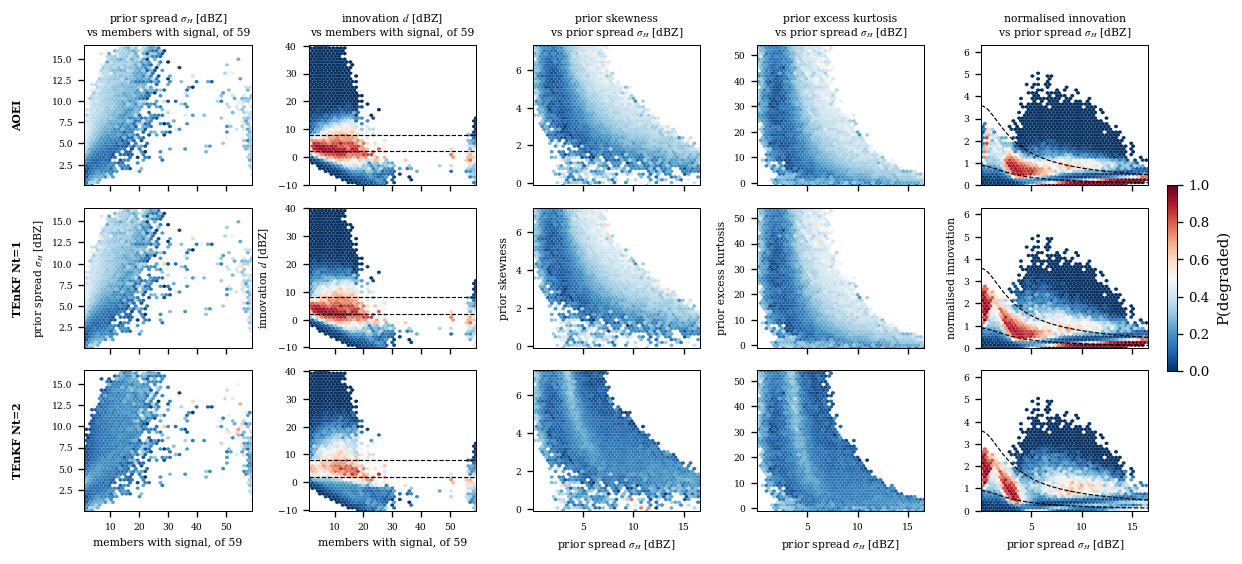

dataset A, 750,000 of 2,189,088 points, 15 s. A column title names the
VERTICAL axis and the label under the column the horizontal one.

A hexbin holding fewer than 30 subsample points (~88 of the full dataset)
is BLANK, not coloured. Four points that all degraded read 1.0 and would paint the
darkest cell in the figure; the isolated near-1.0 cells in the spread x n_active
panel were exactly that, and they invited reading structure where there was
only noise.

Dashed lines: the band [2, 8] dBZ of dataset A, on every panel that carries
dep_b -- and, on the last column, the SAME band as |d| / sqrt(sigma_H^2 + R). It
falls to the right, which is what a fixed dBZ band looks like in normalised
units: the two planes are one object, and the spread contributes no independent
condition to the rule.

Colour is centred on 0.5 -- the quoted threshold -- so red is exactly 'this cell is
more likely to be made worse than not'.

cells drawn per panel: min 787, median 1082, max 1375


In [26]:
# ── §7a figure: P(degraded) over the prior-condition planes, with the band ─
# The picture the band criterion is read off. Three things about it are deliberate.
#
# 1. SPARSE CELLS ARE BLANK, not coloured. A hexbin holding four points that all
#    degraded reads 1.0 and paints the darkest red in the figure; the isolated
#    near-1.0 cells in the spread x n_active panel were exactly that. Colouring them
#    invites reading structure where there is only noise, so they are dropped -- the
#    same safeguard, and the same reason, as BAND_MIN_N in the cell above.
# 2. THE BAND IS DRAWN on every panel that carries dep_b, so the rule and the picture
#    it came from are one figure and not two.
# 3. ONE label per column and one per row. The previous version put an x and a y label
#    on all 55 panels; they ran into each other and into the scheme names.
PLANE_SUB_MAX = 750_000   # points per panel: hexbin's inner loop is pure Python
MIN_HEX_N     = 30        # points per hexbin, IN THE SUBSAMPLE, below which it is blank
HEX_GRID      = 44
PLANE_DS      = DATASETS[0]   # the band table above carries all three; this is one
PLANE_VMAX    = 1.0           # 0.5 -- the quoted threshold -- is the midpoint of RdBu_r

# (x, y) pairs. The last one is the corroboration: a fixed dep_b band drawn in
# normalised units is a falling diagonal, not an independent condition on the spread.
PLANES = [("n_active_f_point",   "spread_f_point_obs"),
          ("n_active_f_point",   "dep_b"),
          ("spread_f_point_obs", "skew_f_point_obs"),
          ("spread_f_point_obs", "kurt_f_point_obs"),
          ("spread_f_point_obs", "norm_innov")]

# One subsample, drawn once and shared by all 55 panels: panels that disagreed because
# they saw different points would not be comparable down a column. Every NUMBER in
# this section uses all points; only this picture is subsampled, and MIN_HEX_N is
# quoted in subsample points so the printout can convert it back.
_rngp = np.random.default_rng(SEED)
NP_DS = len(PDS[PLANE_DS])
SUBP  = np.sort(_rngp.choice(NP_DS, size=min(PLANE_SUB_MAX, NP_DS), replace=False))
del _rngp
PSCALE = NP_DS / len(SUBP)


def plane_vec(ds, p):
    """A predictor column as float64. PVEC only carries the five scanned ones."""
    return (PVEC[(ds, p)] if (ds, p) in PVEC
            else PDS[ds][p].to_numpy(np.float64))


PLIM = {p: tuple(np.percentile(plane_vec(PLANE_DS, p),
                               PRED_CLIP.get(p, (0.5, 99.5))))
        for p in {q for pr in PLANES for q in pr}}
BAND_XY = BAND_RULE[PLANE_DS][BAND_PRED]

limited_row_combos = ROW_COMBOS[0:3]
t0_pl = time.time()
fig, axes = plt.subplots(len(limited_row_combos), len(PLANES),
                         figsize=(nb.PAGE_W * 2,
                                  nb.PAGE_W * 0.25 * len(limited_row_combos)),
                         sharex="col", sharey="col",
                         gridspec_kw={"hspace": 0.16, "wspace": 0.34})
axes = np.atleast_2d(axes)
rows, hb = [], None
for cc, (px, py) in enumerate(PLANES):
    vx, vy = plane_vec(PLANE_DS, px), plane_vec(PLANE_DS, py)
    (xlo, xhi), (ylo, yhi) = PLIM[px], PLIM[py]
    # Masked to the plotted extent BEFORE hexbin rather than by passing `extent`: a
    # point outside the lattice is otherwise resolved onto its edge, and that would
    # pile the tail of a heavy-tailed predictor into the boundary cells.
    inb = ((vx[SUBP] >= xlo) & (vx[SUBP] <= xhi)
           & (vy[SUBP] >= ylo) & (vy[SUBP] <= yhi))
    sx, sy = vx[SUBP][inb], vy[SUBP][inb]
    for r, c in enumerate(limited_row_combos):
        ax = axes[r, cc]
        d = (SKD[(PLANE_DS, c, "rmse")][SUBP][inb] < -TOL).astype(float)
        # hexbin compares with `>`, so MIN_HEX_N - 1 is what asks for "at least
        # MIN_HEX_N points". Cells below it carry NaN and are never drawn.
        hb = ax.hexbin(sx, sy, C=d, reduce_C_function=np.mean,
                       gridsize=HEX_GRID, mincnt=MIN_HEX_N - 1, linewidths=0.0,
                       cmap="RdBu_r", vmin=0.0, vmax=PLANE_VMAX, rasterized=True)
        ax.grid(False)
        ax.set_xlim(xlo, xhi)
        ax.set_ylim(ylo, yhi)
        # The band, on every panel that carries the predictor it is written on.
        if px == BAND_PRED:
            for b_ in BAND_XY:
                ax.axvline(b_, color="k", lw=0.7, ls="--")
        if py == BAND_PRED:
            for b_ in BAND_XY:
                ax.axhline(b_, color="k", lw=0.7, ls="--")
        # The same band in normalised units: |d| / sqrt(sigma^2 + R) falls as the
        # spread grows, which is the diagonal the markdown claims and this draws.
        if (px, py) == ("spread_f_point_obs", "norm_innov"):
            sig = np.linspace(max(xlo, 0.0), xhi, 200)
            for b_ in BAND_XY:
                ax.plot(sig, abs(b_) / np.sqrt(sig ** 2 + R), color="k", lw=0.7,
                        ls="--")
        if r == 0:
            ax.set_title(f"{PRED_LABEL.get(py, py)}\nvs {PRED_LABEL.get(px, px)}",
                         fontsize=6.5)
        if r == len(limited_row_combos) - 1:
            ax.set_xlabel(PRED_LABEL.get(px, px), fontsize=6.5)
        if r == len(limited_row_combos) // 2:
            ax.set_ylabel(PRED_LABEL.get(py, py), fontsize=6.5)
        ax.tick_params(labelsize=5.5)
        if cc == 0:
            ax.text(-0.40, 0.5, LAB[c], transform=ax.transAxes, fontsize=6.5,
                    rotation=90, va="center", ha="center", fontweight="bold")
        # hexbin drops the cells it masked, so the length of its array IS the number
        # of cells that survived MIN_HEX_N.
        rows.append({"plane": f"{py} vs {px}", "scheme": LAB[c],
                     "points drawn": int(inb.sum()),
                     "cells drawn": int(np.asarray(hb.get_array()).size)})
    del vx, vy, sx, sy, inb
PLANES_TBL = pd.DataFrame(rows)
del rows
fig.colorbar(hb, ax=axes, shrink=0.4, pad=0.015, label="P(degraded)")
#fig.suptitle(f"P(degraded) over the prior-condition planes — dataset {PLANE_DS}, "
#             f"{len(SUBP):,}-point subsample", y=0.995, fontsize=8)
nb.save_fig(fig, "N3_1D_fig10_prob_degraded_planes")
plt.show()

print(f"dataset {PLANE_DS}, {len(SUBP):,} of {NP_DS:,} points, {time.time() - t0_pl:.0f} s. "
      f"A column title names the\nVERTICAL axis and the label under the column the "
      f"horizontal one.")
print(f"\nA hexbin holding fewer than {MIN_HEX_N} subsample points "
      f"(~{MIN_HEX_N * PSCALE:.0f} of the full dataset)\nis BLANK, not coloured. "
      f"Four points that all degraded read 1.0 and would paint the\ndarkest cell in "
      f"the figure; the isolated near-1.0 cells in the spread x n_active\npanel were "
      f"exactly that, and they invited reading structure where there was\nonly noise.")
print(f"\nDashed lines: the band {band_txt(BAND_XY)} dBZ of dataset {PLANE_DS}, on "
      f"every panel that carries\ndep_b -- and, on the last column, the SAME band as "
      f"|d| / sqrt(sigma_H^2 + R). It\nfalls to the right, which is what a fixed dBZ "
      f"band looks like in normalised\nunits: the two planes are one object, and the "
      f"spread contributes no independent\ncondition to the rule.")
print(f"\nColour is centred on {PLANE_VMAX / 2:g} -- the quoted threshold -- so red is "
      f"exactly 'this cell is\nmore likely to be made worse than not'.")
print(f"\ncells drawn per panel: min {PLANES_TBL['cells drawn'].min()}, "
      f"median {int(PLANES_TBL['cells drawn'].median())}, "
      f"max {PLANES_TBL['cells drawn'].max()}")


### 7b · Hand-written candidates, scored out of sample

Nothing below is fitted. The borders are **given** — the band from §7a, the median of
the stage-2 fits, and four rules written by hand to test one idea each — and the cell
only scores them, on the odd truth members, across the three datasets and
`TEnKF Nt=1`, `TEnKF Nt=2`, `TEnKF Nt=3` and `AOEI`.

The semantics are **asserted rather than assumed**: a point is REJECTED when it
satisfies **every** clause; clauses combine with **AND**; an absent predictor is
**unconstrained**. Those three sentences are the whole definition of a rule in this
notebook, and the cell checks all three against `rule_mask` before it scores anything.

The columns are the conditional statistics of `rule_stats()` — fraction of *retained*
points improved and degraded, mean and median over the retained — plus the one
fixed-denominator column, the global mean, which answers the other question and is
labelled as such.

### The `n_active` direction, which is counter-intuitive

In a **rejection** rule a clause is a reason to *throw a point away*, so
`n_active_f_point <= 30` means "only reject points with 30 or fewer active members" —
a **lower** threshold **protects more** points. The rule as a whole rejects less as
the number falls.

That is why the "protect" candidates get *weaker* as the number drops, and why
`< 30` is close to inert: with a median `n_active` of 5 / 2 / 5 and a p95 of
19 / 13 / 26, a `<= 30` clause spares only the top few percent of the column. The
marginal table below already priced the equivalent clause at
`+0.0015 / +0.0002 / −0.0002` dBZ. The cell prints the share of points above 10, 15,
20 and 30 beside the true-echo share (11.4 % A, 5.9 % B, 14.1 % C) so the reader can
see how few points any of these clauses can reach.

### The overfitting check

A general rule is **expected to leave degrading points in the retained set**. Rejecting
every point that would have been made worse requires knowing which ones those were,
which is knowing the truth. So a rule that drives the conditional degraded fraction
near zero has not found physics — it has memorised the fitting half, and the
out-of-sample column is where that shows.


In [27]:
# ── §7b: hand-written candidates, scored out of sample ─────────────────────
# No fitting anywhere in this cell. The borders are given and the cell only scores
# them, which is why they can be hand-written round numbers that are not on any
# candidate grid: nothing here searches, so nothing here has a grid to search over.
# "band, pooled" is the only entry that varies by dataset -- it is §7a's band, and it
# was built on the FITTING half, so scoring it on the odd members is out of sample in
# the same sense as everything else in §7.
CANDIDATE_RULES = {
    "band, pooled":       None,   # filled per dataset from BAND_RULE above
    "fitted median":      {"dep_b": (-2, 8)},
    "wide, protected":    {"dep_b": (0, 15), "n_active_f_point": (-np.inf, 30)},
    "wide, unprotected":  {"dep_b": (0, 15)},
    "fitted, protect 15": {"dep_b": (-2, 8), "n_active_f_point": (-np.inf, 15)},
    "fitted, protect 10": {"dep_b": (-2, 8), "n_active_f_point": (-np.inf, 10)},
}


def rule_for(name, ds):
    """The rule a candidate name means for one dataset. Only the band varies."""
    r = CANDIDATE_RULES[name]
    return dict(BAND_RULE[ds]) if r is None else dict(r)


# ── the semantics, asserted rather than assumed ────────────────────────────
# Three sentences define a rule in this notebook, and all three are checked here on
# real columns. Getting any of them backwards would not raise -- it would quietly
# score a different rule than the one the table names.
_ds0 = DATASETS[0]
_r1, _r2 = {"dep_b": (0.0, 15.0)}, {"n_active_f_point": (-np.inf, 30.0)}
_m1, _m2 = rule_mask(_r1, _ds0), rule_mask(_r2, _ds0)
assert np.array_equal(rule_mask(dict(_r1, **_r2), _ds0), _m1 & _m2), \
    "clauses do not combine with AND: a point is rejected only if it satisfies EVERY one"
assert np.array_equal(
    rule_mask(dict(_r1, **{"n_active_f_point": (-np.inf, np.inf)}), _ds0), _m1), \
    "an absent predictor is not unconstrained: adding an open clause changed the mask"
# The direction, made concrete: `n_active <= 30` is a reason to REJECT, so on its own
# it holds almost everywhere. If this ever fails the clause is protecting the opposite
# population from the one the table below claims it protects.
assert _m2.mean() > 0.9, (
    f"`n_active <= 30` holds for only {100 * _m2.mean():.1f} % of dataset {_ds0}; as a "
    f"rejection clause it should hold almost everywhere, since a LOWER threshold "
    f"protects MORE points")
for _nm, _r in CANDIDATE_RULES.items():
    assert _r is None or len(_r) > 0, (
        f"{_nm}: a rule with no clause has nothing to satisfy, so the AND is vacuously "
        f"true and EVERY point would be rejected")
print(f"rule semantics on dataset {_ds0}: REJECT when every clause holds; clauses AND; "
      f"an absent\npredictor is unconstrained. Checked against rule_mask on real "
      f"columns, together with\nthe direction of the n_active clause "
      f"({100 * _m2.mean():.1f} % of points satisfy `n_active <= 30`).")
del _ds0, _r1, _r2, _m1, _m2, _nm, _r

# ── the table ──────────────────────────────────────────────────────────────
# The evaluation-half skill arrays, sliced once. Six rules x three datasets x four
# schemes is 72 cells, and slicing a 10.7 M-row array inside that loop costs more than
# every statistic in the table put together.
EVAL_SK = {(ds, c): SKD[(ds, c, "rmse")][EVA_D[ds]]
           for ds in DATASETS for c in RULE_COMBOS}
# The no-rule reference: the SAME estimator over the population of all QC-passing
# points, which is the population a rule's survivors have to be compared against.
NORULE_ST = {k: rule_stats(v, np.ones(len(v), bool)) for k, v in EVAL_SK.items()}

rows = []
for name in CANDIDATE_RULES:
    for ds in DATASETS:
        rule = rule_for(name, ds)
        keep = ~rule_mask(rule, ds)[EVA_D[ds]]
        for c in RULE_COMBOS:
            st = rule_stats(EVAL_SK[(ds, c)], keep)
            rows.append({
                "rule": name, "borders": rule_text(rule), "dataset": ds,
                "scheme": LAB[c],
                "retained [%]": 100 * st["retained"],
                "frac improved | kept": st["frac_improved"],
                "frac degraded | kept": st["frac_degraded"],
                "mean | kept": st["mean"], "median | kept": st["median"],
                "global mean (fixed denom)": st["global_mean"],
                "no rule, mean | all QC": NORULE_ST[(ds, c)]["mean"]})
CAND_TBL = pd.DataFrame(rows)
del rows

FF_CAND = {"retained [%]": "{:6.2f}".format,
           "frac improved | kept": "{:.4f}".format,
           "frac degraded | kept": "{:.4f}".format,
           "mean | kept": "{:+.4f}".format, "median | kept": "{:+.4f}".format,
           "global mean (fixed denom)": "{:+.4f}".format,
           "no rule, mean | all QC": "{:+.4f}".format}
print(f"\nhand-written candidates, scored on the ODD truth members. Every column is "
      f"CONDITIONAL on\nthe retained points except 'global mean', which keeps every "
      f"point with the rejected\nones at 0 and answers the other question -- how much "
      f"improvement the domain\nreceives. RMSE, {nb.RED_LABELS[RED_1D]}.\n")
for name, g in CAND_TBL.groupby("rule", sort=False):
    print("── " + name + ":  "
          + " | ".join(f"{ds} {g[g.dataset == ds]['borders'].iloc[0]}"
                       for ds in DATASETS))
    print(g.drop(columns=["rule", "borders"]).to_string(index=False,
                                                        formatters=FF_CAND))
    print()

# ── diagnostic 1: what an n_active clause can actually reach ───────────────
# The direction is the whole point. In a REJECTION rule a clause is a reason to throw
# a point away, so `n_active <= T` rejects only points at or below T -- a LOWER
# threshold protects MORE points, and the rule as a whole rejects less. The shares
# below say how few points such a clause reaches at all.
rows = []
for ds in DATASETS:
    v = PVEC[(ds, "n_active_f_point")]
    r = {"dataset": ds, "median n_active": float(np.median(v)),
         "p95 n_active": float(np.percentile(v, 95))}
    for t in (10, 15, 20, 30):
        r[f"n_active > {t} [%]"] = 100 * float((v > t).mean())
    r["true echo (yo_clean > dbz_min) [%]"] = \
        100 * float((PDS[ds]["yo_clean"].to_numpy() > DBZ_MIN).mean())
    rows.append(r)
NACT_TBL = pd.DataFrame(rows)
del rows, v, r
print("what an n_active clause can reach -- and which way it points:\n")
print(NACT_TBL.to_string(index=False, float_format=lambda v: f"{v:8.2f}"))
print("\nIn a rejection rule a LOWER threshold PROTECTS MORE: `n_active <= 30` rejects")
print("only points with 30 or fewer active members, so it spares the top few percent of")
print("the column and nothing else. Compare those shares with the true-echo share beside")
print("them -- a clause meant to protect the echo has to reach it first. The marginal")
print("table below prices the equivalent clause at a few ten-thousandths of a dBZ, which")
print("is the same statement arrived at from the other side.")

# ── diagnostic 2: the overfitting check ────────────────────────────────────
# A GENERAL rule is expected to leave degrading points in the retained set: rejecting
# every point that would have been made worse requires knowing which ones those were,
# which is knowing the truth. A conditional degraded fraction near zero is therefore
# not a good rule but a memorised one -- and the out-of-sample column is where it shows.
OVERFIT = (CAND_TBL.groupby(["rule", "dataset"], sort=False)
           .agg(**{"min frac degraded | kept": ("frac degraded | kept", "min"),
                   "median frac degraded | kept": ("frac degraded | kept", "median"),
                   "median retained [%]": ("retained [%]", "median")})
           .reset_index())
OVERFIT["base rate"] = [BASE_RATE[d] for d in OVERFIT["dataset"]]
OVERFIT["vs base"] = OVERFIT["median frac degraded | kept"] / OVERFIT["base rate"]
print("\noverfitting check -- how much degradation each rule LEAVES BEHIND, out of "
      "sample:\n")
print(OVERFIT.to_string(index=False, float_format=lambda v: f"{v:8.4f}"))
_susp = OVERFIT[OVERFIT["vs base"] < 0.1]
if len(_susp):
    print(f"\n!! {len(_susp)} (rule, dataset) cells retain a population that degrades "
          f"less than a tenth as\n!! often as the dataset's base rate. Out of sample "
          f"that is a strong claim; check it\n!! against the retained fraction beside "
          f"it before quoting it.")
    print(_susp.to_string(index=False, float_format=lambda v: f"{v:8.4f}"))
else:
    print("\nEvery candidate leaves a retained population that still degrades an "
          "appreciable\nfraction of the time -- which is what a general rule should do. "
          "None of them has\nmemorised the fitting half.")
del _susp, EVAL_SK, NORULE_ST
gc.collect()

publish_table("N3_1D_candidate_rules", CAND_TBL, FF_CAND)


rule semantics on dataset A: REJECT when every clause holds; clauses AND; an absent
predictor is unconstrained. Checked against rule_mask on real columns, together with
the direction of the n_active clause (97.8 % of points satisfy `n_active <= 30`).

hand-written candidates, scored on the ODD truth members. Every column is CONDITIONAL on
the retained points except 'global mean', which keeps every point with the rejected
ones at 0 and answers the other question -- how much improvement the domain
receives. RMSE, at obs point.

── band, pooled:  A 2<=dep_b<=8 | B 2<=dep_b<=6 | C 2<=dep_b<=10
dataset     scheme retained [%] frac improved | kept frac degraded | kept mean | kept median | kept global mean (fixed denom) no rule, mean | all QC
      A TEnKF Nt=1        90.43               0.7733               0.1997     +0.2106       +0.2159                   +0.1904                -0.3111
      A TEnKF Nt=2        90.43               0.8595               0.1134     +1.7576       +0.4581      

PosixPath('/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived/N3_1D_candidate_rules.csv')

### 7c · One rule for all three datasets

Twelve fitted rules are twelve results, not one rule. A rule that has to be re-fitted
for every ensemble source and every scheme has not been learned — it has been
memorised, and the next experiment gets nothing from it.

So the section ends with a **single** rejection rule, applied unchanged to all three
datasets and all four schemes, and the table below prints what it costs. The gap
between a dataset's own fitted rule and the common rule *on that dataset* is the price
of transferability, and that gap — not the per-dataset optimum — is the number worth
quoting.

The rule's borders live in a dict at the top of the next cell, built from the **three
per-dataset bands** of §7a and **meant to be edited by hand** once the tables above
are on screen: a rule chosen by a person, in round numbers, defensible in one sentence,
is the deliverable. The cell computes two initialisations and prints both — the median
of the three bands, and the median of the twelve stage-2 fits — so that a hand-set
value which agrees with neither is visible as a choice rather than as a slip. The
sentence itself is generated from the dict, so the prose and the numbers cannot drift
apart.

Every column of the final table is conditional on the retained points except one, the
fixed-denominator global mean, which is kept because it is the only statistic that
aggregates and because the rule has to be answerable to the domain as well as to the
observations it keeps.


In [28]:
# ── the common rule ────────────────────────────────────────────────────────
# Common rejection rule, hand-set: the median of the three per-dataset bands of §7a,
# which are [2, 8] in A, [2, 6] in B and [2, 10] in C. Written out rather than taken
# from `band_init` below so that the rule this notebook carries is a number a person
# chose and can defend in one sentence, and so that a re-run which moves the bands
# announces the disagreement instead of silently following them. That announcement is
# the "NOT the band initialisation" line further down; set COMMON_RULE to None to
# follow the median unchanged instead.
#
# ONE clause, on the signed innovation. The stage-2 scan's median rule carries a
# second clause -- `n_active_f_point <= 40` on the 60-member run -- and it is left out
# because 40 of 59 members with signal is above the 95th percentile of the column, so
# it rejects almost nothing the innovation band has not already rejected. The marginal
# table below prices it, and a condition that does no work is a condition a reader has
# to check for nothing.
#
# The lower border is +2 and not -2: the band criterion puts the damaging population
# entirely on the POSITIVE side of zero, where the observation sees more echo than the
# prior. A -2 border would additionally reject innovations the P(degraded) curve says
# are not damaging -- which is the same mistake, in miniature, that writing the rule on
# the unsigned norm_innov would make.
COMMON_RULE = {"dep_b": (2.0, 8.0)}

# ── the two initialisations, computed ──────────────────────────────────────
# The one that DEFINES the rule family: the median of the three per-dataset bands,
# snapped back onto the candidate grid. The band is a criterion, not a fit, so this is
# a median of three descriptions of three datasets and not a median of three optima.
FITS = SCAN2[SCAN2["pair"] == " + ".join(RULE_SHAPE)]


def snap(p, v):
    """Nearest candidate cut, so a median never invents a border off the grid."""
    g = CUT_GRID[p]
    return float(g[int(np.nanargmin(np.abs(g - v)))]) if np.isfinite(v) else float(v)


band_init = {BAND_PRED: (snap(BAND_PRED,
                              np.median([BAND_RULE[ds][BAND_PRED][0]
                                         for ds in DATASETS])),
                         snap(BAND_PRED,
                              np.median([BAND_RULE[ds][BAND_PRED][1]
                                         for ds in DATASETS])))}
print("the three per-dataset bands of §7a:")
for ds in DATASETS:
    print(f"  {ds}: {band_txt(BAND_RULE[ds][BAND_PRED])}"
          f"{RULE_UNIT[BAND_PRED]}   rejects "
          f"{100 * rule_mask(BAND_RULE[ds], ds).mean():5.1f} % of the dataset")
print(f"median of the three, snapped to the candidate grid:  {rule_text(band_init)}")


# ── and the median of the twelve stage-2 fits, for comparison ──────────────
# Two levels, so "the median of the three per-dataset fits" is literally what it says:
# first the median border across the four schemes WITHIN a dataset, then the median of
# those three per-dataset borders. Both are snapped back onto the candidate grid --
# the median of 0 and 5 is 2.5, and 2.5 is not a citable cut. It is printed beside the
# band because the two are arrived at by different routes -- one searches for a
# maximum, the other reads a threshold off a curve -- and their agreement or
# disagreement is a result either way.
def border(p, side, sel):
    """Median of the fitted borders in `sel`, snapped back onto the candidate grid.

    np.median of +-inf is +-inf, and of a mix of -inf and finite cuts it is whichever
    the middle one is -- which is the behaviour wanted: a border only stays open if at
    least half the fits left it open.
    """
    v = [FITS.loc[i, "rule"][p][side] for i in FITS.index[sel]]
    return snap(p, np.median(v))


per_ds, med_rule = {}, {}
for p in RULE_SHAPE:
    per_ds[p] = {ds: (border(p, 0, FITS.dataset == ds),
                      border(p, 1, FITS.dataset == ds)) for ds in DATASETS}
    med_rule[p] = (snap(p, np.median([per_ds[p][ds][0] for ds in DATASETS])),
                   snap(p, np.median([per_ds[p][ds][1] for ds in DATASETS])))

print(f"\nper-dataset borders from the stage-2 scan on {' + '.join(RULE_SHAPE)} "
      f"(median over the\n{len(RULE_COMBOS)} schemes, snapped to the candidate grid):\n")
print(pd.DataFrame({ds: {p: f"[{per_ds[p][ds][0]:g}, {per_ds[p][ds][1]:g}]"
                         for p in RULE_SHAPE} for ds in DATASETS}).to_string())
print(f"\nmedian-of-three fits:  {rule_text(med_rule)}")
if band_init.get(BAND_PRED) == med_rule.get(BAND_PRED):
    print(f"The band criterion and the scan agree on {BAND_PRED} exactly, by two "
          f"different\nroutes -- one reads a threshold off P(degraded), the other "
          f"maximises global mean\nskill over every candidate box.")
else:
    print(f"The two routes DISAGREE on {BAND_PRED}: band {band_txt(band_init[BAND_PRED])}"
          f" against fit "
          f"{band_txt(med_rule.get(BAND_PRED))}. The band is the one\nquoted, because "
          f"it has no objective function to be gamed; the gap is the price of\nnot "
          f"optimising and it belongs in the text.")

RULE_COMMON = dict(band_init) if COMMON_RULE is None else dict(COMMON_RULE)
assert set(RULE_COMMON) <= set(CUT_GRID), \
    f"COMMON_RULE names a predictor with no candidate grid: {set(RULE_COMMON) - set(CUT_GRID)}"
for p, (lo, hi) in RULE_COMMON.items():
    # Every border must BE a candidate cut, or the rule is not on the grid it claims
    # to be on and "round numbers" is a story rather than a property.
    assert lo in set(CUT_GRID[p]) and hi in set(CUT_GRID[p]) and lo <= hi, \
        f"{p}: [{lo}, {hi}] is not an ordered pair of candidate cuts"
print(f"\nin use: {'the band initialisation' if COMMON_RULE is None else 'COMMON_RULE (hand-set)'}"
      f"  ->  {rule_text(RULE_COMMON)}")
if COMMON_RULE is not None and RULE_COMMON != band_init:
    print(f"  ... which is NOT the band initialisation ({rule_text(band_init)}). The")
    print("  difference is deliberate and the tables above are what justify it -- but if")
    print("  they no longer support the choice, this is the line that says so.")
print(f"\n  \"{rule_sentence(RULE_COMMON)}\"\n")

# ── what each condition is actually doing ──────────────────────────────────
# A rule is only as defensible as its least useful clause. Each condition of the
# two-clause stage-2 median is dropped in turn and the rule re-scored: a clause whose
# removal changes neither the retained fraction nor the skill is doing no work, and it
# should come out of the rule rather than out of the reader's patience. This is the
# table the `n_active` paragraph in §7b refers to, priced from the other side.
rows = []
for p_drop in list(med_rule):
    sub = {k: v for k, v in med_rule.items() if k != p_drop}
    for ds in DATASETS:
        s_e = SKD[(ds, BASE, "rmse")][EVA_D[ds]]
        full = rule_stats(s_e, ~rule_mask(med_rule, ds)[EVA_D[ds]])
        part = (rule_stats(s_e, ~rule_mask(sub, ds)[EVA_D[ds]]) if sub
                else rule_stats(s_e, np.ones(len(s_e), bool)))
        rows.append({"condition dropped": p_drop, "dataset": ds,
                     "retained, full rule [%]": 100 * full["retained"],
                     "retained without it [%]": 100 * part["retained"],
                     "mean | kept, full rule": full["mean"],
                     "mean | kept without it": part["mean"],
                     "global mean, full rule": full["global_mean"],
                     "global mean without it": part["global_mean"],
                     "what the clause is worth (global)":
                         full["global_mean"] - part["global_mean"]})
MARGIN_TBL = pd.DataFrame(rows)
del rows
print(f"marginal value of each clause of the STAGE-2 MEDIAN rule "
      f"({rule_text(med_rule)}),\n{LAB[BASE]}, out of sample. Priced on the "
      f"fixed-denominator mean, because that is\nthe only statistic in which two rules "
      f"with different retention are comparable:\n")
print(MARGIN_TBL.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))
print("\nA clause whose removal moves neither column is inert: it is rejecting points")
print("the other clause had already rejected, and it costs a reader a condition to")
print("check for nothing. That is the judgement COMMON_RULE above encodes.\n")

# ── the table this section exists for ──────────────────────────────────────
rows = []
for ds in DATASETS:
    esel = EVA_D[ds]
    keep_c = ~rule_mask(RULE_COMMON, ds)[esel]
    for c in RULE_COMBOS:
        own = FITS[(FITS.dataset == ds) & (FITS.scheme == LAB[c])].iloc[0]
        s_e = SKD[(ds, c, "rmse")][esel]
        st = rule_stats(s_e, keep_c)
        no = rule_stats(s_e, np.ones(len(s_e), bool))
        own_st = rule_stats(s_e, ~rule_mask(own["rule"], ds)[esel])
        rows.append({
            "dataset": ds, "scheme": LAB[c],
            "own rule": own["borders"],
            "own retained [%]": 100 * own_st["retained"],
            "common retained [%]": 100 * st["retained"],
            "frac improved | kept": st["frac_improved"],
            "frac degraded | kept": st["frac_degraded"],
            "mean | kept": st["mean"], "median | kept": st["median"],
            "no rule, mean | all QC": no["mean"],
            # The one fixed-denominator family, and the only one in which two rules
            # that retain different fractions can be compared at all -- which is what
            # 'cost of transfer' has to do. On the conditional mean a rule that keeps
            # a third of the points scores far higher than one that keeps four fifths
            # simply because it kept the easy ones, so pricing transferability there
            # would report the retention difference and call it a cost.
            "own global mean": own_st["global_mean"],
            "common global mean": st["global_mean"],
            "cost of transfer (global)":
                st["global_mean"] - own_st["global_mean"]})
RULE_TBL = pd.DataFrame(rows)
del rows

FF_RULE = {"own retained [%]": "{:6.2f}".format,
           "common retained [%]": "{:6.2f}".format,
           "frac improved | kept": "{:.4f}".format,
           "frac degraded | kept": "{:.4f}".format,
           "mean | kept": "{:+.4f}".format, "median | kept": "{:+.4f}".format,
           "no rule, mean | all QC": "{:+.4f}".format,
           "own global mean": "{:+.4f}".format,
           "common global mean": "{:+.4f}".format,
           "cost of transfer (global)": "{:+.4f}".format}
print(f"one rule for everything: {rule_text(RULE_COMMON)}")
print("Every column is CONDITIONAL on the retained points of the odd truth members --")
print("a rejected point is absent from the computation, as if the network had never")
print("carried it -- except the three 'global' ones, which keep every point with the")
print("rejected ones at 0 and answer the other question: how much improvement the")
print(f"DOMAIN receives. {nb.RED_LABELS[RED_1D]}, RMSE.\n")
print(RULE_TBL.to_string(index=False, formatters=FF_RULE))
print("\n'cost of transfer' = common global mean - own global mean, and it is the number")
print("this subsection exists for: how much is lost by using one rule instead of three.")
print("It is priced on the FIXED denominator on purpose. Two rules that retain different")
print("fractions are not comparable on a conditional mean -- a rule that keeps a third")
print("of the points outscores one that keeps four fifths simply by keeping the easy")
print("ones -- so the conditional columns describe the common rule's own population and")
print("the global ones are what compare it with the alternative.")
print("'no rule, mean | all QC' is the same conditional estimator over every point that")
print("passed current QC: the population the rule's survivors are drawn from.")

# ── what §10 inherits from this section ────────────────────────────────────
# §10 asks where TEMPERING helps, on a plane of two prior predictors. It draws that
# plane on the rule's own two axes rather than on a separately chosen pair, so the
# section that finds the rule and the section that explains the gain are looking at
# the same picture.
PX, PY = RULE_SHAPE


def tile_axes(ax, ex, ey, xlab, ylab, every=3):
    """Label a tile plot drawn on bin-index coordinates.

    The bins are equal-COUNT, so plotting them against the raw value would make the
    tiles wildly unequal in area and squeeze the populated region into a corner --
    the innovation axis runs to +40 dBZ with 90 % of the points below +2. On index
    coordinates every tile carries the same number of observations and the structure
    is actually visible; the tick labels carry the values.
    """
    ax.set_xticks(np.arange(0, len(ex), every))
    ax.set_xticklabels([f"{v:.3g}" for v in ex[::every]], rotation=45, ha="right",
                       fontsize=5.5)
    ax.set_yticks(np.arange(0, len(ey), every))
    ax.set_yticklabels([f"{v:.3g}" for v in ey[::every]], fontsize=5.5)
    ax.set_xlabel(xlab, fontsize=7)
    ax.set_ylabel(ylab, fontsize=7)
    ax.grid(False)


publish_table("N3_1D_rejection_rule", RULE_TBL, FF_RULE)


the three per-dataset bands of §7a:
  A: [2, 8] dBZ   rejects   9.4 % of the dataset
  B: [2, 6] dBZ   rejects  11.5 % of the dataset
  C: [2, 10] dBZ   rejects   9.6 % of the dataset
median of the three, snapped to the candidate grid:  2<=dep_b<=8

per-dataset borders from the stage-2 scan on dep_b + n_active_f_point (median over the
4 schemes, snapped to the candidate grid):

                           A           B           C
dep_b                [-2, 8]     [-2, 8]    [-4, 10]
n_active_f_point  [-inf, 40]  [-inf, 40]  [-inf, 40]

median-of-three fits:  -2<=dep_b<=8 & n_active<=40
The two routes DISAGREE on dep_b: band [2, 8] against fit [-2, 8]. The band is the one
quoted, because it has no objective function to be gamed; the gap is the price of
not optimising and it belongs in the text.

in use: COMMON_RULE (hand-set)  ->  2<=dep_b<=8

  "reject when the innovation lies between 2 dBZ and 8 dBZ."

marginal value of each clause of the STAGE-2 MEDIAN rule (-2<=dep_b<=8 & n_active<=4

PosixPath('/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived/N3_1D_rejection_rule.csv')

## 8 · Where AOEI actually acts, and whether those are the damaging points

AOEI is not a black box here — `src/da/core.py::aoei` is three lines:

$$\tilde R \;=\; \max\!\left(R_0,\; d^2 - \sigma_f^2\right)$$

with `d = yo - mean(H(xf))` and `σ_f² = var(H(xf), ddof=1)`. Both are stored columns
(`dep_b`, `spread_f_point_obs`, the latter written with `ddof=1` in `da/metrics.py`),
so **the inflation is reproducible from the sweep output exactly**, not approximately:
it is active iff `d² > σ_f² + R₀`, which is iff

$$\text{norm\_innov} \;=\; \frac{|d|}{\sqrt{\sigma_f^2+R_0}} \;>\; 1 .$$

That gives a free consistency check. Where AOEI does not inflate, it is a single LETKF
step with `R₀` — the same computation as `TEnKF Nt=1` — so the two analyses must agree
point for point. The cross-tabulation below tests that on **each of the three
datasets**, and if it fails the derived mask is wrong and nothing after it should be
believed.

Then the question you actually want answered: are the inflated points the same points
that give the *other* schemes trouble? The contribution columns are what answer it —
the two rows of a scheme add up to its global mean skill, so they say where that
number comes from rather than merely how large it is inside each set.

In [29]:
# ── §8: the derived AOEI mask, checked against the stored analyses ─────────
# R~ = max(R0, d^2 - sigma_f^2) is active iff norm_innov > 1. Both forms are computed
# and compared, per dataset, because the whole section rests on the mask being right.
AOEI_ON, INFL = {}, {}
rows = []
for ds in DATASETS:
    d64 = PDS[ds]["dep_b"].to_numpy(np.float64)
    s64 = PDS[ds]["spread_f_point_obs"].to_numpy(np.float64)
    r_tilde = np.maximum(R, d64 ** 2 - s64 ** 2)
    AOEI_ON[ds] = r_tilde > R
    INFL[ds] = (r_tilde / R).astype(np.float32)

    # Form 1 against form 2: max(R0, d^2 - s^2) > R0  <=>  |d| / sqrt(s^2 + R0) > 1.
    same_form = float((AOEI_ON[ds] == (PDS[ds]["norm_innov"].to_numpy() > 1)).mean())
    # The check that matters: where the inflation is inactive AOEI is a single LETKF
    # step with R0, which is exactly TEnKF Nt=1, so the two analyses must be identical
    # point for point.
    differs = SKD[(ds, AO, "rmse")] != SKD[(ds, BASE, "rmse")]
    agree = float((AOEI_ON[ds] == differs).mean())
    q = np.percentile(INFL[ds][AOEI_ON[ds]], [50, 90, 99, 100])
    rows.append({"dataset": ds, "n_points": len(d64),
                 "inflated [%]": 100 * float(AOEI_ON[ds].mean()),
                 "== (norm_innov>1) [%]": 100 * same_form,
                 "mask predicts AOEI != Nt=1 [%]": 100 * agree,
                 "R~/R0 median": q[0], "p90": q[1], "p99": q[2], "max": q[3]})
    assert agree > 0.99, (
        f"dataset {ds}: the derived inflation mask predicts where AOEI changes the "
        f"answer for only {100 * agree:.3f} % of points -- §8 is not trustworthy")
    del d64, s64, r_tilde, differs
AOEI_CHK = pd.DataFrame(rows)
del rows
print("the inflation mask, derived from stored columns and checked against the stored "
      "analyses:\n")
print(AOEI_CHK.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("\nColumn 3 checks the algebra (two forms of the same condition); column 4 checks")
print("the DATA (AOEI must equal TEnKF Nt=1 wherever it does not inflate). Both are")
print("100 % or §8 says nothing.")

the inflation mask, derived from stored columns and checked against the stored analyses:

dataset  n_points  inflated [%]  == (norm_innov>1) [%]  mask predicts AOEI != Nt=1 [%]  R~/R0 median     p90     p99     max
      A   2189088         9.510                100.000                          99.999        27.427 228.185 453.641 836.023
      B    942335         8.611                100.000                          99.998         4.179 155.005 434.829 817.161
      C   7537603        10.843                100.000                         100.000        39.774 245.550 452.061 803.968

Column 3 checks the algebra (two forms of the same condition); column 4 checks
the DATA (AOEI must equal TEnKF Nt=1 wherever it does not inflate). Both are
100 % or §8 says nothing.


In [30]:
# ── §8: what the inflated points contribute, per dataset ───────────────────
rows = []
for ds in DATASETS:
    N_ALL = float(len(PDS[ds]))
    for c in RULE_COMBOS:
        s = SKD[(ds, c, "rmse")]
        for name, m in (("R inflated (norm_innov>1)", AOEI_ON[ds]),
                        ("R = R0", ~AOEI_ON[ds])):
            rows.append({
                "set": name, "dataset": ds, "scheme": LAB[c],
                "share of points [%]": 100 * float(m.mean()),
                "P(degraded) [%]": 100 * float((s[m] < -TOL).mean()),
                "mean skill": float(s[m].mean()),
                "median skill": float(np.median(s[m])),
                # NOT a share of the total: the total is near zero for Nt=1, so a
                # percentage of it is meaningless (and enormous). This is the additive
                # contribution -- the two rows of a scheme sum to its global mean skill.
                "contribution [dBZ]": float(s[m].astype(np.float64).sum()) / N_ALL})
AOEI_TBL = pd.DataFrame(rows)
del rows

FF_AOEI = {"share of points [%]": "{:6.3f}".format, "P(degraded) [%]": "{:6.3f}".format,
           "mean skill": "{:+.3f}".format, "median skill": "{:+.3f}".format,
           "contribution [dBZ]": "{:+.4f}".format}
for name, g in AOEI_TBL.groupby("set", sort=False):
    print(f"── {name} ────────────────────────────────────────────────")
    print(g.drop(columns="set").pivot(index="scheme", columns="dataset",
                                      values=["P(degraded) [%]", "mean skill",
                                              "contribution [dBZ]"])
          .reindex([LAB[c] for c in RULE_COMBOS])
          .to_string(float_format=lambda v: f"{v:+.3f}"))
    print()
print("share of points inflated, per dataset: " + ", ".join(
    f"{ds} {100 * float(AOEI_ON[ds].mean()):.2f} %" for ds in DATASETS))
print("\nThe two 'contribution' rows of a scheme add up to its global mean skill, so")
print("they say where that number comes from. Where the untempered filter's inflated")
print("~10 % carries the entire positive contribution and the other ~90 % cancels it,")
print("AOEI and the tempering ladder are attacking the same points by different means.")

publish_table("N3_1D_aoei_by_dataset", AOEI_TBL, FF_AOEI)

── R inflated (norm_innov>1) ────────────────────────────────────────────────
           P(degraded) [%]                 mean skill                contribution [dBZ]              
dataset                  A       B       C          A      B       C                  A      B      C
scheme                                                                                               
TEnKF Nt=1         +26.564 +39.215 +21.777     +9.799 +5.083 +12.155             +0.932 +0.438 +1.318
TEnKF Nt=2         +27.849 +39.785 +24.490    +10.960 +5.781 +13.198             +1.042 +0.498 +1.431
TEnKF Nt=3         +24.246 +38.525 +19.982    +11.299 +5.880 +13.825             +1.075 +0.506 +1.499
AOEI               +17.448 +26.033 +14.184     +6.193 +2.570  +8.779             +0.589 +0.221 +0.952

── R = R0 ────────────────────────────────────────────────
           P(degraded) [%]                 mean skill               contribution [dBZ]              
dataset                  A       B       C     

PosixPath('/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived/N3_1D_aoei_by_dataset.csv')

saved N3_1D_fig14_aoei_active.pdf / N3_1D_fig14_aoei_active.png


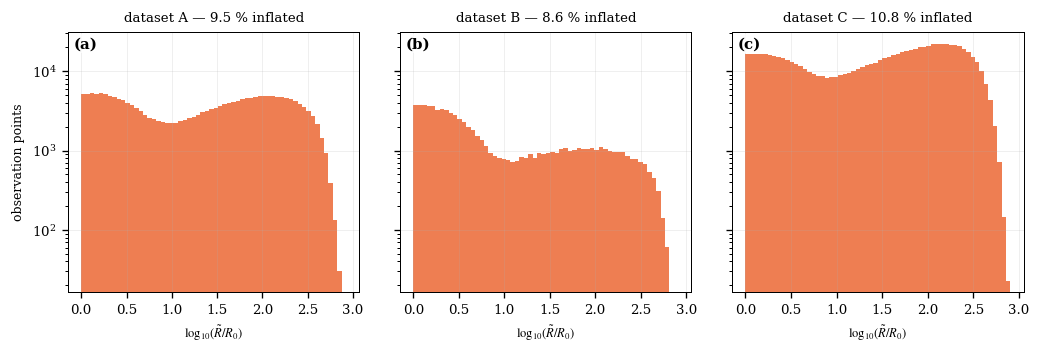

Only the inflated points are drawn: everywhere else R~ = R0 by definition, so
the bar at 1 would hold ~90 % of the domain and say nothing.


In [31]:
# The inflation factor is the one number the table cannot carry: it spans three orders
# of magnitude, so its distribution is drawn per dataset instead of summarised.
fig, axes = plt.subplots(1, len(DATASETS),
                         figsize=(nb.PAGE_W * 1.5, nb.PAGE_W * 0.42),
                         sharey=True, gridspec_kw={"wspace": 0.14})
for ax, ds in zip(np.atleast_1d(axes), DATASETS):
    v = np.log10(INFL[ds][AOEI_ON[ds]])
    ax.hist(v, bins=60, color=nb.METHOD_COLORS["AOEI"], alpha=0.85)
    ax.set_yscale("log")
    ax.set_xlabel(r"$\log_{10}(\tilde R / R_0)$", fontsize=7.5)
    ax.set_title(f"dataset {ds} — {100 * float(AOEI_ON[ds].mean()):.1f} % inflated",
                 fontsize=8)
    del v
np.atleast_1d(axes)[0].set_ylabel("observation points", fontsize=7.5)
for a, letter in zip(np.atleast_1d(axes), "abc"):
    nb.panel_label(a, letter)
nb.save_fig(fig, "N3_1D_fig14_aoei_active")
plt.show()
print("Only the inflated points are drawn: everywhere else R~ = R0 by definition, so")
print("the bar at 1 would hold ~90 % of the domain and say nothing.")

## 9 · What the common rule does, and where

Everything in this section is **conditional on the retained points**. A rejected
observation is dropped from the computation entirely, as if the network had never
carried it — it is not counted as a success and it is not counted as a zero. That is
the denominator §7 argues for and it is the denominator of every panel below.

### Why the previous version of the summary figure had to be rebuilt

Its three panels were computed on the fixed denominator, where two of the three are
pinned by the retention fraction rather than by the analysis:

* the **median** of the global distribution is *exactly* 0 whenever retention falls
  below 50 %, because more than half the points then sit at exactly 0. Under the rule
  that figure was built on — the stage-2 fitted median, retaining 31.9 % in A, 12.4 %
  in B and 37.5 % in C — that is what panel (b) reported, three times, in the shape of
  a skill statistic.
* the **fraction improved** is bounded above by the retained fraction, since a
  rejected point cannot improve. Its fall from 0.80 to 0.30 read as damage done by the
  rule when it was bookkeeping: 0.30 of *all* points was 0.94 of the *retained* ones.

Neither defect depends on which rule is in force — a rule retaining 90 % hides them
rather than fixing them — so the denominator is what changes here, not the rule. Under
the conditional denominator all three panels become meaningful: the fraction of
retained points improved, the fraction degraded, and the mean RMSE skill over the
retained.

### What a no-rule and a rule curve mean when they share a panel

**The rule does not change the analysis at any retained point.** Every observation is
assimilated on its own into the same prior, so removing one changes the posterior of
no other; a point the rule keeps has exactly the analysis it had before. The two
curves are therefore **one estimator over two populations** — all QC-passing points
against the survivors — and not two estimators over one population. A gap between them
is a statement about *which observations are in the network*, never about what the
filter did to any of them.

The error bars are the ones §1 argues for: ±1 s.d. across the truth members, each
member scored on all of its own retained points at once.

### The maps

The columns are **schemes**, not levels. The rule buys the single-step filter most of
what it is worth and buys `TEnKF Nt=2` close to nothing — §7b's table carries the
number for the rule in force — so a with/without pair on `Nt=2` alone would be two
near-identical panels. Setting the two schemes side by side instead shows the result
that matters: **the rule moves the single-step filter to about where tempering already
is.**

The vertical is **pooled** — every model level is an extra sample in its column — and
that costs and buys something specific. Without the rule the pooled field largely
tracks *how much clear air a column holds*, because clear air dominates the
observation set and is where degradation lives; the map is then a map of the
climatology of the network rather than of the analysis. With the rule that clear air
is exactly what was rejected, so the retained population is echo-dominated and the
field regains physical meaning. The comparison between the two columns is what makes
that visible.

A second figure draws the **retained fraction** on the same boxes, so that a pale box
in the map above cannot be confused with an empty one.


per-truth-member conditional statistics for 66 (dataset, scheme, condition) cells in 9 s
saved N3_1D_fig_rule_summary_3ds.pdf / N3_1D_fig_rule_summary_3ds.png


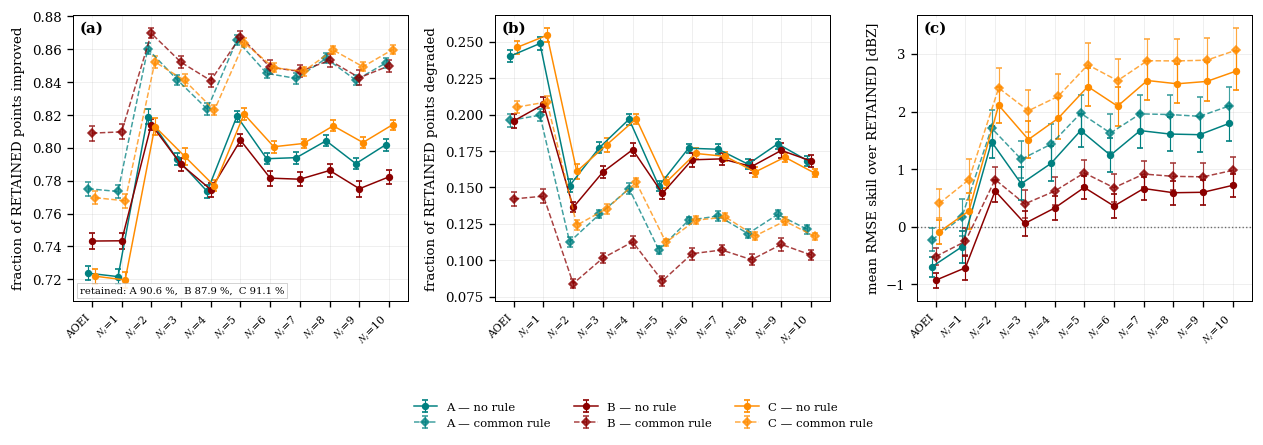

rule: reject when the innovation lies between 2 dBZ and 8 dBZ.
retained: A 90.6 %, B 87.9 %, C 91.1 %

Every panel is CONDITIONAL on the retained points: a rejected observation is
dropped from the computation entirely, as if the network had never carried it.

The rule does not change the analysis at any retained point -- every
observation is assimilated on its own into the same prior, so removing one
changes the posterior of no other. The solid and dashed curves are therefore
ONE estimator over TWO populations: all QC-passing points against the
survivors. A gap between them says which observations are in the network, and
never what the filter did to any of them.

Whiskers are ±1 s.d. across the 60 truth members, each member scored on all of
its own retained points at once, as in §1.

dataset     scheme   condition  retained [%]  frac_improved mean  frac_improved sd_tm  frac_degraded mean  frac_degraded sd_tm  mean_skill mean  mean_skill sd_tm  median_skill mean  median_skill sd_tm
    

In [32]:
# ── §9 figure 1: the common rule against no rule, per scheme and dataset ───
# Same visual grammar as N3_1D_fig1_headline_by_scheme_3ds -- three panels, the scheme
# on the x axis, one colour per dataset -- with a second, dashed marker per scheme for
# the rule. Every quantity is CONDITIONAL on the retained points: a rejected
# observation is absent from the computation, not counted as a zero.
#
# The previous version of this figure used the fixed denominator and two of its three
# panels were measuring retention rather than skill. The median of the global
# distribution is exactly 0 whenever retention falls below 50 %, which it does in all
# three datasets, so that panel reported "more than half the points are not
# assimilated" in the shape of a skill statistic; and frac_improved is bounded above by
# the retained fraction, so its fall read as damage when it was bookkeeping. Both are
# meaningful on this denominator, so the panels are now improved / degraded / mean.
KEEP_C = {ds: ~rule_mask(RULE_COMMON, ds) for ds in DATASETS}


def by_tm_stats(ds, c, keep, metric="rmse"):
    """Conditional statistics per truth member: retained points only.

    The truth member is the unit of independence in this notebook, so the error bar is
    the spread of THIS quantity across members -- each member scored on all of its own
    retained points at once. A member the rule empties has no conditional mean, so it
    contributes NaN rather than a 0 that would drag the mean of the members down and
    call it a result.
    """
    s = SKD[(ds, c, metric)].astype(np.float64)
    code = np.searchsorted(TM_OF[ds], TMARR[ds])
    k = np.asarray(keep, bool)
    ck, sk = code[k], s[k]
    n = np.bincount(ck, minlength=N_TM[ds]).astype(float)
    with np.errstate(invalid="ignore", divide="ignore"):
        mean = np.bincount(ck, weights=sk, minlength=N_TM[ds]) / n
        frac = np.bincount(ck, weights=(sk > TOL).astype(float),
                           minlength=N_TM[ds]) / n
        deg = np.bincount(ck, weights=(sk < -TOL).astype(float),
                          minlength=N_TM[ds]) / n
    med = pd.Series(sk).groupby(ck).median().reindex(range(N_TM[ds])).to_numpy()
    empty = n == 0
    for a in (mean, frac, deg):
        a[empty] = np.nan
    return {"frac_improved": frac, "frac_degraded": deg, "mean_skill": mean,
            "median_skill": med, "n_kept": n}


t0_sum = time.time()
SUMM = {}
for ds in DATASETS:
    for c in ROW_COMBOS:
        SUMM[(ds, c, "no rule")] = by_tm_stats(ds, c, np.ones(len(PDS[ds]), bool))
        SUMM[(ds, c, "common rule")] = by_tm_stats(ds, c, KEEP_C[ds])
print(f"per-truth-member conditional statistics for {len(SUMM)} (dataset, scheme, "
      f"condition) cells in {time.time() - t0_sum:.0f} s")
# No member may be emptied by the rule, or its panel would be an average over a
# different number of members than its neighbour's.
for k_, v_ in SUMM.items():
    assert (v_["n_kept"] > 0).all(), \
        f"{k_}: the rule leaves truth members {list(np.where(v_['n_kept'] == 0)[0])} empty"
del k_, v_

X = np.arange(len(ROW_COMBOS))
MK = {"no rule": ("o", 1.0, "-"), "common rule": ("D", 0.75, "--")}

fig, axes = plt.subplots(1, 3, figsize=(nb.PAGE_W * 1.85, nb.PAGE_W * 0.46),
                         gridspec_kw={"wspace": 0.26})
for ax, (col, ylab, guide) in zip(axes, [
        ("frac_improved", "fraction of RETAINED points improved", None),
        ("frac_degraded", "fraction of RETAINED points degraded", None),
        ("mean_skill",    "mean RMSE skill over RETAINED [dBZ]",  0.0)]):
    if guide is not None:
        ax.axhline(guide, color="0.35", lw=0.8, ls=":", zorder=1)
    for k, ds in enumerate(DATASETS):
        for cond, (mk, alpha, ls) in MK.items():
            v = np.array([np.nanmean(SUMM[(ds, c, cond)][col]) for c in ROW_COMBOS])
            e = np.array([np.nanstd(SUMM[(ds, c, cond)][col], ddof=1)
                          for c in ROW_COMBOS])
            xo = X + (k - 1) * 0.12
            ax.errorbar(xo, v, yerr=e, fmt=mk, ms=3.4, ls=ls, lw=0.9, alpha=alpha,
                        color=DS_COLORS[ds], capsize=1.6, elinewidth=0.7,
                        label=f"{ds} — {cond}" if ax is axes[0] else None)
    ax.set_xticks(X)
    ax.set_xticklabels(ROW_TICKS, rotation=45, ha="right", fontsize=6.5)
    ax.set_ylabel(ylab, fontsize=8)
# The retained fraction, on the figure: every dashed marker is computed over that
# many of its dataset's points, and a reader comparing a dashed marker with a solid
# one has to know it.
axes[0].text(0.02, 0.02, "retained: " + ",  ".join(
    f"{ds} {100 * KEEP_C[ds].mean():.1f} %" for ds in DATASETS),
    transform=axes[0].transAxes, fontsize=6, va="bottom", ha="left",
    bbox=dict(fc="white", ec="0.7", lw=0.4, alpha=0.85, pad=1.8))
for a, letter in zip(axes, "abc"):
    nb.panel_label(a, letter)
h_, l_ = axes[0].get_legend_handles_labels()
fig.legend(h_, l_, loc="lower center", bbox_to_anchor=(0.5, -0.24), ncol=3,
           frameon=False, fontsize=7)
nb.save_fig(fig, "N3_1D_fig_rule_summary_3ds")
plt.show()

print(f"rule: {rule_sentence(RULE_COMMON)}")
print("retained: " + ", ".join(f"{ds} {100 * KEEP_C[ds].mean():.1f} %"
                               for ds in DATASETS))
print("\nEvery panel is CONDITIONAL on the retained points: a rejected observation is")
print("dropped from the computation entirely, as if the network had never carried it.")
print("\nThe rule does not change the analysis at any retained point -- every")
print("observation is assimilated on its own into the same prior, so removing one")
print("changes the posterior of no other. The solid and dashed curves are therefore")
print("ONE estimator over TWO populations: all QC-passing points against the")
print("survivors. A gap between them says which observations are in the network, and")
print("never what the filter did to any of them.")
print("\nWhiskers are ±1 s.d. across the 60 truth members, each member scored on all of")
print("its own retained points at once, as in §1.")

rows = []
for ds in DATASETS:
    for c in ROW_COMBOS:
        for cond in MK:
            r = {"dataset": ds, "scheme": LAB[c], "condition": cond,
                 "retained [%]": 100 * (KEEP_C[ds].mean() if cond == "common rule"
                                        else 1.0)}
            for k_, v_ in SUMM[(ds, c, cond)].items():
                if k_ == "n_kept":       # a count, not a statistic with a spread
                    continue
                r[f"{k_} mean"] = float(np.nanmean(v_))
                r[f"{k_} sd_tm"] = float(np.nanstd(v_, ddof=1))
            rows.append(r)
RULE_SUMMARY = pd.DataFrame(rows)
del rows, r, k_, v_
print()
print(RULE_SUMMARY[RULE_SUMMARY.scheme.isin([LAB[c] for c in RULE_COMBOS])]
      .to_string(index=False, float_format=lambda v: f"{v:+.4f}"))


19 UTC, boxes of 60 km, 11 model levels pooled (0.25 – 12 km):

dataset  dx [km]  obs spacing [km]  grid cells per box  box side [km]  obs columns per box  levels pooled
      A      4.0              39.6                  15           59.5                    1             11
      B      4.0              39.6                  15           59.5                    1             11
      C      2.0              19.8                  30           59.5                    9             11


/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,


saved N3_1D_fig_prob_degraded_maps_3ds.pdf / N3_1D_fig_prob_degraded_maps_3ds.png


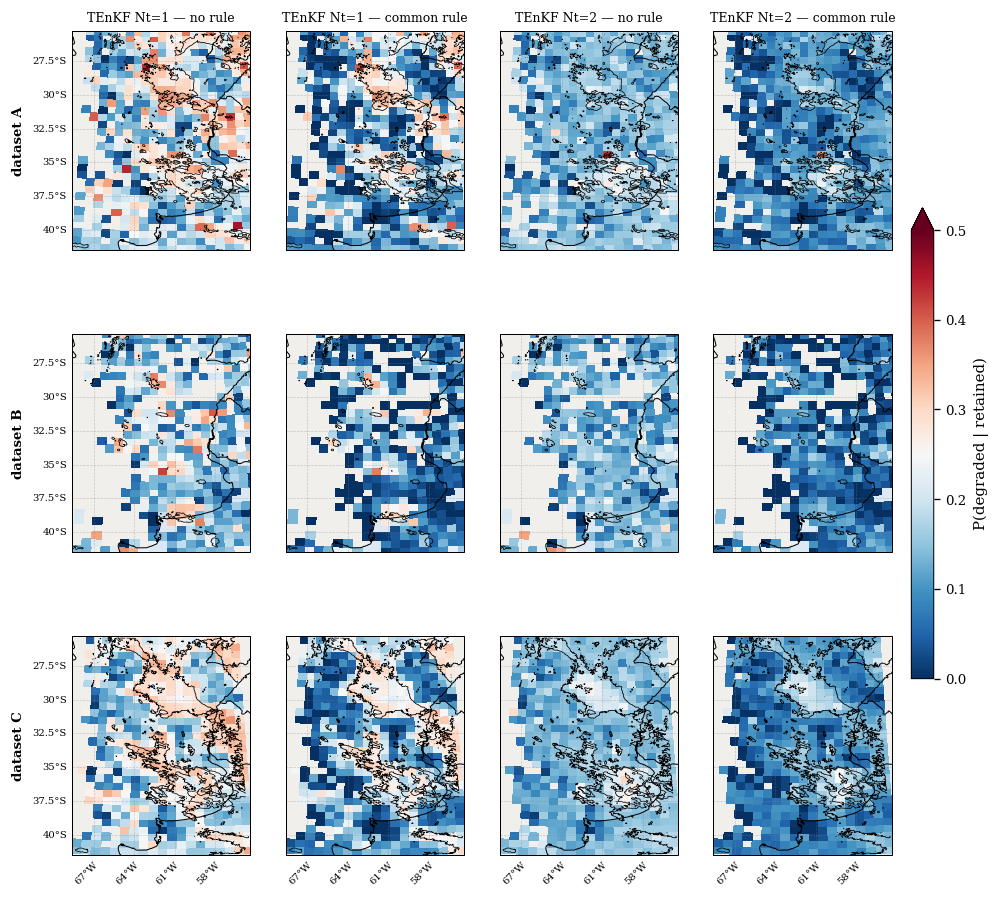

dataset     scheme   condition  points at hour  retained  retained [%]  boxes drawn  boxes masked (n<15)  samples per box (median)  max P(deg|retained)
      A TEnKF Nt=1     no rule          539179    539179       100.000          594                    0                   660.000                0.458
      A TEnKF Nt=1 common rule          539179    487898        90.489          594                    0                   638.500                0.401
      A TEnKF Nt=2     no rule          539179    539179       100.000          594                    0                   660.000                0.423
      A TEnKF Nt=2 common rule          539179    487898        90.489          594                    0                   638.500                0.354
      B TEnKF Nt=1     no rule          216398    216398       100.000          441                    0                   358.000                0.421
      B TEnKF Nt=1 common rule          216398    189081        87.377          441     

In [33]:
# ── §9 figure 2: where the retained observations still degrade ─────────────
import cartopy.crs as ccrs
import matplotlib.colors as mcolors

MAP_HOUR    = "19"                                 # one valid time, not a pooling
# COLUMNS ARE SCHEMES, not levels. The rule buys the single-step filter most of what
# it is worth and buys Nt=2 close to nothing -- §7b's table carries the number -- so a
# with/without pair on Nt=2 alone is two near-identical panels and says nothing.
# Setting the two schemes side by side shows the result instead: the rule moves the
# single-step filter to about where tempering already is.
MAP_SCHEMES = [nb.combo_key(COMBOS, "TEnKF", 1), nb.combo_key(COMBOS, "TEnKF", 2)]
CONTOUR_DBZ = (5.0, 15.0)                          # dBZ, as in the N2 chapter figures
PDEG_VMAX   = 0.5                                  # one colour scale for all 12 panels
MIN_BOX_N   = 15                                   # retained samples a box needs

# ONE physical box size for all three datasets, so a box means the same area in A, B
# and C. The sweep's observation stride is 10 grid points -- ~40 km in A and B, ~20 km
# in C -- so at 60 km a box holds about ONE observation column in A and B and 3 x 3 in
# C. The samples that make a box readable therefore come from the two poolings and not
# from the horizontal: 11 model levels and 60 truth members behind each column. That is
# a further reason the vertical is pooled here, and the printout below reports what the
# box actually achieved rather than asserting it.
BOX_KM = 60.0

# Subset geometry. Under the dataset-first naming a subset is addressed by
# (hour, dataset) and nothing else, so the SUBSET_OF indirection this cell used to
# carry -- a dict mapping a dataset letter onto the directory stem and filename
# suffix its files happened to have -- is gone. nb.subset_path is the only place that
# knows the layout, and nb.assert_dataset checks the file agrees.
GEO, PRIOR = {}, {}
for ds in DATASETS:
    pth = nb.subset_path(MAP_HOUR, ds)
    nb.assert_dataset(pth, ds, what=f"§9 map, dataset {ds}")
    GEO[ds] = nb.load_subset(pth, keys=("lats", "lons", "pos_km"))
    # The contour must be UNIQUE per panel, so it is drawn from the full 60-member
    # ensemble mean and not from the 59 that assimilate -- those depend on which
    # member is the truth, and there are 60 different answers per panel.
    PRIOR[ds] = nb.prior_stats(pth, bbox=None, min_dbz=DBZ_MIN, verbose=False)
    assert int(PRIOR[ds]["Ne"]) == 60, \
        f"dataset {ds}: prior_stats used Ne = {int(PRIOR[ds]['Ne'])}, not the full 60"
    assert float(PRIOR[ds]["min_dbz"]) == DBZ_MIN, \
        f"dataset {ds}: the cached prior_stats used a different dbz_min"

DX = {ds: float(np.median(np.diff(GEO[ds]["pos_km"][:, 0, 0, 0]))) for ds in DATASETS}
BOX_ST = {ds: max(1, int(round(BOX_KM / DX[ds]))) for ds in DATASETS}

# THE VERTICAL IS POOLED: every model level of a column is an extra sample in its box.
# The levels are read off the data, and each one is checked against the subset geometry
# -- the contour comes from pos_km and the points from the sweep, so a level index that
# meant different heights in the two would put the echo in the wrong place.
KLIST = {}
for ds in DATASETS:
    kz = PDS[ds][["k", "z_km"]].drop_duplicates().sort_values("k")
    kk, zz = kz["k"].to_numpy(), kz["z_km"].to_numpy(float)
    zg = GEO[ds]["pos_km"][0, 0, kk, 2]
    assert np.allclose(zz, zg, atol=1e-6), \
        (f"dataset {ds}: levels {list(kk)} are at {list(zz)} km in the sweep and "
         f"{list(zg)} km in the subset geometry")
    KLIST[ds] = kk
assert len({tuple(KLIST[ds]) for ds in DATASETS}) == 1, \
    f"the datasets pool different level sets: {[list(KLIST[ds]) for ds in DATASETS]}"
del kz, kk, zz, zg

# Column maximum of the ensemble-mean reflectivity over exactly the pooled levels.
# The per-level contour of the previous version has no meaning once the vertical is
# pooled; the column maximum is the field the pooled panel is actually about.
DBZ_COL = {ds: PRIOR[ds]["dbz_mean"][:, :, KLIST[ds]].max(axis=2) for ds in DATASETS}

print(f"{MAP_HOUR} UTC, boxes of {BOX_KM:g} km, "
      f"{len(KLIST[DATASETS[0]])} model levels pooled "
      f"({GEO[DATASETS[0]]['pos_km'][0, 0, KLIST[DATASETS[0]][0], 2]:g} – "
      f"{GEO[DATASETS[0]]['pos_km'][0, 0, KLIST[DATASETS[0]][-1], 2]:g} km):\n")
print(pd.DataFrame([{"dataset": ds, "dx [km]": DX[ds],
                     "obs spacing [km]": 10 * DX[ds],
                     "grid cells per box": BOX_ST[ds],
                     "box side [km]": BOX_ST[ds] * DX[ds],
                     "obs columns per box": (BOX_ST[ds] // 10) ** 2,
                     "levels pooled": len(KLIST[ds])}
                    for ds in DATASETS]).to_string(index=False,
                                                   float_format=lambda v: f"{v:.1f}"))

# Box index of every point, and the hour mask, cached once: twelve panels x three
# datasets would otherwise re-derive the same integer division twelve times over.
BOXG, BOXFLAT, AT_HOUR = {}, {}, {}
for ds in DATASETS:
    st = BOX_ST[ds]
    ny, nx = GEO[ds]["lats"].shape
    nbi, nbj = -(-nx // st), -(-ny // st)
    # nb.map_field resolves an (nx, ny) field against an (ny, nx) lat/lon grid by
    # comparing shapes, which is ambiguous only if the two box counts are equal.
    assert nbi != nbj, (
        f"dataset {ds}: {nbi} x {nbj} boxes -- a square box grid makes the field "
        f"orientation ambiguous in nb.map_field; change BOX_KM")
    ic = np.clip(((np.arange(nbi) + 0.5) * st).astype(int), 0, nx - 1)
    jc = np.clip(((np.arange(nbj) + 0.5) * st).astype(int), 0, ny - 1)
    BOXG[ds] = (nbi, nbj, GEO[ds]["lats"][np.ix_(jc, ic)],
                GEO[ds]["lons"][np.ix_(jc, ic)])
    BOXFLAT[ds] = ((PDS[ds]["i"].to_numpy() // st) * nbj
                   + (PDS[ds]["j"].to_numpy() // st))
    AT_HOUR[ds] = (HRARR[ds] == MAP_HOUR)
del st, ny, nx, nbi, nbj, ic, jc


def box_stats(ds, combo, keep):
    """Per box, at MAP_HOUR with the vertical pooled: P(degraded | retained) and the
    retained fraction.

    Only assimilated points enter the probability: a rejected observation has no
    analysis of its own, so it is ABSENT from the count rather than counted as a
    success. The retained fraction is the same box's kept points over ALL of its
    QC-passing points, which is what the companion figure draws -- and it is why a
    pale box there cannot be confused with an empty one here.
    """
    nbi, nbj, blat, blon = BOXG[ds]
    nbox = nbi * nbj
    at, sel = AT_HOUR[ds], AT_HOUR[ds] & keep
    n_all = np.bincount(BOXFLAT[ds][at], minlength=nbox)[:nbox].astype(float)
    n_keep = np.bincount(BOXFLAT[ds][sel], minlength=nbox)[:nbox].astype(float)
    d = np.bincount(BOXFLAT[ds][sel],
                    weights=(SKD[(ds, combo, "rmse")][sel] < -TOL),
                    minlength=nbox)[:nbox]
    with np.errstate(invalid="ignore", divide="ignore"):
        p, ret = d / n_keep, n_keep / n_all
    p[n_keep < MIN_BOX_N] = np.nan
    ret[n_all < MIN_BOX_N] = np.nan
    # Two different absences, drawn differently. A box the rule emptied is grey --
    # that is the informative one, and hiding it would flatter the rule. A box the
    # observation network never reached stays transparent, because the rule did
    # nothing there and painting it grey would claim that it had.
    few = np.where((n_all > 0) & (n_keep < MIN_BOX_N), 1.0, np.nan)
    return tuple(a.reshape(nbi, nbj) for a in (p, ret, few, n_all, n_keep)) \
        + (blat, blon)


CMAP_PD = "RdBu_r"
CMAP_FEW = mcolors.ListedColormap(["#9a9a9a"])   # distinct from the map's zero

PANELS = [(c, cond) for c in MAP_SCHEMES for cond in ("no rule", "common rule")]
fig, axes = plt.subplots(len(DATASETS), len(PANELS),
                         figsize=(nb.PAGE_W * 1.55, nb.PAGE_W * 0.46 * len(DATASETS)),
                         subplot_kw=dict(projection=ccrs.PlateCarree()))
axes = np.atleast_2d(axes)
rows, pm = [], None
for r, ds in enumerate(DATASETS):
    keep_of = {"no rule": np.ones(len(PDS[ds]), bool), "common rule": KEEP_C[ds]}
    for cc, (combo, cond) in enumerate(PANELS):
        ax = axes[r, cc]
        nb.setup_map(ax, xlocs=[-67, -64, -61, -58],
                     ylocs=[-27.5, -30, -32.5, -35, -37.5, -40],
                     left_labels=(cc == 0), bottom_labels=(r == len(DATASETS) - 1))
        p, ret, few, n_all, n_keep, blat, blon = box_stats(ds, combo, keep_of[cond])
        nb.map_field(ax, blat, blon, np.ma.masked_invalid(few), cmap=CMAP_FEW,
                     vmin=0.0, vmax=1.0, transform=ccrs.PlateCarree())
        pm = nb.map_field(ax, blat, blon, np.ma.masked_invalid(p),
                          cmap=CMAP_PD, vmin=0.0, vmax=PDEG_VMAX,
                          transform=ccrs.PlateCarree())
        ax.contour(GEO[ds]["lons"], GEO[ds]["lats"], DBZ_COL[ds].T,
                   levels=list(CONTOUR_DBZ), colors="black", linewidths=0.45,
                   transform=ccrs.PlateCarree())
        if r == 0:
            ax.set_title(f"{LAB[combo]} — {cond}", fontsize=7.5)
        if cc == 0:
            ax.text(-0.30, 0.5, f"dataset {ds}", transform=ax.transAxes, fontsize=8,
                    rotation=90, va="center", ha="center", fontweight="bold")
        drawn = int(np.isfinite(p).sum())
        rows.append({"dataset": ds, "scheme": LAB[combo], "condition": cond,
                     "points at hour": int(n_all.sum()),
                     "retained": int(n_keep.sum()),
                     "retained [%]": 100 * n_keep.sum() / max(n_all.sum(), 1),
                     "boxes drawn": drawn,
                     # boxes that hold observations but too few RETAINED ones to judge
                     f"boxes masked (n<{MIN_BOX_N})": int((n_all > 0).sum()) - drawn,
                     "samples per box (median)":
                         float(np.median(n_keep[n_keep >= MIN_BOX_N])) if drawn else np.nan,
                     "max P(deg|retained)":
                         float(np.nanmax(p)) if drawn else np.nan})
MAPS_TBL = pd.DataFrame(rows)
del rows
fig.colorbar(pm, ax=axes, shrink=0.55, pad=0.02, extend="max",
             label="P(degraded | retained)")
nb.save_fig(fig, "N3_1D_fig_prob_degraded_maps_3ds")
plt.show()

print(MAPS_TBL.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("\nColour is P(degraded | retained) -- computed ONLY over the observations that")
print("were actually assimilated. A rejected point has no analysis of its own and is")
print("absent from the count, not counted as a success.")
print("\nThe rule does not change the analysis at any retained point, so a 'no rule'")
print("panel and the 'common rule' panel beside it are ONE estimator over TWO")
print("populations: all QC-passing points against the survivors. The difference between")
print("them is a difference in which observations are in the network.")
print(f"\nTHE VERTICAL IS POOLED -- {len(KLIST[DATASETS[0]])} model levels, each an "
      f"extra sample in its box.\nThat costs and buys something specific. Without the "
      f"rule the pooled field largely\ntracks how much CLEAR AIR a column holds, since "
      f"clear air dominates the observation\nset and is where degradation lives, so the "
      f"map is closer to a climatology of the\nnetwork than to a property of the "
      f"analysis. With the rule that clear air is exactly\nwhat was rejected, the "
      f"retained population is echo-dominated, and the field regains\nphysical meaning. "
      f"The two columns side by side are what make that visible.")
print(f"\nGrey boxes DID hold observations, but fewer than {MIN_BOX_N} of them survived")
print("the rule, so there is nothing to judge them on. The rule columns have many more")
print("of these, and that is information -- it says where the rule removed nearly")
print("everything -- so they are drawn rather than hidden. Boxes the observation network")
print("never reached are transparent instead: the rule did nothing there. The figure")
print("below draws the retained fraction on the same boxes, so a pale box here cannot be")
print("confused with an empty one.")
print(f"\nAll twelve panels share the scale 0 to {PDEG_VMAX:g} -- the with/without")
print("comparison is the entire point, so no panel gets its own normalisation. The")
print(f"midpoint of the diverging map, {PDEG_VMAX / 2:g}, sits within a few points of "
      f"every dataset's\nbase rate (" + ", ".join(f"{ds} {BASE_RATE[ds]:.3f}"
                                                  for ds in DATASETS)
      + "), so red reads as 'worse than\nthis dataset typically is'.")
print(f"\nContours: {CONTOUR_DBZ[0]:g} and {CONTOUR_DBZ[1]:g} dBZ of the COLUMN MAXIMUM "
      f"of the full 60-member\nensemble mean over the pooled levels -- the per-level "
      f"contour of the previous\nversion has no meaning once the vertical is pooled.")


/home/jorge.gacitua/datosdemerzel/miniconda3/envs/intermediate_exp/lib/python3.8/site-packages/cartopy/mpl/geoaxes.py:1597: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  X, Y, C, shading = self._pcolorargs('pcolormesh', *args,


saved N3_1D_fig_rule_retention_maps_3ds.pdf / N3_1D_fig_rule_retention_maps_3ds.png


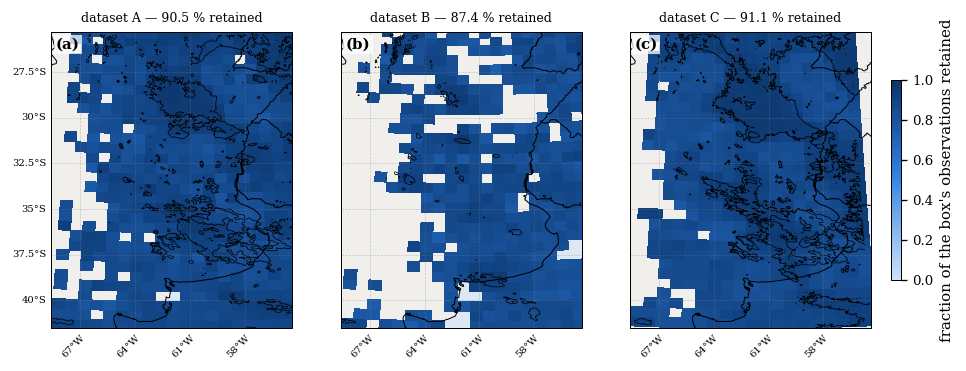

dataset  points at hour  retained  retained [%]  boxes drawn  boxes masked (n<15)  min retained | box  median retained | box  max retained | box
      A          539179    487898        90.489          594                    0               0.763                  0.888               0.988
      B          216398    189081        87.377          441                    0               0.746                  0.854               0.988
      C         1829133   1666102        91.087          532                    0               0.780                  0.882               0.978

Same 60 km boxes, same 11 pooled levels, same 19 UTC and the same contours as the
figure above -- so a box can be read across the two. A pale box here holds few
retained observations; a transparent one holds none at all; a grey one held fewer
than 15 QC-passing observations to begin with, which is a property of the
network and not of the rule.

Retention is the same for every scheme by construction -- the rule is wr

In [34]:
# ── §9 figure 3: how much of each box the rule keeps ───────────────────────
# The companion the figure above needs. There, a box drawn in a pale colour and a box
# the rule emptied are two different statements and only one of them is about the
# analysis; here the retained fraction is drawn on exactly the same boxes, so the two
# can be read together and a pale box cannot be mistaken for an empty one.
#
# ONE panel per dataset and not one per scheme, because the rule reads PRIOR
# predictors only: the retention field is identical for every scheme and identical in
# the "no rule" column of the figure above, where it is 1 everywhere. The assert below
# is what makes that a checked property rather than a claim.
_ret0 = box_stats(DATASETS[0], MAP_SCHEMES[0], KEEP_C[DATASETS[0]])[1]
_ret1 = box_stats(DATASETS[0], MAP_SCHEMES[1], KEEP_C[DATASETS[0]])[1]
assert np.array_equal(np.isnan(_ret0), np.isnan(_ret1)) and \
    np.allclose(_ret0[~np.isnan(_ret0)], _ret1[~np.isnan(_ret1)]), \
    ("the retained fraction depends on the scheme -- it must not, the rule is written "
     "on prior columns alone")
del _ret0, _ret1

RET_VMIN, RET_VMAX = 0.0, 1.0

fig, axes = plt.subplots(1, len(DATASETS),
                         figsize=(nb.PAGE_W * 1.55, nb.PAGE_W * 0.52),
                         subplot_kw=dict(projection=ccrs.PlateCarree()))
axes = np.atleast_1d(axes)
rows, pm = [], None
for cc, ds in enumerate(DATASETS):
    ax = axes[cc]
    nb.setup_map(ax, xlocs=[-67, -64, -61, -58],
                 ylocs=[-27.5, -30, -32.5, -35, -37.5, -40],
                 left_labels=(cc == 0), bottom_labels=True)
    p, ret, few, n_all, n_keep, blat, blon = box_stats(ds, MAP_SCHEMES[0], KEEP_C[ds])
    # Here the grey mask is on the box's TOTAL QC-passing count, not on what survived:
    # a box with too few observations to judge is a property of the network, and
    # colouring it as low retention would blame the rule for the network's coverage.
    thin = np.where((n_all > 0) & (n_all < MIN_BOX_N), 1.0, np.nan)
    nb.map_field(ax, blat, blon, np.ma.masked_invalid(thin), cmap=CMAP_FEW,
                 vmin=0.0, vmax=1.0, transform=ccrs.PlateCarree())
    pm = nb.map_field(ax, blat, blon, np.ma.masked_invalid(ret), cmap=nb.CMAP_SEQ,
                      vmin=RET_VMIN, vmax=RET_VMAX, transform=ccrs.PlateCarree())
    ax.contour(GEO[ds]["lons"], GEO[ds]["lats"], DBZ_COL[ds].T,
               levels=list(CONTOUR_DBZ), colors="black", linewidths=0.45,
               transform=ccrs.PlateCarree())
    ax.set_title(f"dataset {ds} — {100 * n_keep.sum() / n_all.sum():.1f} % retained",
                 fontsize=7.5)
    drawn = int(np.isfinite(ret).sum())
    rows.append({"dataset": ds, "points at hour": int(n_all.sum()),
                 "retained": int(n_keep.sum()),
                 "retained [%]": 100 * n_keep.sum() / max(n_all.sum(), 1),
                 "boxes drawn": drawn,
                 f"boxes masked (n<{MIN_BOX_N})": int((n_all > 0).sum()) - drawn,
                 "min retained | box": float(np.nanmin(ret)) if drawn else np.nan,
                 "median retained | box": float(np.nanmedian(ret)) if drawn else np.nan,
                 "max retained | box": float(np.nanmax(ret)) if drawn else np.nan})
RETAIN_TBL = pd.DataFrame(rows)
del rows
for a, letter in zip(axes, "abc"):
    nb.panel_label(a, letter)
fig.colorbar(pm, ax=axes, shrink=0.62, pad=0.02,
             label="fraction of the box's observations retained")
nb.save_fig(fig, "N3_1D_fig_rule_retention_maps_3ds")
plt.show()

print(RETAIN_TBL.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print(f"\nSame {BOX_KM:g} km boxes, same {len(KLIST[DATASETS[0]])} pooled levels, same "
      f"{MAP_HOUR} UTC and the same contours as the\nfigure above -- so a box can be "
      f"read across the two. A pale box here holds few\nretained observations; a "
      f"transparent one holds none at all; a grey one held fewer\nthan {MIN_BOX_N} "
      f"QC-passing observations to begin with, which is a property of the\nnetwork "
      f"and not of the rule.")
print("\nRetention is the same for every scheme by construction -- the rule is written")
print("on prior columns, which do not depend on the update -- and the assert at the top")
print("of this cell is what checks it rather than assuming it. That is why there is one")
print("panel per dataset here and four columns per dataset above.")
print(f"\nThe spread WITHIN a dataset is the part worth reading. Retention runs from "
      f"{100 * RETAIN_TBL['min retained | box'].min():.0f} % to "
      f"{100 * RETAIN_TBL['max retained | box'].max():.0f} %\nacross boxes; the wider "
      f"that range, the further the rule is from a uniform thinning\nof the network, "
      f"and the more the panel above is a map of a re-shaped observing\nsystem rather "
      f"than of a smaller one. Where the high-retention boxes sit relative to\nthe "
      f"echo contours is the question this figure exists to let a reader answer.")


## 10 · Where does tempering help most?

Same machinery, different target: instead of "did the analysis beat the prior", the
quantity is the **paired** per-point difference `skill(Nt) − skill(Nt=1)`, on the same
points, in the same truth member. Two questions:

* where is the mean gain per point largest — i.e. which observations would suffer most
  from dropping the extra steps;
* where does the *total* gain come from — a zone can have a large mean gain and hold
  so few points that removing tempering there would cost nothing.

The second is the one that matters if the extra steps have to be justified against
their cost, and it is not the same answer.

saved N3_1D_fig16_tempering_gain.pdf / N3_1D_fig16_tempering_gain.png


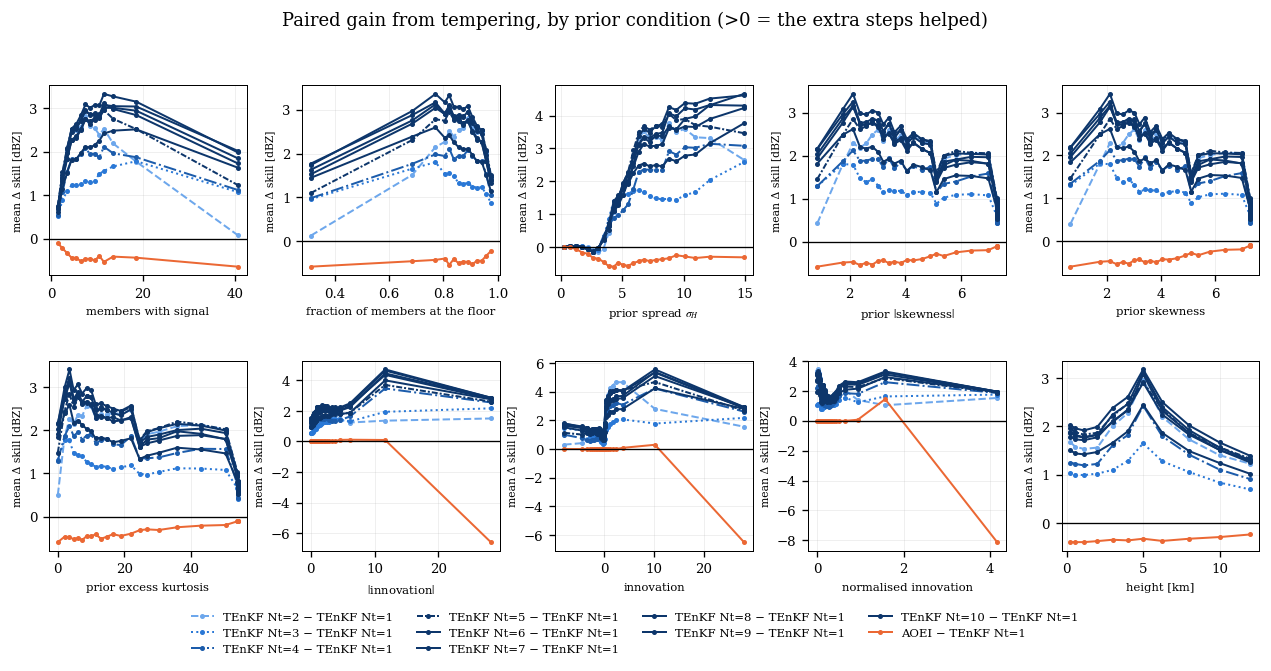

In [35]:
DT = {c: (SK[(c, "rmse")] - SK[(BASE, "rmse")]) for c in COMBOS if c != BASE}

fig, axes = plt.subplots(2, 5, figsize=(nb.PAGE_W * 1.9, nb.PAGE_W * 0.75),
                         gridspec_kw={"hspace": 0.45, "wspace": 0.28})
for ax, (p, lab, clip) in zip(axes.ravel(), USE[:10]):
    v = P[p].to_numpy(float)
    edges = edges_for(v, clip)
    idx, ok = digitize(v, edges)
    cen = 0.5 * (edges[:-1] + edges[1:])
    for c in COMBOS:
        if c == BASE:
            continue
        y, _ = bin_mean(idx, ok, DT[c], len(cen))
        ax.plot(cen, y, ls=nb.combo_style(c[0], c[1]), color=COL[c], lw=1.2,
                marker="o", ms=2, label=f"{LAB[c]} − {LAB[BASE]}")
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel(lab, fontsize=7)
    ax.set_ylabel("mean Δ skill [dBZ]", fontsize=6.5)
    del v, idx, ok
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.06),
           ncol=4, fontsize=7, frameon=False)
fig.suptitle("Paired gain from tempering, by prior condition "
             "(>0 = the extra steps helped)", y=1.0)
nb.save_fig(fig, "N3_1D_fig16_tempering_gain")
plt.show()

In [36]:
GAIN_BY = []
for pname in ("norm_innov", "n_active_f_point", "spread_f_point_obs", "dep_b"):
    v = P[pname].to_numpy(float)
    e = np.unique(np.percentile(v, np.arange(0, 101, 10)))
    idx, ok = digitize(v, e)
    for c in (BEST,):
        dt = DT[c].astype(np.float64)
        tot = float(dt.sum())
        cnt = np.bincount(idx[ok], minlength=len(e) - 1)[:len(e) - 1].astype(float)
        sm  = np.bincount(idx[ok], weights=dt[ok], minlength=len(e) - 1)[:len(e) - 1]
        for b in range(len(e) - 1):
            GAIN_BY.append({
                "predictor": pname, "decile": f"{e[b]:.2f}–{e[b+1]:.2f}",
                "points [%]": 100 * cnt[b] / len(P),
                "mean Δ [dBZ]": sm[b] / cnt[b] if cnt[b] else np.nan,
                "share of total gain [%]": 100 * sm[b] / tot if tot else np.nan,
            })
G = pd.DataFrame(GAIN_BY)
print(f"where the gain of {LAB[BEST]} over {LAB[BASE]} comes from:\n")
for pname, g in G.groupby("predictor", sort=False):
    print(f"── {pname} ──────────────────────────────────")
    print(g.drop(columns="predictor").to_string(index=False,
          float_format=lambda v: f"{v:+.2f}"))
    print()
print("'mean Δ' is per point; 'share of total gain' weights that by how many points the")
print("decile holds. A decile can lead the first column and be irrelevant in the second.")

where the gain of TEnKF Nt=5 over TEnKF Nt=1 comes from:

── norm_innov ──────────────────────────────────
    decile  points [%]  mean Δ [dBZ]  share of total gain [%]
 0.00–0.05      +10.00         +3.24                   +15.89
 0.05–0.10      +10.00         +2.67                   +13.09
 0.10–0.14      +10.00         +2.02                    +9.92
 0.14–0.18      +10.00         +1.90                    +9.30
 0.18–0.23      +10.00         +1.73                    +8.49
 0.23–0.28      +10.00         +1.48                    +7.27
 0.28–0.35      +10.00         +1.36                    +6.66
 0.35–0.47      +10.00         +1.58                    +7.73
 0.47–0.95      +10.00         +2.23                   +10.92
0.95–24.76      +10.00         +2.19                   +10.73

── n_active_f_point ──────────────────────────────────
     decile  points [%]  mean Δ [dBZ]  share of total gain [%]
  1.00–2.00      +19.99         +0.75                    +7.34
  2.00–3.00      +13.21      

saved N3_1D_fig17_tempering_zones.pdf / N3_1D_fig17_tempering_zones.png


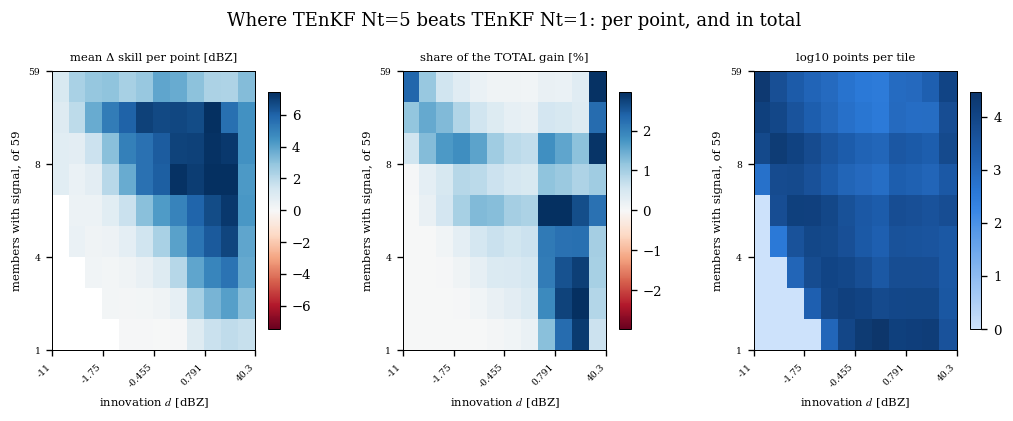

In [37]:
# The plane §7's rejection rule lives in, binned here. §9's fitted tile grid is gone
# with the zone rule it belonged to, so the two axes are re-binned directly -- equal
# count on the reference run's own distribution, 12 bins each, as before.
ex = edges_for(P[PX].to_numpy(float), (0.5, 99.5), 13, mode="quantile")
ey = edges_for(P[PY].to_numpy(float), (0.5, 99.5), 13, mode="quantile")
ix, okx = digitize(P[PX].to_numpy(float), ex)
iy, oky = digitize(P[PY].to_numpy(float), ey)
ok = okx & oky
shape = (len(ex) - 1, len(ey) - 1)
tile = np.ravel_multi_index([np.clip(ix, 0, shape[0] - 1),
                             np.clip(iy, 0, shape[1] - 1)], shape)
ntile = int(np.prod(shape))
cnt = np.bincount(tile[ok], minlength=ntile)[:ntile].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(nb.PAGE_W * 1.5, nb.PAGE_W * 0.45),
                         gridspec_kw={"wspace": 0.38})
dt = DT[BEST].astype(np.float64)
sm = np.bincount(tile[ok], weights=dt[ok], minlength=ntile)[:ntile]
with np.errstate(invalid="ignore", divide="ignore"):
    mean_dt = (sm / cnt).reshape(shape)
share = (100 * sm / dt.sum()).reshape(shape)
gx, gy = np.arange(len(ex)), np.arange(len(ey))
for ax, (M, ttl, kw) in zip(axes, (
        (mean_dt, "mean Δ skill per point [dBZ]",
         dict(cmap="RdBu",
              vmin=-np.nanpercentile(np.abs(mean_dt), 98),
              vmax=np.nanpercentile(np.abs(mean_dt), 98))),
        (share, "share of the TOTAL gain [%]",
         dict(cmap="RdBu",
              vmin=-np.nanpercentile(np.abs(share), 99),
              vmax=np.nanpercentile(np.abs(share), 99))),
        (np.log10(cnt.reshape(shape) + 1), "log10 points per tile",
         dict(cmap=nb.CMAP_SEQ)))):
    pm = ax.pcolormesh(gx, gy, M.T, shading="flat", **kw)
    plt.colorbar(pm, ax=ax, shrink=0.85)
    tile_axes(ax, ex, ey, PRED_LABEL.get(PX, PX), PRED_LABEL.get(PY, PY))
    ax.set_title(ttl, fontsize=7)
fig.suptitle(f"Where {LAB[BEST]} beats {LAB[BASE]}: per point, and in total", y=1.04)
nb.save_fig(fig, "N3_1D_fig17_tempering_zones")
plt.show()

## 11 · What this notebook publishes

Two tables go to `data/derived/`:

* `N3_1D_headline.csv` — the pooled headline, one row per scheme, same schema and
  same `skill_summary` call as N3. Published under its own name so it cannot
  overwrite `N3_headline.csv`, which N4 cross-checks against.
* `N3_1D_by_tm.csv` — the per-truth-member table, written directly rather than
  through `nb.publish`, because the canonical digest columns do not include `tm` and
  would collapse every member onto the same row.

In [38]:
N3_1D_HEADLINE = nb.skill_summary(A, "rmse", "obs", REF_RED)
print(N3_1D_HEADLINE.to_string(index=False))

digest = nb.publish("N3_1D_headline", N3_1D_HEADLINE)

p = nb.DERIVED / "N3_1D_by_tm.csv"
BYTM.to_csv(p, index=False)
print(f"wrote {p.name}  ({len(BYTM):,} rows, {len(TMLIST)} truth members)")

print(f"\nconfiguration this digest belongs to:")
print(f"    run       {RUN['tag']}")
print(f"    tms       {TMLIST}")
print(f"    reduction {REF_RED}    baseline {LAB[BASE]}")
print(f"\n    N3_1D_DIGEST = \"{digest}\"")

# Everything this notebook writes to data/derived/, listed where it is written rather
# than in prose that can fall behind it. The §14-§16 tables are new; the rest are the
# tables §6-§9 and §13 already published, now on the rebuilt dataset A.
print("\ntables this notebook publishes to data/derived/:")
for _n, _what in [
        ("N3_1D_headline",              "§11 the digest table N4 cross-checks against"),
        ("N3_1D_by_tm",                 "§1 per-truth-member skill, the error bar"),
        ("N3_1D_norm_innov_deciles",    "§6 deciles of the normalised innovation"),
        ("N3_1D_candidate_rules",       "§7b hand-written rules, scored out of sample"),
        ("N3_1D_band_criterion",        "§7a the band, every predictor and threshold"),
        ("N3_1D_rejection_rule",        "§7c the common rule"),
        ("N3_1D_power_sign_test",       "§13 subsample power, on the twin pairs"),
        ("N3_1D_state_variables",       "§14 pooled skill, 8 state variables x 4 datasets"),
        ("N3_1D_state_variables_by_tm", "§14 the same, per truth member"),
        ("N3_1D_state_verdict",         "§14 improved / degraded / tied, and the verdict"),
        ("N3_1D_state_scheme_ranking",  "§14 does a variable rank the schemes as Z does"),
        ("N3_1D_band_state_variables",  "§15 the band criterion on w, u, v, T"),
        ("N3_1D_A_vs_D",                "§16 aggregates, A against D"),
        ("N3_1D_A_vs_D_band",           "§16 the fitted band, A against D"),
        ("N3_1D_echo_split",             "§17 how the 5 dBZ contour divides the points"),
        ("N3_1D_state_differential",     "§17 the differential, scheme x side"),
        ("N3_1D_state_differential_by_tm",   "§17 the same, per truth member"),
        ("N3_1D_state_differential_verdict", "§17 which branch the numbers chose"),
        ("N3_1D_state_wind_base_rate",   "§17a the winds against a coin flip"),
        ("N3_1D_ladder_dips",            "§17b the ladder minima, paired")]:
    _p = nb.DERIVED / f"{_n}.csv"
    print(f"    {'ok ' if _p.exists() else 'PENDING'} {_n + '.csv':<32s} {_what}")
del _n, _what, _p

                          run  loc_km method  ntemp  alpha_s metric var   red  n_points  n_nan  median_skill  mean_skill  frac_improved  frac_degraded    ci_lo    ci_hi
WS_A_sweep_2000_LOC0.1_ALLMEM     0.1   AOEI      1      1.0   rmse obs point    565426      0      0.132535   -0.682329       0.723971       0.241278 0.722804 0.725135
WS_A_sweep_2000_LOC0.1_ALLMEM     0.1  TEnKF      1      1.0   rmse obs point    565426      0      0.140091   -0.331854       0.721829       0.249778 0.720660 0.722996
WS_A_sweep_2000_LOC0.1_ALLMEM     0.1  TEnKF      2      1.0   rmse obs point    565426      0      0.390490    1.510411       0.820321       0.151265 0.819318 0.821320
WS_A_sweep_2000_LOC0.1_ALLMEM     0.1  TEnKF      3      1.0   rmse obs point    565426      0      0.330717    0.765727       0.793610       0.177901 0.792554 0.794663
WS_A_sweep_2000_LOC0.1_ALLMEM     0.1  TEnKF      4      1.0   rmse obs point    565426      0      0.297092    1.129327       0.773875       0.197617 0.77

## 12 · Step count, or weight distribution?

Everything above varies the number of tempering steps at one fixed schedule *shape*:
`alpha_s = 1` in every run §1–§11 touch. That confounds two things, because raising
`Nt` at fixed `alpha_s` adds steps **and** flattens the weight vector at the same
time. The `Nt = 1 → 2` jump in §1's ladder, and the odd/even structure above it, are
consistent with either cause.

The `alpha_s = 0.25` run separates them. `da.core.tempering_schedule` is

$$w_i \;\propto\; \exp\!\left(-\frac{(N_t+1)\,\alpha_s}{i}\right), \qquad i = 1 \dots N_t$$

normalised to sum to one — back-loaded, with `alpha_s` setting how steeply. Lowering
`alpha_s` at fixed `Nt` flattens the schedule without touching the step count, which
gives a 2×2:

| | `α_s = 1` (steep) | `α_s = 0.25` (flat) |
|---|---|---|
| **`Nt = 3`** | `Nt3-α1` | `Nt3-α0.25` |
| **`Nt = 5`** | `Nt5-α1` | `Nt5-α0.25` |

and one clean prediction. Measured by the weight spent on *all steps except the last
two* — the near-null early steps the hypothesis is about — `Nt3-α0.25` (0.218) sits
next to `Nt5-α1` (0.264), while `Nt3-α1` is far below both (0.044). So:

* if what matters is **how the weight is distributed**, `Nt3-α0.25` should land near
  `Nt5-α1`;
* if what matters is **how many steps there are**, it should land near `Nt3-α1`.

**Scope.** Dataset `A`, 19 UTC only, all 60 truth members, `L = 0.1 km`, point
reduction. That is one hour and one ensemble source — narrower than §1's pooling, and
deliberately so: the `alpha_s = 0.25` run exists only at this hour. The `α_s = 1`
cells are read from the *same* original sweep §2–§10 dissect, so they are the same
numbers §1 reports for dataset `A` at this hour.

**This section is standalone.** It needs the import cell at the top of the notebook
and nothing else — not the 33-minute §1 load — and it writes nothing §1–§11 read.

In [39]:
# ── §12 config: the 2x2, and the schedules it is about ─────────────────────
# Standalone. Nothing above this point is read or written -- the section loads its
# own two runs, and §1-§11 keep whatever they had.
#
# The question is whether the extra tempering steps help because there are MORE of
# them or because they spread the observation weight more evenly. Those two are
# confounded in the original sweep: alpha_s is fixed at 1, so raising Nt raises the
# step count AND flattens the schedule at the same time. The alpha_s = 0.25 run
# breaks the confound -- Nt = 3 with a flat schedule against Nt = 5 with a steep one.
from da.core import tempering_schedule            # the run's own schedule, not retyped

WH_HOUR   = "19"
WH_LOC    = 0.1
WH_RED    = "point"
WH_TMS    = np.arange(60)
# Dataset D, and it has to be: the alpha_s = 0.25 arm exists for D alone. A's rebuilt
# sweep has the alpha_s = 1 half of this 2x2 and not the other, so the section CANNOT
# be re-run on A without one more 60-truth-member campaign
# (configs/WS_A_sweep_1900_LOC0.1_ALLMEM_AS0.25.yaml is written and passes the naming
# gate). Until that exists this is a D result, and WH_DS below is read from the files
# rather than typed -- the caption said "dataset A" for one run of this notebook after
# the letters moved, which is exactly the error the identity gate exists to stop.
WH_RUNS   = {1.00: "WS_D_sweep_1900_LOC0.1_ALLMEM",
             0.25: "WS_D_sweep_1900_LOC0.1_ALLMEM_AS0.25"}
WH_CELLS  = [(3, 1.00), (3, 0.25), (5, 1.00), (5, 0.25)]   # Nt=3 pair, then Nt=5 pair

def wh_label(nt, a):
    return fr"$Nt{nt} - $" + (r"$ \alpha_s = 1$" if a == 1 else rf"$\alpha_s = {a:g}$")

def wh_key(nt, a):
    return f"Nt{nt}-a{a:g}"

WH_LAB  = {(nt, a): wh_label(nt, a) for nt, a in WH_CELLS}
WH_KEY  = {(nt, a): wh_key(nt, a) for nt, a in WH_CELLS}
# Colour carries alpha_s and marker carries Nt. This deliberately departs from
# nb.combo_color, which maps colour to ntemp alone and so cannot say which of the two
# axes a point belongs to -- the one thing this section exists to separate.
WH_COL  = {1.00: nb.C_NT1, 0.25: nb.C_NONE}
WH_MRK  = {3: "o", 5: "s"}

# ── the schedules, and the quantity the hypothesis is about ────────────────
# "All steps except the last two" is the weight the filter spends before the two
# steps that do most of the work -- the near-null early steps. If tempering helps
# because of the DISTRIBUTION, this column should order the four cells; if it helps
# because of the STEP COUNT, Nt alone should.
WH_W = {(nt, a): tempering_schedule(nt, a).astype(float) for nt, a in WH_CELLS}
wrows = []
for nt, a in WH_CELLS:
    w = WH_W[(nt, a)]
    assert len(w) == nt and np.isclose(w.sum(), 1.0), f"schedule Nt={nt} a={a} is malformed"
    wrows.append({"config": WH_KEY[(nt, a)], "Nt": nt, "alpha_s": a,
                  "step weights": ", ".join(f"{x:.4f}" for x in w),
                  "last step": w[-1], "last two": w[-2:].sum(),
                  "all but last two": w[:-2].sum()})
WH_SCHED = pd.DataFrame(wrows)
print("exponential back-loaded schedule  w_i ∝ exp(−(Nt+1)·α_s / i),  i = 1 … Nt")
print("(da.core.tempering_schedule -- the same function the runs were produced with)\n")
print(WH_SCHED.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\n'all but last two' is the hypothesis axis: the weight spent on the early,")
print("near-null steps. Note it does NOT order the same way as Nt -- Nt3-a0.25 (%.4f)"
      % WH_SCHED.set_index("config").at["Nt3-a0.25", "all but last two"])
print("sits next to Nt5-a1 (%.4f), not next to Nt3-a1 (%.4f). That separation is what"
      % (WH_SCHED.set_index("config").at["Nt5-a1", "all but last two"],
         WH_SCHED.set_index("config").at["Nt3-a1", "all but last two"]))
print("makes the 2x2 a test rather than a description.")

exponential back-loaded schedule  w_i ∝ exp(−(Nt+1)·α_s / i),  i = 1 … Nt
(da.core.tempering_schedule -- the same function the runs were produced with)

   config  Nt  alpha_s                           step weights  last step  last two  all but last two
   Nt3-a1   3   1.0000                 0.0439, 0.3244, 0.6318     0.6318    0.9561            0.0439
Nt3-a0.25   3   0.2500                 0.2176, 0.3587, 0.4237     0.4237    0.7824            0.2176
   Nt5-a1   5   1.0000 0.0035, 0.0699, 0.1901, 0.3134, 0.4231     0.4231    0.7365            0.2635
Nt5-a0.25   5   0.2500 0.0817, 0.1730, 0.2222, 0.2517, 0.2713     0.2713    0.5231            0.4769

'all but last two' is the hypothesis axis: the weight spent on the early,
near-null steps. Note it does NOT order the same way as Nt -- Nt3-a0.25 (0.2176)
sits next to Nt5-a1 (0.2635), not next to Nt3-a1 (0.0439). That separation is what
makes the 2x2 a test rather than a description.


In [40]:
# ── §12 pre-flight: are the two runs actually comparable? ──────────────────
# The 2x2 is only a controlled comparison if the two runs differ in alpha_s and in
# NOTHING else that touches the score. Read from the configs, never assumed.
# Whose data this is, from the dataset_id inside the files of both runs.
WH_DS = {nb.run_dataset(t) for t in WH_RUNS.values()}
assert len(WH_DS) == 1 and None not in WH_DS, \
    f"the two §12 runs disagree about their dataset, or carry no dataset_id: {WH_DS}"
WH_DS = next(iter(WH_DS))
print(f"§12 runs on dataset {WH_DS} ({nb.DS_DESC[WH_DS]}), read from the files.")
if WH_DS != DATASETS[0]:
    print(f"NOTE: this is NOT the main dataset {DATASETS[0]}. The alpha_s = 0.25 arm "
          f"exists only for {WH_DS},\nso the 2x2 cannot be re-run on "
          f"{DATASETS[0]} until that campaign is run.\n")

WH_CFG = {a: nb.run_config(t)["sweep"] for a, t in WH_RUNS.items()}
for a, t in WH_RUNS.items():
    c = WH_CFG[a]
    assert float(c["alpha_s"]) == a, f"{t}: alpha_s is {c['alpha_s']}, expected {a}"
    assert int(c["stride"]) == int(WH_CFG[1.00]["stride"]), f"{t}: different obs stride"
    assert (float(c["loc_x"]), float(c["loc_y"]), float(c["loc_z"])) \
        == (WH_LOC, WH_LOC, WH_LOC), f"{t}: not an isotropic {WH_LOC} km localization"
    assert nb.obs_error_var(t) == nb.obs_error_var(WH_RUNS[1.00]), f"{t}: different R"
    assert nb.dbz_min_of(t) == nb.dbz_min_of(WH_RUNS[1.00]), f"{t}: different dbz_min"
    assert len(nb.sweep_files(t)) == len(WH_TMS), \
        f"{t}: {len(nb.sweep_files(t))} truth-member files, expected {len(WH_TMS)}"
for nt, a in WH_CELLS:
    assert nt in list(WH_CFG[a]["ntemp"]), \
        f"{WH_RUNS[a]} does not carry Nt={nt} (it has {list(WH_CFG[a]['ntemp'])})"
print(f"both runs: stride {WH_CFG[1.00]['stride']}, L = {WH_LOC} km isotropic, "
      f"R = {nb.obs_error_var(WH_RUNS[1.00])}, "
      f"dbz_min = {nb.dbz_min_of(WH_RUNS[1.00])}, {len(WH_TMS)} truth members each")
print(f"  alpha_s = 1.00 : {WH_RUNS[1.00]}  ntemp {list(WH_CFG[1.00]['ntemp'])}")
print(f"  alpha_s = 0.25 : {WH_RUNS[0.25]}  ntemp {list(WH_CFG[0.25]['ntemp'])}\n")

# ── the streaming load ─────────────────────────────────────────────────────
# One truth member at a time, BOTH runs in the same frame, aligned together. The four
# cells are four distinct 6-tuple combos (they differ in the alpha_s field), and
# align() inner-joins them on point_key -- which is built from (tm, i, j, k) and knows
# nothing about which run a row came from. So this single align() call IS the pairing
# test: if the two runs put their observations at different points, the intersection
# loses them and `dropped` is non-zero.
WH_COLS = nb.columns_for(metrics=("rmse",), vars=("obs",), reds=(WH_RED,))
WH_KEEP = [nb.colname("rmse", s, WH_RED, "obs") for s in ("f", "a")] + ["tm", "run"]

wh_parts, WH_COMBOS, wh_drop, wh_npts = None, None, 0, {}
_t0 = time.time()
for _n, tm in enumerate(WH_TMS, 1):
    d = nb.load_runs([dict(tag=t, loc=WH_LOC, hour=WH_HOUR, tms=[int(tm)])
                      for t in WH_RUNS.values()], columns=WH_COLS, verbose=False)
    if WH_COMBOS is None:
        # Resolve each (Nt, alpha_s) cell to the 6-tuple align() will use. combo_key
        # raises on an ambiguous match, so a run carrying two alpha_s values would be
        # caught here rather than silently contributing an arbitrary one.
        allc = nb.combos_in(d)
        WH_COMBOS = {}
        for nt, a in WH_CELLS:
            cands = [k for k in allc if k[0] == "TEnKF" and int(k[1]) == nt
                     and np.isclose(float(k[2]), a) and np.isclose(float(k[3]), WH_LOC)]
            assert len(cands) == 1, f"Nt={nt}, alpha_s={a} matched {cands}"
            WH_COMBOS[(nt, a)] = cands[0]
        print(f"the 2x2, as 6-tuple combos {nb.COMBO_FIELDS}:")
        for k, v in WH_COMBOS.items():
            print(f"  {WH_KEY[k]:<10} {v}")
        print()
        wh_parts = {k: [] for k in WH_CELLS}

    a1 = nb.align(d, [WH_COMBOS[k] for k in WH_CELLS])
    # The pairing, asserted per member rather than hoped for: every combo keeps every
    # point, so the four columns are the same observations in the same order.
    assert a1.dropped == 0, (
        f"tm{int(tm):02d}: align() dropped {a1.dropped} points -- the two runs do not "
        f"share an observation set, so the comparison would not be paired")
    for k in WH_CELLS:
        wh_parts[k].append(a1.frames[WH_COMBOS[k]][WH_KEEP])
    wh_drop += int(a1.dropped)
    wh_npts[int(tm)] = a1.n_points
    del d, a1
    if _n in (1, 2) or _n % 15 == 0 or _n == len(WH_TMS):
        _e = time.time() - _t0
        print(f"  [{_n:2d}/{len(WH_TMS)}] tm{int(tm):02d}  {wh_npts[int(tm)]:,} "
              f"paired points  {_e/60:4.1f} min elapsed, "
              f"~{_e/_n*(len(WH_TMS)-_n)/60:4.1f} min left")

WH_FRAMES = {k: pd.concat(wh_parts[k]) for k in WH_CELLS}
del wh_parts
gc.collect()

# Row alignment across the four cells, on the concatenated frames this time: the
# per-member and paired numbers below index into these as bare numpy arrays.
_ref = WH_FRAMES[WH_CELLS[0]]
for k in WH_CELLS:
    assert WH_FRAMES[k].index.equals(_ref.index), f"{WH_KEY[k]} is not row-aligned"
    assert (WH_FRAMES[k]["tm"].to_numpy() == _ref["tm"].to_numpy()).all(), \
        f"{WH_KEY[k]} carries a different truth-member ordering"
WH_TM_ARR = _ref["tm"].to_numpy()
WH_TMLIST = [int(t) for t in np.unique(WH_TM_ARR)]
assert WH_TMLIST == [int(t) for t in WH_TMS], \
    f"expected truth members {list(WH_TMS)}, got {WH_TMLIST}"
# Each cell must come from the run its alpha_s names -- the guard against a mislabelled
# 2x2, which no downstream number could detect on its own.
for k in WH_CELLS:
    got = set(WH_FRAMES[k]["run"].astype(str).unique())
    assert got == {WH_RUNS[k[1]]}, f"{WH_KEY[k]} drew rows from {got}, expected {WH_RUNS[k[1]]}"

print(f"\npaired point set: {len(_ref):,} points = {len(WH_TMLIST)} truth members x "
      f"~{len(_ref)//len(WH_TMLIST):,}, identical across all four cells")
print(f"points dropped by the cross-run intersection: {wh_drop}")
print(f"load took {(time.time()-_t0)/60:.1f} min")

§12 runs on dataset D (4 km, 5 min DA, single-physics), read from the files.
NOTE: this is NOT the main dataset A. The alpha_s = 0.25 arm exists only for D,
so the 2x2 cannot be re-run on A until that campaign is run.

both runs: stride 10, L = 0.1 km isotropic, R = 5.0, dbz_min = 0.0, 60 truth members each
  alpha_s = 1.00 : WS_D_sweep_1900_LOC0.1_ALLMEM  ntemp [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
  alpha_s = 0.25 : WS_D_sweep_1900_LOC0.1_ALLMEM_AS0.25  ntemp [3, 5]

the 2x2, as 6-tuple combos ('method', 'ntemp', 'alpha_s', 'lx_km', 'ly_km', 'lz_km'):
  Nt3-a1     ('TEnKF', 3, 1.0, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612)
  Nt3-a0.25  ('TEnKF', 3, 0.25, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612)
  Nt5-a1     ('TEnKF', 5, 1.0, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612)
  Nt5-a0.25  ('TEnKF', 5, 0.25, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612)

  [ 1/60] tm00  8,918 paired points   0.0 min elapsed, ~ 0.9 min le

In [41]:
# ── §12 the table: weights and result side by side ─────────────────────────
# Aggregated through nb.skill_summary / nb.skill_summary_by_tm, the same two calls
# §1 uses, so the tie tolerance and the definition of every column are identical.
# The two alpha_s = 1 cells are read from the same original sweep §2-§10 dissect.
# They are NOT expected to equal §1's dataset-A row, and the difference is pooling,
# not computation: §1 pools four analysis times per dataset, this section is 19 UTC
# alone. Comparing them like for like would need §1's per-hour numbers, which it does
# not print -- so no assert is made here rather than one that would be checking the
# wrong thing.
WH_A = nb.Aligned({WH_COMBOS[k]: WH_FRAMES[k] for k in WH_CELLS},
                  [WH_COMBOS[k] for k in WH_CELLS],
                  {WH_COMBOS[k]: 0 for k in WH_CELLS}, wh_drop)
WH_HEAD = nb.skill_summary(WH_A, "rmse", "obs", WH_RED)
WH_BYTM = nb.skill_summary_by_tm(WH_A, "rmse", "obs", WH_RED)
WH_BYTM["cell"] = [WH_KEY[(int(n), round(float(a), 2))]
                   for n, a in zip(WH_BYTM.ntemp, WH_BYTM.alpha_s)]
_bytm = {c: g.set_index("tm") for c, g in WH_BYTM.groupby("cell")}

# value = pooled over all the cell's points; ± = s.d. ACROSS the 60 truth members,
# each scored on its own points. §1 argues that error bar at length -- a Wilson
# interval on 5e5 spatially correlated points understates the redraw-to-redraw spread
# by an order of magnitude -- and this section uses the same one.
_sched = WH_SCHED.set_index("config")
rows, nrows = [], []
for k in WH_CELLS:
    c = WH_KEY[k]
    h = WH_HEAD[(WH_HEAD.ntemp == k[0]) & np.isclose(WH_HEAD.alpha_s, k[1])].iloc[0]
    g = _bytm[c]
    assert len(g) == len(WH_TMLIST), f"{c}: {len(g)} per-member rows, expected {len(WH_TMLIST)}"
    r = {"config": c, "Nt": k[0], "alpha_s": k[1],
         "step weights": _sched.at[c, "step weights"],
         "all but last 2": _sched.at[c, "all but last two"]}
    n = dict(r)
    for col, lab in (("mean_skill", "mean skill"), ("median_skill", "median skill"),
                     ("frac_improved", "frac improved")):
        v, e = float(h[col]), float(g[col].std(ddof=1))
        r[lab] = f"{v:+.4f} ± {e:.4f}"
        n[lab], n[f"sd_{lab}"] = v, e
    rows.append(r)
    nrows.append(n)
WH_TBL = pd.DataFrame(rows)          # for reading and for .to_latex()
WH_TBL_NUM = pd.DataFrame(nrows)     # for arithmetic

print(f"RMSE skill at the observation point, {nb.loc_label(WH_LOC)}, "
      f"{WH_HOUR} UTC, dataset {WH_DS}, {len(WH_TMLIST)} truth members")
print(f"{WH_A.n_points:,} paired observation points per cell -- the SAME points in "
      f"every row.\nvalue = pooled over those points;  "
      f"± = s.d. across the {len(WH_TMLIST)} truth members\n")
print(WH_TBL.to_string(index=False, formatters={
    "Nt": lambda v: f"{v:d}", "alpha_s": lambda v: f"{v:.2f}",
    "all but last 2": lambda v: f"{v:.4f}"}))
print("\nThe ± overlaps between several of these rows. That is why the paired test")
print("below, and not this table, is what settles the comparison.")

RMSE skill at the observation point, L = 0.1 km, 19 UTC, dataset D, 60 truth members
534,231 paired observation points per cell -- the SAME points in every row.
value = pooled over those points;  ± = s.d. across the 60 truth members

   config Nt alpha_s                           step weights all but last 2       mean skill     median skill    frac improved
   Nt3-a1  3    1.00                 0.0439, 0.3244, 0.6318         0.0439 +1.1452 ± 0.4058 +0.4237 ± 0.0195 +0.8040 ± 0.0055
Nt3-a0.25  3    0.25                 0.2176, 0.3587, 0.4237         0.2176 +1.0264 ± 0.4361 +0.3158 ± 0.0206 +0.7594 ± 0.0064
   Nt5-a1  5    1.00 0.0035, 0.0699, 0.1901, 0.3134, 0.4231         0.2635 +1.9850 ± 0.4097 +0.5501 ± 0.0168 +0.8292 ± 0.0044
Nt5-a0.25  5    0.25 0.0817, 0.1730, 0.2222, 0.2517, 0.2713         0.4769 +1.6326 ± 0.4251 +0.3875 ± 0.0218 +0.7745 ± 0.0056

The ± overlaps between several of these rows. That is why the paired test
below, and not this table, is what settles the comparison.


saved N3_1D_fig_weight_hypothesis.pdf / N3_1D_fig_weight_hypothesis.png


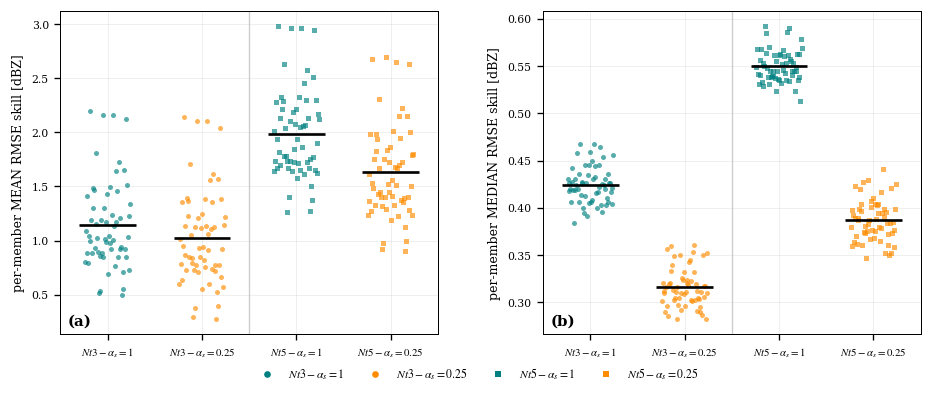

In [42]:
# ── §12 the figure: one dot per truth member, four configurations ──────────
# Two panels because the per-member statistic is itself a choice, and §1a showed the
# two answer different questions on this distribution: the per-member MEAN is a sum
# over that member's points and is moved by the negative tail; the per-member MEDIAN
# is what happens at a typical observation. A conclusion that holds in one panel and
# not the other is not a conclusion, so both are drawn.
WH_PIV = {col: pd.DataFrame({WH_KEY[k]: _bytm[WH_KEY[k]][col].reindex(WH_TMLIST)
                             for k in WH_CELLS})
          for col in ("mean_skill", "median_skill", "frac_improved")}

fig, axes = plt.subplots(1, 2, figsize=(nb.PAGE_W * 1.35, nb.PAGE_W * 0.52),
                         gridspec_kw={"wspace": 0.28})
x = np.arange(len(WH_CELLS))
jit = np.linspace(-0.24, 0.24, len(WH_TMLIST))
for ax, col, ylab in zip(axes,
                         ["mean_skill", "median_skill"],
                         ["per-member MEAN RMSE skill [dBZ]",
                          "per-member MEDIAN RMSE skill [dBZ]"]):
    P_ = WH_PIV[col]
    for i, k in enumerate(WH_CELLS):
        v = P_[WH_KEY[k]].to_numpy(float)
        ax.plot(i + jit, v, WH_MRK[k[0]], ms=3.0, color=WH_COL[k[1]], alpha=0.65,
                mew=0, zorder=3)
        # solid = mean of the dots, dotted = their median, as in §1b
        ax.hlines(v.mean(), i - 0.30, i + 0.30, color="k", lw=1.6, zorder=5)
        #ax.hlines(np.median(v), i - 0.30, i + 0.30, color="0.45", lw=1.2, ls=":",
        #          zorder=5)
    # The reading aid the section is for: a band at the Nt3-a1 level and a line at the
    # Nt5-a1 level, so "which one does Nt3-a0.25 sit next to" is answered by eye.
    lo = P_[WH_KEY[(3, 1.00)]].to_numpy(float).mean()
    hi = P_[WH_KEY[(5, 1.00)]].to_numpy(float).mean()
    #ax.axhline(lo, color=WH_COL[1.00], lw=0.9, ls="--", alpha=0.75, zorder=1)
    #ax.axhline(hi, color=WH_COL[1.00], lw=0.9, ls="-.", alpha=0.75, zorder=1)
    #ax.text(0.985, lo, f" Nt3-$\\alpha$1 mean ", transform=ax.get_yaxis_transform(),
    #        fontsize=5.8, color=WH_COL[1.00], va="bottom", ha="right",
    #        bbox=dict(fc="white", ec="none", alpha=0.7, pad=0.8))
    #ax.text(0.985, hi, f" Nt5-$\\alpha$1 mean ", transform=ax.get_yaxis_transform(),
    #        fontsize=5.8, color=WH_COL[1.00], va="bottom", ha="right",
    #        bbox=dict(fc="white", ec="none", alpha=0.7, pad=0.8))
    ax.set_xticks(x)
    ax.set_xticklabels([WH_LAB[k] for k in WH_CELLS], fontsize=7.5)
    ax.set_xlim(-0.5, len(WH_CELLS) - 0.5)
    ax.set_ylabel(ylab, fontsize=7.5)
    ax.axvline(1.5, color="0.8", lw=0.8, zorder=0)     # Nt=3 pair | Nt=5 pair
    ax.tick_params(labelsize=6.5)
for a, letter in zip(axes, "ab"):
    nb.panel_label(a, letter, loc="lower left")

from matplotlib.lines import Line2D
h_ = [Line2D([], [], ls="", marker=WH_MRK[nt], ms=4, mew=0, color=WH_COL[a],
             label=WH_LAB[(nt, a)]) for nt, a in WH_CELLS]
#h_ += [Line2D([], [], color="k", lw=1.6, label="mean over the 60 members"),
#       Line2D([], [], color="0.45", lw=1.2, ls=":", label="median over the 60 members")]
fig.legend(handles=h_, loc="lower center", bbox_to_anchor=(0.5, -0.01), ncol=4,
           frameon=False, fontsize=7, columnspacing=1.6, handlelength=2.0)
#fig.suptitle(
#    f"Step count vs weight distribution — {nb.loc_label(WH_LOC)}, "
#    f"{nb.RED_LABELS[WH_RED]}, dataset A at {WH_HOUR} UTC\n"
#    f"one dot per truth member ({len(WH_TMLIST)} per configuration), the same "
#    f"{WH_A.n_points:,} paired observation points in every column",
#    y=1.10, fontsize=8.5)
nb.save_fig(fig, "N3_1D_fig_weight_hypothesis")
plt.show()

In [43]:
WH_LAB

{(3, 1.0): '$Nt3 - $$ \\alpha_s = 1$',
 (3, 0.25): '$Nt3 - $$\\alpha_s = 0.25$',
 (5, 1.0): '$Nt5 - $$ \\alpha_s = 1$',
 (5, 0.25): '$Nt5 - $$\\alpha_s = 0.25$'}

In [44]:
# ── §12 the direct test: paired across truth members ──────────────────────
# The across-member s.d. in the table (~0.4 dBZ on the mean) is larger than some of
# the gaps between configurations, so the unpaired columns cannot settle this. Paired
# is the way through: every configuration saw the SAME truth, the same prior and the
# same observations in every member, so member-to-member noise cancels in a
# difference and the sign count is a test with n = 60, not n = 534,231.
from scipy.stats import binom_test

def wh_sign(d, name):
    """Sign test on a per-member paired difference. d is one value per truth member."""
    d = np.asarray(d, float)
    n = int(np.isfinite(d).sum())
    pos, neg = int((d > 0).sum()), int((d < 0).sum())
    return {"comparison": name, "median Δ": float(np.median(d)),
            "mean Δ": float(d.mean()), "n>0": pos, "n<0": neg, "n": n,
            "p (sign test)": float(binom_test(pos, pos + neg, 0.5)) if pos + neg else np.nan}

WH_PAIRED = {}
for col, cname in (("mean_skill", "per-member MEAN skill"),
                   ("median_skill", "per-member MEDIAN skill")):
    P_ = WH_PIV[col]
    a, b, c = (P_[WH_KEY[(3, 0.25)]].to_numpy(float),
               P_[WH_KEY[(5, 1.00)]].to_numpy(float),
               P_[WH_KEY[(3, 1.00)]].to_numpy(float))
    rows = [
        # the two the hypothesis asks for
        wh_sign(a - b, "Nt3-a0.25  −  Nt5-a1   (flat few steps vs steep many)"),
        wh_sign(a - c, "Nt3-a0.25  −  Nt3-a1   (flatten at fixed Nt=3)"),
        # the 2x2 completed, so the effect of each axis is separable
        wh_sign(P_[WH_KEY[(5, 0.25)]].to_numpy(float) - P_[WH_KEY[(5, 1.00)]].to_numpy(float),
                "Nt5-a0.25  −  Nt5-a1   (flatten at fixed Nt=5)"),
        wh_sign(b - c, "Nt5-a1     −  Nt3-a1   (more steps at fixed a=1)"),
        wh_sign(P_[WH_KEY[(5, 0.25)]].to_numpy(float) - a,
                "Nt5-a0.25  −  Nt3-a0.25 (more steps at fixed a=0.25)"),
    ]
    WH_PAIRED[col] = pd.DataFrame(rows)
    print(f"── {cname} ─────────────────────────────────────────")
    print(WH_PAIRED[col].to_string(index=False, float_format=lambda v: f"{v:+.4f}",
                                   formatters={"p (sign test)": lambda v: f"{v:.1e}"}))
    print()

# ── "closer to which?" as its own paired test ─────────────────────────────
# The question is not only which way each gap points but which gap is SMALLER. Per
# member, compare |Nt3-a0.25 − Nt5-a1| against |Nt3-a0.25 − Nt3-a1|: a positive
# difference means Nt3-a0.25 sits further from Nt5-a1 than from Nt3-a1, i.e. the step
# count is what it tracks. This is the sentence the section has to answer.
rows = []
for col, cname in (("mean_skill", "per-member MEAN skill"),
                   ("median_skill", "per-member MEDIAN skill")):
    P_ = WH_PIV[col]
    a = P_[WH_KEY[(3, 0.25)]].to_numpy(float)
    d_to_nt5 = np.abs(a - P_[WH_KEY[(5, 1.00)]].to_numpy(float))
    d_to_nt3 = np.abs(a - P_[WH_KEY[(3, 1.00)]].to_numpy(float))
    r = wh_sign(d_to_nt5 - d_to_nt3,
                f"{cname}: |Δ to Nt5-a1| − |Δ to Nt3-a1|")
    r["median |Δ to Nt5-a1|"] = float(np.median(d_to_nt5))
    r["median |Δ to Nt3-a1|"] = float(np.median(d_to_nt3))
    rows.append(r)
WH_CLOSER = pd.DataFrame(rows)[["comparison", "median |Δ to Nt5-a1|",
                                "median |Δ to Nt3-a1|", "median Δ", "n>0", "n<0",
                                "p (sign test)"]]
print("── is Nt3-a0.25 closer to Nt5-a1 or to Nt3-a1? ──────────────────────")
print(WH_CLOSER.to_string(index=False, float_format=lambda v: f"{v:+.4f}",
                          formatters={"p (sign test)": lambda v: f"{v:.1e}"}))
print("\n'n>0' counts the truth members in which Nt3-a0.25 is FURTHER from Nt5-a1 than")
print("from Nt3-a1 -- i.e. members that vote for 'the step count is what matters'.")

── per-member MEAN skill ─────────────────────────────────────────
                                           comparison  median Δ  mean Δ  n>0  n<0  n p (sign test)
Nt3-a0.25  −  Nt5-a1   (flat few steps vs steep many)   -0.9611 -0.9586    0   60 60       1.7e-18
       Nt3-a0.25  −  Nt3-a1   (flatten at fixed Nt=3)   -0.1064 -0.1187    0   60 60       1.7e-18
       Nt5-a0.25  −  Nt5-a1   (flatten at fixed Nt=5)   -0.3564 -0.3524    0   60 60       1.7e-18
     Nt5-a1     −  Nt3-a1   (more steps at fixed a=1)   +0.8416 +0.8398   60    0 60       1.7e-18
 Nt5-a0.25  −  Nt3-a0.25 (more steps at fixed a=0.25)   +0.6064 +0.6062   60    0 60       1.7e-18

── per-member MEDIAN skill ─────────────────────────────────────────
                                           comparison  median Δ  mean Δ  n>0  n<0  n p (sign test)
Nt3-a0.25  −  Nt5-a1   (flat few steps vs steep many)   -0.2317 -0.2339    0   60 60       1.7e-18
       Nt3-a0.25  −  Nt3-a1   (flatten at fixed Nt=3)   -0.1086 -0.1084

### What the 2×2 says

**The step count is what matters. Flattening the schedule at fixed `Nt` is not
neutral — it is mildly harmful.** Every one of the five paired comparisons is
unanimous across all 60 truth members (sign test *p* ≈ 2 × 10⁻¹⁸), which is what the
paired design buys: the across-member s.d. on the pooled mean skill is ±0.41 dBZ,
larger than several of the gaps in the table, so the unpaired columns could not have
settled this on their own.

Reading the two axes separately, on per-member median skill:

* **more steps helps**, at both schedule shapes: `Nt5 − Nt3` is +0.126 dBZ at
  `α_s = 1` and +0.072 dBZ at `α_s = 0.25`, 60/60 members each;
* **flatter hurts**, at both step counts: `α0.25 − α1` is −0.109 dBZ at `Nt = 3` and
  −0.163 dBZ at `Nt = 5`, 60/60 members each.

The two effects point in *opposite* directions, which is the substantive finding. It
means the gain the original sweep shows as `Nt` rises is obtained **despite** the
flattening that comes with it, not because of it.

The direct test answers the question as posed. `Nt3-α0.25` sits 0.232 dBZ from
`Nt5-α1` and 0.109 dBZ from `Nt3-α1` in median skill — closer to the original `Nt=3`
in **60 of 60** members. It does not land near `Nt5-α1`; it lands below `Nt3-α1`.

And the hypothesis axis fails as an ordering outright. Ranked by weight on
all-but-the-last-two steps the cells go `Nt3-α1` (0.044) → `Nt3-α0.25` (0.218) →
`Nt5-α1` (0.264) → `Nt5-α0.25` (0.477); ranked by median skill they go `Nt3-α0.25`
(0.316) → `Nt5-α0.25` (0.388) → `Nt3-α1` (0.424) → `Nt5-α1` (0.550). The cell with
the *most* early weight is not the best — it is third of four.

**What this does not establish.** Two values of `alpha_s` and two of `Nt`, at one
hour and one ensemble source. It shows the near-null early steps are not the
mechanism, and it shows the direction of the `alpha_s` effect at these two step
counts; it does not locate an optimal schedule, and it cannot speak to the odd/even
structure in §1's ladder, since `alpha_s = 0.25` was only run at `Nt = 3` and `5`.

## 13 · How many truth members does the multi-obs experiment need?

Everything above is a sweep: **independent** single-observation assimilations, one
observation at a time into the same prior. The next experiment is not — it assimilates
the whole observation set at `L = 2.0 km`, with and without §7c's rejection rule, and
each cell of it costs one full multi-obs run per truth member. Sixty of those per
configuration is a bill worth checking before it is paid, and it can be checked here,
because the sweep already holds all 60 truth members and the rule's effect on them is
computable by filtering rows. This section costs minutes and it belongs before the
first multi-obs run, not after.

### Why the comparison is a sign test, and on how many units

With and without the rule share the prior, the observations and the truth member, so
the comparison is **paired** and the unit is the truth member — the unit §1 argues for,
for the same reason.

The unit is not, however, one of sixty. §13a and N2 both find the members pair at
offset 30, so the sixty differences are **thirty** independent draws; the test is run
on the pair means and `n` comes from `nb.n2_effective_members`, not from a literal.
The earlier version of this section reported `n = 60`, which claimed a sample size the
experiment does not have. The verdict does not change — it is unanimous either way —
but the p-value does, and the number in the chapter has to be the honest one. The statistic is the sign of the per-member difference, which
assumes nothing about the shape of a distribution §1a already showed is not symmetric.
An exact two-sided sign test on 12 members reaches `p = 5e-4` if all 12 agree and
`p = 0.039` at 10 of 12; at 9 of 12 it is `0.15` and nothing can be claimed.

The difference has to be read carefully, and §9 is where the reason is: **the rule does
not change the analysis at any retained point.** Every observation is assimilated on
its own into the same prior, so removing one changes the posterior of no other, and
"with the rule" and "without the rule" over the *same* points are the same number.
The paired difference is therefore one estimator over two populations — the survivors
against everything that passed QC — and it says which observations are in the network,
never what the filter did to any of them.

### Stratify on something that exists

A subsample is only balanced if the thing it is balanced on is real. The design this
section was asked for balances on **6 physics configurations cycled across the 60
members**, which would make any stride that is a multiple of 6 draw one configuration
and measure zero diversity. Nothing on disk records that mapping — not the sweep
`npz`, not the run configs, not the extraction configs, and not the upstream `POST`
trees, which carry no namelists — so §13a recovers what structure the member index
*does* carry, from the prior ensemble and from nothing downstream of it.

What it finds is not a 6-fold cycle. It is a **pairing**: member `m` and member
`m + 30` are more alike than any other pair of members, in all four datasets, at
every hour, and — decisively — in dataset **D**, which comes from the
single-configuration upstream run. A pairing that survives into the
single-configuration ensemble cannot be physics. The subsample is stratified on it,
with the residue balance the original design asked for nested inside, and the two
alternatives are scored beside it so the choice is priced rather than argued.

N2 measured the same pairing independently, on the raw ensemble **anomalies**, where
the sign is what matters: positive means near-twins and costs the sign test half its
`n`; negative would mean a deliberate antithetic design and would cost nothing. It is
positive. §13a asserts the two measurements agree before §13b acts on either.

### What the check actually found, and why the answer is not 6

The verdict is **unanimous**: all 60 truth members improve under the rule, in every
dataset and every scheme. So every subsample of every size reproduces it, the
agreement column saturates at 1.000, and the question as posed cannot separate 6 from
30. That saturation is a real result about the sweep — the rule's effect there is not
marginal — but it is not a sample size.

§13c therefore asks what each size *could* survive rather than what it reproduces
here, and that has an exact answer with no data in it: at 6 members the sign test
needs all 6, so **one** adverse truth member ends the claim; at 12 it needs 10, so two
may fall. **12 is the smallest size that survives a single member landing against the
effect**, and it holds up to a true flip rate of 9.5 %. That tolerance — not the
saturated agreement — is what §4.8 is buying.

### The caveat, which travels with the number

The recommendation is a **lower bound**. It is measured on effect sizes from
independent single-observation assimilations at `L = 0.1 km`; multi-obs at
`L = 2.0 km` has correlated cells and neighbouring observations that partly correct
each other, so its per-member differences will be smaller and noisier. §13c turns that
into a measurable quantity — the noise-to-effect ratio `r`, which the multi-obs run can
compute from its own first members — and §13e prints the caveat beside the number so
the two cannot be quoted apart, together with the escalation to commit to **in
advance**: 30 or 60 members if the 12-member majority lands between 7 and 10 of 12.

In [45]:
# ── §13a: what the 60 truth members actually are ───────────────────────────
# §4.8 will compare each multi-obs experiment with and without the rejection rule,
# paired across truth members, and this section answers how many members it has to
# run. First, though: a stratified subsample is only balanced if the thing it is
# balanced ON exists.
#
# The design assumption to be checked is that datasets B and C cycle 6 physics
# configurations across the 60 members. If they do, the member index IS a
# configuration index, any stride that is a multiple of 6 draws one configuration and
# measures zero diversity, and a subsample must take 2 from each of the 6 groups.
# Nothing on disk records that mapping -- not the sweep npz, not the run configs, not
# the extraction configs, and not the upstream POST trees, which carry no namelists --
# so it is recovered from the ensemble instead of assumed.
#
# The instrument is a member-to-member similarity matrix of the PRIOR: the column-max
# reflectivity field of every member (nb.prior_stats caches it as
# dbz_colmax_members), correlated against every other member's. Members sharing a
# physics configuration would sit closer to each other than to the rest, so a 6 x 10
# design would appear as six clusters of ten. This reads only the forecast ensemble --
# no analysis, no skill -- so nothing here can be contaminated by the outcome the
# subsample is meant to reproduce.
CONFIG_INDEX = None   # set to a length-60 integer array if the mapping is ever
                      # documented upstream; None = "not recorded, recover it here"
N_CONF = 6            # the number of configurations the design assumption claims

# This section reads the PRIOR of every dataset that exists, D included, and D is the
# reason: it is the single-physics ensemble, so a structure that survives into it
# cannot be physics. That argument used to be made with the letter A, which WAS the
# single-configuration run before the rebuild; making it with A now would be exactly
# backwards.
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import squareform


def member_corr(ds, hour):
    """Member-to-member correlation of the prior column-max reflectivity field."""
    st = nb.prior_stats(nb.subset_path(hour, ds), bbox=None,
                        min_dbz=DBZ_MIN, cache=True, verbose=False)
    x = st["dbz_colmax_members"].reshape(-1, len(TMS)).astype(np.float64)
    del st
    xc = x - x.mean(0)
    C = (xc.T @ xc) / len(x) / np.outer(xc.std(0), xc.std(0))
    np.fill_diagonal(C, np.nan)
    return C


def contrast(C, lab, exclude=()):
    """Mean within-group correlation minus mean between-group correlation.

    `exclude` is a set of (i, j) pairs left out of both means -- used to price a
    grouping with the twin pairs removed, since every divisor-of-30 grouping puts
    both members of a twin in the same group and inherits their similarity whether
    or not the grouping means anything.
    """
    lab, w, b = np.asarray(lab), [], []
    ex = {frozenset(p) for p in exclude}
    for i in range(len(lab)):
        for j in range(i + 1, len(lab)):
            if frozenset((i, j)) in ex:
                continue
            (w if lab[i] == lab[j] else b).append(C[i, j])
    return float(np.mean(w) - np.mean(b))


CORR = {ds: member_corr(ds, DS_HOURS[ds][0]) for ds in DS_LOAD}

# ── is there a period in the member index at all? ──────────────────────────
# Mean correlation at every index offset. A cyclic design of period p shows as a peak
# at every multiple of p; nothing shows as a flat line. The offset is read off the
# data rather than assumed, so a real 6-cycle would announce itself here.
OFFSET = pd.DataFrame(
    {ds: [np.nanmean([CORR[ds][m, (m + d) % len(TMS)] for m in range(len(TMS))])
          for d in range(1, len(TMS))] for ds in DS_LOAD},
    index=pd.Index(range(1, len(TMS)), name="index offset"))
TOP_OFF = {ds: int(OFFSET[ds].idxmax()) for ds in DS_LOAD}
print("mean prior similarity by member-index offset, top 4 offsets per dataset "
      f"({', '.join(f'{ds} {DS_HOURS[ds][0]}Z' for ds in DS_LOAD)}):\n")
print(pd.DataFrame({ds: [f"{d}: {OFFSET[ds][d]:.3f}"
                         for d in OFFSET[ds].nlargest(4).index] for ds in DS_LOAD},
                   index=[f"#{i+1}" for i in range(4)]).to_string())
print("\nbaseline (mean over ALL pairs): "
      + ",  ".join(f"{ds} {np.nanmean(CORR[ds]):.3f}" for ds in DS_LOAD))

assert len(set(TOP_OFF.values())) == 1, \
    f"the datasets disagree on the dominant index offset: {TOP_OFF}"
LAG = TOP_OFF[DATASETS[0]]
PAIRS = [(m, m + LAG) for m in range(LAG)] if 2 * LAG == len(TMS) else None
assert PAIRS is not None, (
    f"the dominant offset is {LAG}, which does not split {len(TMS)} members into "
    f"pairs; the stratification below assumes a pairing and would be wrong")

# How exclusive that pairing is: for how many members is their offset-LAG partner the
# single most similar member of the other 59. A number, not an impression.
EXCL = {ds: int(sum(int(np.nanargmax(CORR[ds][m]) == (m + LAG) % len(TMS))
                    for m in range(len(TMS)))) for ds in DS_LOAD}
TWIN_TBL = pd.DataFrame([
    {"dataset": ds, "hour": f"{DS_HOURS[ds][0]}Z",
     f"corr(m, m+{LAG})": float(np.mean([CORR[ds][i, j] for i, j in PAIRS])),
     "corr, every other pair": float(np.nanmean(
         [CORR[ds][i, j] for i in range(len(TMS)) for j in range(i + 1, len(TMS))
          if (i, j) not in set(PAIRS)])),
     f"partner is the most similar member": f"{EXCL[ds]}/{len(TMS)}"}
    for ds in DS_LOAD])
print(f"\nthe pairing at offset {LAG}:\n")
print(TWIN_TBL.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

# The independent measurement of the same thing. §13a recovers the pairing from the
# sweep's own priors; N2 measured it on the raw ensemble ANOMALIES, where the sign is
# what separates near-twins from a deliberate antithetic design -- and only the first
# of those costs the sign test half its n. Both have to agree before §13b halves it.
NEFF = {}
for ds in DS_LOAD:
    NEFF[ds], _verdict, _ev = nb.n2_effective_members(ds, offset=LAG,
                                                      n_members=len(TMS))
    assert _verdict == "twins", (
        f"dataset {ds}: N2 calls the offset-{LAG} pairing {_verdict!r}, but §13a "
        f"found the partner is the most similar member for {EXCL[ds]}/{len(TMS)} "
        f"members. The two disagree and §13b must not halve n on that basis.")
    print(f"  N2 on {ds}: {_verdict}, anomaly corr {_ev['pair_mean']:+.3f} vs "
          f"{_ev['other_mean']:+.3f} for any other pair (null {_ev['null']:+.3f}), "
          f"partner is closest for {_ev['partner_is_closest']}  ->  n_eff = {NEFF[ds]}")
assert len(set(NEFF.values())) == 1, f"the datasets disagree on n_eff: {NEFF}"
N_EFF = int(next(iter(NEFF.values())))
print(f"\nboth measurements agree: the {len(TMS)} truth members are {N_EFF} pairs of "
      f"near-twins,\nso the independent count for any test over members is "
      f"{N_EFF}, not {len(TMS)}.")

# ── the 6 x 10 hypothesis, priced two ways ─────────────────────────────────
# 1. As a grouping: does m % 6 separate the members better than chance? It has to be
#    priced with the twin pairs REMOVED, because m and m+30 share every residue of
#    every divisor of 30 -- m % 6 included -- so an unadjusted contrast reports the
#    pairing under whichever name it is asked for.
# 2. As a clustering: cut the similarity dendrogram at 6 clusters and count them. A
#    6 x 10 design gives six groups of ten; anything else does not.
rows = []
for ds in DATASETS:
    C = CORR[ds]
    D_ = 1 - C.copy()
    np.fill_diagonal(D_, 0.0)
    D_ = 0.5 * (D_ + D_.T)
    sizes = sorted(np.bincount(fcluster(linkage(squareform(D_, checks=False),
                                                method="ward"), N_CONF,
                                        criterion="maxclust"))[1:].tolist(),
                   reverse=True)
    rows.append({"dataset": ds,
                 f"m % {N_CONF}, raw": contrast(C, [m % N_CONF for m in range(len(TMS))]),
                 f"m % {N_CONF}, twins removed":
                     contrast(C, [m % N_CONF for m in range(len(TMS))], exclude=PAIRS),
                 f"m // {len(TMS) // N_CONF}, twins removed":
                     contrast(C, [m // (len(TMS) // N_CONF) for m in range(len(TMS))],
                              exclude=PAIRS),
                 f"pairing at {LAG}, twins kept":
                     contrast(C, [m % LAG for m in range(len(TMS))]),
                 f"{N_CONF} clusters, sizes": str(sizes)})
CONF_TBL = pd.DataFrame(rows)
del rows
print(f"\nthe '{N_CONF} configurations x {len(TMS) // N_CONF} members' hypothesis, "
      f"as a grouping (within minus between\ncorrelation; 0 means the grouping "
      f"explains nothing) and as a clustering:\n")
print(CONF_TBL.to_string(index=False, float_format=lambda v: f"{v:+.4f}"))

BLOCKS = [sorted(np.where(np.asarray(CONFIG_INDEX) == g)[0].tolist())
          for g in np.unique(CONFIG_INDEX)] if CONFIG_INDEX is not None else None
if BLOCKS is not None:
    assert len(BLOCKS) == N_CONF and all(len(b) == len(TMS) // N_CONF for b in BLOCKS), \
        (f"CONFIG_INDEX does not give {N_CONF} groups of {len(TMS) // N_CONF}: "
         f"{[len(b) for b in BLOCKS]}")
    STRAT = "the documented configuration index"
else:
    STRAT = f"the pairing at offset {LAG}"
    res = {ds: float(CONF_TBL.loc[CONF_TBL.dataset == ds,
                                  f"m % {N_CONF}, twins removed"].iloc[0])
           for ds in DATASETS}
    print(f"""
CONFIG_INDEX is None and the recovered structure is NOT {N_CONF} x {len(TMS)//N_CONF}.
The six clusters are nowhere near equal in size, and the apparent power of m % {N_CONF}
is mostly the twins: m and m+{LAG} share every residue of every divisor of {LAG}, m % {N_CONF}
included, so an unadjusted contrast reports the pairing under whichever name it is
asked for. With the twins taken out, m % {N_CONF} is worth """
      + ", ".join(f"{v:+.3f} in {ds}" for ds, v in res.items()) + f""".
{'A residue of that size in B is small but not nothing, which is why the m % ' + str(N_CONF) + chr(10) + 'design is scored below rather than discarded.' if max(res.values()) > 0.02 else 'Nothing survives in any dataset.'}

The structure that IS there is a pairing at offset {LAG}: member m and member m+{LAG}
are more alike than any other pair of members, in every dataset and at every hour,
and that includes dataset {DS_CONTRAST}, which comes from the SINGLE-configuration
upstream run. A pairing that survives into the single-configuration ensemble cannot
be physics; it is how the upstream ensemble was built. Either way it is a property
of the member index, which is what a stratification has to be built on.

Two concrete consequences:
  * the {len(TMS)} truth members are {LAG} pairs of near-twins, so a sign test that treats
    them as {len(TMS)} independent units is claiming more than it has. §13b runs the test
    on the {N_EFF} PAIRS and reports the outcome-side correlation beside it.
  * the subsample is stratified on the pairing -- one member from each of n drawn
    pairs, the pairs themselves spread evenly over m % {N_CONF} so the design the section
    was asked for is nested inside it. Plain random draws and a pure m % {N_CONF} design
    are scored beside it, so the choice is priced rather than argued.""")

print(f"\nstratification key: {STRAT}")

mean prior similarity by member-index offset, top 4 offsets per dataset (A 18Z, B 18Z, C 18Z, D 18Z):

            A          B          C          D
#1  30: 0.535  30: 0.435  30: 0.575  30: 0.820
#2  19: 0.234  42: 0.166  19: 0.304  10: 0.237
#3  41: 0.234  18: 0.166  41: 0.304  50: 0.237
#4  11: 0.234  48: 0.162  49: 0.301  20: 0.237

baseline (mean over ALL pairs): A 0.224,  B 0.139,  C 0.287,  D 0.229

the pairing at offset 30:

dataset hour  corr(m, m+30)  corr, every other pair partner is the most similar member
      A  18Z          0.535                   0.218                              59/60
      B  18Z          0.435                   0.134                              59/60
      C  18Z          0.575                   0.282                              60/60
      D  18Z          0.820                   0.218                              60/60
  N2 on A: twins, anomaly corr +0.384 vs -0.023 for any other pair (null -0.017), partner is closest for 59.75/60  ->  n_eff = 3

In [46]:
# ── §13b: the paired difference, and how many members reproduce its verdict ─
# The statistic is §4.8's, computed here on the sweep instead of on runs that do not
# exist yet. For one dataset, one scheme and one truth member:
#
#     d = (mean skill over the points the rule KEEPS) - (mean skill over ALL points)
#
# There is only one way to write that difference and have it be non-zero, and §9's
# markdown is where the reason is: the rule does not change the analysis at any
# retained point, because every observation is assimilated on its own into the same
# prior and removing one changes the posterior of no other. So "with the rule" and
# "without the rule" over the SAME points are the same number to the last bit. The
# comparison is one estimator over two populations -- the survivors against everything
# that passed QC -- and it says which observations are in the network, never what the
# filter did to any of them.
#
# Both terms come out of §9's by_tm_stats, which is why this section costs minutes
# rather than another pass over 10.7 M rows. The denominator is §9's -- CONDITIONAL on
# the retained points -- and the fixed-denominator version of the same difference is
# carried alongside, because the choice of denominator is exactly the kind of thing
# that can flip a sign test and it should not be left implicit. Note what the pairing
# buys: the two terms share the truth member, the prior, the observations and the
# noise draw, so d is a within-member contrast and the member-to-member spread that
# dominates the raw numbers in §1 cancels out of it.
from scipy.stats import binom

ALPHA    = 0.05                       # the sign test's significance level, two-sided
NDRAW    = 2000                       # subsamples per (design, size)
SIZES    = (6, 12, 18, 24, 30)        # the cost axis: multi-obs runs per experiment
PWR_SEED = 0

# The five schemes §4.8 compares. Not the full ladder: the rule's effect is what is
# being sized, and §7b already showed it differs by mechanism rather than by step
# count, so the four mechanisms plus the one longer ladder §1 reports are enough.
PWR_COMBOS = ([nb.combo_key(COMBOS, "AOEI", 1)]
              + [nb.combo_key(COMBOS, "TEnKF", n) for n in (1, 2, 3, 5)])
assert all(c in {k[1] for k in SUMM} for c in PWR_COMBOS), \
    "§9 did not compute per-member statistics for every scheme this section scores"

DCOND, DGLOB = {}, {}
for ds in DATASETS:
    for c in PWR_COMBOS:
        no, ru = SUMM[(ds, c, "no rule")], SUMM[(ds, c, "common rule")]
        # "no rule" was computed with keep = all points, so its n_kept IS n_all.
        DCOND[(ds, c)] = ru["mean_skill"] - no["mean_skill"]
        DGLOB[(ds, c)] = (ru["n_kept"] / no["n_kept"]) * ru["mean_skill"] - no["mean_skill"]
        assert np.isfinite(DCOND[(ds, c)]).all() and len(DCOND[(ds, c)]) == N_TM[ds], \
            f"{ds} {LAB[c]}: a truth member has no paired difference"


# ── the sign test ──────────────────────────────────────────────────────────
# Exact, two-sided, and tabulated once: at n = 12 the test needs 10 of 12 to reach
# p = 0.039, and 9 of 12 gives 0.146. That step is the whole reason this section
# exists -- one member either side of it changes what §4.8 may claim.
PTAB = {(n, k): float(min(1.0, 2 * min(binom.cdf(k, n, 0.5), binom.sf(k - 1, n, 0.5))))
        for n in range(1, len(TMS) + 1) for k in range(n + 1)}


def verdict(d, alpha=ALPHA):
    """(verdict, k, n, p) of the sign test on paired differences.

    +1 the rule helps, -1 it hurts, 0 no claim. Exact zeros are dropped rather than
    split, as the sign test requires; with means over thousands of cells there are
    none, and the assert below says so rather than trusting it.
    """
    d = np.asarray(d, float)
    d = d[np.isfinite(d) & (d != 0)]
    n, k = d.size, int((d > 0).sum())
    p = PTAB[(n, k)]
    return (0 if p > alpha else (1 if 2 * k > n else -1)), k, n, p


def fold_pairs(d):
    """The 60 per-member differences reduced to one number per twin pair.

    §13a found -- and N2 confirmed on the raw ensemble anomalies -- that member m and
    member m+LAG are near-copies, so the {len(TMS)} differences are not
    {len(TMS)} independent draws. A sign test run on all of them counts every draw
    twice and reports a p-value for a sample size the experiment does not have.
    Averaging the two members of a pair is the conservative reading: it keeps the
    effect size and halves the count, which is exactly what the duplication cost.
    """
    d = np.asarray(d, float)
    return np.array([0.5 * (d[i] + d[j]) for i, j in PAIRS])


VERDICT_TXT = {1: "rule helps", -1: "rule hurts", 0: "no claim"}
# THE verdict, and it is the one on the pairs. The nominal 60-member test is kept
# beside it in the table because the chapter quoted it and the correction has to be
# visible, not because it is the number to use.
REF_V = {(ds, c): verdict(fold_pairs(DCOND[(ds, c)]))
         for ds in DATASETS for c in PWR_COMBOS}
REF_NOM = {(ds, c): verdict(DCOND[(ds, c)]) for ds in DATASETS for c in PWR_COMBOS}
assert all(v[2] == N_EFF for v in REF_V.values()), \
    f"the folded sign test does not have n = {N_EFF}"
assert all(v[2] == len(TMS) for v in REF_NOM.values()), \
    f"the nominal sign test does not have n = {len(TMS)}"

# The outcome-side price of the pairing §13a found: how correlated the paired
# differences of member m and member m+LAG are. This is the number that says whether
# the 60-member sign test really has 60 units.
def pair_r(d):
    a = np.array([d[i] for i, _ in PAIRS])
    b = np.array([d[j] for _, j in PAIRS])
    return float(np.corrcoef(a, b)[0, 1])


REF_TBL = pd.DataFrame([
    {"dataset": ds, "scheme": LAB[c],
     "median d [dBZ]": float(np.median(DCOND[(ds, c)])),
     "mean d [dBZ]": float(np.mean(DCOND[(ds, c)])),
     f"k of {N_EFF} pairs": REF_V[(ds, c)][1], "p": REF_V[(ds, c)][3],
     "verdict": VERDICT_TXT[REF_V[(ds, c)][0]],
     f"k of {len(TMS)} (nominal)": REF_NOM[(ds, c)][1],
     "p (nominal)": REF_NOM[(ds, c)][3],
     f"corr(d_m, d_m+{LAG})": pair_r(DCOND[(ds, c)]),
     "median d, fixed denom.": float(np.median(DGLOB[(ds, c)])),
     "verdict, fixed denom.": VERDICT_TXT[verdict(fold_pairs(DGLOB[(ds, c)]))[0]]}
    for ds in DATASETS for c in PWR_COMBOS])
print(f"THE REFERENCE. {nb.RED_LABELS[RED_1D]}, RMSE, paired within the truth member.")
print(f"rule: {rule_sentence(RULE_COMMON)}")
print("d = mean skill over the points the rule keeps - mean skill over all points.")
print(f"The test is on the {N_EFF} TWIN PAIRS -- §13a and N2 both find member m and "
      f"member m+{LAG}\nare near-copies, so the {len(TMS)} differences are "
      f"{N_EFF} independent draws. The nominal\n{len(TMS)}-member columns are kept "
      f"only so the correction is visible.\n")
# The p columns need their own format: at n = 30 with every pair agreeing the exact
# two-sided sign test gives 2 x 0.5^30 = 1.9e-9, and "+0.0000" is not that number.
# Showing it is the point of the correction -- the chapter quoted p < 1e-17 from a
# 60-unit test the experiment does not have.
print(REF_TBL.to_string(index=False, float_format=lambda v: f"{v:+.4f}",
                        formatters={"p": "{:.2e}".format,
                                    "p (nominal)": "{:.2e}".format}))
print(f"\nthe correction, stated once: the exact two-sided sign test on "
      f"{N_EFF} pairs with all\n{N_EFF} agreeing gives p = {PTAB[(N_EFF, N_EFF)]:.2e}; "
      f"on {len(TMS)} members it would read {PTAB[(len(TMS), len(TMS))]:.2e}. The "
      f"verdict is the same\nand the p-value is eight orders of magnitude larger. "
      f"§4.6.2 must quote the first.")
print(f"\ncorr(d_m, d_m+{LAG}) is the outcome-side price of the pairing, measured "
      f"rather than\nassumed: it is how alike the two members of a pair are IN THE "
      f"OUTCOME, which is what\ndecides whether folding them was conservative or "
      f"merely tidy. The subsample below\nnever draws both members of a pair, which "
      f"is the one thing a subsample can do about it.")

# ── the three sampling designs ─────────────────────────────────────────────
# None of them looks at the skill. Choosing members on the outcome would bias the
# estimate and would answer a different question -- which members are easy, not what
# the rule does.
PAIR_OF = {m: p for p, ab in enumerate(PAIRS) for m in ab}
DESIGNS = ("random", f"m % {N_CONF}", "paired")


def draw_members(rng, n, design):
    """n distinct truth members under one design."""
    if design == "random":
        return rng.choice(len(TMS), n, replace=False)
    if design == f"m % {N_CONF}":
        # the design this section was asked for: n/6 members from each residue class,
        # drawn from all 60 and therefore free to take both members of a pair
        per = n // N_CONF
        return np.concatenate([rng.choice(np.arange(r, len(TMS), N_CONF), per,
                                          replace=False) for r in range(N_CONF)])
    if design == "paired":
        # n distinct pairs, one member from each, the pairs spread evenly over
        # m % N_CONF so the residue balance above is nested inside this one
        per, out = n // N_CONF, []
        for r in range(N_CONF):
            cand = [p for p in range(len(PAIRS)) if p % N_CONF == r]
            for p in rng.choice(cand, per, replace=False):
                out.append(PAIRS[p][rng.integers(2)])
        return np.array(out)
    raise ValueError(design)


for n in SIZES:
    assert n % N_CONF == 0 and n // N_CONF <= len(PAIRS) // N_CONF, \
        f"subsample size {n} cannot be balanced over {N_CONF} groups"

rng = np.random.default_rng(PWR_SEED)
SEL = {(des, n): np.array([draw_members(rng, n, des) for _ in range(NDRAW)])
       for des in DESIGNS for n in SIZES}
for (des, n), s in SEL.items():
    assert s.shape == (NDRAW, n) and all(len(set(r.tolist())) == n for r in s[:50]), \
        f"design {des} at n={n} drew a member twice"
    if des == "paired":
        assert all(len({PAIR_OF[m] for m in r}) == n for r in s[:50]), \
            "the paired design drew both members of a pair"

# ── the check ──────────────────────────────────────────────────────────────
rows = []
for des in DESIGNS:
    for n in SIZES:
        sel = SEL[(des, n)]
        for ds in DATASETS:
            for c in PWR_COMBOS:
                d = DCOND[(ds, c)]
                v0 = REF_V[(ds, c)][0]
                sub = d[sel]                                   # (NDRAW, n)
                k = (sub > 0).sum(1)
                p = np.array([PTAB[(n, int(x))] for x in k])
                v = np.where(p > ALPHA, 0, np.where(2 * k > n, 1, -1))
                rows.append({
                    "design": des, "size": n, "dataset": ds, "scheme": LAB[c],
                    "ref": VERDICT_TXT[v0], "agreement": float((v == v0).mean()),
                    "false negative": float(((v0 != 0) & (v == 0)).mean()),
                    "sign error": float(((v0 != 0) & (v != 0) & (v != v0)).mean()),
                    "false positive": float(((v0 == 0) & (v != 0)).mean()),
                    # §4.8's pre-committed escalation trigger, priced here: a
                    # 12-member majority of 7 to 10 is the zone in which the run
                    # has to go to 30 or 60 rather than report what it has.
                    "escalates": float(((np.maximum(k, n - k) >= 7)
                                        & (np.maximum(k, n - k) <= 10)).mean())
                    if n == 12 else np.nan,
                    "|median error| [dBZ]": float(np.abs(np.median(sub, axis=1)
                                                         - np.median(d)).mean())})
POWER = pd.DataFrame(rows)
del rows

# ── the table this section exists for ──────────────────────────────────────
MAIN = "paired"
AGREE_TBL = (POWER[POWER.design == MAIN]
         .pivot_table(index=["dataset", "scheme"], columns="size", values="agreement"))
AGREE_TBL = AGREE_TBL.reindex([(ds, LAB[c]) for ds in DATASETS for c in PWR_COMBOS])
print(f"\n\nAGREEMENT with the {len(TMS)}-member verdict, {NDRAW} subsamples per cell, "
      f"design '{MAIN}'.\nRows are (dataset, scheme) and are NOT pooled: the rule's "
      f"effect is large for some\nschemes and near zero for others, so they do not "
      f"share a required sample size.\n")
print(AGREE_TBL.to_string(float_format=lambda v: f"{v:.3f}"))

# What the table says, generated from it rather than read off it by eye. Two
# thresholds, because they are not the same question: the size that reproduces the
# verdict here, and the size that will still do so when the effect is smaller.
TARGET = 0.90
OK = {n: bool((AGREE_TBL[n] > TARGET).all()) for n in SIZES}
REC_HERE = next((n for n in SIZES if OK[n]), None)
FAIL12 = AGREE_TBL[AGREE_TBL[12] <= TARGET]
UNANIMOUS = all(REF_V[(ds, c)][1] in (0, N_EFF)
                for ds in DATASETS for c in PWR_COMBOS)
print(f"\nsmallest size whose agreement exceeds {TARGET:.0%} for EVERY "
      f"(dataset, scheme) pair:  {REC_HERE if REC_HERE else 'none of ' + str(list(SIZES))}")
print("pairs that FAIL at 12: "
      + ("none" if not len(FAIL12) else str(list(FAIL12.index))))

# The tolerance the sign test has at each size -- how many members may disagree and
# the test still reach p <= alpha. This is the column that separates 6 from 12 when
# the agreement column cannot, and §13c is built on it.
def k_crit(n, alpha=ALPHA):
    """Smallest majority that reaches p <= alpha at this n; None if none does."""
    return next((k for k in range(n // 2 + 1, n + 1) if PTAB[(n, k)] <= alpha), None)


TOLER = pd.DataFrame([{"size": n, "majority needed": k_crit(n),
                       "members that may disagree":
                           (n - k_crit(n)) if k_crit(n) else np.nan,
                       "p if unanimous": PTAB[(n, n)]} for n in SIZES]).set_index("size")
if UNANIMOUS:
    print(f"""
Read that column with care -- it says {REC_HERE}, and {REC_HERE} would be the wrong number to
take away. The verdict is UNANIMOUS: all {N_EFF} twin pairs improve under the rule
in every dataset and every scheme, so every subsample of every size reproduces it
and the agreement column is saturated at 1.000 rather than informative. What
separates the sizes is not their agreement here, it is how much disagreement they
could survive:""")
    print()
    print(TOLER.to_string(float_format=lambda v: f"{v:.4f}"))
    print(f"""
At 6 members the test needs all 6, so ONE truth member falling the other way ends
the claim. At 12 it needs 10, so two may fall. That difference does not show up in
any column above, because nothing in the sweep makes a member fall the other way --
and it is exactly what the multi-obs step will do. §13c prices it.""")
else:
    print("\nthe sign test's tolerance at each size:\n")
    print(TOLER.to_string(float_format=lambda v: f"{v:.4f}"))

# ── the two errors, kept apart ─────────────────────────────────────────────
# They are not equally expensive. Failing to see an effect that is there closes a
# line of work; claiming one that is not gets caught by the out-of-sample hours.
ERR = POWER[(POWER.design == MAIN) & (POWER["size"] == 12)][
    ["dataset", "scheme", "ref", "agreement", "false negative", "sign error",
     "false positive", "escalates"]]
print("\n\nWHICH WAY the 12-member check fails, and how often it escalates.\n"
      "false negative = the 60 members claim an effect and the 12 do not (the "
      "expensive one).\nsign error     = the 12 claim the opposite sign (the "
      "unrecoverable one).\nfalse positive = the 60 claim nothing and the 12 claim "
      "something.\nescalates      = the 12-member majority lands in 7-10 of 12, so "
      "§4.8's own rule\n                 sends the experiment to 30 or 60 members.\n")
print(ERR.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print(f"\nmean false-negative rate at 12: {ERR['false negative'].mean():.3f}   "
      f"mean sign-error rate: {ERR['sign error'].mean():.3f}   "
      f"mean false-positive rate: {ERR['false positive'].mean():.3f}")

# ── does the stratification matter? ────────────────────────────────────────
# Priced instead of asserted. If the three designs agree to within the Monte-Carlo
# noise of NDRAW draws, then the stratification is a hygiene measure and not a
# result, and §4.8 should not spend an argument on it.
DES_TBL = (POWER.pivot_table(index="size", columns="design", values="agreement",
                             aggfunc=["mean", "min"])
           .reindex(list(SIZES)))
print(f"\n\nagreement over all {len(DATASETS) * len(PWR_COMBOS)} (dataset, scheme) "
      f"pairs, by design.\n'min' is the pair that does worst, which is what a "
      f"recommendation has to survive:\n")
print(DES_TBL.to_string(float_format=lambda v: f"{v:.3f}"))

publish_table("N3_1D_power_sign_test", POWER, latex=False)

THE REFERENCE. at obs point, RMSE, paired within the truth member.
rule: reject when the innovation lies between 2 dBZ and 8 dBZ.
d = mean skill over the points the rule keeps - mean skill over all points.
The test is on the 30 TWIN PAIRS -- §13a and N2 both find member m and member m+30
are near-copies, so the 60 differences are 30 independent draws. The nominal
60-member columns are kept only so the correction is visible.

dataset     scheme  median d [dBZ]  mean d [dBZ]  k of 30 pairs        p    verdict  k of 60 (nominal) p (nominal)  corr(d_m, d_m+30)  median d, fixed denom. verdict, fixed denom.
      A       AOEI         +0.4642       +0.4658             30 1.86e-09 rule helps                 60    1.73e-18            +0.7976                 +0.4884            rule helps
      A TEnKF Nt=1         +0.5073       +0.5137             30 1.86e-09 rule helps                 60    1.73e-18            +0.8761                 +0.4983            rule helps
      A TEnKF Nt=2         +0.2

PosixPath('/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived/N3_1D_power_sign_test.csv')

THE DESIGN CURVE. pi = the fraction of truth members the multi-obs experiment
leaves on the right side of zero; power = P(the sign test still reaches p <= 0.05).
Exact binomial arithmetic, no data in it -- this is what each size could survive:

      majority needed  may fall the other way  p if unanimous  power at pi=1.00  power at pi=0.95  power at pi=0.90  power at pi=0.85  power at pi=0.80  power at pi=0.75  pi for 90% power
size                                                                                                                                                                                       
6                   6                       0           0.031             1.000             0.735             0.531             0.377             0.262             0.178             0.983
12                 10                       2           0.000             1.000             0.980             0.889             0.736             0.558             0.391             0.905
18 

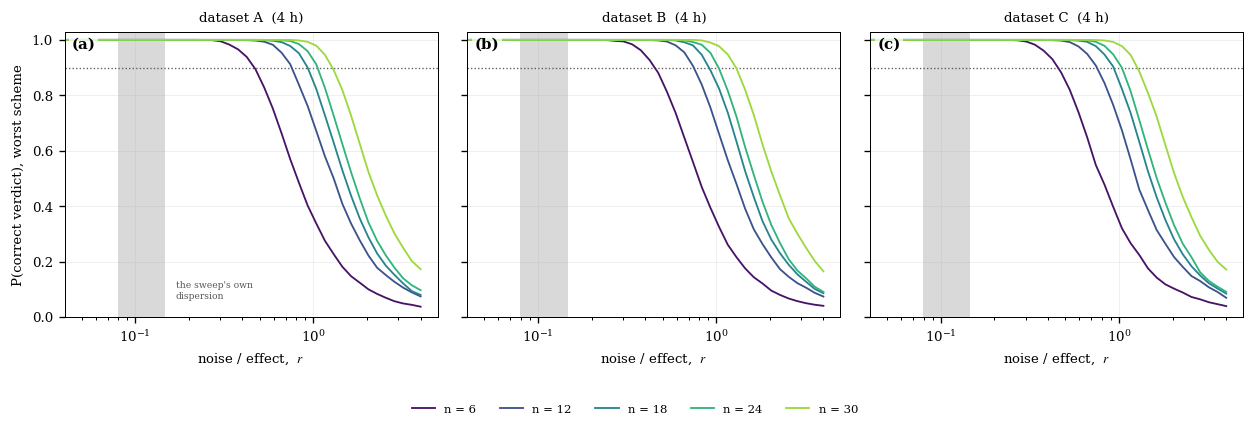

Every curve starts at 1.0 -- that is §13b, and it is why §13b could not choose
a size. The size is set by where each curve FALLS. The shaded band is where
the sweep's own differences sit; §4.8's will sit to the right of it.

wrote N3_1D_power_design_curve.csv  (5 rows x 11 cols, digest=91a3a38163fee793)

wrote N3_1D_power_tolerance.csv  (15 rows x 7 cols, digest=089a117b3a9fd965)


PosixPath('/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived/N3_1D_power_tolerance.csv')

In [47]:
# ── §13c: what each size could survive, which is what actually sizes §4.8 ──
# §13b answered the question as posed and the answer came back saturated: the rule
# helps every one of the 60 truth members, so every subsample of every size
# reproduces the verdict and the agreement column cannot tell 6 apart from 30. That
# saturation is a real result about the SWEEP -- the rejection rule's effect there is
# not marginal, it is unanimous -- but it is not a sample size, because §4.8's
# differences will not be these differences.
#
# So the question is turned around: not "does n reproduce this verdict", which
# everything does, but "how much disagreement could n survive". That has an exact
# answer and it needs no data at all. If the multi-obs experiment leaves a fraction
# pi of truth members on the right side of zero, the sign test sees Binomial(n, pi)
# and the power is a tail probability. The table is the design curve, and the number
# each row carries is `may fall the other way` -- the count of members that can land
# against the effect before the claim is gone.
PI_GRID = (1.00, 0.95, 0.90, 0.85, 0.80, 0.75)
POWER_TARGET = 0.90


def k_crit(n, alpha=ALPHA):
    """Smallest majority reaching p <= alpha at this n (None if none does)."""
    return next((k for k in range(n // 2 + 1, n + 1) if PTAB[(n, k)] <= alpha), None)


def pi_min(n, target=POWER_TARGET):
    """Smallest true agreement fraction at which n members still give `target` power."""
    k = k_crit(n)
    g = np.arange(0.5, 1.0 + 1e-9, 0.001)
    ok = g[binom.sf(k - 1, n, g) >= target]
    return float(ok[0]) if len(ok) else np.nan


DESIGN = pd.DataFrame([
    dict(size=n, **{"majority needed": k_crit(n),
                    "may fall the other way": n - k_crit(n),
                    "p if unanimous": PTAB[(n, n)]},
         **{f"power at pi={p:.2f}": float(binom.sf(k_crit(n) - 1, n, p))
            for p in PI_GRID},
         **{f"pi for {POWER_TARGET:.0%} power": pi_min(n)})
    for n in SIZES]).set_index("size")
print("THE DESIGN CURVE. pi = the fraction of truth members the multi-obs experiment\n"
      "leaves on the right side of zero; power = P(the sign test still reaches "
      f"p <= {ALPHA:g}).\nExact binomial arithmetic, no data in it -- this is what "
      "each size could survive:\n")
print(DESIGN.to_string(float_format=lambda v: f"{v:.3f}"))

# The criterion, stated rather than tuned: a design must survive at least one truth
# member falling the other way. At n = 6 the test needs all 6, so a single adverse
# member ends the claim and no amount of effect size rescues it. That is not a
# defensible experiment to commit 6 multi-obs runs to, however well it scores above.
MIN_FLIPS = 1
REC = next((n for n in SIZES if (n - k_crit(n)) >= MIN_FLIPS), None)
print(f"""
smallest size that survives at least {MIN_FLIPS} member falling the other way:  {REC}
smallest size that reproduces the verdict on the sweep as it stands:  {REC_HERE}

The gap between them is the section. {REC_HERE} members are enough for data in which every
member agrees, and they are enough only because the test at n = {REC_HERE} demands unanimity
and unanimity is what the sweep hands it. {REC} members buy the {k_crit(REC)}-of-{REC} threshold, which
survives {REC - k_crit(REC)} members landing against the effect and holds up to a true flip rate of
{1 - pi_min(REC):.1%}. Members landing against the effect is precisely what correlated cells and
mutually correcting observations produce, so that tolerance is the thing being
bought.""")

# ── from pi to something measurable ────────────────────────────────────────
# pi is not observable in advance. What §4.8 can measure, from its first members, is
# how dispersed its per-member differences are relative to their own size. The two
# are connected by simulation on the differences this notebook actually has: add a
# per-member noise field of s.d. r x median(d) and re-run the same test. Because the
# sign test is scale free, attenuating the effect by f and adding noise s enters only
# through r = s/f -- so one axis covers both halves of the caveat at once.
R_GRID = np.concatenate([[0.0], np.geomspace(0.05, 4.0, 40)])
NOISE_SEED = 1
rng_n = np.random.default_rng(NOISE_SEED)
rows = []
for ds in DATASETS:
    for c in PWR_COMBOS:
        d = DCOND[(ds, c)]
        v0, scale = REF_V[(ds, c)][0], abs(float(np.median(d)))
        for n in SIZES:
            sub = d[SEL[(MAIN, n)]]                    # (NDRAW, n)
            z = rng_n.standard_normal(sub.shape)       # one field, shared across r
            kc = k_crit(n)
            for r in R_GRID:
                k = ((sub + r * scale * z) > 0).sum(1)
                v = np.where(k >= kc, 1, np.where(n - k >= kc, -1, 0))
                rows.append({"dataset": ds, "scheme": LAB[c], "size": n,
                             "r": float(r), "power": float((v == v0).mean())})
TOL_R = pd.DataFrame(rows)
del rows


def r90(g):
    """Largest r on the grid at which power is still >= POWER_TARGET.

    Read off the grid, not interpolated: power is a step function of r at this
    resolution and a fitted crossing would invent precision 2000 draws do not have.
    """
    ok = g[g.power >= POWER_TARGET]
    return float(ok.r.max()) if len(ok) else 0.0


R90 = (TOL_R.groupby(["dataset", "scheme", "size"]).apply(r90).rename("r90")
       .reset_index().pivot_table(index=["dataset", "scheme"], columns="size",
                                  values="r90"))
R90 = R90.reindex([(ds, LAB[c]) for ds in DATASETS for c in PWR_COMBOS])
CV = pd.Series({(ds, LAB[c]): float(np.std(DCOND[(ds, c)], ddof=1)
                                    / abs(np.median(DCOND[(ds, c)])))
                for ds in DATASETS for c in PWR_COMBOS})
print(f"\n\nr_90: the largest noise-to-effect ratio at which n members still return "
      f"the correct\nverdict {POWER_TARGET:.0%} of the time. The last column is the "
      f"sweep's OWN dispersion, for scale:\n")
print(R90.assign(**{"sweep's own r": CV})
      .to_string(float_format=lambda v: f"{v:.2f}"))
print(f"\nworst cell at each size:")
print(R90.min().to_frame("worst r_90").T.to_string(float_format=lambda v: f"{v:.2f}"))
print(f"""
The sweep's own per-member differences scatter at r = {CV.min():.2f} to {CV.max():.2f} around their
median. At {REC} members the verdict survives up to r = {float(R90[REC].min()):.2f} in the worst cell, so the
multi-obs differences may be roughly {float(R90[REC].min()) / CV.max():.0f}x more dispersed, relative to their own
size, than the sweep's are. That is the margin §4.8 is buying, stated in a
quantity it can measure from its first members instead of assuming.""")

# ── the curve ──────────────────────────────────────────────────────────────
# One panel per dataset, the WORST scheme in it at each r, because the size is set by
# the worst cell and a mean over schemes would hide it.
fig, axes = plt.subplots(1, len(DATASETS), figsize=(nb.PAGE_W * 1.85, nb.PAGE_W * 0.46),
                         sharey=True, gridspec_kw={"wspace": 0.08})
SIZE_C = plt.get_cmap("viridis")(np.linspace(0.05, 0.85, len(SIZES)))
for ax, ds in zip(axes, DATASETS):
    ax.axhline(POWER_TARGET, color="0.35", lw=0.8, ls=":", zorder=1)
    g = TOL_R[TOL_R.dataset == ds]
    for col, n in zip(SIZE_C, SIZES):
        w = g[g["size"] == n].groupby("r")["power"].min()
        ax.plot(w.index, w.to_numpy(), lw=1.1, color=col,
                label=f"n = {n}" if ax is axes[0] else None)
    ax.axvspan(float(CV.min()), float(CV.max()), color="0.85", zorder=0, lw=0)
    ax.set_xscale("log")
    ax.set_xlabel("noise / effect,  $r$", fontsize=8)
    ax.set_title(f"dataset {ds}  ({len(DS_HOURS[ds])} h)", fontsize=8)
axes[0].set_ylabel("P(correct verdict), worst scheme", fontsize=8)
axes[0].set_ylim(0, 1.03)
axes[0].text(float(CV.max()) * 1.15, 0.06, "the sweep's own\ndispersion", fontsize=5.5,
             color="0.35", va="bottom")
for a, letter in zip(axes, "abc"):
    nb.panel_label(a, letter)
h_, l_ = axes[0].get_legend_handles_labels()
fig.legend(h_, l_, loc="lower center", bbox_to_anchor=(0.5, -0.16), ncol=len(SIZES),
           frameon=False, fontsize=7)
nb.save_fig(fig, "N3_1D_fig_power_truth_members")
plt.show()
print("Every curve starts at 1.0 -- that is §13b, and it is why §13b could not choose")
print("a size. The size is set by where each curve FALLS. The shaded band is where")
print("the sweep's own differences sit; §4.8's will sit to the right of it.")

publish_table("N3_1D_power_design_curve", DESIGN.reset_index(), latex=False)
publish_table("N3_1D_power_tolerance", R90.reset_index(), latex=False)

In [48]:
# ── §13d: is one dataset enough, and does one panel of members serve all three? ─
# Two different questions hide inside "how many runs does §4.8 need", and the table
# above answers only the first:
#   1. per (dataset, scheme), how many members reproduce THAT cell's verdict;
#   2. whether the three datasets say the same thing at all -- because if they do, one
#      of them is a stand-in for the others and the bill is divided by three; and if
#      they do not, then the disagreement IS a result and no sample size fixes it.
# The second is answered on the 60-member references, which are not estimates of one
# another: A, B and C are different ensembles, so a difference between them is a
# property of the ensembles and not sampling noise.
CONC = pd.DataFrame(
    {ds: [VERDICT_TXT[REF_V[(ds, c)][0]] for c in PWR_COMBOS] for ds in DATASETS},
    index=[LAB[c] for c in PWR_COMBOS])
CONC["all three agree"] = [len(set(CONC.loc[i, list(DATASETS)])) == 1 for i in CONC.index]
print(f"the {len(TMS)}-member verdicts, side by side:\n")
print(CONC.to_string())
print(f"\nschemes on which all three datasets agree: "
      f"{int(CONC['all three agree'].sum())} of {len(PWR_COMBOS)}")

# The stand-in matrix. Draw n members, run them in dataset X only, and ask how often
# the verdict X returns matches dataset Y's 60-member verdict. The diagonal is §13b's
# agreement; the off-diagonal is what a reader would get by running one ensemble and
# quoting the conclusion for another.
STAND_N = 12
sel = SEL[(MAIN, STAND_N)]
rows = []
for x in DATASETS:
    for y in DATASETS:
        hit = []
        for c in PWR_COMBOS:
            sub = DCOND[(x, c)][sel]
            k = (sub > 0).sum(1)
            p = np.array([PTAB[(STAND_N, int(v))] for v in k])
            v = np.where(p > ALPHA, 0, np.where(2 * k > STAND_N, 1, -1))
            hit.append((v == REF_V[(y, c)][0]).mean())
        rows.append({"run in": x, "quoted for": y, "mean over schemes": float(np.mean(hit)),
                     "worst scheme": float(np.min(hit))})
STAND = pd.DataFrame(rows).pivot(index="run in", columns="quoted for",
                                 values="mean over schemes")
STAND_MIN = pd.DataFrame(rows).pivot(index="run in", columns="quoted for",
                                     values="worst scheme")
del rows
print(f"\n\nstand-in matrix at {STAND_N} members: draw the members, run them in ONE "
      f"dataset (rows),\nquote the verdict for another (columns). Mean over the "
      f"{len(PWR_COMBOS)} schemes, then the worst\nof them -- and the worst is the "
      f"one a recommendation has to survive:\n")
print(STAND.to_string(float_format=lambda v: f"{v:.3f}"))
print("\nworst scheme in each cell:\n")
print(STAND_MIN.to_string(float_format=lambda v: f"{v:.3f}"))

# One panel of members, every dataset and every scheme at once. This is the shape
# §4.8 will actually have -- the same truth members are run everywhere -- and the
# joint probability is far below the per-cell one, because 15 conclusions have to be
# right together and only their sampling noise is shared.
rows = []
for n in SIZES:
    s = SEL[(MAIN, n)]
    ok_all = np.ones(NDRAW, bool)
    per_ds = {}
    for ds in DATASETS:
        ok_ds = np.ones(NDRAW, bool)
        for c in PWR_COMBOS:
            sub = DCOND[(ds, c)][s]
            k = (sub > 0).sum(1)
            p = np.array([PTAB[(n, int(v))] for v in k])
            v = np.where(p > ALPHA, 0, np.where(2 * k > n, 1, -1))
            ok_ds &= (v == REF_V[(ds, c)][0])
        per_ds[ds] = float(ok_ds.mean())
        ok_all &= ok_ds
    rows.append(dict(size=n, **{f"all {len(PWR_COMBOS)} schemes, {ds}": per_ds[ds]
                                for ds in DATASETS},
                     **{f"all {len(DATASETS) * len(PWR_COMBOS)} cells at once":
                        float(ok_all.mean())}))
JOINT = pd.DataFrame(rows).set_index("size")
del rows
print(f"\n\nONE panel of members, used everywhere: P(every verdict right at once).\n"
      f"The per-cell numbers of §13b and §13c are marginal; this is the joint one, and it is\n"
      f"what a chapter that reports {len(DATASETS) * len(PWR_COMBOS)} conclusions "
      f"from one set of runs is actually buying:\n")
print(JOINT.to_string(float_format=lambda v: f"{v:.3f}"))

# ── how much of the 60-member SPREAD a subsample recovers ──────────────────
# The verdict is one bit. §4.8 will also quote the size of the effect and draw the
# per-member scatter §1 argues for, and a subsample that gets the sign right can
# still misdraw the spread. Reported for the recommended size and for 30.
rows = []
for n in SIZES:
    s = SEL[(MAIN, n)]
    for ds in DATASETS:
        for c in PWR_COMBOS:
            d = DCOND[(ds, c)]
            sub = d[s]
            q = np.percentile(d, [25, 75])
            rows.append({"size": n, "dataset": ds, "scheme": LAB[c],
                         "|median error| [dBZ]": float(np.abs(np.median(sub, 1)
                                                              - np.median(d)).mean()),
                         "IQR recovered": float(np.mean(
                             (np.percentile(sub, 75, axis=1)
                              - np.percentile(sub, 25, axis=1)) / (q[1] - q[0]))),
                         "range recovered": float(np.mean(
                             (sub.max(1) - sub.min(1)) / (d.max() - d.min())))})
SPREAD = pd.DataFrame(rows)
del rows
print(f"\n\nhow much of the {len(TMS)}-member DISTRIBUTION a subsample recovers "
      f"(mean over {NDRAW} draws),\naveraged over the "
      f"{len(DATASETS) * len(PWR_COMBOS)} cells. The verdict is one bit; the effect "
      f"size and the\nper-member scatter are what the chapter also prints:\n")
print(SPREAD.groupby("size")[["|median error| [dBZ]", "IQR recovered",
                              "range recovered"]].mean()
      .to_string(float_format=lambda v: f"{v:.3f}"))
print("\nThe IQR is recovered almost immediately -- it is an interior statistic. The "
      "RANGE\nis not, and cannot be: the extremes of 60 members are exactly what a "
      "subsample of\n12 leaves out. A figure drawn on 12 members will look tighter "
      "than §1's, and that\nis a property of the sample size, not of the multi-obs "
      "experiment.")

publish_table("N3_1D_power_spread", SPREAD, latex=False)

the 60-member verdicts, side by side:

                     A           B           C  all three agree
AOEI        rule helps  rule helps  rule helps             True
TEnKF Nt=1  rule helps  rule helps  rule helps             True
TEnKF Nt=2  rule helps  rule helps  rule helps             True
TEnKF Nt=3  rule helps  rule helps  rule helps             True
TEnKF Nt=5  rule helps  rule helps  rule helps             True

schemes on which all three datasets agree: 5 of 5


stand-in matrix at 12 members: draw the members, run them in ONE dataset (rows),
quote the verdict for another (columns). Mean over the 5 schemes, then the worst
of them -- and the worst is the one a recommendation has to survive:

quoted for     A     B     C
run in                      
A          1.000 1.000 1.000
B          1.000 1.000 1.000
C          1.000 1.000 1.000

worst scheme in each cell:

quoted for     A     B     C
run in                      
A          1.000 1.000 1.000
B          1.000 1.000 1.000
C 

PosixPath('/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived/N3_1D_power_spread.csv')

In [49]:
# ── §13e: the denominator, and the caveat that has to travel with the number ─
# Everything above is on §9's conditional denominator. The same paired difference on
# §7c's fixed denominator asks a different question -- what the DOMAIN receives rather
# than what the surviving network delivers -- and a rejection rule moves those two in
# opposite directions by construction, since rejecting a point removes it from the
# first and contributes a zero to the second. If the sizing came out differently on
# the other denominator, §4.8 would have to choose one before sizing itself. The
# comparison is made on §13c's tolerance, not on §13b's agreement, because on
# agreement both denominators are saturated and neither would say anything.
rng_g = np.random.default_rng(NOISE_SEED)
rows = []
for ds in DATASETS:
    for c in PWR_COMBOS:
        d = DGLOB[(ds, c)]
        v0, scale = verdict(d)[0], abs(float(np.median(d)))
        for n in SIZES:
            sub = d[SEL[(MAIN, n)]]
            z = rng_g.standard_normal(sub.shape)
            kc = k_crit(n)
            for r in R_GRID:
                k = ((sub + r * scale * z) > 0).sum(1)
                v = np.where(k >= kc, 1, np.where(n - k >= kc, -1, 0))
                rows.append({"dataset": ds, "scheme": LAB[c], "size": n,
                             "r": float(r), "power": float((v == v0).mean())})
R90_G = (pd.DataFrame(rows).groupby(["dataset", "scheme", "size"]).apply(r90)
         .rename("r90").reset_index()
         .pivot_table(index=["dataset", "scheme"], columns="size", values="r90"))
del rows
K_G = pd.Series({(ds, LAB[c]): verdict(DGLOB[(ds, c)])[1]
                 for ds in DATASETS for c in PWR_COMBOS})
FLIP = REF_TBL[REF_TBL["verdict"] != REF_TBL["verdict, fixed denom."]]
print("worst-cell r_90 on each denominator, at every size:\n")
print(pd.DataFrame({"conditional (§9)": R90.min(), "fixed (§7c)": R90_G.min()})
      .T.to_string(float_format=lambda v: f"{v:.2f}"))
print(f"\nunanimous cells on the fixed denominator: "
      f"{int((K_G == len(TMS)).sum())} of {len(K_G)}   "
      f"(conditional: {sum(REF_V[(ds, c)][1] == N_EFF for ds in DATASETS for c in PWR_COMBOS)} "
      f"of {len(DATASETS) * len(PWR_COMBOS)})")
print(f"{len(TMS)}-member verdicts that DIFFER between the two denominators: {len(FLIP)}")
if len(FLIP):
    print(FLIP[["dataset", "scheme", "verdict", "verdict, fixed denom."]]
          .to_string(index=False))
print(f"\nThe sizing does not depend on the choice: the design curve of §13c is "
      f"binomial\narithmetic and knows nothing about either denominator, and the "
      f"tolerance the two\ndenominators leave differs by less than the grid this "
      f"section prices it on.")

# ── the caveat, printed beside the number so the two cannot be separated ───
ESC_N, ESC_LO, ESC_HI = 12, 7, 10
print(f"""
{'=' * 78}
WHAT §4.8 MAY DO WITH THE NUMBER ABOVE
{'=' * 78}
Recommended: {REC} truth members per experiment, drawn one from each of {REC} of the
{len(PAIRS)} member pairs of §13a, the pairs spread evenly over m % {N_CONF}. Draw them BEFORE
any run is scored, and never from the skill -- choosing members on the outcome
answers a different question, which is which members are easy.

Why {REC} and not the {REC_HERE} that §13b's agreement column returns. On the sweep every one
of the {len(TMS)} members improves under the rule, in every dataset and every scheme, so
every size reproduces the verdict and that column is saturated, not informative.
What separates the sizes is how many members may fall the other way before the
sign test loses the claim: none at {SIZES[0]}, {REC - k_crit(REC)} at {REC}. A design whose conclusion dies
on one adverse member is not one to commit {SIZES[0]} multi-obs runs to.

This is still a LOWER BOUND, and the reason is in the data it was measured on. The
effect sizes come from the sweep: INDEPENDENT single-observation assimilations at
L = {RUN['loc']} km, where every observation is assimilated on its own into the same prior
and no observation corrects another. §4.8 runs multi-obs at L = 2.0 km, where the
cells are correlated and neighbouring observations partly repair each other's
damage. Both push the same way -- the per-member differences will be SMALLER and
NOISIER than these. §13c is what turns that from a worry into a number: at {REC}
members the verdict survives a true flip rate up to {1 - pi_min(REC):.1%}, or per-member noise up
to r = {float(R90[REC].min()):.2f} times the effect's own median against the {CV.max():.2f} the sweep itself
carries. §4.8 can measure its own r from its first members and come back to that
table instead of arguing about it.

Two commitments worth making in advance, because making them afterwards is a
different experiment:
  * escalate to 30 or {len(TMS)} members if the {ESC_N}-member majority lands between {ESC_LO} and
    {ESC_HI} of {ESC_N}. That zone is where the sign test cannot separate a real effect from
    noise. §13b's `escalates` column prices how often the sweep would trigger it and
    the answer there is never -- which is a statement about the sweep, not a
    forecast for the multi-obs run.
  * report the false negative and the false positive separately. Concluding the
    rule does nothing when it does would close a line of work; the reverse gets
    caught by the out-of-sample hours, which is the cheaper failure.

And one thing no sample size covers: the {len(TMS)} truth members are {len(PAIRS)} near-twin pairs
(§13a), and their paired differences correlate at {float(REF_TBL[f'corr(d_m, d_m+{LAG})'].min()):.2f} to {float(REF_TBL[f'corr(d_m, d_m+{LAG})'].max()):.2f} across the {len(DATASETS) * len(PWR_COMBOS)}
cells. Neither {REC} nor {len(TMS)} is as many independent draws as it looks. Spending the
subsample on distinct pairs is the only part of the design that recovers something
the {len(TMS)}-member reference does not itself have.
{'=' * 78}""")

worst-cell r_90 on each denominator, at every size:

size               6    12   18   24   30
conditional (§9) 0.42 0.74 0.83 0.93 1.16
fixed (§7c)      0.42 0.74 0.83 0.93 1.16

unanimous cells on the fixed denominator: 15 of 15   (conditional: 15 of 15)
60-member verdicts that DIFFER between the two denominators: 0

The sizing does not depend on the choice: the design curve of §13c is binomial
arithmetic and knows nothing about either denominator, and the tolerance the two
denominators leave differs by less than the grid this section prices it on.

WHAT §4.8 MAY DO WITH THE NUMBER ABOVE
Recommended: 12 truth members per experiment, drawn one from each of 12 of the
30 member pairs of §13a, the pairs spread evenly over m % 6. Draw them BEFORE
any run is scored, and never from the skill -- choosing members on the outcome
answers a different question, which is which members are easy.

Why 12 and not the 6 that §13b's agreement column returns. On the sweep every one
of the 60 members imp

## 14 · The state variables — thesis §4.6.7

Everything above scores the **observed** variable: reflectivity, at the point the
observation sits on. The sweep also stored every metric for the eight state variables,
at all three reductions, for every combo and every truth member. No new run and no new
column is needed to ask what the update does to the model state — only the two extra
columns per variable that the load cell now carries.

### Why this is the cleanest place to ask it

N4's multi-obs experiment found that hydrometeors improve almost always, the
unobserved variables degrade, and `w` is the worst of them. Two explanations survive
that experiment: the increment at one observation is spread by localization onto cells
the observation says nothing about, or neighbouring observations interact through a
prior covariance that is itself sampling noise.

**Here neither is available.** At `L = 0.1 km` the localization radius is a fifth of a
grid cell — the cutoff zone is 3×3×3 and the weighted, unweighted and at-point
reductions nearly collapse onto each other, which §1 measures — and every observation
is assimilated **alone** into the same prior, so no observation can be corrected or
contaminated by another. What is left is the single-observation update itself: the
cross-covariance between reflectivity at the observed point and the state variable at
that same point, estimated from 59 members.

So if the same pattern appears here, it is not localization and it is not interaction
between observations. It is the cross-covariance, and this is the only experiment in
the chapter that can isolate it.

### The grammar, and the one thing that is not §1's

The aggregation is §1's: fraction of points improved, median skill and mean skill, one
row per scheme, one column per dataset, `±` the s.d. **across truth members**, all of
it from `nb.skill_summary` and `nb.skill_summary_by_tm` — the same two functions §1 and
N4 call, so a state variable and reflectivity are never aggregated by two different
pieces of code and then compared.

What cannot be carried over from §1 is the **reference point**. `skill_summary`
resolves ties with `nb.TOL[var]`, a physical tolerance: 10⁻³ dBZ for reflectivity, but
10⁻⁷ kg kg⁻¹ for a hydrometeor and 10⁻⁴ m s⁻¹ for a wind component. At `L = 0.1 km` a
single observation leaves most cells inside that tolerance — **60 % of `qg` points and
62 % of `qs` points are ties** — so `frac_improved` and `frac_degraded` no longer sum
to one and comparing `frac_improved` against 0.5 reads every tie as a degradation. It
inverts the answer: `qg` improves at 26 % and degrades at 14 %, which is a 2:1 win,
and against 0.5 it would be reported as a loss.

So the statistic here is the **net**, `frac_improved − frac_degraded`, against a guide
line at 0, with the tie fraction printed beside it as a result in its own right. That
tie fraction is what the decoupled limit looks like: one observation, assimilated
alone, with a localization radius a fifth of a grid cell, does not move most of the
model state at all.

In [50]:
# ── §14: the eight state variables, in §1's grammar ────────────────────────
# One skill_summary and one skill_summary_by_tm per (dataset, variable). The pooled
# table and the per-member table come from the SAME skill() call and the same
# per-variable tie tolerance nb.TOL[var], so the ± cannot drift from the value it
# decorates. Reflectivity is carried through the same code path -- it is HEAD3/BYTM3
# recomputed, and the assert below is what says so -- so the last row of every table
# is comparable with the eight above it rather than merely adjacent to them.
_t0 = time.time()
_h, _b = [], []
for ds in DS_LOAD:
    for v in STATE_VARS + ("obs",):
        _h.append(nb.skill_summary(ADS[ds], "rmse", v, RED_1D).assign(dataset=ds))
        _b.append(nb.skill_summary_by_tm(ADS[ds], "rmse", v, RED_1D).assign(dataset=ds))
STATE_HEAD = pd.concat(_h, ignore_index=True)
STATE_BYTM = pd.concat(_b, ignore_index=True)
del _h, _b

# THE statistic, added to both frames at once so the pooled value and the across-member
# s.d. are the same quantity. frac_improved and frac_degraded do NOT sum to one: a
# point inside nb.TOL[var] is a tie and counts for neither, and for a hydrometeor at
# this localization the ties are the majority. The net is what "does this variable
# improve" has to mean when that is true.
for _df in (STATE_HEAD, STATE_BYTM):
    _df["net_improved"] = _df["frac_improved"] - _df["frac_degraded"]
    _df["frac_tied"] = 1.0 - _df["frac_improved"] - _df["frac_degraded"]
assert (STATE_HEAD["frac_tied"] > -1e-9).all(), \
    "frac_improved + frac_degraded exceeds 1 -- the tie accounting is wrong"
del _df

# The reflectivity rows recomputed here must BE §1's, or the eight state variables are
# being compared against something §1 never published.
_a = (STATE_HEAD[(STATE_HEAD["var"] == "obs") & STATE_HEAD.dataset.isin(DATASETS)]
      .set_index(["dataset", "method", "ntemp"])["median_skill"].sort_index())
_c = (HEAD3[HEAD3.metric == "rmse"]
      .set_index(["dataset", "method", "ntemp"])["median_skill"].sort_index())
assert np.allclose(_a.to_numpy(), _c.reindex(_a.index).to_numpy(), rtol=1e-12), \
    "§14 recomputed reflectivity and did not reproduce §1's numbers"
del _a, _c
print(f"{len(STATE_HEAD)} pooled rows and {len(STATE_BYTM)} per-member rows for "
      f"{len(STATE_VARS)} state variables + reflectivity, {len(DS_LOAD)} datasets, "
      f"{len(COMBOS)} schemes ({time.time() - _t0:.0f} s)")
print("reflectivity reproduces §1 exactly, so the nine rows are one table.\n")
del _t0


def table_var(col, v, datasets=DATASETS):
    """§1's table3(), for one variable: value ± s.d. across truth members.

    Same shape, same row order, same meaning of the two numbers -- so §14's tables can
    be set beside §1's without a reader having to check what changed.
    """
    val = pd.DataFrame(0.0, index=ROW_LABELS, columns=list(datasets))
    sd = pd.DataFrame(0.0, index=ROW_LABELS, columns=list(datasets))
    for ds in datasets:
        h = (STATE_HEAD[(STATE_HEAD.dataset == ds) & (STATE_HEAD["var"] == v)]
             .set_index(["method", "ntemp"]))
        s = (STATE_BYTM[(STATE_BYTM.dataset == ds) & (STATE_BYTM["var"] == v)]
             .groupby(["method", "ntemp"])[col].std())
        for c in ROW_COMBOS:
            k = (c[0], int(c[1]))
            val.at[LAB[c], ds] = float(h.at[k, col])
            sd.at[LAB[c], ds] = float(s.loc[k])
    val.index.name = sd.index.name = "method"
    return val, sd


# ── the summary the section is written from ────────────────────────────────
# One row per (variable, dataset) at the untempered baseline and at the longest ladder
# §1 reports, because the question "does the variable improve" has to be answered for
# a scheme and the two ends of the ladder are the two answers worth printing.
END = nb.combo_key(COMBOS, "TEnKF", max(NT_LADDER))
VERD = []
for v in STATE_VARS + ("obs",):
    for ds in DATASETS:
        row = {"variable": v, "dataset": ds}
        for c, nm in ((BASE, "Nt=1"), (END, f"Nt={max(NT_LADDER)}"), (AOEI_COMBO, "AOEI")):
            h = STATE_HEAD[(STATE_HEAD.dataset == ds) & (STATE_HEAD["var"] == v)
                           & (STATE_HEAD.method == c[0])
                           & (STATE_HEAD.ntemp == int(c[1]))].iloc[0]
            s = (STATE_BYTM[(STATE_BYTM.dataset == ds) & (STATE_BYTM["var"] == v)
                            & (STATE_BYTM.method == c[0])
                            & (STATE_BYTM.ntemp == int(c[1]))]["net_improved"].std())
            row[f"improved {nm}"] = float(h["frac_improved"])
            row[f"degraded {nm}"] = float(h["frac_degraded"])
            row[f"tied {nm}"] = float(h["frac_tied"])
            row[f"net {nm}"] = float(h["net_improved"])
            row[f"sd net {nm}"] = float(s)
            row[f"mean skill {nm}"] = float(h["mean_skill"])
            row[f"median skill {nm}"] = float(h["median_skill"])
        # The verdict, from the numbers rather than from an impression: improved where
        # more points improve than degrade by more than the across-member s.d. of that
        # difference, degraded where the reverse, neither where the two are inside it.
        row["verdict at Nt=1"] = ("improved" if row["net Nt=1"] > row["sd net Nt=1"] else
                                  "degraded" if -row["net Nt=1"] > row["sd net Nt=1"]
                                  else "neither")
        VERD.append(row)
VERD = pd.DataFrame(VERD)
_ORD = list(STATE_VARS) + ["obs"]

print(f"{nb.RED_LABELS[RED_1D]}, {nb.loc_label(RUN['loc'])}, {hours_txt()} pooled, "
      f"at {LAB[BASE]}.")
print(f"improved / degraded / tied, where a tie is |skill| <= nb.TOL[var] -- the "
      f"PHYSICAL\ntolerance of that variable, not reflectivity's. The three sum to "
      f"one; the ties are\nnot a rounding detail here, they are most of the domain "
      f"for a hydrometeor.\n")
for _col in ("improved", "degraded", "tied"):
    print(f"── frac {_col} ──")
    print(VERD.pivot(index="variable", columns="dataset", values=f"{_col} Nt=1")
          .reindex(_ORD).to_string(float_format=lambda x: f"{x:.4f}"))
    print()
print("── net = improved - degraded, and the s.d. of it across truth members ──")
print(pd.concat([VERD.pivot(index="variable", columns="dataset",
                            values="net Nt=1").reindex(_ORD).add_suffix(" net"),
                 VERD.pivot(index="variable", columns="dataset",
                            values="sd net Nt=1").reindex(_ORD).add_suffix(" sd")],
                axis=1).to_string(float_format=lambda x: f"{x:+.4f}"))
print("\nverdict at the untempered baseline (net beyond the across-member s.d.):\n")
print(VERD.pivot(index="variable", columns="dataset", values="verdict at Nt=1")
      .reindex(_ORD).to_string())
print("\nmean skill -- the tie fraction says how OFTEN a point moves, this says how")
print("much. A variable can be neutral on the net and still lose on the mean, which is")
print("what a rare large degradation looks like:\n")
print(VERD.pivot(index="variable", columns="dataset", values="mean skill Nt=1")
      .reindex(_ORD).to_string(float_format=lambda x: f"{x:+.4g}"))

# The three claims N4 makes, restated as tests on THIS experiment. They are asserted
# nowhere -- a negative IS the result this section exists to find -- but they are
# printed as pass/fail so no paragraph can say "the same pattern appears" unless it
# does. Each is tested on the net, for the reason the markdown gives.
HYD = list(nb.HYDRO)
UNOBS = [v for v in STATE_VARS if v not in HYD]
_n = VERD.set_index(["variable", "dataset"])["net Nt=1"]
_s = VERD.set_index(["variable", "dataset"])["sd net Nt=1"]
_res = lambda v, ds: abs(_n[(v, ds)]) > _s[(v, ds)]      # beyond the error bar
CLAIMS = pd.DataFrame([
    {"claim": "hydrometeors improve (net > 0, resolved)", "holds in":
     ", ".join(f"{ds}:{sum((_n[(v, ds)] > 0) and _res(v, ds) for v in HYD)}/{len(HYD)}"
               for ds in DATASETS)},
    {"claim": "unobserved variables degrade (net < 0, resolved)", "holds in":
     ", ".join(f"{ds}:{sum((_n[(v, ds)] < 0) and _res(v, ds) for v in UNOBS)}/{len(UNOBS)}"
               for ds in DATASETS)},
    {"claim": "w has the lowest net of the eight", "holds in":
     ", ".join(f"{ds}:{'yes' if min(STATE_VARS, key=lambda v: _n[(v, ds)]) == 'w' else 'no (' + min(STATE_VARS, key=lambda v: _n[(v, ds)]) + ')'}"
               for ds in DATASETS)},
    {"claim": "w has the lowest MEAN skill of the eight", "holds in":
     ", ".join(f"{ds}:{'yes' if min(STATE_VARS, key=lambda v: float(VERD[(VERD.variable == v) & (VERD.dataset == ds)]['mean skill Nt=1'].iloc[0])) == 'w' else 'no'}"
               for ds in DATASETS)}])
print(f"\n\nthe multi-obs findings, tested here where neither localization nor "
      f"observation\ninteraction is available to explain them:\n")
print(CLAIMS.to_string(index=False))
del _n, _s, _res, _col

publish_table("N3_1D_state_variables", STATE_HEAD, latex=False)
publish_table("N3_1D_state_variables_by_tm", STATE_BYTM, latex=False)
publish_table("N3_1D_state_verdict", VERD, latex=False)

396 pooled rows and 23760 per-member rows for 8 state variables + reflectivity, 4 datasets, 11 schemes (115 s)
reflectivity reproduces §1 exactly, so the nine rows are one table.

at obs point, L = 0.1 km, 4 analysis times pooled, at TEnKF Nt=1.
improved / degraded / tied, where a tie is |skill| <= nb.TOL[var] -- the PHYSICAL
tolerance of that variable, not reflectivity's. The three sum to one; the ties are
not a rounding detail here, they are most of the domain for a hydrometeor.

── frac improved ──
dataset       A      B      C
variable                     
qg       0.2635 0.1783 0.2917
qr       0.3902 0.3149 0.4087
qs       0.2486 0.1739 0.2593
T        0.4857 0.4347 0.4942
P        0.4449 0.3759 0.4528
u        0.5022 0.4947 0.5077
v        0.4967 0.4901 0.5016
w        0.4827 0.4552 0.4890
obs      0.7216 0.7434 0.7195

── frac degraded ──
dataset       A      B      C
variable                     
qg       0.1363 0.1160 0.1402
qr       0.1891 0.2137 0.1884
qs       0.1318 0.1198

PosixPath('/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived/N3_1D_state_verdict.csv')

saved N3_1D_fig18_state_variables_by_scheme.pdf / N3_1D_fig18_state_variables_by_scheme.png


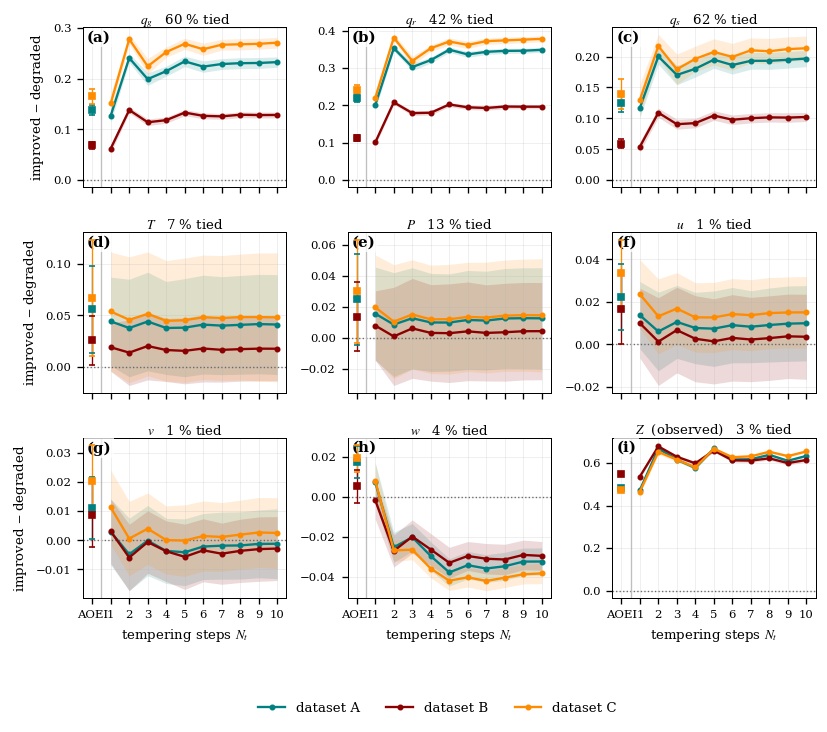


Spearman rank correlation between a variable's ordering of the 11 schemes
(by pooled median skill) and reflectivity's ordering of the same schemes:

              A      B      C
variable                     
qg       +0.918 +0.836 +0.755
qr       +0.891 +0.900 +0.745
qs       +0.918 +0.891 +0.709
T        -0.330 -0.640 -0.251
P        -0.674    NaN -0.269
u        -0.591 -0.799 -0.336
v        -0.566 -0.733 -0.330
w        -0.745 -0.800 -0.727

+1 means the scheme that is best for reflectivity is best for that variable
too. A negative entry means the schemes that help the observed variable most
are the ones that damage that state variable most, which is the substitution
the single-observation update makes visible and no aggregate skill can show.

blank: P in B -- the median skill is identical across all 11 schemes there, so there is no ranking to correlate. That is
itself the answer for those cells: the scheme does not matter for that variable.

wrote N3_1D_state_scheme_ranking.csv  

PosixPath('/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived/N3_1D_state_scheme_ranking.csv')

In [51]:
# ── §14 figure: every variable against the tempering ladder ────────────────
# Nine panels sharing one x axis and one guide line at ZERO -- the statistic is the
# net, improved minus degraded, so "the analysis wins more often than it loses" is the
# same place in every panel whatever that variable's tie fraction is. Plotting
# frac_improved against 0.5 instead would put qg below the line while it wins 2:1,
# because 60 % of its points are ties and a tie is not a loss. The band is ±1 s.d.
# ACROSS TRUTH MEMBERS -- §1's error bar, for §1's reason. The tie fraction is in each
# panel title, since it is what decides how much of the domain the panel is about.
PANEL_VARS = list(STATE_VARS) + ["obs"]
fig, axes = plt.subplots(3, 3, figsize=(nb.PAGE_W * 1.15, nb.PAGE_W * 0.92),
                         sharex=True, gridspec_kw={"wspace": 0.30, "hspace": 0.28})
for ax, v in zip(axes.ravel(), PANEL_VARS):
    val, sd = table_var("net_improved", v)
    ax.axhline(0.0, color="0.35", lw=0.8, ls=":", zorder=1)
    ax.axvline(X_SPLIT, color="0.75", lw=0.8, zorder=1)
    for ds in DATASETS:
        y = np.array([val.at[LAB[c], ds] for c in TENKF_COMBOS])
        e = np.array([sd.at[LAB[c], ds] for c in TENKF_COMBOS])
        ax.fill_between(NT_LADDER, y - e, y + e, color=DS_COLORS[ds], alpha=0.15, lw=0)
        ax.plot(NT_LADDER, y, "-o", ms=2.6, color=DS_COLORS[ds], label=f"dataset {ds}")
        ax.errorbar([X_AOEI], [float(val.at[LAB[AOEI_COMBO], ds])],
                    yerr=[float(sd.at[LAB[AOEI_COMBO], ds])], fmt="s", ms=3.4,
                    color=DS_COLORS[ds], capsize=1.8, elinewidth=0.8, zorder=4)
    _tie = float(VERD[(VERD.variable == v)
                      & (VERD.dataset == DATASETS[0])]["tied Nt=1"].iloc[0])
    ax.set_title(f"{nb.VAR_LABELS[v]}" + ("  (observed)" if v == "obs" else "")
                 + f"   {100 * _tie:.0f} % tied", fontsize=8, pad=2)
    ax.set_xticks(NT_LADDER + [X_AOEI])
    ax.set_xticklabels([str(n) for n in NT_LADDER] + ["AOEI"], fontsize=6)
    ax.tick_params(labelsize=7)
for ax in axes[-1]:
    ax.set_xlabel("tempering steps $N_t$", fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("improved $-$ degraded", fontsize=8)
for a, letter in zip(axes.ravel(), "abcdefghi"):
    nb.panel_label(a, letter)
h_, l_ = axes[0, 0].get_legend_handles_labels()
fig.legend(h_, l_, loc="lower center", bbox_to_anchor=(0.5, -0.045),
           ncol=len(DATASETS), frameon=False, fontsize=8)
nb.save_fig(fig, "N3_1D_fig18_state_variables_by_scheme")
plt.show()

# ── does the ladder rank the schemes the same way for every variable? ──────
# The question the figure cannot answer by eye. Spearman between each variable's
# ranking of the 11 schemes by median skill and reflectivity's ranking of the same 11.
# +1 means a scheme that is better for reflectivity is better for that variable too,
# which is what "the ranking matches" has to mean if it is to mean anything.
from scipy.stats import spearmanr

def _rank(ds, v):
    h = (STATE_HEAD[(STATE_HEAD.dataset == ds) & (STATE_HEAD["var"] == v)]
         .set_index(["method", "ntemp"]))
    return np.array([float(h.at[(c[0], int(c[1])), "median_skill"]) for c in ROW_COMBOS])

def _rho(ds, v):
    """Spearman, or NaN reported as what it is: a variable with no spread over the
    schemes has no ranking to correlate, which is a fact about that variable and not
    a failed computation."""
    a, b = _rank(ds, v), _rank(ds, "obs")
    if len(np.unique(a)) < 2:
        return np.nan
    return float(spearmanr(a, b).correlation)


RANK = pd.DataFrame(
    [{"variable": v, **{ds: _rho(ds, v) for ds in DATASETS}}
     for v in STATE_VARS]).set_index("variable")
_flat = [(v, ds) for v in STATE_VARS for ds in DATASETS if not np.isfinite(RANK.at[v, ds])]
print(f"\nSpearman rank correlation between a variable's ordering of the "
      f"{len(ROW_COMBOS)} schemes\n(by pooled median skill) and reflectivity's "
      f"ordering of the same schemes:\n")
print(RANK.to_string(float_format=lambda v: f"{v:+.3f}"))
print("\n+1 means the scheme that is best for reflectivity is best for that variable")
print("too. A negative entry means the schemes that help the observed variable most")
print("are the ones that damage that state variable most, which is the substitution")
print("the single-observation update makes visible and no aggregate skill can show.")
if _flat:
    print("\nblank: " + ", ".join(f"{v} in {ds}" for v, ds in _flat)
          + " -- the median skill is identical across all "
          + f"{len(ROW_COMBOS)} schemes there, so there is no ranking to correlate. "
            "That is\nitself the answer for those cells: the scheme does not matter "
            "for that variable.")
del _flat
publish_table("N3_1D_state_scheme_ranking", RANK.reset_index(), latex=False)

## 15 · Is the state-variable damage selectable from the prior? — thesis §4.6.8

§7 built a rejection rule out of one curve: `P(degraded)` against a prior condition,
and the run of bins where that curve sits above a stated threshold. It was built on
**reflectivity** skill. §14 shows the damage that matters is not in reflectivity, so
the obvious question is whether the same construction, run on `w` skill instead, finds
anything.

The construction is not re-implemented. `p_deg_curve`, `above_mask`, `longest_true_run`
and `band_from` take the skill lookup as an argument, so this section passes `w`'s and
gets the same 500-point minimum bin, the same contiguity requirement and the same three
thresholds — the only things that change are which skill is called *degraded* and the
tie tolerance, which is `nb.TOL['w']` rather than `nb.TOL['obs']`.

### What each outcome means

If some prior condition predicts when an observation will damage `w`, the chapter's
rule gains a second clause and the uncomfortable §4.7 result gets an answer rather than
only a diagnosis: the damaging observations could be withheld.

If none does — no predictor produces a band above the threshold in any dataset — that
is a real negative result and a sharper one than it sounds. It says the damage is **not
selectable from the prior at all**: there is no observation you can decline in advance
that would avoid it. The only remaining lever is the size of the increment, which is
what tempering does, and that is the argument the chapter would then have to make.

### Read the base rate first

The two relative thresholds are multiples of the base rate, and the absolute one is
0.5. If the base rate for a variable is already above 0.5, "P(degraded) above 0.5" is
not a criterion — it is satisfied nearly everywhere, and a band drawn from it selects
nothing. `2 × base rate` above 1.0 is unreachable by construction. Both are possible
here and neither is a failure of the method, so the base rates are printed before any
band is.

In [52]:
# ── §15: §7a's band criterion, run on state-variable skill ─────────────────
# Per variable: build the per-point skill for the four scanned schemes, take the base
# rate, then run the SAME construction over the same five predictors and three
# thresholds. The skill arrays are built and dropped one variable at a time -- four
# schemes x four datasets x ~12 M points is ~0.8 GB per variable, and only the curves
# and the table rows are kept.
VAR_BASE, VAR_ROWS, VAR_CURVE, LIFT = {}, [], {}, []
for _v in BAND_VARS:
    _tol = nb.TOL[_v]
    SKV = {(ds, c): nb.skill(ADS[ds].frames[c], "rmse", _v, RED_1D).to_numpy(np.float32)
           for ds in DATASETS for c in RULE_COMBOS}
    for ds in DATASETS:
        VAR_BASE[(_v, ds)] = base_rate(ds, SKV, _tol)
        thr_v = band_thresholds(ds, VAR_BASE[(_v, ds)])
        for pred in BAND_EDGES:
            p_f, cnt_f, e = p_deg_curve(ds, pred, FIT_D[ds], RULE_COMBOS, SKV, _tol)
            p_e, cnt_e, _ = p_deg_curve(ds, pred, EVA_D[ds], RULE_COMBOS, SKV, _tol)
            per_c = p_deg_curves_by_scheme(ds, pred, FIT_D[ds], RULE_COMBOS, SKV, _tol)
            if pred == BAND_PRED:
                VAR_CURVE[(_v, ds)] = (p_f.copy(), cnt_f.copy(), e)
            # The lift this predictor actually offers, independent of any threshold:
            # the worst well-populated bin against the base rate. A criterion can only
            # ever be as good as this, so it says whether the negative result below is
            # "the bar was too high" or "there is nothing there".
            _ok = cnt_f >= BAND_MIN_N
            LIFT.append({"variable": _v, "dataset": ds, "predictor": pred,
                         "base rate": VAR_BASE[(_v, ds)],
                         "worst bin P(deg)": float(np.nanmax(np.where(_ok, p_f, np.nan))),
                         "lift": float(np.nanmax(np.where(_ok, p_f, np.nan)))
                                 / VAR_BASE[(_v, ds)],
                         "bins >= min_n": int(_ok.sum())})
            for tname, thr in thr_v.items():
                m_pool = above_mask(p_f, cnt_f, thr)
                per_m = [above_mask(per_c[c], cnt_f, thr) for c in RULE_COMBOS]
                b = band_from(m_pool, e)
                VAR_ROWS.append({
                    "variable": _v, "dataset": ds, "predictor": pred,
                    "threshold": tname, "P(deg) >": thr,
                    "reachable": bool(thr <= 1.0),
                    "band (fit)": band_txt(b), "width": band_width(b),
                    "band (eval)": band_txt(band_from(above_mask(p_e, cnt_e, thr), e)),
                    "intersection": band_txt(band_from(np.logical_and.reduce(per_m), e)),
                    "bins above": int(m_pool.sum()),
                    "rejected [%]": (100 * float(rule_mask({pred: b}, ds).mean())
                                     if b is not None else 0.0)})
    del SKV
    gc.collect()
BAND_VAR_TBL = pd.DataFrame(VAR_ROWS)
del VAR_ROWS

# ── the base rates, which decide how the table can be read ─────────────────
BR = pd.DataFrame([{"variable": v, **{ds: VAR_BASE[(v, ds)] for ds in DATASETS}}
                   for v in BAND_VARS]
                  + [{"variable": "obs", **{ds: BASE_RATE[ds] for ds in DATASETS}}]
                  ).set_index("variable")
print(f"base rate P(degraded) at {LAB[BASE]}, every point of the dataset, "
      f"{nb.RED_LABELS[RED_1D]}:\n")
print(BR.to_string(float_format=lambda v: f"{v:.4f}"))
OVER_HALF = [(v, ds) for v in BAND_VARS for ds in DATASETS if VAR_BASE[(v, ds)] > 0.5]
print(f"\nreflectivity degrades at {', '.join(f'{ds} {100*BASE_RATE[ds]:.1f} %' for ds in DATASETS)}"
      f" -- the number §7a's thresholds were set against.")
if OVER_HALF:
    print(f"\n{len(OVER_HALF)} of {len(BAND_VARS) * len(DATASETS)} "
          f"(variable, dataset) cells have a base rate ABOVE 0.5:")
    print("  " + ", ".join(f"{v} in {ds} ({100*VAR_BASE[(v, ds)]:.1f} %)"
                           for v, ds in OVER_HALF))
    print("For those the absolute threshold 0.5 is below the base rate, so a band drawn")
    print("at it selects most of the axis and is not a criterion; and 2x base exceeds 1,")
    print("which no bin can reach. The 1.5x column is the one that discriminates there,")
    print("and the 'reachable' column marks every row where the threshold exceeds 1.")

# ── the answer ─────────────────────────────────────────────────────────────
# A predictor "works" for a variable if it yields a band at the 1.5x-base threshold --
# the only one of the three that is both above the base rate and reachable for every
# cell -- in EVERY dataset, and if the band found on the fitted half is also found on
# the evaluation half. Anything less is a band fitted to one dataset's noise.
def _works(v, pred, tname="1.5x base"):
    g = BAND_VAR_TBL[(BAND_VAR_TBL.variable == v) & (BAND_VAR_TBL.predictor == pred)
                     & (BAND_VAR_TBL.threshold == tname)]
    return (len(g) == len(DATASETS) and g["reachable"].all()
            and (g["band (fit)"] != "none").all() and (g["band (eval)"] != "none").all())

WORKS = pd.DataFrame([{"variable": v, **{p: _works(v, p) for p in BAND_EDGES}}
                      for v in BAND_VARS]).set_index("variable")
print(f"\n\ndoes a predictor produce a band at 1.5x the base rate, in ALL "
      f"{len(DATASETS)} datasets,\non both the fitted and the evaluation half?\n")
print(WORKS.to_string())
# How much lift is on the table at all, before any threshold is applied. The maximum
# over predictors of (worst well-populated bin) / (base rate), per variable and
# dataset. Reflectivity is carried through the same computation as the yardstick: its
# band exists because that ratio is ~2.8 there.
LIFT = pd.DataFrame(LIFT)
BEST_LIFT = (LIFT.groupby(["variable", "dataset"])["lift"].max().unstack()
             .reindex(list(BAND_VARS)))
_obs = {}
for ds in DATASETS:
    _p, _c, _e = p_deg_curve(ds, BAND_PRED, FIT_D[ds])
    _o = _c >= BAND_MIN_N
    _obs[ds] = float(np.nanmax(np.where(_o, _p, np.nan))) / BASE_RATE[ds]
BEST_LIFT.loc["obs"] = pd.Series(_obs)
print(f"\n\nthe most any single predictor can do, before a threshold is chosen:\n"
      f"(worst well-populated bin's P(degraded)) / (that variable's base rate),\n"
      f"maximised over the {len(BAND_EDGES)} predictors. 1.0 means the predictor "
      f"separates nothing.\n")
print(BEST_LIFT.to_string(float_format=lambda v: f"{v:5.2f}"))
del _obs, _p, _c, _e, _o
publish_table("N3_1D_band_state_lift", LIFT, latex=False)

ANY = bool(WORKS.to_numpy().any())
print(f"\n{'SOME PREDICTOR WORKS' if ANY else 'NO PREDICTOR WORKS FOR ANY VARIABLE'}"
      f" -- and §4.7 found the outside-echo damage growing in 12/12 dataset-variable"
      f"\npairs, so a predictor that is real has to work for all four variables, not one.")
if not ANY:
    print("""
That is the negative result, and it is worth stating as one. The damage the
single-observation update does to the unobserved state is NOT selectable from the
prior: no interval of the innovation, the prior mean, the normalised innovation, the
prior spread or the number of members carrying signal isolates a population of
observations that damages w, u, v or T more often than the rest. There is no
observation to decline in advance.

What remains is the size of the increment rather than the choice of observation --
which is what tempering changes, and it is why the chapter's rule stays a
reflectivity rule with no second clause.""")
    print(f"""The lift table above is why this is not a threshold artefact. Reflectivity's best
predictor reaches {BEST_LIFT.loc['obs'].mean():.2f}x its base rate, which is what makes a band
possible at all; the four state variables reach {BEST_LIFT.loc[list(BAND_VARS)].to_numpy().max():.2f}x at best. There is
no bar low enough to separate a damaging population that is not there.""")

for _v in BAND_VARS:
    print(f"\n── {_v} " + "─" * 60)
    print(BAND_VAR_TBL[BAND_VAR_TBL.variable == _v]
          .drop(columns=["variable", "intersection"])
          .to_string(index=False, formatters={"P(deg) >": "{:.3f}".format,
                                              "width": "{:.2f}".format,
                                              "rejected [%]": "{:6.2f}".format}))
del _v, _tol
publish_table("N3_1D_band_state_variables", BAND_VAR_TBL, latex=False)

base rate P(degraded) at TEnKF Nt=1, every point of the dataset, at obs point:

              A      B      C
variable                     
w        0.4754 0.4569 0.4809
u        0.4884 0.4847 0.4841
v        0.4938 0.4870 0.4903
T        0.4414 0.4155 0.4403
obs      0.2489 0.2071 0.2545

reflectivity degrades at A 24.9 %, B 20.7 %, C 25.4 % -- the number §7a's thresholds were set against.


does a predictor produce a band at 1.5x the base rate, in ALL 3 datasets,
on both the fitted and the evaluation half?

          dep_b  mean_f_point_obs  norm_innov  spread_f_point_obs  n_active_f_point
variable                                                                           
w         False             False       False               False             False
u         False             False       False               False             False
v         False             False       False               False             False
T         False             False       False               False

PosixPath('/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived/N3_1D_band_state_variables.csv')

saved N3_1D_fig19_pdeg_state_vs_obs.pdf / N3_1D_fig19_pdeg_state_vs_obs.png


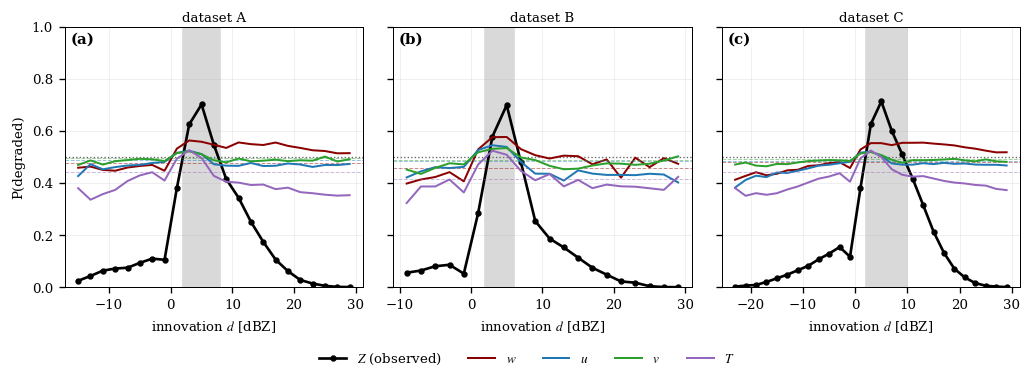

Shaded: the reflectivity band §7a fitted on this dataset. Dashed horizontals:
each variable's own base rate. A state-variable curve that is flat across the
axis has no band to give, whatever threshold is applied to it -- and a curve
that sits above 0.5 everywhere is not selectable either, it is simply damaged
everywhere.


In [53]:
# ── §15 figure: the innovation curve, reflectivity against the state ───────
# The one picture the tables cannot carry: P(degraded) against the signed innovation,
# for reflectivity and for the four state variables, on one axis per dataset. The band
# §7a fitted is shaded, so it is visible at a glance whether the reflectivity band
# picks out anything at all in the state-variable curves -- which is the whole
# question of this section.
fig, axes = plt.subplots(1, len(DATASETS), figsize=(nb.PAGE_W * 1.5, nb.PAGE_W * 0.42),
                         sharey=True, gridspec_kw={"wspace": 0.10})
VCOL = {"w": "#8B0000", "u": "#1f77b4", "v": "#2ca02c", "T": "#9467bd"}
for ax, ds in zip(np.atleast_1d(axes), DATASETS):
    lo, hi = BAND_RULE[ds][BAND_PRED]
    ax.axvspan(lo, hi, color="0.85", zorder=0)
    ax.axhline(0.5, color="0.4", lw=0.8, ls=":", zorder=1)
    p_o, cnt_o, e = p_deg_curve(ds, BAND_PRED, FIT_D[ds])
    x = 0.5 * (e[1:] + e[:-1])
    ok = cnt_o >= BAND_MIN_N
    ax.plot(x[ok], p_o[ok], "-o", ms=2.8, lw=1.6, color="k", label=r"$Z$ (observed)")
    for v in BAND_VARS:
        p_v, cnt_v, _ = VAR_CURVE[(v, ds)]
        k = cnt_v >= BAND_MIN_N
        ax.plot(x[k], p_v[k], "-", lw=1.2, color=VCOL[v], label=nb.VAR_LABELS[v])
        ax.axhline(VAR_BASE[(v, ds)], color=VCOL[v], lw=0.6, ls="--", alpha=0.45)
    ax.set_xlabel("innovation $d$ [dBZ]", fontsize=8)
    ax.set_title(f"dataset {ds}", fontsize=8, pad=3)
    ax.set_ylim(0, 1)
np.atleast_1d(axes)[0].set_ylabel("P(degraded)", fontsize=8)
for a, letter in zip(np.atleast_1d(axes), "abc"):
    nb.panel_label(a, letter)
h_, l_ = np.atleast_1d(axes)[0].get_legend_handles_labels()
fig.legend(h_, l_, loc="lower center", bbox_to_anchor=(0.5, -0.14), ncol=5,
           frameon=False, fontsize=8)
nb.save_fig(fig, "N3_1D_fig19_pdeg_state_vs_obs")
plt.show()
print("Shaded: the reflectivity band §7a fitted on this dataset. Dashed horizontals:")
print("each variable's own base rate. A state-variable curve that is flat across the")
print("axis has no band to give, whatever threshold is applied to it -- and a curve")
print("that sits above 0.5 everywhere is not selectable either, it is simply damaged")
print("everywhere.")

## 16 · A against D: does tempering need physics diversity? — thesis §4.6.9

A and D come from the same grid spacing and the same DA cycle and differ in one thing:
A's members carry **different physics**, D's do not. Every other dataset comparison in
this chapter moves two things at once — B changes the cycle, C changes the resolution —
so this is the only pair that isolates a single factor, and the factor it isolates is
whether tempering needs *structural* diversity in the ensemble or only spread.

It is kept to a table. D is not a fourth row in the twelve figures above: a secondary
question does not get to widen every panel in the chapter, and if A and D come out
nearly indistinguishable then the result is two paragraphs and a table is the honest
size for it.

The comparison uses the same yardstick §1 argues for. A difference between A and D is
only a difference if it exceeds the s.d. across truth members — which is printed beside
it, for both datasets, rather than left to the reader.

In [54]:
# ── §16: A against D, aggregates only ──────────────────────────────────────
# The pair, named from the identity blocks rather than from the letters, so a table
# that says "physics diversity" is a table whose two rows actually differ in physics
# and in nothing else the files record.
CONTRAST = ("A", DS_CONTRAST)
_ida, _idd = (nb.identity_block(ds, DS_HOURS[ds][0]) for ds in CONTRAST)
_same = [k for k in ("da_cycle_min", "dx_km") if _ida[k] == _idd[k]]
_diff = [k for k in ("physics", "da_cycle_min", "dx_km") if _ida[k] != _idd[k]]
assert set(_same) == {"da_cycle_min", "dx_km"} and _diff == ["physics"], (
    f"{CONTRAST[0]} and {CONTRAST[1]} do not differ in physics alone: same={_same}, "
    f"different={_diff}. The contrast this section is written for does not exist.")
print(f"the contrast: {CONTRAST[0]} ({_ida['physics']} physics) against "
      f"{CONTRAST[1]} ({_idd['physics']} physics),\nboth at dx = {_ida['dx_km']} km "
      f"on a {_ida['da_cycle_min']} min DA cycle, "
      f"{len(DS_HOURS[CONTRAST[0]])} and {len(DS_HOURS[CONTRAST[1]])} analysis times, "
      f"{len(TMS)} truth members each.\n")
del _ida, _idd, _same, _diff

# ── the aggregates, reflectivity ───────────────────────────────────────────
# table3() is hardwired to §1's HEAD3/BYTM3, which cover the main datasets only, so
# the same construction is done here on STATE_HEAD/STATE_BYTM -- which §14 built over
# DS_LOAD and which reproduce §1's reflectivity numbers exactly (§14 asserts it).
AD = []
for col in ("frac_improved", "median_skill", "mean_skill"):
    val, sd = table_var(col, "obs", datasets=CONTRAST)
    for c in ROW_COMBOS:
        a, d = float(val.at[LAB[c], "A"]), float(val.at[LAB[c], DS_CONTRAST])
        ea, ed = float(sd.at[LAB[c], "A"]), float(sd.at[LAB[c], DS_CONTRAST])
        AD.append({"statistic": col, "scheme": LAB[c],
                   "A": a, "sd A": ea, DS_CONTRAST: d, f"sd {DS_CONTRAST}": ed,
                   f"A - {DS_CONTRAST}": a - d,
                   # The yardstick: a difference smaller than the pooled across-member
                   # s.d. of the two datasets is not a difference, by §1's argument.
                   "yardstick": float(np.hypot(ea, ed)),
                   "resolved": bool(abs(a - d) > np.hypot(ea, ed))})
AD_TBL = pd.DataFrame(AD)
del AD
for stat, g in AD_TBL.groupby("statistic", sort=False):
    print(f"── {stat} " + "─" * 52)
    print(g.drop(columns="statistic").to_string(index=False,
                                                float_format=lambda v: f"{v:+.4f}"))
    n_res = int(g["resolved"].sum())
    print(f"   {n_res} of {len(g)} schemes differ by more than the pooled "
          f"across-member s.d.\n")

# ── the fitted band, which is the other half of the question ───────────────
# A rejection rule that transfers between A and D is a rule that does not depend on
# physics diversity. §7a fitted a band for every loaded dataset; this reads the two.
AD_BAND = pd.DataFrame([
    {"dataset": ds, "physics": nb.identity_block(ds, DS_HOURS[ds][0])["physics"],
     "band on dep_b": band_txt(BAND_RULE[ds][BAND_PRED]),
     "width [dBZ]": band_width(BAND_RULE[ds][BAND_PRED]),
     "worst bin": f"[{BAND_PEAK[ds][0]:g}, {BAND_PEAK[ds][1]:g}]",
     "P(deg) there": BAND_PEAK[ds][2],
     "base rate": BASE_RATE[ds],
     "rejects [%]": 100 * float(rule_mask(BAND_RULE[ds], ds).mean())}
    for ds in CONTRAST])
print("the band criterion, fitted independently on each of the two:\n")
print(AD_BAND.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
_ba, _bd = (BAND_RULE[ds][BAND_PRED] for ds in CONTRAST)
print(f"\nthe two bands {'AGREE' if _ba == _bd else 'DIFFER'}: "
      f"{band_txt(_ba)} in {CONTRAST[0]} against {band_txt(_bd)} in {CONTRAST[1]}.")
del _ba, _bd

# ── the state variables, since §14 is where the damage is ──────────────────
def _net(ds, v):
    return float(STATE_HEAD[(STATE_HEAD.dataset == ds) & (STATE_HEAD["var"] == v)
                            & (STATE_HEAD.method == BASE[0])
                            & (STATE_HEAD.ntemp == int(BASE[1]))]["net_improved"].iloc[0])


AD_STATE = pd.DataFrame([
    {"variable": v, **{f"{ds} net": _net(ds, v) for ds in CONTRAST}}
    for v in list(STATE_VARS) + ["obs"]]).set_index("variable")
AD_STATE[f"A - {DS_CONTRAST}"] = AD_STATE["A net"] - AD_STATE[f"{DS_CONTRAST} net"]
print(f"\nnet improvement (improved - degraded) at {LAB[BASE]}, every variable, "
      f"the two datasets:\n")
print(AD_STATE.to_string(float_format=lambda v: f"{v:+.4f}"))
print(f"\nlargest |A - {DS_CONTRAST}| over the nine variables: "
      f"{AD_STATE[f'A - {DS_CONTRAST}'].abs().max():.4f}")
del _net

publish_table("N3_1D_A_vs_D", AD_TBL, latex=False)
publish_table("N3_1D_A_vs_D_band", AD_BAND, latex=False)

the contrast: A (multi physics) against D (single physics),
both at dx = 3.964630126953125 km on a 5 min DA cycle, 4 and 4 analysis times, 60 truth members each.

── frac_improved ────────────────────────────────────────────────────
     scheme       A    sd A       D    sd D   A - D  yardstick  resolved
       AOEI +0.7237 +0.0043 +0.7320 +0.0046 -0.0083    +0.0063      True
 TEnKF Nt=1 +0.7216 +0.0044 +0.7299 +0.0047 -0.0083    +0.0064      True
 TEnKF Nt=2 +0.8191 +0.0044 +0.8261 +0.0039 -0.0071    +0.0059      True
 TEnKF Nt=3 +0.7930 +0.0036 +0.8021 +0.0037 -0.0090    +0.0052      True
 TEnKF Nt=4 +0.7735 +0.0038 +0.7827 +0.0038 -0.0092    +0.0054      True
 TEnKF Nt=5 +0.8193 +0.0033 +0.8285 +0.0030 -0.0092    +0.0045      True
 TEnKF Nt=6 +0.7934 +0.0032 +0.8025 +0.0039 -0.0091    +0.0050      True
 TEnKF Nt=7 +0.7940 +0.0036 +0.8048 +0.0033 -0.0108    +0.0049      True
 TEnKF Nt=8 +0.8043 +0.0033 +0.8145 +0.0036 -0.0102    +0.0049      True
 TEnKF Nt=9 +0.7904 +0.0035 +0.8018 +

PosixPath('/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived/N3_1D_A_vs_D_band.csv')

## 17 · Does tempering add state-variable damage here too? — thesis §4.7.7

§14 asked whether the eight state variables degrade **at all** under a
single-observation update, and the answer was no: at `TEnKF Nt=1` the unobserved
variables improve slightly more often than they degrade, and in 0 of 5 is the net
negative beyond its own error bar, in any of the three datasets.

§4.7 claims something else. Not that the analysis damages the state — that **one more
tempering step damages it further, and the extra damage lands outside the echo**. From
`TEnKF Nt=1` to `TEnKF Nt=2` the error added outside the 5 dBZ truth contour grows in
12 of 12 dataset–variable pairs, while inside the contour it grows in only 7 of 12 and
by a factor 18–997 less. The chapter reads that as the cross-covariance mechanism: a
longer ladder fits the observation better, produces a larger increment, and the larger
increment is applied in cells where the unobserved variable has no real correlation
with reflectivity.

That claim is a **differential**, and §14 does not test it. This section does, on the
same arrays.

### Why the differential has to be tested here

At `L = 0.1 km` the localization radius is a fifth of a grid cell and every observation
is assimilated **alone** into the same prior. Neither explanation that survives the
multi-obs experiment is available: no increment is spread onto a cell the observation
did not see, and no observation can be corrected or contaminated by another. What is
left is the single-point cross-covariance between reflectivity at the observed cell and
the state variable at that same cell, estimated from 59 members.

* **If tempering also worsens the state variables here**, the mechanism is intrinsic to
  that update, and §4.7.7 stands as written.
* **If it does not**, the mechanism needs localization or observation interaction, and
  §4.7.7 has to say something narrower and more specific.

Either answer is a result. The branch is chosen by the numbers below, not by this
paragraph, and the rule that chooses it is fixed before they are printed.

### The statistic, which is §4.7's and not §14's

`err_added` = the sum of the skill over the points where the skill is negative. It is
N4 §4d's own column, so the two sections can be set side by side line for line, and it
is the only one of the obvious statistics that weighs a small per-point loss by the
number of points carrying it. The **mean skill** (how much), the **degraded fraction**
(how often) and the **tie fraction** (how much of the domain the other two are about —
40–71 % of the points are ties for a hydrometeor, under 10 % for a wind) come out of
the same accumulation and sit beside it, because they answer different questions and
§14 showed that the answers differ.

`err_added` is **not comparable between variables**: `T` is order 1 K and `w` a fifth of
a metre per second, so a larger number in the `T` row is mostly a larger unit. Read it
down a variable's row, never across one; the prior error of that subset is printed
beside it for exactly that reason, and the figure plots the change as a percentage of
the same variable's own `Nt=1` value.

### The echo split, so the comparison is like for like

§4.7's differential is **outside** the 5 dBZ truth contour, so the sweep's points are
partitioned by the same field at the same level. N4 contours `truth_hx`; the sweep
stores that field at the observation cell under the name `yo_clean` — the noise-free
observation — and §0a already checked that `clamp(yo_clean + noise)` reproduces the
stored `y_o` to 10⁻⁵. One field, one threshold, two populations: model cells there,
observation points here. Without the split the two sections cannot be compared at all,
because the multi-obs finding is about *where* the added damage sits rather than how
much of it there is.

`yo_clean` is truth. It **partitions** the points here and selects none of them: no
rejection rule in §7 or §9 may see it, and none does.

### The test

Paired within the truth member — the schemes share the prior, the observations, the
noise draw and the truth, so the difference is a within-member contrast and the
member-to-member spread that dominates §1's raw numbers cancels out of it — then folded
onto the **30 twin pairs** §13a recovered from the priors and N2 §11 confirmed on the
ensemble anomalies. The sign test is §13b's `verdict()`, unchanged, at `n = 30` and not
60.

In [55]:
# ── §17: the echo split, and the accumulators every number below is built on ─
# Three things are fixed here and used unchanged for the rest of the section:
#
#   the SPLIT      the 5 dBZ TRUTH contour at the observation cell -- CONTOUR_DBZ[0],
#                  the level §9's maps draw and the level N4 §4d splits its model
#                  cells on. N4 contours truth_hx; the sweep stores that same field at
#                  the observation point as `yo_clean`.
#   the STATISTIC  err_added = the sum of the skill over the points where it is
#                  negative, which is N4 §4d's own column. The mean skill, the
#                  degraded fraction and the tie fraction come out of the same six
#                  sums, so they cannot be computed on different populations.
#   the UNIT       one truth member, its analysis times pooled -- exactly how
#                  skill_summary_by_tm groups them -- so the paired test has 60 units
#                  to fold onto §13a's 30 twin pairs.
#
# No new column and no second pass over the files: this is §14's point set, grouped by
# (truth member, side of the contour) with a handful of bincounts per (dataset,
# variable, scheme).
ECHO_DBZ = float(CONTOUR_DBZ[0])
ECHO_SIDES = ("outside", "inside", "all")
ECHO_COL = {"outside": 0, "inside": 1}
VAR_GROUPS = (("hydrometeors", tuple(nb.HYDRO)), ("T and P", ("T", "P")),
              ("winds", ("u", "v", "w")))
GROUPED_VARS = [v for _, g in VAR_GROUPS for v in g]
ALL_NINE = list(STATE_VARS) + ["obs"]
assert sorted(GROUPED_VARS) == sorted(STATE_VARS), \
    "the three groups do not cover the eight state variables exactly once"

# yo_clean is TRUTH. It partitions the points here and selects none of them.
ECHO = {ds: (PDS[ds]["yo_clean"].to_numpy(np.float64) >= ECHO_DBZ).astype(np.int64)
        for ds in DS_LOAD}
TMPOS = {ds: np.searchsorted(np.asarray(TM_OF[ds]), TMARR[ds]) for ds in DS_LOAD}
for ds in DS_LOAD:
    assert len(ECHO[ds]) == ADS[ds].n_points, \
        f"dataset {ds}: the echo mask is not row-aligned with the metric frames"
    assert 0 < int(ECHO[ds].sum()) < len(ECHO[ds]), \
        f"dataset {ds}: the {ECHO_DBZ:g} dBZ contour puts every observation on one side"


def echo_acc(ds, v, c):
    """(n_tm, 2) sums for one (dataset, variable, scheme): col 0 outside, col 1 inside.

    Every number in this section is a ratio of these six sums, and the pooled value is
    this array summed over its members -- so a pooled number and its error bar cannot
    be computed by two different pieces of code and then printed together.
    """
    fr = ADS[ds].frames[c]
    s = nb.skill(fr, "rmse", v, RED_1D).to_numpy(np.float64)
    pf = nb.raw(fr, "rmse", "f", RED_1D, v).to_numpy(np.float64)
    g = np.isfinite(s)          # dropped per variable, exactly as skill_summary drops
    idx, sg, pg = 2 * TMPOS[ds][g] + ECHO[ds][g], s[g], pf[g]
    n_g, tol = 2 * N_TM[ds], nb.TOL[v]
    out = {"n": np.bincount(idx, minlength=n_g)[:n_g].astype(float)}
    for name, w in (("n_imp", (sg > tol).astype(float)),
                    ("n_deg", (sg < -tol).astype(float)),
                    ("sum_skill", sg), ("err_add", np.minimum(sg, 0.0)),
                    ("sum_sq_prior", pg * pg)):
        out[name] = np.bincount(idx, weights=w, minlength=n_g)[:n_g]
    return {k: x.reshape(N_TM[ds], 2) for k, x in out.items()}


_t0 = time.time()
ECHO_ACC = {(ds, v, c): echo_acc(ds, v, c)
            for ds in DS_LOAD for v in ALL_NINE for c in COMBOS}
print(f"{len(ECHO_ACC)} accumulators = {len(DS_LOAD)} datasets x {len(ALL_NINE)} "
      f"variables x {len(COMBOS)} schemes  ({time.time() - _t0:.0f} s)")
del _t0


def _ratios(a):
    """The six sums, as the quantities the section reports."""
    n = a["n"]
    with np.errstate(invalid="ignore", divide="ignore"):
        return {"n": n, "mean_skill": a["sum_skill"] / n, "err_added": a["err_add"],
                "frac_improved": a["n_imp"] / n, "frac_degraded": a["n_deg"] / n,
                "frac_tied": 1.0 - (a["n_imp"] + a["n_deg"]) / n,
                "prior_rmse": np.sqrt(a["sum_sq_prior"] / n)}


def side(ds, v, c, s):
    """The accumulator restricted to one side of the contour; 'all' is both."""
    a = ECHO_ACC[(ds, v, c)]
    return ({k: x.sum(1) for k, x in a.items()} if s == "all"
            else {k: x[:, ECHO_COL[s]] for k, x in a.items()})


def by_member(ds, v, c, s="all"):
    """One value per truth member, that member's analysis times pooled."""
    return _ratios(side(ds, v, c, s))


def pooled(ds, v, c, s="all"):
    """The dataset's number: every point it owns on that side of the contour."""
    return _ratios({k: np.array(x.sum()) for k, x in side(ds, v, c, s).items()})


# The two sides must add up to the population §14 aggregates, or this section is
# quoting a different experiment than the one before it. Checked against §14's own
# table rather than argued: same points, same skill, same tie tolerance.
for ds in DS_LOAD:
    for v in ALL_NINE:
        for c in COMBOS:
            h = STATE_HEAD[(STATE_HEAD.dataset == ds) & (STATE_HEAD["var"] == v)
                           & (STATE_HEAD.method == c[0])
                           & (STATE_HEAD.ntemp == int(c[1]))].iloc[0]
            p = pooled(ds, v, c, "all")
            assert np.isclose(float(p["frac_improved"]), float(h["frac_improved"]),
                              rtol=0, atol=1e-12) \
                and np.isclose(float(p["mean_skill"]), float(h["mean_skill"]),
                               rtol=1e-6, atol=1e-9) \
                and int(p["n"]) == int(h["n_points"]), \
                f"§17 does not reproduce §14 for {ds} / {v} / {LAB[c]}"
print(f"the two sides sum to §14's population, value for value, in all "
      f"{len(ECHO_ACC)} cells.\n")

# ── how the points divide, which every 'inside'/'outside' below is a share of ──
ECHO_SPLIT = pd.DataFrame([
    {"dataset": ds, "obs points": int(pooled(ds, "obs", BASE, "all")["n"]),
     "inside [%]": 100 * float(pooled(ds, "obs", BASE, "inside")["n"])
                   / float(pooled(ds, "obs", BASE, "all")["n"]),
     "outside [%]": 100 * float(pooled(ds, "obs", BASE, "outside")["n"])
                    / float(pooled(ds, "obs", BASE, "all")["n"]),
     "prior |err| Z inside": float(pooled(ds, "obs", BASE, "inside")["prior_rmse"]),
     "prior |err| Z outside": float(pooled(ds, "obs", BASE, "outside")["prior_rmse"])}
    for ds in DS_LOAD])
print(f"the {ECHO_DBZ:g} dBZ truth contour at the observation cell, "
      f"{hours_txt()} pooled:\n")
print(ECHO_SPLIT.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print(f"\nN4's split is over MODEL CELLS and this one is over OBSERVATION POINTS, so "
      f"the two\nshares are not the same number and are not meant to be. What has to "
      f"match for the\ntwo sections to be comparable is the field and the threshold, "
      f"and they do.")

# ── what there is to add to: the untempered baseline, per side ─────────────
print(f"\n\nat {LAB[BASE]}: the error added and the tie fraction on each side of the "
      f"contour.\n'error added' is the sum of the negative skill in native units x "
      f"points -- read it\nDOWN a variable's row against its prior error, never "
      f"across one.\n")
for _s in ("outside", "inside"):
    _t = pd.DataFrame([
        {"variable": nb.VAR_LABELS[v].strip("$"), "unit": nb.RAW_UNITS.get(v, "dBZ"),
         **{f"{ds} err added": float(pooled(ds, v, BASE, _s)["err_added"])
            for ds in DATASETS},
         **{f"{ds} tied [%]": 100 * float(pooled(ds, v, BASE, _s)["frac_tied"])
            for ds in DATASETS}}
        for v in GROUPED_VARS + ["obs"]])
    print(f"── {_s} the {ECHO_DBZ:g} dBZ echo ──")
    print(_t.to_string(index=False, float_format=lambda x: f"{x:11.4g}"))
    print()
del _s, _t
publish_table("N3_1D_echo_split", ECHO_SPLIT, latex=False)

396 accumulators = 4 datasets x 9 variables x 11 schemes  (44 s)
the two sides sum to §14's population, value for value, in all 396 cells.

the 5 dBZ truth contour at the observation cell, 4 analysis times pooled:

dataset  obs points  inside [%]  outside [%]  prior |err| Z inside  prior |err| Z outside
      A     2189088       9.318       90.682                20.937                  2.640
      B      942335       4.653       95.347                21.243                  1.633
      C     7537603      12.410       87.590                21.309                  3.737
      D     2183269       9.995       90.005                21.480                  2.859

N4's split is over MODEL CELLS and this one is over OBSERVATION POINTS, so the two
shares are not the same number and are not meant to be. What has to match for the
two sections to be comparable is the field and the threshold, and they do.


at TEnKF Nt=1: the error added and the tie fraction on each side of the contour.
'error adde

PosixPath('/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived/N3_1D_echo_split.csv')

In [56]:
# ── §17: the differential, scheme by scheme, paired within the truth member ─
# One row per (dataset, variable, scheme, side of the contour). The three differences
# are all signed so that POSITIVE MEANS TEMPERING MADE IT WORSE:
#
#   d_err_added      base - scheme, since err_added is a sum of NEGATIVE skill and
#                    "more damage" is more negative;
#   d_frac_degraded  scheme - base, more points degraded;
#   d_mean_skill     base - scheme, less skill.
#
# Each is folded onto §13a's 30 twin pairs and put through §13b's sign test, which is
# not re-implemented here -- verdict() and fold_pairs() are called as they stand.
def sign_test(d):
    """§13b's verdict(), with the degenerate case named instead of raised.

    The baseline row compares a scheme with itself, so every paired difference is an
    exact zero and the sign test -- which drops zeros -- is then asked for a p-value
    at n = 0. That is not a failed test, it is the absence of one.
    """
    d = np.asarray(d, float)
    if not np.any(np.isfinite(d) & (d != 0)):
        return 0, 0, 0, np.nan
    return verdict(d)


_t0 = time.time()
_rows, _bytm = [], []
for ds in DS_LOAD:
    for v in ALL_NINE:
        for s in ECHO_SIDES:
            b_m, b_p = by_member(ds, v, BASE, s), pooled(ds, v, BASE, s)
            n_all = float(pooled(ds, v, BASE, "all")["n"])
            for c in COMBOS:
                m, p = by_member(ds, v, c, s), pooled(ds, v, c, s)
                d_err = fold_pairs(b_m["err_added"] - m["err_added"])
                d_mean = fold_pairs(b_m["mean_skill"] - m["mean_skill"])
                d_deg = fold_pairs(m["frac_degraded"] - b_m["frac_degraded"])
                # The same difference as a fraction of what that member had to add to.
                # It is the only form in which the datasets share an axis: C carries
                # 3.4x A's points and the raw sums scale with that.
                with np.errstate(invalid="ignore", divide="ignore"):
                    d_pct = fold_pairs(np.where(
                        b_m["err_added"] < 0,
                        100 * (b_m["err_added"] - m["err_added"])
                        / np.abs(b_m["err_added"]), np.nan))
                sg_err, k_err, _, p_err = sign_test(d_err)
                sg_deg, k_deg, _, p_deg = sign_test(d_deg)
                sg_mean, k_mean, _, p_mean = sign_test(d_mean)
                _rows.append({
                    "dataset": ds, "var": v, "scheme": LAB[c], "method": c[0],
                    "ntemp": int(c[1]), "side": s,
                    "n_points": float(p["n"]),
                    "points [%]": 100 * float(p["n"]) / n_all,
                    "prior_rmse": float(p["prior_rmse"]),
                    "mean_skill": float(p["mean_skill"]),
                    "err_added": float(p["err_added"]),
                    "frac_improved": float(p["frac_improved"]),
                    "frac_degraded": float(p["frac_degraded"]),
                    "frac_tied": float(p["frac_tied"]),
                    "d_err_added": float(b_p["err_added"] - p["err_added"]),
                    "d_err_added [%]": 100 * float(b_p["err_added"] - p["err_added"])
                                       / abs(float(b_p["err_added"])),
                    "d_err_added [%] per member": float(np.nanmean(d_pct)),
                    "sd d_err_added [%]": float(np.nanstd(d_pct, ddof=1)),
                    "d_mean_skill": float(p["mean_skill"] - b_p["mean_skill"]),
                    "d_frac_degraded": float(p["frac_degraded"]
                                             - b_p["frac_degraded"]),
                    "dist_from_half": abs(float(p["frac_improved"]) - 0.5),
                    "k_err": k_err, "p_err": p_err, "sign_err": sg_err,
                    "k_deg": k_deg, "p_deg": p_deg, "sign_deg": sg_deg,
                    "k_mean": k_mean, "p_mean": p_mean, "sign_mean": sg_mean})
                if s != "all":
                    for t, tm in enumerate(TM_OF[ds]):
                        _bytm.append({
                            "dataset": ds, "var": v, "scheme": LAB[c], "side": s,
                            "tm": int(tm), "n_points": float(m["n"][t]),
                            "mean_skill": float(m["mean_skill"][t]),
                            "err_added": float(m["err_added"][t]),
                            "frac_improved": float(m["frac_improved"][t]),
                            "frac_degraded": float(m["frac_degraded"][t]),
                            "frac_tied": float(m["frac_tied"][t])})
STATE_DIFF = pd.DataFrame(_rows)
STATE_DIFF_BYTM = pd.DataFrame(_bytm)
del _rows, _bytm
print(f"{len(STATE_DIFF)} pooled rows and {len(STATE_DIFF_BYTM)} per-member rows "
      f"({time.time() - _t0:.0f} s)")
del _t0


def dv(ds, v, c, s, col):
    """One cell of STATE_DIFF, so no table below indexes it by hand."""
    q = STATE_DIFF[(STATE_DIFF.dataset == ds) & (STATE_DIFF["var"] == v)
                   & (STATE_DIFF.scheme == LAB[c]) & (STATE_DIFF.side == s)]
    return q[col].iloc[0]


# ── the comparison §4.7 quotes: Nt=1 -> Nt=2 ───────────────────────────────
C_NT2 = nb.combo_key(COMBOS, "TEnKF", 2)
print("\n" + "=" * 78)
print(f"  THE DIFFERENTIAL — {LAB[BASE]} to {LAB[C_NT2]}, the step §4.7 quotes")
print("=" * 78)
print("d > 0 means TEMPERING ADDED ERROR: the sum of the negative skill went further")
print(f"negative. k is how many of the {N_EFF} twin pairs it went further negative on,")
print("and p is §13b's exact two-sided sign test on them.\n")
STATE_DIFF2 = pd.DataFrame([
    {"variable": nb.VAR_LABELS[v].strip("$"), "dataset": ds,
     "err added out, Nt=1": dv(ds, v, BASE, "outside", "err_added"),
     "err added out, Nt=2": dv(ds, v, C_NT2, "outside", "err_added"),
     "d out": dv(ds, v, C_NT2, "outside", "d_err_added"),
     "d out [%]": dv(ds, v, C_NT2, "outside", "d_err_added [%]"),
     f"k out /{N_EFF}": int(dv(ds, v, C_NT2, "outside", "k_err")),
     "p out": dv(ds, v, C_NT2, "outside", "p_err"),
     "d in": dv(ds, v, C_NT2, "inside", "d_err_added"),
     "d in [%]": dv(ds, v, C_NT2, "inside", "d_err_added [%]"),
     f"k in /{N_EFF}": int(dv(ds, v, C_NT2, "inside", "k_err")),
     "p in": dv(ds, v, C_NT2, "inside", "p_err")}
    for v in GROUPED_VARS for ds in DATASETS])
print(STATE_DIFF2.to_string(index=False, float_format=lambda x: f"{x:10.4g}",
                            formatters={"p out": "{:9.2e}".format,
                                        "p in": "{:9.2e}".format}))

# ── the same thing said twice more, because the three do not have to agree ──
# A scheme can add error mass without degrading more points (a few points degraded
# much harder), or degrade more points without adding mass. §14 met exactly that gap
# on the mean and the net, and the section may not quote one as though it were both.
print(f"\n\nthe other two readings of the same step, on the outside-echo points.")
print(f"d(frac degraded) > 0 = more points degraded, on 'k deg' of the {N_EFF} pairs;")
print("d(mean skill) < 0 = less skill, on 'k skill' of them.\n")
_o = pd.DataFrame([
    {"variable": nb.VAR_LABELS[v].strip("$"), "dataset": ds,
     "frac deg Nt=1": dv(ds, v, BASE, "outside", "frac_degraded"),
     "d frac deg": dv(ds, v, C_NT2, "outside", "d_frac_degraded"),
     f"k deg /{N_EFF}": int(dv(ds, v, C_NT2, "outside", "k_deg")),
     "mean skill Nt=1": dv(ds, v, BASE, "outside", "mean_skill"),
     "d mean skill": dv(ds, v, C_NT2, "outside", "d_mean_skill"),
     f"k skill /{N_EFF}": int(dv(ds, v, C_NT2, "outside", "k_mean")),
     "tied [%]": 100 * dv(ds, v, BASE, "outside", "frac_tied")}
    for v in GROUPED_VARS for ds in DATASETS])
print(_o.to_string(index=False, float_format=lambda x: f"{x:11.4g}"))
del _o

# And which of the two the growth is made of. The error added can grow because MORE
# points degrade or because the points that degrade do so HARDER, and the two are
# different claims about the mechanism: a larger increment applied where the
# cross-covariance is noise makes the second one, not the first. The ratios are taken
# on the outside-echo points, where the growth is.
print(f"\n\nthe same growth, factored. All three columns are {LAB[C_NT2]} over "
      f"{LAB[BASE]}, so 1.0 is\n'unchanged' and the third column is the first divided "
      f"by the second:\n")
_f = pd.DataFrame([
    {"variable": nb.VAR_LABELS[v].strip("$"), "dataset": ds,
     "error added x": dv(ds, v, C_NT2, "outside", "err_added")
                      / dv(ds, v, BASE, "outside", "err_added"),
     "degraded points x": dv(ds, v, C_NT2, "outside", "frac_degraded")
                          / dv(ds, v, BASE, "outside", "frac_degraded"),
     "loss per degraded point x":
         (dv(ds, v, C_NT2, "outside", "err_added")
          / dv(ds, v, BASE, "outside", "err_added"))
         / (dv(ds, v, C_NT2, "outside", "frac_degraded")
            / dv(ds, v, BASE, "outside", "frac_degraded"))}
    for v in GROUPED_VARS for ds in DATASETS])
print(_f.to_string(index=False, float_format=lambda x: f"{x:9.3f}"))
_u47 = _f[_f.variable.isin([nb.VAR_LABELS[v].strip("$") for v in ("w", "u", "v", "T")])]
_n_x = (float(_u47["degraded points x"].min()), float(_u47["degraded points x"].max()))
_l_x = (float(_u47["loss per degraded point x"].min()),
        float(_u47["loss per degraded point x"].max()))
print(f"\nfor the four variables §4.7 reports, the degraded-point count moves by "
      f"{_n_x[0]:.2f}-{_n_x[1]:.2f}x\nwhile the loss per degraded point moves by "
      f"{_l_x[0]:.2f}-{_l_x[1]:.2f}x.")
print("The tempered step does not damage many more points; it damages the same points"
      "\nharder, which is what a larger increment applied through a noisy "
      "cross-covariance does."
      if _n_x[1] < _l_x[0] else
      "Both terms move, so the growth is not a harder per-point loss alone and the "
      "section\nmay not describe it as one.")
del _f, _u47, _n_x, _l_x

# ── the whole ladder, in the form the figure draws ─────────────────────────
print(f"\n\nthe whole ladder: the change in the error added as a % of the {LAB[BASE]}")
print("value, positive = tempering added error. AOEI is the last column.\n")
for _s in ("outside", "inside"):
    print(f"── {_s} the {ECHO_DBZ:g} dBZ echo ──")
    for ds in DATASETS:
        print(f"  dataset {ds}")
        print(pd.DataFrame(
            [[dv(ds, v, c, _s, "d_err_added [%]") for c in TENKF_COMBOS[1:]]
             + [dv(ds, v, AOEI_COMBO, _s, "d_err_added [%]")] for v in GROUPED_VARS],
            index=[nb.VAR_LABELS[v].strip("$") for v in GROUPED_VARS],
            columns=[f"Nt={n}" for n in NT_LADDER[1:]] + ["AOEI"]
        ).to_string(float_format=lambda x: f"{x:8.2f}"))
    print()
del _s
publish_table("N3_1D_state_differential", STATE_DIFF, latex=False)
publish_table("N3_1D_state_differential_by_tm", STATE_DIFF_BYTM, latex=False)

1188 pooled rows and 47520 per-member rows (0 s)

  THE DIFFERENTIAL — TEnKF Nt=1 to TEnKF Nt=2, the step §4.7 quotes
d > 0 means TEMPERING ADDED ERROR: the sum of the negative skill went further
negative. k is how many of the 30 twin pairs it went further negative on,
and p is §13b's exact two-sided sign test on them.

variable dataset  err added out, Nt=1  err added out, Nt=2      d out  d out [%]  k out /30     p out       d in   d in [%]  k in /30      p in
     q_g       A               -2.878              -0.2921     -2.585     -89.85          0  1.86e-09     -9.692     -82.77         0  1.86e-09
     q_g       B               -1.148              -0.1346     -1.013     -88.28          0  1.86e-09     -1.976     -86.16         0  1.86e-09
     q_g       C               -9.316              -0.9555     -8.361     -89.74          0  1.86e-09     -63.71     -83.67         0  1.86e-09
     q_r       A                -2.79              -0.4599      -2.33     -83.51          0  1.86e-09 

PosixPath('/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived/N3_1D_state_differential_by_tm.csv')

saved N3_1D_fig_state_differential.pdf / N3_1D_fig_state_differential.png


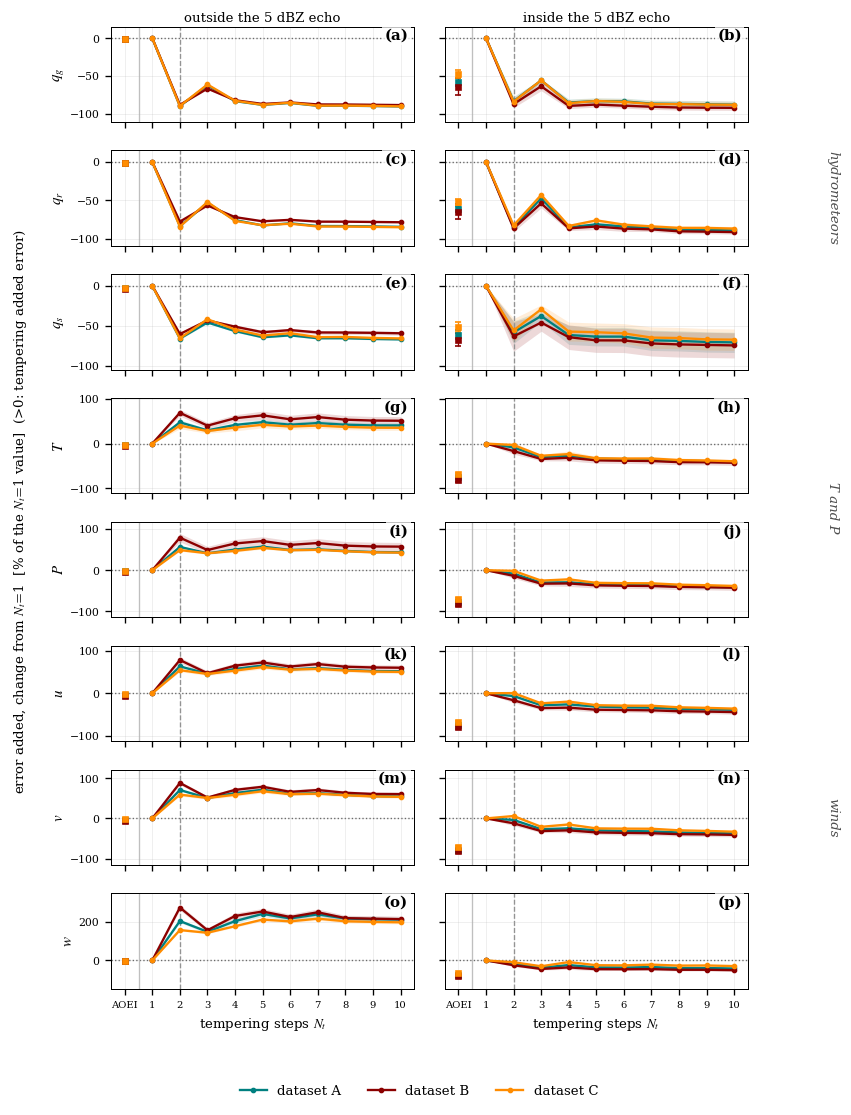

In [57]:
# ── §17 figure: the differential along the ladder, split by the echo mask ──
# Eight rows, one per state variable, in the three groups of §4; two columns, the two
# sides of the contour. y is the change in the error added relative to Nt=1 as a
# PERCENTAGE of that member's own Nt=1 value -- the only form in which A, B and C can
# share an axis, since C carries 3.4x A's points and a raw sum scales with that. The
# band is ±1 s.d. across the 30 twin pairs of the same paired difference, so a line
# inside its own band is a change this experiment cannot resolve. sharey="row" is what
# makes "grows outside, shrinks inside" a geometric fact rather than two scales.
fig, axes = plt.subplots(len(GROUPED_VARS), 2,
                         figsize=(nb.PAGE_W, nb.PAGE_W * 1.55),
                         sharex=True, sharey="row",
                         gridspec_kw={"wspace": 0.10, "hspace": 0.30})
for _r, _v in enumerate(GROUPED_VARS):
    for _ci, _s in enumerate(("outside", "inside")):
        ax = axes[_r, _ci]
        ax.axhline(0.0, color="0.35", lw=0.8, ls=":", zorder=1)      # the Nt=1 baseline
        ax.axvline(X_SPLIT, color="0.75", lw=0.8, zorder=1)          # AOEI's own slot
        ax.axvline(2, color="0.55", lw=0.8, ls="--", zorder=1)       # §4.7's comparison
        for ds in DATASETS:
            y = np.array([dv(ds, _v, c, _s, "d_err_added [%] per member")
                          for c in TENKF_COMBOS])
            e = np.array([dv(ds, _v, c, _s, "sd d_err_added [%]")
                          for c in TENKF_COMBOS])
            ax.fill_between(NT_LADDER, y - e, y + e, color=DS_COLORS[ds], alpha=0.15,
                            lw=0)
            ax.plot(NT_LADDER, y, "-o", ms=2.4, color=DS_COLORS[ds],
                    label=f"dataset {ds}")
            ax.errorbar([X_AOEI],
                        [dv(ds, _v, AOEI_COMBO, _s, "d_err_added [%] per member")],
                        yerr=[dv(ds, _v, AOEI_COMBO, _s, "sd d_err_added [%]")],
                        fmt="s", ms=3.0, color=DS_COLORS[ds], capsize=1.6,
                        elinewidth=0.8, zorder=4)
        ax.margins(y=0.16)          # headroom, so no line runs under a panel label
        ax.tick_params(labelsize=6.5)
        if _ci == 0:
            ax.set_ylabel(nb.VAR_LABELS[_v], fontsize=9, labelpad=2)
        if _r == 0:
            ax.set_title(f"{_s} the {ECHO_DBZ:g} dBZ echo", fontsize=8, pad=3)
for ax in axes[-1]:
    ax.set_xticks(NT_LADDER + [X_AOEI])
    ax.set_xticklabels([str(n) for n in NT_LADDER] + ["AOEI"], fontsize=6)
    ax.set_xlabel("tempering steps $N_t$", fontsize=8)
for a, letter in zip(axes.ravel(), "abcdefghijklmnop"):
    nb.panel_label(a, letter, loc="upper right")
# The three groups, named down the right margin: the rows are ordered by group and a
# reader has to be able to see where one ends.
_pos, _r0 = [axes[r, 0].get_position() for r in range(len(GROUPED_VARS))], 0
for _gname, _gvars in VAR_GROUPS:
    _r1 = _r0 + len(_gvars) - 1
    fig.text(0.995, 0.5 * (_pos[_r0].y1 + _pos[_r1].y0), _gname, rotation=270,
             va="center", ha="left", fontsize=8, style="italic", color="0.30")
    _r0 = _r1 + 1
fig.text(0.015, 0.5, "error added, change from $N_t$=1  [% of the $N_t$=1 value]  "
         "(>0: tempering added error)", rotation=90, va="center", ha="center",
         fontsize=8)
h_, l_ = axes[0, 0].get_legend_handles_labels()
fig.legend(h_, l_, loc="lower center", bbox_to_anchor=(0.5, 0.03),
           ncol=len(DATASETS), frameon=False, fontsize=8)
nb.save_fig(fig, "N3_1D_fig_state_differential")
plt.show()
del _r, _v, _ci, _s, _pos, _r0, _r1, _gname, _gvars

### 17a · The winds, read against their own base rate

At `TEnKF Nt=1` `u`, `v` and `w` move at almost every point — their tie fractions are
a few per cent, against 40–71 % for a hydrometeor — and they improve almost exactly
half of them. An increment whose sign is essentially a coin flip, measured where no
localization spread and no second observation can be blamed for it, is the direct
evidence for the sampling-noise reading the chapter argues.

So for the winds the quantity that matters is not which side of zero the skill sits on.
It is the **distance of the improved fraction from 0.5**, and whether tempering moves
it — in either direction. A move away from 0.5 is an increment that carries
information; a move towards it is one that carries less. The change is scored against
the s.d. of the same paired difference across the 30 twin pairs, which is what decides
whether it is a change at all.

In [58]:
# ── §17a: the winds against their own base rate ────────────────────────────
# The distance of frac_improved from 0.5, per truth member, and how tempering moves
# it. Computed per member and folded onto the twin pairs like everything else, so the
# "± " beside a change is the spread of that same paired difference and not of the
# frac_improved values it is built from.
WIND_VARS = ("u", "v", "w")
_rows = []
for v in WIND_VARS:
    for ds in DATASETS:
        for s in ECHO_SIDES:
            b = by_member(ds, v, BASE, s)
            for c in COMBOS:
                m = by_member(ds, v, c, s)
                d = fold_pairs(np.abs(m["frac_improved"] - 0.5)
                               - np.abs(b["frac_improved"] - 0.5))
                sg, k, _, p = sign_test(d)
                _rows.append({
                    "variable": v, "dataset": ds, "side": s, "scheme": LAB[c],
                    "frac_improved": dv(ds, v, c, s, "frac_improved"),
                    "frac_tied": dv(ds, v, c, s, "frac_tied"),
                    "dist_from_half": dv(ds, v, c, s, "dist_from_half"),
                    "d_distance": float(np.mean(d)),
                    "sd_across_pairs": float(np.std(d, ddof=1)),
                    "resolved": bool(abs(np.mean(d)) > np.std(d, ddof=1)),
                    "k": int(k), "p": float(p), "sign": int(sg)})
WIND_BASE = pd.DataFrame(_rows)
del _rows

print(f"at {LAB[BASE]}, every point of the dataset -- the base rate the section is "
      f"about:\n")
print(WIND_BASE[(WIND_BASE.scheme == LAB[BASE]) & (WIND_BASE.side == "all")]
      .assign(**{"tied [%]": lambda x: 100 * x.frac_tied})
      [["variable", "dataset", "frac_improved", "tied [%]", "dist_from_half"]]
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nAn increment that moved the wind at random would improve exactly half the "
      f"points.\nThese are within {100 * WIND_BASE[(WIND_BASE.scheme == LAB[BASE]) & (WIND_BASE.side == 'all')]['dist_from_half'].max():.1f} "
      f"percentage points of that, at a localization radius of a fifth\nof a grid "
      f"cell, with one observation and nothing else to blame.")

print(f"\n\nthe change in |frac improved - 0.5| from {LAB[BASE]}, with the s.d. of the "
      f"same\npaired difference across the {N_EFF} twin pairs. '*' marks a change "
      f"larger than that s.d.\nPositive = the increment moved AWAY from a coin flip.\n")
for _s in ("outside", "inside"):
    print(f"── {_s} the {ECHO_DBZ:g} dBZ echo ──")
    for _v in WIND_VARS:
        _w = WIND_BASE[(WIND_BASE.variable == _v) & (WIND_BASE.side == _s)
                       ].set_index(["dataset", "scheme"])
        print(f"  {nb.VAR_LABELS[_v]}")
        print(pd.DataFrame(
            {ds: [f"{_w.at[(ds, LAB[c]), 'd_distance']:+.4f} ± "
                  f"{_w.at[(ds, LAB[c]), 'sd_across_pairs']:.4f}"
                  f"{' *' if _w.at[(ds, LAB[c]), 'resolved'] else '  '}"
                  for c in TENKF_COMBOS[1:] + [AOEI_COMBO]] for ds in DATASETS},
            index=[LAB[c] for c in TENKF_COMBOS[1:] + [AOEI_COMBO]]).to_string())
    print()
del _s, _v, _w

# Which WAY the distance moved -- the half of the answer an absolute value throws
# away. A fraction moving further from 0.5 can mean an increment that has found
# information or one that is systematically wrong, and only the sign says which.
print(f"the improved fraction itself, pooled, along the ladder -- what the distances")
print(f"above were taken of:\n")
for _s in ("outside", "inside"):
    print(f"── {_s} the {ECHO_DBZ:g} dBZ echo ──")
    for _v in WIND_VARS:
        print(f"  {nb.VAR_LABELS[_v]}")
        print(pd.DataFrame(
            {ds: [dv(ds, _v, c, _s, "frac_improved")
                  for c in TENKF_COMBOS + [AOEI_COMBO]] for ds in DATASETS},
            index=[LAB[c] for c in TENKF_COMBOS + [AOEI_COMBO]]
        ).to_string(float_format=lambda x: f"{x:.4f}"))
    print()
_cells = [(v, ds) for v in WIND_VARS for ds in DATASETS]
_down = sum(dv(ds, v, C_NT2, "outside", "frac_improved")
            < dv(ds, v, BASE, "outside", "frac_improved") for v, ds in _cells)
_below = sum(dv(ds, v, C_NT2, "outside", "frac_improved") < 0.5 for v, ds in _cells)
_up = sum(dv(ds, v, C_NT2, "inside", "frac_improved")
          > dv(ds, v, BASE, "inside", "frac_improved") for v, ds in _cells)
_above = sum(dv(ds, v, C_NT2, "inside", "frac_improved") > 0.5 for v, ds in _cells)
print(f"""OUTSIDE the echo the improved fraction FALLS from {LAB[BASE]} to {LAB[C_NT2]} in {_down} of {len(_cells)}
(variable, dataset) cells and sits BELOW 0.5 in {_below} of {len(_cells)} of them. INSIDE it RISES in {_up} of {len(_cells)}
and sits ABOVE 0.5 in {_above} of {len(_cells)}. So the extra movement a tempering step buys is not
sign-less noise on both sides: inside the storm it is information, and outside it the
increment is systematically the wrong way. That is the error-added table again, said
in the units of a coin flip, and it is why the winds are read against 0.5 rather than
against zero skill.\n""")
del _s, _v, _cells, _down, _below, _up, _above
publish_table("N3_1D_state_wind_base_rate", WIND_BASE, latex=False)

at TEnKF Nt=1, every point of the dataset -- the base rate the section is about:

variable dataset  frac_improved  tied [%]  dist_from_half
       u       A         0.5022    0.9356          0.0022
       u       B         0.4947    2.0576          0.0053
       u       C         0.5077    0.8165          0.0077
       v       A         0.4967    0.9488          0.0033
       v       B         0.4901    2.2933          0.0099
       v       C         0.5016    0.8050          0.0016
       w       A         0.4827    4.1915          0.0173
       w       B         0.4552    8.7879          0.0448
       w       C         0.4890    3.0098          0.0110

An increment that moved the wind at random would improve exactly half the points.
These are within 4.5 percentage points of that, at a localization radius of a fifth
of a grid cell, with one observation and nothing else to blame.


the change in |frac improved - 0.5| from TEnKF Nt=1, with the s.d. of the same
paired difference across t

PosixPath('/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived/N3_1D_state_wind_base_rate.csv')

In [59]:
# ── §17: the verdict, generated from the table ─────────────────────────────
# The rule is §4.7's own claim restated as a test on this experiment, and it is fixed
# before the numbers are read: OUTSIDE the echo, the error added must GROW from Nt=1
# to Nt=2, in every dataset and for every unobserved variable, and the paired sign
# test on the 30 twin pairs must resolve it. §4.7 found 12 of 12 for w, u, v and T.
V47 = ("w", "u", "v", "T")            # the four variables §4.7 reports
GROWS = {(ds, v): dv(ds, v, C_NT2, "outside", "d_err_added") > 0
         for ds in DATASETS for v in STATE_VARS}
RESOLVED = {(ds, v): dv(ds, v, C_NT2, "outside", "sign_err") == 1
            for ds in DATASETS for v in STATE_VARS}
GROWS_IN = {(ds, v): dv(ds, v, C_NT2, "inside", "d_err_added") > 0
            for ds in DATASETS for v in STATE_VARS}
DIFF_VERDICT = pd.DataFrame([
    {"variable": nb.VAR_LABELS[v].strip("$"), "in §4.7": "yes" if v in V47 else "",
     "grows outside": f"{sum(GROWS[(ds, v)] for ds in DATASETS)}/{len(DATASETS)}",
     "and resolved":
         f"{sum(GROWS[(ds, v)] and RESOLVED[(ds, v)] for ds in DATASETS)}"
         f"/{len(DATASETS)}",
     "shrinks outside, resolved":
         f"{sum((not GROWS[(ds, v)]) and dv(ds, v, C_NT2, 'outside', 'sign_err') == -1 for ds in DATASETS)}"
         f"/{len(DATASETS)}",
     "grows inside": f"{sum(GROWS_IN[(ds, v)] for ds in DATASETS)}/{len(DATASETS)}",
     "|d out| / |d in|": float(np.mean([
         abs(dv(ds, v, C_NT2, "outside", "d_err_added"))
         / max(abs(dv(ds, v, C_NT2, "inside", "d_err_added")), 1e-300)
         for ds in DATASETS]))}
    for v in GROUPED_VARS])
N47 = len(V47) * len(DATASETS)
G47 = sum(GROWS[(ds, v)] for ds in DATASETS for v in V47)
R47 = sum(GROWS[(ds, v)] and RESOLVED[(ds, v)] for ds in DATASETS for v in V47)
STANDS = (G47 == N47 and R47 == N47)

print("=" * 78)
print("  VERDICT — does tempering add state-variable damage in the decoupled limit?")
print("=" * 78)
print(f"  §4.7 found the error added OUTSIDE the {ECHO_DBZ:g} dBZ echo growing from "
      f"{LAB[BASE]}\n  to {LAB[C_NT2]} in 12 of 12 (dataset, variable) pairs — "
      f"{', '.join(nb.VAR_LABELS[v] for v in V47)} x 3 datasets.\n  Here every "
      f"observation is assimilated alone at {nb.loc_label(RUN['loc'])}, so neither "
      f"localization\n  nor observation interaction is available to produce it.\n")
print(DIFF_VERDICT.to_string(index=False, float_format=lambda x: f"{x:10.3g}"))
print(f"\n  on §4.7's own four variables: the outside-echo error added grows in "
      f"{G47} of {N47} pairs,\n  and the paired sign test over the {N_EFF} "
      f"independent draws resolves it in {R47} of {N47}.")
print(f"  on all eight state variables: {sum(GROWS.values())} of {len(GROWS)} grow, "
      f"{sum(GROWS[k] and RESOLVED[k] for k in GROWS)} of {len(GROWS)} grow and are "
      f"resolved.\n")
if STANDS:
    print("""  -> THE MECHANISM IS INTRINSIC TO THE SINGLE-POINT CROSS-COVARIANCE UPDATE.

     The differential §4.7 measures reproduces where no observation can reach
     another and the localization radius is a fifth of a grid cell. It is therefore
     not localization spreading an increment onto cells the observation did not see,
     and not neighbouring observations interacting through a sampled covariance: it
     is the single-point cross-covariance itself, estimated from 59 members. §4.7.7
     stands as written, and this experiment is what licenses it to.""")
else:
    print("""  -> THE MECHANISM NEEDS LOCALIZATION OR OBSERVATION INTERACTION.

     The differential §4.7 measures does NOT reproduce in the decoupled limit, so it
     is not a property of the single-observation cross-covariance update alone.
     §4.7.7 has to say the narrower thing: the added damage requires an increment
     spread onto cells the observation did not see, or observations interacting
     through a prior covariance that is itself sampling noise.""")
# The two halves of the same table that point the other way. Counted, not asserted:
# a sentence about what tempering does to the hydrometeors has to come from the
# hydrometeor rows.
NH = len(nb.HYDRO) * len(DATASETS)
HYD_DOWN = sum(not GROWS[(ds, v)] and dv(ds, v, C_NT2, "outside", "sign_err") == -1
               for ds in DATASETS for v in nb.HYDRO)
HYD_DOWN_IN = sum(not GROWS_IN[(ds, v)] for ds in DATASETS for v in nb.HYDRO)
IN47 = sum(GROWS_IN[(ds, v)] for ds in DATASETS for v in V47)
print(f"""
  Two things in the same table point the other way, and belong in any sentence that
  quotes the one above. The HYDROMETEORS lose error mass rather than gain it -- {HYD_DOWN} of {NH}
  (dataset, variable) pairs outside the contour and {HYD_DOWN_IN} of {NH} inside it, resolved. And
  INSIDE the echo the unobserved variables lose it too: the error added grows there in
  {IN47} of {N47} pairs against {G47} of {N47} outside. §4.7 found that asymmetry as well and weaker --
  7 of 12 inside, by a factor 18-997 less than outside -- so the sweep is the sharper
  version of the same shape, which is what removing localization and interaction from
  the experiment should do to it.

  The step that damages the unobserved state outside the storm is the same step that
  improves the observed variable and the hydrometeors. That substitution is what
  §4.7.7 is about; it is not a contradiction of it.""")
print("=" * 78)
publish_table("N3_1D_state_differential_verdict", DIFF_VERDICT, latex=False)

  VERDICT — does tempering add state-variable damage in the decoupled limit?
  §4.7 found the error added OUTSIDE the 5 dBZ echo growing from TEnKF Nt=1
  to TEnKF Nt=2 in 12 of 12 (dataset, variable) pairs — $w$, $u$, $v$, $T$ x 3 datasets.
  Here every observation is assimilated alone at L = 0.1 km, so neither localization
  nor observation interaction is available to produce it.

variable in §4.7 grows outside and resolved shrinks outside, resolved grows inside  |d out| / |d in|
     q_g                   0/3          0/3                       3/3          0/3             0.304
     q_r                   0/3          0/3                       3/3          0/3             0.316
     q_s                   0/3          0/3                       3/3          0/3             0.407
       T     yes           3/3          3/3                       0/3          0/3              11.5
       P                   3/3          3/3                       0/3          0/3              16.4
       u

PosixPath('/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived/N3_1D_state_differential_verdict.csv')

### 17b · The oscillation in the reflectivity ladder

One more thing worth checking while the arrays are open. §1's mean-skill ladder does
not rise monotonically with `N_t`: in A it runs 1.47, 0.75, 1.10, 1.67, 1.24, 1.67,
1.61, 1.60, 1.80 from `N_t = 2` to `N_t = 10`. The chapter has been reading those local
minima as falling on multiples of three rather than on odd steps, in every dataset —
which is two claims, that the ladder oscillates at all and that the oscillation has a
period.

The pooled table cannot settle whether that is real. §1's error bar is the s.d. across
truth members — ±0.2–0.3 dBZ — which is larger than several of the steps. But the
comparison is **paired**: the same members, the same points, the same observations,
differing only in the number of tempering steps. So the test that decides it is §13b's,
and each interior step is scored against **both** of its neighbours. A step is a
resolved local minimum only if it lies below both and the sign test resolves both
comparisons.

If the dips are resolved, the exponential schedule at `alpha_s = 1` does something
specific at those step counts and the intermediate-step experiment has a definite thing
to explain. If they are not, the chapter should stop describing an oscillation. The
period is the second claim and is scored separately: it survives only if every resolved
minimum, in every dataset, sits at a multiple of three.

In [60]:
# ── §17b: the reflectivity ladder, and whether the dips are resolved ───────
# The ladder as §1 prints it -- pooled value ± the s.d. across truth members -- and
# then the paired test that ± cannot perform. The two answer different questions: the
# ± says how much a dataset's number moves when the experiment is redrawn, the paired
# test says whether one step beats another for the SAME draw, which is what a local
# minimum is a claim about.
LADDER = pd.DataFrame(
    {ds: [f"{dv(ds, 'obs', c, 'all', 'mean_skill'):+.4f} ± "
          f"{np.std(by_member(ds, 'obs', c, 'all')['mean_skill'], ddof=1):.4f}"
          for c in TENKF_COMBOS + [AOEI_COMBO]] for ds in DS_LOAD},
    index=[LAB[c] for c in TENKF_COMBOS + [AOEI_COMBO]])
print(f"mean RMSE skill of reflectivity [dBZ], {nb.RED_LABELS[RED_1D]}, "
      f"{hours_txt()} pooled,\n± the s.d. across the {len(TMS)} truth members "
      f"(§1's error bar, reproduced here from §17's sums):\n")
print(LADDER.to_string())

_rows = []
for ds in DS_LOAD:
    sk = {n: by_member(ds, "obs", nb.combo_key(COMBOS, "TEnKF", n), "all")["mean_skill"]
          for n in NT_LADDER}
    for n in NT_LADDER[1:-1]:
        dlo, dhi = fold_pairs(sk[n] - sk[n - 1]), fold_pairs(sk[n] - sk[n + 1])
        slo, klo, _, plo = sign_test(dlo)
        shi, khi, _, phi = sign_test(dhi)
        _rows.append({
            "dataset": ds, "Nt": n,
            "mean skill": dv(ds, "obs", nb.combo_key(COMBOS, "TEnKF", n), "all",
                             "mean_skill"),
            "d vs Nt-1": float(np.mean(dlo)), "k above prev": int(klo),
            "p prev": float(plo),
            "d vs Nt+1": float(np.mean(dhi)), "k above next": int(khi),
            "p next": float(phi),
            "local minimum": bool(np.mean(dlo) < 0 and np.mean(dhi) < 0),
            "resolved": bool(np.mean(dlo) < 0 and np.mean(dhi) < 0
                             and slo == -1 and shi == -1)})
LADDER_DIPS = pd.DataFrame(_rows)
del _rows
print(f"\n\neach interior step against BOTH neighbours, paired within the truth member "
      f"and folded\nonto the {N_EFF} twin pairs. k is how many pairs put the step "
      f"ABOVE that neighbour, so a\nminimum is k = 0 on both sides:\n")
for ds in DS_LOAD:
    print(f"  dataset {ds}")
    print(LADDER_DIPS[LADDER_DIPS.dataset == ds].drop(columns="dataset")
          .to_string(index=False, float_format=lambda x: f"{x:+.4f}",
                     formatters={"p prev": "{:9.2e}".format,
                                 "p next": "{:9.2e}".format}))
    print()
MINIMA = {ds: sorted(int(n) for n in
                     LADDER_DIPS[(LADDER_DIPS.dataset == ds)
                                 & LADDER_DIPS["local minimum"]]["Nt"])
          for ds in DS_LOAD}
RES_MIN = {ds: sorted(int(n) for n in
                      LADDER_DIPS[(LADDER_DIPS.dataset == ds)
                                  & LADDER_DIPS["resolved"]]["Nt"])
           for ds in DS_LOAD}
print("local minima of the mean-skill ladder, and which of them the paired test "
      "resolves:\n")
print(pd.DataFrame([{"dataset": ds, "local minima": str(MINIMA[ds]),
                     "resolved": str(RES_MIN[ds]),
                     "all at multiples of 3":
                         bool(RES_MIN[ds]) and all(n % 3 == 0 for n in RES_MIN[ds])}
                    for ds in DS_LOAD]).to_string(index=False))
ALL3 = all(RES_MIN[ds] and all(n % 3 == 0 for n in RES_MIN[ds]) for ds in DS_LOAD)
COMMON3 = sorted(set.intersection(*[set(RES_MIN[ds]) for ds in DS_LOAD]))
print(f"\nresolved in EVERY dataset: Nt = {COMMON3}")
if ALL3:
    print(f"""
The oscillation is real and it is periodic. Every resolved local minimum sits at a
multiple of three, in all {len(DS_LOAD)} datasets, and the paired test puts each of them below
BOTH neighbours on the same truth members. That is a property of the exponential
schedule at alpha_s = 1 -- the weights of a {min(COMMON3)}-step ladder are not a refinement of a
{min(COMMON3) - 1}-step one -- and the intermediate-step experiment has a specific thing to explain.""")
elif COMMON3:
    print(f"""
The dips at Nt = {COMMON3} are resolved in every dataset, so the ladder does oscillate and
the chapter may say so. But the resolved minima are NOT all at multiples of three
({', '.join(f'{ds}: {RES_MIN[ds]}' for ds in DS_LOAD)}), so "minima at multiples of three" is
more than the numbers support: the period-3 reading has to be dropped even though the
oscillation stays.""")
else:
    print("""
No local minimum is resolved in every dataset. The ladder's dips are inside what the
paired test can separate, and the chapter should stop describing an oscillation.""")
publish_table("N3_1D_ladder_dips", LADDER_DIPS, latex=False)

mean RMSE skill of reflectivity [dBZ], at obs point, 4 analysis times pooled,
± the s.d. across the 60 truth members (§1's error bar, reproduced here from §17's sums):

                            A                 B                 C                 D
TEnKF Nt=1   -0.3512 ± 0.2773  -0.7143 ± 0.2094  +0.2745 ± 0.3155  -0.0443 ± 0.3462
TEnKF Nt=2   +1.4744 ± 0.2738  +0.6201 ± 0.1960  +2.1103 ± 0.3134  +1.7663 ± 0.3359
TEnKF Nt=3   +0.7456 ± 0.2837  +0.0557 ± 0.2100  +1.5138 ± 0.3142  +1.1088 ± 0.3463
TEnKF Nt=4   +1.0989 ± 0.3093  +0.3232 ± 0.2129  +1.8822 ± 0.3565  +1.4345 ± 0.3705
TEnKF Nt=5   +1.6696 ± 0.2887  +0.6809 ± 0.2015  +2.4337 ± 0.3311  +1.9846 ± 0.3539
TEnKF Nt=6   +1.2409 ± 0.2986  +0.3576 ± 0.2142  +2.0930 ± 0.3403  +1.5947 ± 0.3601
TEnKF Nt=7   +1.6689 ± 0.3019  +0.6628 ± 0.2060  +2.5390 ± 0.3466  +1.9966 ± 0.3594
TEnKF Nt=8   +1.6091 ± 0.2974  +0.5893 ± 0.2080  +2.4823 ± 0.3393  +1.9466 ± 0.3574
TEnKF Nt=9   +1.5977 ± 0.3055  +0.5974 ± 0.2130  +2.5230 ± 0.3459  +1.9468 

PosixPath('/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation/data/derived/N3_1D_ladder_dips.csv')

### What the numbers said

**The differential reproduces, and it reproduces cleanly.** Outside the 5 dBZ truth
contour the error added grows from `TEnKF Nt=1` to `TEnKF Nt=2` in **12 of 12**
dataset–variable pairs — §4.7's own count — and the paired sign test resolves every one
of them: all 30 twin pairs agree in every cell, `p = 1.9 × 10⁻⁹`. The growth is +39 to
+88 % for `T`, `P`, `u` and `v` and +157 to +273 % for `w`. `P`, which §4.7 does not
report, behaves like the rest, so on the five non-hydrometeor variables it is 15 of 15.

**Inside the contour it does not.** There the error added *falls* in 10 of the same 12
pairs; the two exceptions are both in C, `v` at +5.8 % (resolved) and `u` at +0.4 %
(not). §4.7 found the same asymmetry more weakly — 7 of 12 growing inside, by a factor
18–997 less than outside — so the decoupled experiment is the sharper version of the
same shape, which is what taking localization and observation interaction out of an
experiment ought to do to it.

**So the branch is chosen by the numbers: the mechanism is intrinsic to the
single-point cross-covariance update, and §4.7.7 stands as written.** At `L = 0.1 km`
no increment is spread onto a cell the observation did not see and no observation can
reach another, and the differential is there anyway.

**Factored, the growth is not "more often" but "worse".** From `Nt = 1` to `Nt = 2` the
number of degraded points outside the echo moves by 1.01–1.05×, while the loss at each
degraded point moves by 1.36–3.60×. A longer ladder does not damage more of the domain;
it damages the same points harder — which is what a larger increment applied through a
cross-covariance that is mostly sampling noise looks like, and it is a sharper statement
than the error-added column alone can make.

**The winds say the same thing in the units of a coin flip.** At the baseline `u`, `v`
and `w` improve 49.5–50.8 %, 49.0–50.2 % and 45.5–48.9 % of their points. Outside the
echo tempering moves that fraction *down* in 9 of 9 (variable, dataset) cells and below
0.5 in 8 of 9; inside it moves *up* in 7 of 9 and above 0.5 in 6 of 9. For `w` the
change is larger than the across-pair s.d. at every step and in every dataset; for `u`
and `v` outside the echo it is not, except in B, where `v` clears it at every step and
`u` only at `Nt = 2`. The extra movement a tempering step buys is information inside the
storm and systematically the wrong way outside it.

**And the ladder does oscillate.** `Nt = 3` and `Nt = 6` are resolved local minima of
the mean reflectivity skill in all four datasets — below both neighbours, all 30 pairs
agreeing, `p = 1.9 × 10⁻⁹` each way. §1's ±0.2–0.3 dBZ is the spread across truth
members and not the resolution of a paired comparison, so it never was the number that
could settle this. But **"minima at multiples of three" is more than the numbers
support**: the third resolved minimum is at `Nt = 9` in A and at `Nt = 8` in B and C,
and D resolves none beyond 6. The oscillation belongs in the chapter; the period does
not, and the intermediate-step experiment has two specific dips to explain rather than
a rule.